In [2]:
%pip install stim
%pip install pytket
%pip install pytket-qiskit
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install tabulate

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Stabilizer Generator for XYZ^2 Hex Code

In [1]:
"""
xyz2_stabilizer_generator.py
────────────────────────────────────────────────────────────────────────────
Utility for generating stabilizer sets for the XYZ^2 Hex Code.
"""
from typing import List, Tuple, Dict
import math

class XYZ2StabilizerGenerator:
    """
    Generator that produces stabilizer strings for the XYZ^2 Hex Code.

    The XYZ^2 code is defined on a honeycomb lattice with lattice 
    parameter `d`. The code typically employs:
        - Weight-2 XX links on vertical edges.
        - Weight-6 XYZXYZ plaquettes in the bulk.
        - Weight-3 boundary checks.

    Attributes
    ----------
    d : int
        Code distance (must be odd and >= 3).
    n : int
        Total number of qubits (2 * d^2).
    _layer_offsets : list[int]
        Precomputed offsets for mapping (i,j) coordinates to qubit indices.

    Methods
    -------
    generate_stabilizers()
        Return a list of sparse Pauli strings representing the stabilizers.
    _coord_to_verts(i, j)
        Map 2D lattice coordinates (i, j) to the pair of qubit indices (up, lo).

    Example
    -------
    >>> gen = XYZ2StabilizerGenerator(distance=3)
    >>> gen.generate_stabilizers()
    ['X0 X1', 'Y0 Z1 X2', ...]
    """

    # ─────────────────────────────────────────────────────────────────────
    # construction
    # ─────────────────────────────────────────────────────────────────────
    def __init__(
        self, 
        distance: int
    ) -> None:
        """
        Initialise the generator and pre-compute lattice geometry.

        Args:
            distance: Code distance `d`. Must be an odd integer >= 3.
        
        Raises:
            ValueError: If d is even or less than 3.
        """
        if distance < 3 or distance % 2 == 0:
            raise ValueError("Distance d must be odd and >= 3")
        
        self.d = distance
        self.n = 2 * distance * distance
        
        # Precompute layer offsets for coordinate mapping
        # diag_counts represents the number of vertical links in each diagonal slice
        diag_counts = [
            self.d - abs((self.d - 1) - ell) 
            for ell in range(2 * self.d - 1)
        ]

        self._layer_offsets = []
        cur = 0
        for c in diag_counts:
            self._layer_offsets.append(cur)   # upper layer for this diagonal
            cur += c
            self._layer_offsets.append(cur)   # lower layer for this diagonal
            cur += c

    # ─────────────────────────────────────────────────────────────────────
    # public api
    # ─────────────────────────────────────────────────────────────────────
    def generate_stabilizers(
        self
    ) -> List[str]:
        """
        Compute the full list of stabilizer generators for distance d.

        Returns
        -------
        List[str]
            List of Pauli strings (e.g., ["X0 X1", "Y0 Z1 X2", ...]).
        """
        stabs: List[str] = []

        # (1) Vertical XX links
        # Defined for every coordinate pair (i, j) in the lattice
        for i in range(self.d):
            for j in range(self.d):
                up, lo = self._coord_to_verts(i, j)
                stabs.append(f"X{up} X{lo}")

        # (2) Bulk XYZXYZ hex plaquettes (weight 6)
        # Defined for the bulk squares
        for i in range(self.d - 1):
            for j in range(self.d - 1):
                # Get vertices for the four corners of the plaquette
                # Top-Left, Top-Right, Bottom-Left, Bottom-Right
                _, tl_l = self._coord_to_verts(i, j)
                tr_u, tr_l = self._coord_to_verts(i, j + 1)
                bl_u, bl_l = self._coord_to_verts(i + 1, j)
                br_u, _ = self._coord_to_verts(i + 1, j + 1)

                # Order: TL_low -> BL_up -> TR_up -> BL_low -> TR_low -> BR_up
                terms = [
                    f"X{tl_l}", f"Z{bl_u}", f"Y{tr_u}",
                    f"Y{bl_l}", f"Z{tr_l}", f"X{br_u}"
                ]
                stabs.append(" ".join(terms))

        # (3) Boundary half-hexes (weight 3)
        
        # Left side boundaries
        for i in range(0, self.d - 1, 2):
            a_u, a_l = self._coord_to_verts(i, 0)
            b_u, _   = self._coord_to_verts(i + 1, 0)
            stabs.append(f"Y{a_u} Z{a_l} X{b_u}")

        # Bottom side boundaries
        for j in range(0, self.d - 1, 2):
            _, a_l = self._coord_to_verts(self.d - 1, j)
            b_u, b_l = self._coord_to_verts(self.d - 1, j + 1)
            stabs.append(f"X{a_l} Y{b_u} Z{b_l}")

        # Top side boundaries
        for j in range(1, self.d - 1, 2):
            a_u, a_l = self._coord_to_verts(0, j)
            b_u, _   = self._coord_to_verts(0, j + 1)
            stabs.append(f"Z{a_u} Y{a_l} X{b_u}")

        # Right side boundaries
        for i in range(1, self.d - 1, 2):
            _, a_l   = self._coord_to_verts(i, self.d - 1)
            b_u, b_l = self._coord_to_verts(i + 1, self.d - 1)
            stabs.append(f"X{a_l} Z{b_u} Y{b_l}")

        return stabs

    # ─────────────────────────────────────────────────────────────────────
    # geometry helpers
    # ─────────────────────────────────────────────────────────────────────
    def _coord_to_verts(self, i: int, j: int) -> Tuple[int, int]:
        """
        Map logical 2D coordinate (i,j) to physical qubit indices.

        The lattice is indexed by diagonals ell = i + j.
        
        Args:
            i: Row index (0 to d-1)
            j: Column index (0 to d-1)

        Returns:
            Tuple[int, int]: (upper_qubit_index, lower_qubit_index)
        """
        ell = i + j
        max_i = min(self.d - 1, ell)
        # Order i decreasing implies left-to-right within a diagonal strip
        pos = max_i - i  
        
        up = self._layer_offsets[2 * ell] + pos
        lo = self._layer_offsets[2 * ell + 1] + pos
        return up, lo

## Testing Stabilizer Generator

In [2]:
import numpy as np

def test_stabilizer_generator():
    print("Running XYZ2 Stabilizer Generator Tests...")

    # ─────────────────────────────────────────────────────────────────────────
    # 1. Test Data (Hardcoded)
    # ─────────────────────────────────────────────────────────────────────────
    known_d3_stabs = [
        "Y0 Z1 X2", "X0 X1", "X1 Z2 Y3 Y4 Z5 X7", "X2 X4", "X3 X5", "Z3 Y5 X8",
        "X4 Z6 Y7 Y9 Z10 X12", "X6 X9", "X7 X10", "X5 Z7 Y8 Y10 Z11 X13", 
        "X8 X11", "X9 Y12 Z14", "X12 X14", "X10 Z12 Y13 Y14 Z15 X16",
        "X13 X15", "X15 Z16 Y17", "X16 X17"
    ]

    known_d5_stabs = [
        "X0 X1", "X2 X4", "X3 X5", "X6 X9", "X7 X10", "X8 X11", 
        "X12 X16", "X13 X17", "X14 X18", "X15 X19", "X20 X25", 
        "X21 X26", "X22 X27", "X23 X28", "X24 X29", "X30 X34", 
        "X31 X35", "X32 X36", "X33 X37", "X38 X41", "X39 X42", 
        "X40 X43", "X44 X46", "X45 X47", "X48 X49",
        "Y0 Z1 X2", "Z3 Y5 X8", "Z15 Y19 X24", "X37 Z40 Y43", 
        "X47 Z48 Y49", "X41 Y44 Z46", "X25 Y30 Z34", "Y6 Z9 X12",
        "X1 Z2 Y3 Y4 Z5 X7", "X4 Z6 Y7 Y9 Z10 X13", 
        "X5 Z7 Y8 Y10 Z11 X14", "X9 Z12 Y13 Y16 Z17 X21", 
        "X10 Z13 Y14 Y17 Z18 X22", "X11 Z14 Y15 Y18 Z19 X23",
        "X16 Z20 Y21 Y25 Z26 X30", "X17 Z21 Y22 Y26 Z27 X31",
        "X18 Z22 Y23 Y27 Z28 X32", "X19 Z23 Y24 Y28 Z29 X33",
        "X26 Z30 Y31 Y34 Z35 X38", "X27 Z31 Y32 Y35 Z36 X39",
        "X28 Z32 Y33 Y36 Z37 X40", "X35 Z38 Y39 Y41 Z42 X44",
        "X36 Z39 Y40 Y42 Z43 X45", "X42 Z44 Y45 Y46 Z47 X48"
    ]

    def normalize(s): 
        """Sort Pauli terms by qubit index."""
        return " ".join(sorted(s.split(), key=lambda x: int(x[1:])))

    # ─────────────────────────────────────────────────────────────────────────
    # 2. Test Case: d=3
    # ─────────────────────────────────────────────────────────────────────────
    print("\n[d=3] Testing Stabilizer Generation")
    stab_gen_3 = XYZ2StabilizerGenerator(distance=3)
    stabs_3 = stab_gen_3.generate_stabilizers()

    set_generated_3 = {normalize(s) for s in stabs_3}
    set_known_3 = {normalize(s) for s in known_d3_stabs}
    
    if set_generated_3 == set_known_3:
        print(f"✅ Exact match with known list ({len(stabs_3)} stabilizers).")
    else:
        print("❌ Mismatch found!")
        print(f"Missing: {set_known_3 - set_generated_3}")
        print(f"Extra:   {set_generated_3 - set_known_3}")

    # ─────────────────────────────────────────────────────────────────────────
    # 3. Test Case: d=5
    # ─────────────────────────────────────────────────────────────────────────
    print("\n[d=5] Testing Stabilizer Generation")
    stab_gen_5 = XYZ2StabilizerGenerator(distance=5)
    stabs_5 = stab_gen_5.generate_stabilizers()
    
    # A. Check Counts per weight (Geometric sanity check)
    weight_counts = {}
    for s in stabs_5:
        w = len(s.split())
        weight_counts[w] = weight_counts.get(w, 0) + 1
        
    print(f"   Geometric Counts: {weight_counts}")
    assert weight_counts[2] == 25, "d=5: Wrong number of XX links (expected 25)"
    assert weight_counts[6] == 16, "d=5: Wrong number of Hex plaquettes (expected 16)"
    assert weight_counts[3] == 8,  "d=5: Wrong number of Boundary checks (expected 8)"
    print("✅ Geometric counts correct (25 links, 16 hexes, 8 boundaries).")

    # B. Strict check against known d=5 list
    set_generated_5 = {normalize(s) for s in stabs_5}
    set_known_5 = {normalize(s) for s in known_d5_stabs}

    if set_generated_5 == set_known_5:
        print(f"✅ Exact match with known list ({len(stabs_5)} stabilizers).")
    else:
        print("❌ Mismatch found!")
        if len(set_known_5 - set_generated_5) > 0:
            print(f"Missing: {list(set_known_5 - set_generated_5)[:3]} ...")
        if len(set_generated_5 - set_known_5) > 0:
            print(f"Extra:   {list(set_generated_5 - set_known_5)[:3]} ...")

# Run the stabilizer tests
test_stabilizer_generator()

Running XYZ2 Stabilizer Generator Tests...

[d=3] Testing Stabilizer Generation
✅ Exact match with known list (17 stabilizers).

[d=5] Testing Stabilizer Generation
   Geometric Counts: {2: 25, 6: 16, 3: 8}
✅ Geometric counts correct (25 links, 16 hexes, 8 boundaries).
✅ Exact match with known list (49 stabilizers).


# Logical Pauli Operator

In [3]:
"""
xyz2_logical_generator.py
────────────────────────────────────────────────────────────────────────────
Utility for constructing logical Pauli operators for the XYZ^2 Hex Code.
"""
from typing import Dict, List, Tuple
import math

class XYZ2LogicalGenerator:
    """
    Generator that produces Logical X, Y, and Z operators for the XYZ^2 code.

    The logical operators are constructed based on the code distance `d`:
    - Logical X: A diagonal strip of X operators.
    - Logical Y: A specific "butterfly" pattern centered at ((d-1)/2, (d-1)/2).
    - Logical Z: Calculated as the product Logical X * Logical Y.

    Attributes
    ----------
    d : int
        Code distance.
    n : int
        Total number of qubits (2 * d^2).
    _stabilizer_gen : XYZ2StabilizerGenerator
        Internal instance for coordinate mapping logic.

    Methods
    -------
    generate_logicals()
        Return a dictionary containing 'Logical X', 'Logical Y', and 'Logical Z'.
    _get_logical_x()
        Construct the Logical X string.
    _get_logical_y()
        Construct the Logical Y string.
    _multiply_paulis(op_a, op_b)
        Compute the product of two Pauli strings (ignoring global phase).

    Example
    -------
    >>> log_gen = XYZ2LogicalGenerator(distance=3)
    >>> log_gen.generate_logicals()
    {'Logical X': 'X4 X5', 'Logical Y': 'X4 Z7 Y10 X13', 'Logical Z': ...}
    """

    # ─────────────────────────────────────────────────────────────────────
    # construction
    # ─────────────────────────────────────────────────────────────────────
    def __init__(
        self,
        distance: int
    ) -> None:
        """
        Initialise the logical operator generator.

        Args:
            distance: Code distance `d`. Must be an odd integer >= 3.
        """
        self.d = distance
        self.n = 2 * distance * distance
        # reuse geometry logic from stabilizer generator
        self._geom = XYZ2StabilizerGenerator(distance)

    # ─────────────────────────────────────────────────────────────────────
    # public api
    # ─────────────────────────────────────────────────────────────────────
    def generate_logicals(
        self
    ) -> Dict[str, str]:
        """
        Compute Logical X, Y, and Z operators.

        Returns
        -------
        Dict[str, str]
            Dictionary keys: "Logical X", "Logical Y", "Logical Z".
            Values are sparse Pauli strings.
        """
        lx = self._get_logical_x()
        ly = self._get_logical_y()
        lz = self._multiply_paulis(lx, ly)
        
        return {
            "Logical X": lx,
            "Logical Y": ly,
            "Logical Z": lz
        }

    # ─────────────────────────────────────────────────────────────────────
    # operator construction
    # ─────────────────────────────────────────────────────────────────────
    def _get_logical_x(self) -> str:
        """
        Construct Logical X along the main diagonal.
        Corresponds to 'lower' vertices where j = d - 1 - i.
        """
        qs: List[int] = []
        for i in range(self.d):
            j = self.d - 1 - i
            # We target the lower qubit on this diagonal
            _, lo = self._geom._coord_to_verts(i, j)
            qs.append(lo)
        
        qs.sort()
        return " ".join([f"X{q}" for q in qs])

    def _get_logical_y(self) -> str:
        """
        Construct Logical Y using the center-block strategy.
        
        Structure:
        1. Center block (c,c): Z on upper vertex, Y on lower vertex.
        2. Lower diagonal (i+j = d-2): X on lower vertices.
        3. Upper diagonal (i+j = d): X on upper vertices.
        """
        c = (self.d - 1) // 2
        
        # Center block
        u_cc, l_cc = self._geom._coord_to_verts(c, c)
        
        toks: List[Tuple[int, str]] = []
        toks.append((u_cc, "Z"))
        toks.append((l_cc, "Y"))

        r = (self.d - 1) // 2

        # Left X cluster: lower vertices on diagonal i + j = d - 2
        for t in range(r):
            i = (self.d - 2) - t
            j = t
            _, lo = self._geom._coord_to_verts(i, j)
            toks.append((lo, "X"))

        # Right X cluster: upper vertices on diagonal i + j = d
        for t in range(r):
            i = c - t
            j = self.d - i
            up, _ = self._geom._coord_to_verts(i, j)
            toks.append((up, "X"))

        # Sort by qubit index for canonical string format
        toks.sort(key=lambda x: x[0])
        return " ".join([f"{p}{q}" for q, p in toks])

    # ─────────────────────────────────────────────────────────────────────
    # pauli algebra helpers
    # ─────────────────────────────────────────────────────────────────────
    def _multiply_paulis(self, a_str: str, b_str: str) -> str:
        """
        Symbolic multiplication of two Pauli strings A * B.
        
        Used to derive Logical Z = Logical X * Logical Y.
        Ignores global phase.
        
        Args:
            a_str: First Pauli string (e.g., "X0 Z1").
            b_str: Second Pauli string (e.g., "Y0 X2").
            
        Returns:
            Resulting Pauli string (e.g., "Z0 Z1 X2").
        """
        # 1. Parse into dense arrays
        x_res = [0] * self.n
        z_res = [0] * self.n
        
        def apply_string(s):
            for tok in s.split():
                if not tok: continue
                p, q_idx = tok[0], int(tok[1:])
                if p in ("X", "Y"): x_res[q_idx] ^= 1
                if p in ("Z", "Y"): z_res[q_idx] ^= 1

        apply_string(a_str)
        apply_string(b_str)

        # 2. Convert back to string
        out_toks = []
        for q in range(self.n):
            x_bit = x_res[q]
            z_bit = z_res[q]
            
            if x_bit and z_bit:
                out_toks.append(f"Y{q}")
            elif x_bit:
                out_toks.append(f"X{q}")
            elif z_bit:
                out_toks.append(f"Z{q}")
                
        return " ".join(out_toks)

## Testing Logical Operator Generator

In [4]:
import numpy as np

def test_logical_generator():
    print("\nRunning XYZ2 Logical Operator Tests...")

    # ─────────────────────────────────────────────────────────────────────────
    # Helper Functions for Physics Checks
    # ─────────────────────────────────────────────────────────────────────────
    def get_pauli_xz(p_str, n_qubits):
        xs = np.zeros(n_qubits, dtype=int)
        zs = np.zeros(n_qubits, dtype=int)
        for term in p_str.split():
            p, q = term[0], int(term[1:])
            if p in 'XY': xs[q] = 1
            if p in 'ZY': zs[q] = 1
        return xs, zs

    def comm_check(op1, op2, n):
        x1, z1 = get_pauli_xz(op1, n)
        x2, z2 = get_pauli_xz(op2, n)
        # Symplectic product must be even (0 mod 2) for commutation
        return (np.sum(x1 & z2) + np.sum(z1 & x2)) % 2 == 0

    def normalize(s): 
        return " ".join(sorted(s.split(), key=lambda x: int(x[1:])))

    # ─────────────────────────────────────────────────────────────────────────
    # Testing Logic for Multiple Distances
    # ─────────────────────────────────────────────────────────────────────────
    for d in [3, 5, 7, 9, 11]:
        print(f"\n[d={d}] Checking Logical Operators")
        
        n = 2 * d * d
        s_gen = XYZ2StabilizerGenerator(d)
        l_gen = XYZ2LogicalGenerator(d)
        
        stabs = s_gen.generate_stabilizers()
        logs = l_gen.generate_logicals()
        
        lx = logs['Logical X']
        ly = logs['Logical Y']
        lz = logs['Logical Z']
        
        # Check 1: Logicals must commute with ALL stabilizers
        failures = 0
        for s in stabs:
            if not comm_check(lx, s, n): failures += 1
            if not comm_check(ly, s, n): failures += 1
            if not comm_check(lz, s, n): failures += 1
        
        if failures == 0:
            print(f"✅ Logicals commute with all {len(stabs)} stabilizers.")
        else:
            print(f"❌ Found {failures} non-commuting pairs with stabilizers!")

        # Check 2: Logical X and Logical Z must Anti-Commute
        if not comm_check(lx, lz, n): # comm_check returns False if they anti-commute
             print(f"✅ Logical X and Logical Z anti-commute.")
        else:
             print(f"❌ Logical X and Z COMMUTE (This is invalid)!")

        # Check 3: Check Logical Y string specific format (d=3 specific check)
        if d == 3:
            expected_y = "X4 Z7 Y10 X13"
            if normalize(ly) == normalize(expected_y):
                 print(f"✅ Logical Y string matches expected: '{expected_y}'.")
            else:
                 print(f"❌ Logical Y string mismatch.\nExpected: {expected_y}\nGot: {ly}")

# Run the logical tests
test_logical_generator()


Running XYZ2 Logical Operator Tests...

[d=3] Checking Logical Operators
✅ Logicals commute with all 17 stabilizers.
✅ Logical X and Logical Z anti-commute.
✅ Logical Y string matches expected: 'X4 Z7 Y10 X13'.

[d=5] Checking Logical Operators
✅ Logicals commute with all 49 stabilizers.
✅ Logical X and Logical Z anti-commute.

[d=7] Checking Logical Operators
✅ Logicals commute with all 97 stabilizers.
✅ Logical X and Logical Z anti-commute.

[d=9] Checking Logical Operators
✅ Logicals commute with all 161 stabilizers.
✅ Logical X and Logical Z anti-commute.

[d=11] Checking Logical Operators
✅ Logicals commute with all 241 stabilizers.
✅ Logical X and Logical Z anti-commute.


# Toggle Pauli Operator Generator

## Brute Force

In [5]:
"""
toggle_generator.py
────────────────────────────────────────────────────────────────────────────
Utility for locating low-weight Pauli *toggle* operators in stabilizer codes.
"""
from typing import List, Tuple
from itertools import combinations, product
import numpy as np


class ToggleGenerator:
    """
    Search helper that produces *toggle* Paulis for a given stabilizer set.

    A *toggle* `T` satisfies

        {T, P_target} = 0              # anticommutes with its own target
        [T, P_other ] = 0  (∀ other)   # commutes with everything else

    Attributes
    ----------
    stab_specs : list[str]
        Original stabilizer generators in sparse notation.
    logical_specs : list[str]
        Original logical Pauli operators in sparse notation.
    n : int
        Total number of qubits (`num_qubits` argument).
    max_w : int
        Heaviest Pauli weight to consider when searching (`max_weight`).
    _stabs : list[np.ndarray]
        Stabiliser generators as binary-symplectic `(z|x)` vectors.
    _logics : list[np.ndarray]
        Logical operators as binary-symplectic `(z|x)` vectors.

    Methods
    -------
    generate_toggles()
        Return two lists containing the stabilizer toggles and logical
        toggles, respectively.
    _pauli_to_vec(spec)
        Convert a sparse Pauli string to a binary-symplectic vector.
    _vec_to_pauli(vec)
        Convert a binary-symplectic vector back to sparse Pauli form.
    _symp_parity(v, w)
        Compute the symplectic inner product Ω(v, w) ∈ {0, 1}.
    _find_toggle(target, commute_with)
        Brute-force search for a Pauli that anticommutes with `target`
        while commuting with every vector in `commute_with`.

    Example
    -------
    >>> tg = ToggleGenerator(["X0 X1"], ["Z0"], num_qubits=2)
    >>> tg.generate_toggles()
    (['Z0'], ['Y1'])
    """

    # ─────────────────────────────────────────────────────────────────────
    # construction
    # ─────────────────────────────────────────────────────────────────────
    def __init__(
        self,
        stabilizer_specs: List[str],
        logical_specs: List[str],
        num_qubits: int,
        max_weight: int = 50
    ) -> None:
        """
        Initialise the helper and pre-compute vectorised operators.

        Args:
            stabilizer_specs: Stabiliser strings, e.g. ``"X0 Z3"``.
            logical_specs:    Logical Pauli strings.
            num_qubits:       Number of physical qubits in the code.
            max_weight:       Maximum Pauli weight to try (default 4).
        """
        # Store the stabilizer and logical operator specs
        self.stab_specs = stabilizer_specs
        self.logical_specs = logical_specs
        # Store the number of qubits and max Pauli weight
        self.n = num_qubits
        self.max_w = max_weight
        # Precompute binary-symplectic vectors for stabilizers
        self._stabs = [self._pauli_to_vec(s) for s in stabilizer_specs]
        # Precompute binary-symplectic vectors for logicals
        self._logics = [self._pauli_to_vec(l) for l in logical_specs]

    # ─────────────────────────────────────────────────────────────────────
    # public api
    # ─────────────────────────────────────────────────────────────────────
    def generate_toggles(
        self
    ) -> Tuple[List[str], List[str]]:
        """
        Compute one toggle for each stabilizer and each logical operator.

        Returns
        -------
        Tuple[List[str], List[str]]
            • First list  → stabilizer toggles, aligned with `stab_specs`.
            • Second list → logical    toggles, aligned with `logical_specs`.
        """
        # List to hold toggles for stabilizers
        stabilizer_toggles: List[str] = []
        # For each stabilizer, find a toggle
        for idx, stab_vec in enumerate(self._stabs):
            # All other stabilizers and all logicals must commute
            commute_with = (
                self._stabs[:idx] + self._stabs[idx + 1:] + self._logics
            )
            # Find a toggle for this stabilizer
            toggle_vec = self._find_toggle(
                target_vec=stab_vec, commute_vecs=commute_with
            )
            # Convert vector to Pauli string and append
            stabilizer_toggles.append(self._vec_to_pauli(toggle_vec))

        # List to hold toggles for logicals
        logical_toggles: List[str] = []
        # For each logical, find a toggle
        for idx, logic_vec in enumerate(self._logics):
            # All other logicals and all stabilizers must commute
            commute_with = (
                self._logics[:idx] + self._logics[idx + 1:] + self._stabs
            )
            # Find a toggle for this logical
            toggle_vec = self._find_toggle(
                target_vec=logic_vec, commute_vecs=commute_with
            )
            # Convert vector to Pauli string and append
            logical_toggles.append(self._vec_to_pauli(toggle_vec))

        # Return both lists of toggles
        return stabilizer_toggles, logical_toggles

    # ─────────────────────────────────────────────────────────────────────
    # Pauli  ↔  binary-symplectic helpers
    # ─────────────────────────────────────────────────────────────────────
    def _pauli_to_vec(
        self,
        pauli_spec: str
    ) -> np.ndarray:
        """
        Convert ``"X0 Y2"`` → GF(2) vector ``(z|x)``.

        Args:
            pauli_spec: Sparse Pauli string.

        Returns:
            1-D uint8 array of length ``2*n``.
        """
        # Initialise Z and X part of the vector
        z_part = np.zeros(self.n, dtype=np.uint8)
        x_part = np.zeros_like(z_part)
        # Parse each term in the Pauli string
        for term in pauli_spec.split():
            pauli_type, qubit_idx = term[0], int(term[1:])
            # Set Z and/or X bits as appropriate
            if pauli_type in ("Z", "Y"):
                z_part[qubit_idx] = 1
            if pauli_type in ("X", "Y"):
                x_part[qubit_idx] = 1
        # Concatenate Z and X parts
        return np.concatenate([z_part, x_part])

    def _vec_to_pauli(
        self,
        pauli_vec: np.ndarray
    ) -> str:
        """
        Convert binary vector back to sparse Pauli notation.

        Args:
            pauli_vec: Binary-symplectic array.

        Returns:
            Pauli string (identity → "I").
        """
        # Split vector into Z and X parts
        z_part, x_part = pauli_vec[:self.n], pauli_vec[self.n:]
        pauli_terms: List[str] = []
        # For each qubit, determine Pauli type
        for qubit_idx in range(self.n):
            if z_part[qubit_idx] and x_part[qubit_idx]:
                pauli_terms.append(f"Y{qubit_idx}")
            elif z_part[qubit_idx]:
                pauli_terms.append(f"Z{qubit_idx}")
            elif x_part[qubit_idx]:
                pauli_terms.append(f"X{qubit_idx}")
        # Return joined string or "I" if identity
        return " ".join(pauli_terms) if pauli_terms else "I"

    def _symp_parity(
        self,
        vec_a: np.ndarray,
        vec_b: np.ndarray
    ) -> int:
        """
        Symplectic inner product Ω(vec_a, vec_b).

        Returns
        -------
        int
            0 → commute, 1 → anticommute.
        """
        # Split both vectors into Z and X parts
        z_a, x_a = vec_a[:self.n], vec_a[self.n:]
        z_b, x_b = vec_b[:self.n], vec_b[self.n:]
        # Compute symplectic inner product
        parity = (int((x_a & z_b).sum()) + int((z_a & x_b).sum())) & 1
        return parity

    # ─────────────────────────────────────────────────────────────────────
    # brute-force toggle search
    # ─────────────────────────────────────────────────────────────────────
    def _find_toggle(
        self,
        target_vec: np.ndarray,
        commute_vecs: List[np.ndarray]
    ) -> np.ndarray:
        """
        Brute-force search for a Pauli that anticommutes with *target*
        and commutes with every operator in *commute_vecs*.

        Args:
            target_vec:   Vector we need to flip.
            commute_vecs: List of vectors that must commute.

        Returns:
            Binary vector of the discovered toggle.

        Raises:
            ValueError: If no toggle of weight ≤ ``max_w`` exists.
        """
        # Map Pauli types to (Z, X) bits
        pauli_bits = {'X': (0, 1), 'Y': (1, 1), 'Z': (1, 0)}
        # Try all weights from 1 up to max_w
        for weight in range(1, self.max_w + 1):
            # Try all combinations of qubits for this weight
            for qubit_idxs in combinations(range(self.n), weight):
                # Try all possible Pauli types for these qubits
                for pauli_types in product('XYZ', repeat=weight):
                    # Build candidate vector
                    z_part = np.zeros(self.n, dtype=np.uint8)
                    x_part = np.zeros_like(z_part)
                    for idx, pauli_type in zip(qubit_idxs, pauli_types):
                        z_part[idx], x_part[idx] = pauli_bits[pauli_type]
                    candidate_vec = np.concatenate([z_part, x_part])
                    # Must anticommute with target
                    if self._symp_parity(candidate_vec, target_vec) != 1:
                        continue
                    # Must commute with all in commute_vecs
                    if any(
                        self._symp_parity(candidate_vec, vec)
                        for vec in commute_vecs
                    ):
                        continue
                    # Found a valid toggle
                    return candidate_vec
        # No toggle found within max_w
        raise ValueError(
            f"no toggle of weight ≤ {self.max_w} found"
        )


In [6]:
if __name__ == "__main__":
  stab_specs = [
    "Y0 Z1 X2", "X0 X1", "X1 Z2 Y3 Y4 Z5 X7", "X2 X4", "X3 X5",
    "Z3 Y5 X8", "X4 Z6 Y7 Y9 Z10 X12", "X6 X9", "X7 X10",
    "X5 Z7 Y8 Y10 Z11 X13", "X8 X11", "X9 Y12 Z14", "X12 X14",
    "X10 Z12 Y13 Y14 Z15 X16", "X13 X15", "X15 Z16 Y17", "X16 X17",
  ]
  logical_x = ["X9 X10 X11"]

  tg = ToggleGenerator(stab_specs, logical_x, num_qubits=18)
  stab_t, log_t = tg.generate_toggles()
  print("Stabilizer toggles:", stab_t)
  print("Logical toggles:", log_t)

"""  s_gen_d_5 = XYZ2StabilizerGenerator(5)
  l_gen_d_5 = XYZ2LogicalGenerator(5)
  stabs_d_5 = s_gen_d_5.generate_stabilizers()
  logs_dict_d_5 = l_gen_d_5.generate_logicals()
  logicals_d_5 = list(logs_dict_d_5.values())
  tg_d_5 = ToggleGenerator(stabs_d_5, logicals_d_5, num_qubits=50)
  stab_t_d_5, log_t_d_5 = tg_d_5.generate_toggles()
  print("Stabilizer toggles:", stab_t_d_5)
  print("Logical toggles:", log_t_d_5)
"""

Stabilizer toggles: ['X0', 'Y0', 'X2', 'X0 Z2', 'X2 Z3', 'X2 X3', 'X6', 'Z6', 'X2 X6 Z7', 'X8', 'X2 X3 Y8', 'X12 X13', 'X13 Z14', 'X13', 'X8 Y13', 'X16', 'Y17']
Logical toggles: ['X2 X3 Y8 Z11']


'  s_gen_d_5 = XYZ2StabilizerGenerator(5)\n  l_gen_d_5 = XYZ2LogicalGenerator(5)\n  stabs_d_5 = s_gen_d_5.generate_stabilizers()\n  logs_dict_d_5 = l_gen_d_5.generate_logicals()\n  logicals_d_5 = list(logs_dict_d_5.values())\n  tg_d_5 = ToggleGenerator(stabs_d_5, logicals_d_5, num_qubits=50)\n  stab_t_d_5, log_t_d_5 = tg_d_5.generate_toggles()\n  print("Stabilizer toggles:", stab_t_d_5)\n  print("Logical toggles:", log_t_d_5)\n'

## Robust Toggle Generator (better approach)

In [7]:
import numpy as np
import networkx as nx
from typing import List, Tuple
import random
from collections import deque

class RobustToggleGenerator:
    """
    Finds minimal-weight toggles using 'Fat' Radial Beam Search.
    
    Improvement:
    - If the strict shortest-path beam fails, it 'fattens' the beam 
      by including neighbors (Width=1). 
    - This fixes validity errors where the operator needed to zig-zag 
      slightly off the perfect geodesic.
    """

    def __init__(self, stabilizer_specs: List[str], logical_x_spec: str, num_qubits: int):
        self.stab_specs = stabilizer_specs
        self.log_x_spec = logical_x_spec
        self.n = num_qubits
        
        # 1. Constraints
        self.constraints = stabilizer_specs + [logical_x_spec]
        self.num_constraints = len(self.constraints)
        
        # 2. Pre-compute Full Matrix
        self.full_matrix = np.zeros((self.num_constraints, 2 * self.n), dtype=np.uint8)
        for r, spec in enumerate(self.constraints):
            z_C, x_C = self._str_to_zx_arrays(spec)
            for i in range(self.n):
                self.full_matrix[r, 2*i]     = x_C[i] 
                self.full_matrix[r, 2*i + 1] = z_C[i] 
                
        # 3. Connectivity
        self.qubit_graph = self._build_qubit_graph(stabilizer_specs)
        # Pre-compute shortest paths (Fast for N < 1000)
        self.all_pairs_dist = dict(nx.all_pairs_shortest_path_length(self.qubit_graph))
        
        # 4. Precompute vectors for optimizer
        self.stab_vecs = [self._str_to_vec_standard(s) for s in stabilizer_specs]

    def generate_toggles(self) -> Tuple[List[str], str]:
        toggles = []
        
        for i in range(self.num_constraints):
            target_vec = np.zeros(self.num_constraints, dtype=np.uint8)
            target_vec[i] = 1
            
            # Identify search center
            op_str = self.constraints[i]
            qs_in_op = self._get_qubits_in_op(op_str)
            center_node = qs_in_op[0] if qs_in_op else 0
            
            # Organize lattice by distance from this center
            layers = self._get_distance_layers(center_node)
            
            found_solution = None
            
            # --- RADIAL BEAM SEARCH ---
            max_search_dist = len(layers)
            
            for r in range(max_search_dist):
                if found_solution: break
                
                targets = layers[r]
                # Shuffle targets to avoid directional bias artifacts
                random.shuffle(targets)
                
                for target_node in targets:
                    # 1. Thin Beam (Strict Shortest Path)
                    beam_nodes = self._get_beam(center_node, target_node)
                    sol = self._solve_restricted(beam_nodes, target_vec)
                    
                    # 2. Fat Beam (If Thin fails)
                    if sol is None:
                        fat_beam_nodes = self._expand_beam(beam_nodes)
                        sol = self._solve_restricted(fat_beam_nodes, target_vec)
                    
                    if sol is not None:
                        # Found valid path -> Optimize and Save
                        optimized = self._optimize_weight_deep(sol)
                        found_solution = self._vec_standard_to_str(optimized)
                        break
            
            # Fallback: If Beam Search failed entirely (rare, usually only for Logical),
            # run a global solve to guarantee validity.
            if found_solution is None:
                # Global solve on all qubits
                all_nodes = list(range(self.n))
                sol = self._solve_restricted(all_nodes, target_vec)
                if sol is not None:
                     optimized = self._optimize_weight_deep(sol)
                     found_solution = self._vec_standard_to_str(optimized)
                else:
                    found_solution = "I"

            toggles.append(found_solution)

        return toggles[:-1], toggles[-1]

    # ------------------ Beam Logic ------------------

    def _get_beam(self, source, target):
        """Returns union of all shortest paths between source and target."""
        try:
            d_st = self.all_pairs_dist[source][target]
        except KeyError:
            return [source, target] # Should not happen if connected

        beam = []
        # Filter nodes that are strictly on a geodesic
        for n in range(self.n):
            try:
                ds = self.all_pairs_dist[source][n]
                dt = self.all_pairs_dist[n][target]
                if ds + dt == d_st:
                    beam.append(n)
            except KeyError:
                pass
        return beam
    
    def _expand_beam(self, nodes):
        """Adds all immediate neighbors to the node set (Width +1)."""
        expanded = set(nodes)
        for n in nodes:
            for neighbor in self.qubit_graph.neighbors(n):
                expanded.add(neighbor)
        return list(expanded)

    def _get_distance_layers(self, start_node):
        """BFS to organize nodes into distance rings."""
        layers = []
        seen = {start_node}
        queue = deque([(start_node, 0)])
        
        current_dist = 0
        current_layer = []
        
        while queue:
            node, dist = queue.popleft()
            if dist > current_dist:
                layers.append(current_layer)
                current_layer = []
                current_dist = dist
            current_layer.append(node)
            for n in self.qubit_graph.neighbors(node):
                if n not in seen:
                    seen.add(n)
                    queue.append((n, dist + 1))
        
        if current_layer: layers.append(current_layer)
        return layers

    def _solve_restricted(self, qubit_indices, target_vec):
        """Solves Ax=b using ONLY the specified columns."""
        col_indices = []
        for q in qubit_indices:
            col_indices.extend([2*q, 2*q+1]) 
        col_indices = np.array(sorted(col_indices), dtype=int)
        
        sub_matrix = self.full_matrix[:, col_indices]
        x_sub = self._solve_gf2(sub_matrix, target_vec)
        
        if x_sub is not None:
            full_sol = np.zeros(2 * self.n, dtype=np.uint8)
            full_sol[col_indices] = x_sub
            z_part = full_sol[0::2]
            x_part = full_sol[1::2]
            return np.concatenate([z_part, x_part])
        return None

    # ------------------ Optimization ------------------

    def _optimize_weight_deep(self, vec, attempts=10):
        current_best = vec.copy()
        current_best_wt = self._get_weight(vec)
        indices = list(range(len(self.stab_vecs)))

        for _ in range(attempts):
            temp_vec = current_best.copy()
            random.shuffle(indices)
            
            improved = True
            while improved:
                improved = False
                curr_wt = self._get_weight(temp_vec)
                for idx in indices:
                    stab = self.stab_vecs[idx]
                    cand = temp_vec ^ stab
                    cand_wt = self._get_weight(cand)
                    if cand_wt < curr_wt:
                        temp_vec = cand
                        curr_wt = cand_wt
                        improved = True
            
            if self._get_weight(temp_vec) < current_best_wt:
                current_best = temp_vec
                current_best_wt = self._get_weight(temp_vec)
                
        return current_best

    def _get_weight(self, vec):
        return np.sum(vec[:self.n] | vec[self.n:])
    
    def _symp_product(self, v1, v2):
        n = self.n
        return (np.sum(v1[:n] & v2[n:]) + np.sum(v1[n:] & v2[:n])) % 2

    # ------------------ Helpers ------------------

    def _build_qubit_graph(self, specs):
        G = nx.Graph()
        G.add_nodes_from(range(self.n))
        for op in specs:
            qs = self._get_qubits_in_op(op)
            for i in range(len(qs)):
                for j in range(i+1, len(qs)):
                    G.add_edge(qs[i], qs[j])
        return G

    def _solve_gf2(self, A, b):
        h, w = A.shape
        M = np.hstack([A, b.reshape(-1, 1)])
        pivots = []
        pivot_row = 0
        for col in range(w):
            if pivot_row >= h: break
            cand = np.where(M[pivot_row:, col] == 1)[0]
            if len(cand) == 0: continue
            curr = cand[0] + pivot_row
            if curr != pivot_row: M[[pivot_row, curr]] = M[[curr, pivot_row]]
            pivot_vec = M[pivot_row]
            rows_to_xor = np.where(M[pivot_row+1:, col] == 1)[0] + pivot_row + 1
            if len(rows_to_xor) > 0: M[rows_to_xor] ^= pivot_vec
            pivots.append((col, pivot_row))
            pivot_row += 1
        if np.any(M[pivot_row:, -1]): return None
        x = np.zeros(w, dtype=np.uint8)
        for col, row in reversed(pivots):
            val = M[row, -1]
            dot = np.dot(M[row, col+1:w], x[col+1:]) % 2
            val ^= dot
            x[col] = val
        return x

    def _str_to_zx_arrays(self, op_str):
        z = np.zeros(self.n, dtype=np.uint8); x = np.zeros_like(z)
        for term in op_str.split():
            if not term or term == 'I': continue
            p, q = term[0], int(term[1:])
            if p in 'ZY': z[q] = 1
            if p in 'XY': x[q] = 1
        return z, x
    
    def _str_to_vec_standard(self, op_str):
        z, x = self._str_to_zx_arrays(op_str)
        return np.concatenate([z, x])

    def _vec_standard_to_str(self, vec):
        z, x = vec[:self.n], vec[self.n:]
        terms = []
        for i in range(self.n):
            if x[i] and z[i]: terms.append(f"Y{i}")
            elif x[i]:        terms.append(f"X{i}")
            elif z[i]:        terms.append(f"Z{i}")
        return " ".join(terms) if terms else "I"

    def _get_qubits_in_op(self, op_str):
        q = []
        for t in op_str.split():
            if t and t != 'I': q.append(int(t[1:]))
        return q

In [8]:
import pandas as pd
import numpy as np

def list_all_toggles_formatted(distances=[3, 5, 7, 9, 11]):
    def get_weight(op_str):
        if not op_str or op_str == "I": return 0
        return len(op_str.split())

    for d in distances:
        n_qubits = 2 * d * d
        print(f"\n\n{'='*90}")
        print(f"  XYZ^2 HEX CODE : DISTANCE d={d} ({n_qubits} qubits)")
        print(f"{'='*90}")
        
        s_gen = XYZ2StabilizerGenerator(d)
        l_gen = XYZ2LogicalGenerator(d)
        stabs = s_gen.generate_stabilizers()
        logs_dict = l_gen.generate_logicals()
        log_x_str = logs_dict['Logical X']
        
        tg = RobustToggleGenerator(stabs, log_x_str, n_qubits)
        stab_toggles, log_x_toggle = tg.generate_toggles()
        
        # Table
        print(f"\n--- STABILIZER TOGGLES ---")
        max_s = max([len(s) for s in stabs] + [15]) 
        max_t = max([len(t) for t in stab_toggles] + [15])
        fmt = f"{{:<5}} | {{:<6}} | {{:<{max_s+2}}} | {{:<{max_t+2}}} | {{:<3}}"
        sep = "-" * (max_s + max_t + 25)
        print(sep)
        print(fmt.format("Idx", "Type", "Stabilizer (S)", "Toggle (T)", "Wt"))
        print(sep)
        
        weights = []
        for i in range(len(stabs)):
            s, t = stabs[i], stab_toggles[i]
            wt = get_weight(t)
            weights.append(wt)
            
            if d <= 5 or i < 5 or i >= len(stabs)-5:
                ws = len(s.split())
                sType = "Link" if ws == 2 else ("Hex" if ws == 6 else "Bndry")
                print(fmt.format(i, sType, s, t, wt))
            elif i == 5:
                print(f"{'...':<5} | {'...':<6} | {'...':<{max_s+2}} | {'...':<{max_t+2}} | ...")

        print(sep)
        print(f"Stats: Min={min(weights)}, Max={max(weights)}, Avg={sum(weights)/len(weights):.2f}")

        print(f"\n--- LOGICAL OPERATOR TOGGLE ---")
        l_wt = get_weight(log_x_toggle)
        print(f"Logical X (L): {log_x_str}")
        print(f"Toggle    (T): {log_x_toggle}")
        print(f"Toggle Weight: {l_wt}")
        
        # Verify
        errs = 0
        all_ops = stabs + [log_x_str]
        all_togs = stab_toggles + [log_x_toggle]
        for i in range(len(all_ops)):
            v1 = tg._str_to_vec_standard(all_togs[i])
            for j, op in enumerate(all_ops):
                v2 = tg._str_to_vec_standard(op)
                commutes = (tg._symp_product(v1, v2) == 0)
                if commutes != (i != j): errs += 1
        
        if errs == 0:
            print("✅ VALIDITY: Perfect.")
        else:
            print(f"❌ VALIDITY: {errs} Errors.")

list_all_toggles_formatted()



  XYZ^2 HEX CODE : DISTANCE d=3 (18 qubits)

--- STABILIZER TOGGLES ---
---------------------------------------------------------------------
Idx   | Type   | Stabilizer (S)            | Toggle (T)              | Wt 
---------------------------------------------------------------------
0     | Link   | X0 X1                     | Y0                      | 1  
1     | Link   | X3 X5                     | X2 Z3                   | 2  
2     | Link   | X8 X11                    | X2 X5 Y8                | 3  
3     | Link   | X2 X4                     | X0 Z2                   | 2  
4     | Link   | X7 X10                    | X1 Z2 Z4 Z7             | 4  
5     | Link   | X13 X15                   | X8 Y13                  | 2  
6     | Link   | X6 X9                     | Z6                      | 1  
7     | Link   | X12 X14                   | X13 Z14                 | 2  
8     | Link   | X16 X17                   | X13 Z16                 | 2  
9     | Hex    | X1 Z2 Y3 Y4 Z5 X7  

# MDR Table (Stabilizers, Logical Paulis, Toggles)

In [9]:
"""
mdr_table_generator.py
────────────────────────────────────────────────────────────────────────────
Utility for compiling, archiving, and retrieving the complete algebraic 
structure (Stabilizers, Logicals, Toggles) of the MDR code instance.
"""

import pandas as pd
import os
from typing import Optional, List, Dict, Tuple, Any

class MDRTable:
    """
    A unified container that generates, aligns, and serializes the full
    algebraic definition of an MDR code instance.
    """

    def __init__(
        self, 
        distance: int,
        save_filename: Optional[str] = None
    ) -> None:
        """
        Initialize the MDRTable, compile operator data, and handle file I/O.
        """
        if distance < 3 or distance % 2 == 0:
            raise ValueError("Distance d must be odd and >= 3")

        self.d = distance
        self.n_qubits = 2 * distance * distance
        self.save_filename = save_filename
        self.df = pd.DataFrame()
        
        # Trigger compilation
        self._compile_data()

        # Handle saving logic
        if self.save_filename:
            self._handle_save_request()

    def _compile_data(self) -> None:
        """
        Internal orchestration method to generate and align all operators.
        """
        # 1. Fetch Code Stabilizers
        s_gen = XYZ2StabilizerGenerator(self.d)
        stabs: List[str] = s_gen.generate_stabilizers()

        # 2. Fetch Logical Operators
        l_gen = XYZ2LogicalGenerator(self.d)
        logs_dict: Dict[str, str] = l_gen.generate_logicals()
        
        logical_x_str = logs_dict.get("Logical X")
        if not logical_x_str:
            raise ValueError("Logical X not found in logical generator output.")

        # 3. Generate Toggles
        # FIX: Using positional arguments to match the RobustToggleGenerator definition
        tg = RobustToggleGenerator(stabs, logical_x_str, self.n_qubits)
        
        stab_toggles, log_x_toggle = tg.generate_toggles()

        # 4. Build Table Rows
        data_rows: List[Dict[str, Any]] = []

        # A. Stabilizer Rows
        for i, (stab_op, toggle_op) in enumerate(zip(stabs, stab_toggles)):
            data_rows.append({
                "Category": "Stabilizer",
                "Label": f"S_{i}",
                "Operator": stab_op,
                "Toggle": toggle_op
            })

        # B. Logical X Row
        data_rows.append({
            "Category": "Logical",
            "Label": "Logical X",
            "Operator": logical_x_str,
            "Toggle": log_x_toggle
        })

        # C. Other Logicals
        for label in ["Logical Y", "Logical Z"]:
            if label in logs_dict:
                data_rows.append({
                    "Category": "Logical",
                    "Label": label,
                    "Operator": logs_dict[label],
                    "Toggle": "—"
                })

        self.df = pd.DataFrame(data_rows)

    def _handle_save_request(self) -> None:
        if self.save_filename and os.path.exists(self.save_filename):
            print(f"   -> Table already exists at: {os.path.abspath(self.save_filename)}")
            print("   -> Skipping write operation.")
        elif self.save_filename:
            self.save_csv(self.save_filename)

    # ──────────────── Extraction API ────────────────
    def get_stabilizers(self) -> List[str]:
        return self.df[self.df["Category"] == "Stabilizer"]["Operator"].tolist()

    def get_logicals_dict(self) -> Dict[str, str]:
        log_df = self.df[self.df["Category"] == "Logical"]
        return pd.Series(log_df.Operator.values, index=log_df.Label).to_dict()

    def get_toggles(self) -> Tuple[List[str], str]:
        stab_toggles = self.df[self.df["Category"] == "Stabilizer"]["Toggle"].tolist()
        log_x_row = self.df[self.df["Label"] == "Logical X"]
        if log_x_row.empty:
            raise ValueError("Logical X missing from table.")
        log_x_toggle = log_x_row["Toggle"].values[0]
        return stab_toggles, log_x_toggle

    # ──────────────── IO Methods ────────────────
    def get_table(self) -> pd.DataFrame:
        return self.df

    def save_csv(self, filename: str) -> None:
        self.df.to_csv(filename, index=False)
        print(f"   -> Table saved locally to: {os.path.abspath(filename)}")

    def save_latex(self, filename: str) -> None:
        latex_code = self.df.to_latex(index=False, escape=False)
        with open(filename, "w") as f:
            f.write(latex_code)
        print(f"   -> LaTeX table saved locally to: {os.path.abspath(filename)}")

# MDR in stim

In [10]:
import stim
from typing import List

class MDRCircuit:
    """
    Builds a Measurement-based Decoding & Recovery (MDR) circuit with
    configurable noise models and defaults.

    Args:
        stabilizers (List[str] | None): List of stabilizer generator strings.
            If None, a default set is used.
        toggles (List[str] | None): List of recovery toggle strings.
            If None, a default set is used.
        ancillas (int): Number of ancilla qubits to use (min 1).
        p_spam (float): Probability of SPAM noise.
        p_x (float): Probability of X error during idling.
        p_y (float): Probability of Y error during idling.
        p_z (float): Probability of Z error during idling.
        g1_x (float): Prob. of X error after each 1-qubit gate.
        g1_y (float): Prob. of Y error after each 1-qubit gate.
        g1_z (float): Prob. of Z error after each 1-qubit gate.
        gate_noise_2q (List[float] | None): 15 two-qubit error probabilities.
        psi_circuit (stim.Circuit | None): initial state preparation circuit.

    Methods
    -------
    __init__(...): Initialize MDRCircuit with defaults and noise parameters.
    _insert_pauli_channel(...): Add a 1-qubit biased depolarising channel.
    _insert_pauli_channel_2(...): Add a 2-qubit depolarising channel.
    add_idle_noise(...): Apply idling noise to specified idle qubits.
    psi(): Prepare and return the initial state preparation circuit.
    _gate(...): Append a quantum gate and its associated noise to the circuit.
    _spam_gate(...): Append a gate with SPAM noise (for R and M gates).
    build(...): Construct and return the full MDR protocol circuit, optionally
        including the |+> state preparation stage.
    """
    def __init__(
        self,
        stabilizers: List[str] | None = None,
        toggles: List[str] | None = None,
        ancillas: int = 1,
        p_spam: float = 0,
        p_x: float = 0,
        p_y: float = 0,
        p_z: float = 0,
        g1_x: float = 0,
        g1_y: float = 0,
        g1_z: float = 0,
        gate_noise_2q: List[float] | None = None,
        psi_circuit: stim.Circuit | None = None
    ) -> None:
        """
        Initialize the MDRCircuit object with user-specified or default
        stabilizers, toggles, ancilla count, and noise parameters. Validates
        input for two-qubit noise and ancilla count. Sets up all circuit
        parameters for later use in circuit construction.

        Args:
            stabilizers: List of stabilizer generator strings. If None, uses
                a default set for the code.
            toggles: List of recovery toggle strings. If None, uses a default
                set for the code.
            ancillas: Number of ancilla qubits to use for syndrome extraction.
                Must be at least 1.
            p_spam: Probability of SPAM (state preparation and measurement)
                noise.
            p_x: Probability of X error during idling.
            p_y: Probability of Y error during idling.
            p_z: Probability of Z error during idling.
            g1_x: Probability of X error after each 1-qubit gate.
            g1_y: Probability of Y error after each 1-qubit gate.
            g1_z: Probability of Z error after each 1-qubit gate.
            gate_noise_2q: List of 15 probabilities for two-qubit gate errors.
                If None, all set to 0.
            psi_circuit: stim.Circuit for initial state preparation. If None,
                no preparation is included.
        Raises:
            ValueError: If gate_noise_2q is not length 15 or ancillas < 1.
        """
        if gate_noise_2q is None:
            gate_noise_2q = [0.0] * 15
        elif len(gate_noise_2q) != 15:
            raise ValueError("gate_noise_2q must have 15 floats.")
        if ancillas < 1:
            raise ValueError("ancillas must be at least 1.")
        
        self.stabilizers = stabilizers
        self.num_qubits = len(self.stabilizers) + 1
        self.toggles = toggles
        self.ancillas = ancillas
        self.p_spam = p_spam
        self.p_x = p_x
        self.p_y = p_y
        self.p_z = p_z
        self.g1_x = g1_x
        self.g1_y = g1_y
        self.g1_z = g1_z
        self.gate_noise_2q = gate_noise_2q
        self.psi_circuit = psi_circuit or None

    def _insert_pauli_channel(
        self,
        circ: stim.Circuit,
        tgts: List[int],
        p_x: float,
        p_y: float,
        p_z: float
    ):
        """
        Append a 1-qubit biased depolarising channel to the circuit. This
        channel applies X, Y, and Z errors to the specified qubits with
        probabilities p_x, p_y, and p_z, respectively. If all probabilities
        are zero or tgts is empty, no operation is added.

        Args:
            circ: stim.Circuit to append the noise operation to.
            tgts: List of qubit indices to apply the noise channel to.
            p_x: Probability of X error for each target qubit.
            p_y: Probability of Y error for each target qubit.
            p_z: Probability of Z error for each target qubit.
        """
        if not tgts or (p_x == p_y == p_z == 0):
            return
        circ += stim.Circuit(
            f"PAULI_CHANNEL_1({p_x},{p_y},{p_z}) "
            f"{' '.join(str(q) for q in tgts)}"
        )

    def _insert_pauli_channel_2(
        self,
        circ: stim.Circuit,
        q_a: int,
        q_d: int,
        noise: List[float]
    ):
        """
        Append a 2-qubit depolarising channel to the circuit. This channel
        applies all possible two-qubit Pauli errors (except II) with the
        specified probabilities. If all probabilities are zero, no operation
        is added.

        Args:
            circ: stim.Circuit to append the noise operation to.
            q_a: Index of the first qubit in the two-qubit channel.
            q_d: Index of the second qubit in the two-qubit channel.
            noise: List of 15 probabilities for each nontrivial two-qubit
                Pauli error (order: IX, IY, IZ, XI, XX, XY, XZ, YI, YX, YY,
                YZ, ZI, ZX, ZY, ZZ).
        """
        if not any(noise):
            return
        circ += stim.Circuit(
            f"PAULI_CHANNEL_2({','.join(f'{p:.6g}' for p in noise)})"
            f" {q_a} {q_d}"
        )

    def add_idle_noise(
        self,
        circ: stim.Circuit,
        idle_qs: List[int],
        p_x: float = 1e-4,
        p_y: float = 1e-4,
        p_z: float = 8e-4
    ):
        """
        Apply biased idling noise to a list of idle qubits. This method
        inserts a 1-qubit Pauli channel with the specified error rates for
        X, Y, and Z errors. Used to model decoherence on qubits not involved
        in active gates during a circuit tick.

        Args:
            circ: stim.Circuit to append the idle noise operation to.
            idle_qs: List of qubit indices considered idle at this tick.
            p_x: Probability of X error for each idle qubit.
            p_y: Probability of Y error for each idle qubit.
            p_z: Probability of Z error for each idle qubit.
        """
        self._insert_pauli_channel(circ, idle_qs, p_x, p_y, p_z)

    def psi(self) -> stim.Circuit:
        """
        Prepare and return the initial state preparation circuit for the MDR
        protocol. If a psi_circuit was provided at initialization, returns a
        copy of that circuit. Otherwise, returns an empty circuit.

        Returns:
            stim.Circuit: Circuit that prepares the initial state for the
                protocol, as specified by psi_circuit.
        """
        circ = stim.Circuit(str(self.psi_circuit))
        return circ

    def _gate(
        self,
        circ: stim.Circuit,
        name: str,
        tgts: List[int]
    ):
        """
        Append a quantum gate and its associated noise to the circuit. For
        1-qubit gates, applies a 1-qubit Pauli channel after the gate. For
        2-qubit gates, applies a 2-qubit Pauli channel. For gates with more
        than 2 targets, applies 1-qubit noise to each target. If all noise
        rates are zero, only the gate is appended.

        Args:
            circ: stim.Circuit to modify by appending the gate and noise.
            name: Name of the quantum gate (e.g., 'H', 'CX', 'CY', 'CZ').
            tgts: List of qubit indices the gate acts on.
        """
        circ.append_operation(name, tgts)

        if (self.g1_x == self.g1_y == self.g1_z == 0
            and not any(self.gate_noise_2q)):
            return

        real = [q for q in tgts if isinstance(q, int)]
        if not real:
            return

        if len(real) > 2:
            for q in real:
                self._insert_pauli_channel(
                    circ, [q], self.g1_x, self.g1_y, self.g1_z
                )
            return

        if len(real) == 1:
            self._insert_pauli_channel(
                circ, real, self.g1_x, self.g1_y, self.g1_z
            )
        else:
            q1, q2 = real
            self._insert_pauli_channel_2(
                circ, q1, q2, self.gate_noise_2q
            )

    def _spam_gate(self, circ: stim.Circuit, name: str, tgts: List[int]):
        """
        Append a gate to the circuit with SPAM noise. For 'R' (reset), the
        noise is applied after the reset. For 'M' (measurement), the noise
        is applied before the measurement. If p_spam is zero, only the gate
        is appended. Used to model state preparation and measurement errors.

        Args:
            circ: stim.Circuit to modify by appending the gate and noise.
            name: Name of the gate ('R' for reset, 'M' for measurement).
            tgts: List of qubit indices the gate acts on.
        """
        if self.p_spam == 0:
            circ.append_operation(name, tgts)
            return
        
        if name == 'R':
            circ.append_operation(name, tgts)
            self._insert_pauli_channel(
                circ, tgts, self.p_spam, 0, 0
            )

        if name == 'M':
            self._insert_pauli_channel(
                circ, tgts, self.p_spam, 0, 0
            )
            circ.append_operation(name, tgts)
    
    def build(
        self,
        include_psi: bool = True,
    ) -> stim.Circuit:
        """
        Construct and return the full MDR protocol circuit. This includes
        syndrome extraction using ancilla qubits, application of idle noise,
        and recovery toggles based on measurement results. Optionally
        prepends the initial state preparation circuit if include_psi is
        True.

        Args:
            include_psi (bool): If True, prepends the |+> state preparation
                circuit (psi_circuit) to the protocol. If False, starts with
                an empty circuit.

        Returns:
            stim.Circuit: The complete MDR protocol circuit, including
                syndrome extraction, idle noise, and recovery toggles.
        """
        if include_psi:
            circ = self.psi()
        else:
            circ = stim.Circuit()

        anc_ids = list(range(self.num_qubits, self.num_qubits + self.ancillas))
        total = self.num_qubits + self.ancillas
        all_qs = set(range(total))

        # Syndrome extraction
        for start in range(0, len(self.stabilizers), self.ancillas):
            stabs = self.stabilizers[start:start + self.ancillas]
            ancs = anc_ids[:len(stabs)]

            # prepare ancillas
            self._spam_gate(circ, 'R', ancs)
            self._gate(circ, 'H', ancs)

            # measure each stabilizer
            active = set(ancs)
            for anc, stab in zip(ancs, stabs):
                for term in stab.split():
                    p, d = term[0], int(term[1:])
                    active.add(d)
                    g = {'X': 'CX', 'Y': 'CY', 'Z': 'CZ'}[p]
                    self._gate(circ, g, [anc, d])

            # finalize measurement
            self._gate(circ, 'H', ancs)
            # SPAM noise before measurement
            self._spam_gate(circ, 'M', ancs)
            active.update(ancs)

            # idle noise and tick
            idle = [q for q in all_qs if q not in active]
            self.add_idle_noise(circ, idle, self.p_x, self.p_y, self.p_z)
            circ.append_operation('TICK')

        # Recovery toggles
        for idx, ops in enumerate(self.toggles):
            rec_target = stim.target_rec(-(len(self.stabilizers) - idx))
            active = set()
            for op in ops.split():
                p, d = op[0], int(op[1:])
                active.add(d)
                g = {'X': 'CX', 'Y': 'CY', 'Z': 'CZ'}[p]
                self._gate(circ, g, [rec_target, d])

            # idle noise and tick
            idle = [q for q in all_qs if q not in active]
            self.add_idle_noise(circ, idle, self.p_x, self.p_y, self.p_z)
            circ.append_operation('TICK')

        return circ

## Circuit Commands

qubits: 36 ops: 207
H 9 10 11
R 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34
PAULI_CHANNEL_1(0.001339, 0, 0) 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34
H 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34
PAULI_CHANNEL_1(5e-05, 5e-05, 0.2) 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34
CY 18 0
PAULI_CHANNEL_2(5e-05, 5e-05, 0.2, 5e-05, 0, 0, 0, 5e-05, 0, 0, 0, 0.2, 0, 0, 0) 18 0
CZ 18 1
PAULI_CHANNEL_2(5e-05, 5e-05, 0.2, 5e-05, 0, 0, 0, 5e-05, 0, 0, 0, 0.2, 0, 0, 0) 18 1
CX 18 2
PAULI_CHANNEL_2(5e-05, 5e-05, 0.2, 5e-05, 0, 0, 0, 5e-05, 0, 0, 0, 0.2, 0, 0, 0) 18 2
CX 19 0
PAULI_CHANNEL_2(5e-05, 5e-05, 0.2, 5e-05, 0, 0, 0, 5e-05, 0, 0, 0, 0.2, 0, 0, 0) 19 0
CX 19 1
PAULI_CHANNEL_2(5e-05, 5e-05, 0.2, 5e-05, 0, 0, 0, 5e-05, 0, 0, 0, 0.2, 0, 0, 0) 19 1
CX 20 1
PAULI_CHANNEL_2(5e-05, 5e-05, 0.2, 5e-05, 0, 0, 0, 5e-05, 0, 0, 0, 0.2, 0, 0, 0) 20 1
CZ 20 2
PAULI_CHANNEL_2(5e-05, 5e-05, 0.2, 5e-05, 0, 0, 0, 5e-05, 0, 0, 0, 0.2, 0, 0, 0) 20 2
CY 20 3
PAULI_CHANNEL_2(5e-05, 5e-05,

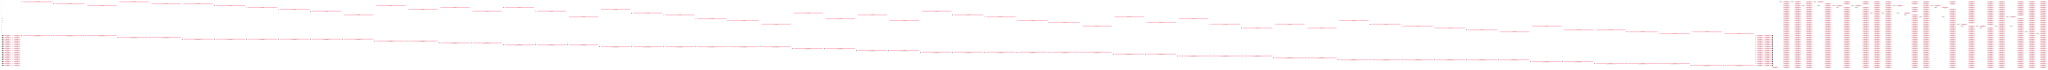

In [11]:
if __name__ == "__main__":
    
    stabilizers = [
        "Y0 Z1 X2", "X0 X1", "X1 Z2 Y3 Y4 Z5 X7",
        "X2 X4", "X3 X5", "Z3 Y5 X8",
        "X4 Z6 Y7 Y9 Z10 X12", "X6 X9", "X7 X10",
        "X5 Z7 Y8 Y10 Z11 X13", "X8 X11",
        "X9 Y12 Z14", "X12 X14",
        "X10 Z12 Y13 Y14 Z15 X16",
        "X13 X15", "X15 Z16 Y17", "X16 X17"
    ]
    toggles = [
        "X0", "Y0", "X2", "X0 Z2", "X2 Z3", "X2 X3",
        "X6", "Z6", "X2 X6 Z7", "X8", "X2 X3 Y8",
        "X12 X13", "X13 Z14", "X13", "X8 Y13", "X16",
        "Y17"
    ]
    p_spam = 1.339e-3
    p_idle_x, p_idle_y, p_idle_z = 1e-4, 1e-4, 8e-4
    g1_x, g1_y, g1_z = 5e-5, 5e-5, 0.2
    gate_noise_2q = [
        g1_x, g1_y, g1_z, g1_x, 0, 0, 0,
        g1_y, 0, 0, 0, g1_z, 0, 0, 0
    ]
    psi = stim.Circuit()
    psi.append_operation('H', list(range(9,12)))

    mdr = MDRCircuit(
        stabilizers=stabilizers,
        toggles=toggles,
        ancillas=18,
        p_spam=p_spam,
        p_x=p_idle_x, p_y=p_idle_y, p_z=p_idle_z,
        g1_x=g1_x, g1_y=g1_y, g1_z=g1_z,
        gate_noise_2q=gate_noise_2q,
        psi_circuit=psi
    )
    circ = mdr.build(True)
    print("qubits:", circ.num_qubits, "ops:", len(circ))
    print(circ)
circ.diagram('timeline-svg')


## Verifying Expectation Value of Stabilizers and Logical X

In [12]:
def pauli_string(
    spec_string: str,
    num_qubits: int
) -> stim.PauliString:
    """
    Parses a sparse Pauli spec into a stim.PauliString.

    Args:
        spec_string: Pauli string, e.g. "X1 Z2" or empty.
        num_qubits: Total number of qubits.

    Returns:
        stim.PauliString representing the spec.
    """
    ps = stim.PauliString(num_qubits)
    if not spec_string:
        return ps
    for term in spec_string.split():
        p, idx = term[0], int(term[1:])
        ps[idx] = p
    return ps


def distance_3_verification():
    """
    Build and simulate the MDR circuit, then verify stabilizers and
    logical X operator, printing results.
    """
    # Define code and logical
    stabSpecs = [
        "Y0 Z1 X2", "X0 X1", "X1 Z2 Y3 Y4 Z5 X7",
        "X2 X4", "X3 X5", "Z3 Y5 X8",
        "X4 Z6 Y7 Y9 Z10 X12", "X6 X9", "X7 X10",
        "X5 Z7 Y8 Y10 Z11 X13", "X8 X11",
        "X9 Y12 Z14", "X12 X14",
        "X10 Z12 Y13 Y14 Z15 X16",
        "X13 X15", "X15 Z16 Y17", "X16 X17"
    ]
    toggles = [
        "X0", "Y0", "X2", "X0 Z2", "X2 Z3", "X2 X3",
        "X6", "Z6", "X2 X6 Z7", "X8", "X2 X3 Y8",
        "X12 X13", "X13 Z14", "X13", "X8 Y13", "X16",
        "Y17"
    ]
    logical_x_spec = "X9 X10 X11"
    num_data_qubits = 18

    # Build and run circuit
    simulator = stim.TableauSimulator()
    psi_circuit = stim.Circuit()
    psi_circuit.append_operation('H', list(range(9, 12))) 
    circ = MDRCircuit(
        stabilizers=stabSpecs,
        toggles=toggles,
        psi_circuit=psi_circuit,
    ).build()
    simulator.do(circ)

    # Header
    print("--- Final State Operators ---")
    print(
        f"{'Type':<12} | {'Spec':<20} | {'Label':<18} | Expect | Result"
    )
    print("-" * 80)
    all_ok = True

    # Check stabilizers
    for spec in stabSpecs:
        ps = pauli_string(spec, num_data_qubits)
        exp = simulator.peek_observable_expectation(ps)
        ok = 'OK' if exp == 1 else 'FAIL'
        print(f"{'Stabilizer':<12} | {spec:<20} | {str(ps):<18} |"
              f" {exp:.0f}   | {ok}")
        if exp != 1:
            all_ok = False

    # Check logical X
    psx = pauli_string(logical_x_spec, num_data_qubits)
    expx = simulator.peek_observable_expectation(psx)
    ok = 'OK' if expx == 1 else 'FAIL'
    print("-" * 80)
    print(f"{'Logical X':<12} | {logical_x_spec:<20} | {str(psx):<18} |"
          f" {expx:.0f}   | {ok}")
    if expx != 1:
        all_ok = False

    # Summary
    print("Final result:", "Success!" if all_ok else "Failure.")

# Run verification
if __name__ == "__main__":
    distance_3_verification()


--- Final State Operators ---
Type         | Spec                 | Label              | Expect | Result
--------------------------------------------------------------------------------
Stabilizer   | Y0 Z1 X2             | +YZX_______________ | 1   | OK
Stabilizer   | X0 X1                | +XX________________ | 1   | OK
Stabilizer   | X1 Z2 Y3 Y4 Z5 X7    | +_XZYYZ_X__________ | 1   | OK
Stabilizer   | X2 X4                | +__X_X_____________ | 1   | OK
Stabilizer   | X3 X5                | +___X_X____________ | 1   | OK
Stabilizer   | Z3 Y5 X8             | +___Z_Y__X_________ | 1   | OK
Stabilizer   | X4 Z6 Y7 Y9 Z10 X12  | +____X_ZY_YZ_X_____ | 1   | OK
Stabilizer   | X6 X9                | +______X__X________ | 1   | OK
Stabilizer   | X7 X10               | +_______X__X_______ | 1   | OK
Stabilizer   | X5 Z7 Y8 Y10 Z11 X13 | +_____X_ZY_YZ_X____ | 1   | OK
Stabilizer   | X8 X11               | +________X__X______ | 1   | OK
Stabilizer   | X9 Y12 Z14           | +_________X__Y_Z_

### Misc.

In [13]:
# 1. Build the circuit

stabilizers = [
    "Y0 Z1 X2", "X0 X1", "X1 Z2 Y3 Y4 Z5 X7",
    "X2 X4", "X3 X5", "Z3 Y5 X8",
    "X4 Z6 Y7 Y9 Z10 X12", "X6 X9", "X7 X10",
    "X5 Z7 Y8 Y10 Z11 X13", "X8 X11",
    "X9 Y12 Z14", "X12 X14",
    "X10 Z12 Y13 Y14 Z15 X16",
    "X13 X15", "X15 Z16 Y17", "X16 X17"
]
toggles = [
    "X0", "Y0", "X2", "X0 Z2", "X2 Z3", "X2 X3",
    "X6", "Z6", "X2 X6 Z7", "X8", "X2 X3 Y8",
    "X12 X13", "X13 Z14", "X13", "X8 Y13", "X16",
    "Y17"
]
p_idle_x, p_idle_y, p_idle_z = 1e-4, 1e-4, 8e-4
g1_x, g1_y, g1_z = 5e-5, 5e-5, 0.01
gate_noise_2q = [
    g1_x, g1_y, g1_z, g1_x, 0, 0, 0,
    g1_y, 0, 0, 0, g1_z, 0, 0, 0
]
psi_circuit = stim.Circuit()
psi_circuit.append_operation('H', list(range(9, 12)))

mdr_circuit = MDRCircuit(
    stabilizers=stabilizers,
    toggles=toggles,
    ancillas=1,
    p_x=p_idle_x, p_y=p_idle_y, p_z=p_idle_z,
    g1_x=g1_x, g1_y=g1_y, g1_z=g1_z,
    gate_noise_2q=gate_noise_2q,
    psi_circuit=psi_circuit
)

# 2. Initialize the tableau simulator and run the circuit
simulator = stim.TableauSimulator()
simulator.do(mdr_circuit.build())

print("Getting a list of stim.PauliString objects for the stabilizers:")

# Get the tableau representing the final state.
# The simulator tracks the inverse tableau, so we invert it to get the state's tableau.
final_tableau = simulator.current_inverse_tableau().inverse()

stabilizer_generators = final_tableau.to_stabilizers()

# Loop through and print each stabilizer string.
for i, pauli_string in enumerate(stabilizer_generators):
    print(f"Stabilizer {i+1}: {pauli_string}")

Getting a list of stim.PauliString objects for the stabilizers:
Stabilizer 1: +XX_________________
Stabilizer 2: +YZX________________
Stabilizer 3: +__X_X______________
Stabilizer 4: +___X_X_____________
Stabilizer 5: -X_Y_Z_X____________
Stabilizer 6: +X_ZYYZ_X___________
Stabilizer 7: -X_ZXZXZY_ZZ_X______
Stabilizer 8: +X_Y_Z__XX__________
Stabilizer 9: +__XXX__YY_ZZ_X_____
Stabilizer 10: -X_Y_Z____X_________
Stabilizer 11: +X_Y_Z___X_X________
Stabilizer 12: +________X__X_______
Stabilizer 13: -____________X_X____
Stabilizer 14: +_____________X_X___
Stabilizer 15: -X_Y_Z_______Y_Z____
Stabilizer 16: -________X____Y_ZX__
Stabilizer 17: +________________XX_
Stabilizer 18: +_____________X__YZ_
Stabilizer 19: -ZZZ_YXYXYYXYXY_ZZZZ


In [14]:
import stim
import numpy as np

def pauli_string_from_spec(spec_string: str, num_qubits: int) -> stim.PauliString:
    """
    Convert a sparse Pauli string specification into a stim.PauliString.

    Args:
        spec_string (str): Pauli string in sparse format, e.g. "X1 Z2".
        num_qubits (int): Total number of qubits in the system.

    Returns:
        stim.PauliString: The corresponding dense PauliString object.
    """
    # Create an identity PauliString of the required length (all 'I')
    ps = stim.PauliString(num_qubits)
    # If the input string is empty, just return the identity string
    if not spec_string:
        return ps
    # Split the input string into terms like "X1", "Z2", etc.
    for term in spec_string.split():
        pauli_char = term[0]  # The Pauli operator: 'X', 'Y', or 'Z'
        qubit_index = int(term[1:])  # The qubit index as an integer
        # Set the corresponding position in the PauliString
        ps[qubit_index] = pauli_char
    return ps

def run_full_equivalence_verification():
    """
    Verifies that the stabilizer group from the circuit output is equivalent
    to the group defined by the initial specs. This is done by checking that
    each generator from one group is in the other group, and vice versa.
    """
    # Number of qubits in the simulation (18 data + 1 ancilla)
    num_qubits_in_sim = 19

    # --- 1. Get the EXPECTED stabilizer set ---
    # List of expected stabilizer generators in sparse string format
    expected_specs = [
        "Y0 Z1 X2",
        "X0 X1",
        "X1 Z2 Y3 Y4 Z5 X7",
        "X2 X4",
        "X3 X5",
        "Z3 Y5 X8",
        "X4 Z6 Y7 Y9 Z10 X12",
        "X6 X9",
        "X7 X10",
        "X5 Z7 Y8 Y10 Z11 X13",
        "X8 X11",
        "X9 Y12 Z14",
        "X12 X14",
        "X10 Z12 Y13 Y14 Z15 X16",
        "X13 X15",
        "X15 Z16 Y17",
        "X16 X17",
        "X9 X10 X11",
    ]
    # Convert each sparse string to a dense stim.PauliString
    expected_pauli_strings = [
        pauli_string_from_spec(s, num_qubits_in_sim)
        for s in expected_specs
    ]

    # --- 2. Get the ACTUAL stabilizer set from the circuit simulation ---
    # Create a TableauSimulator to simulate the circuit
    actual_sim = stim.TableauSimulator()
    # Run the circuit (mdr_circuit is defined elsewhere in the notebook)
    actual_sim.do(mdr_circuit.build())
    # Get the current tableau after running the circuit
    actual_tableau = actual_sim.current_inverse_tableau().inverse()
    try:
        # Try to get the stabilizer generators as PauliString objects
        actual_pauli_strings = actual_tableau.to_stabilizers()
    except AttributeError:
        # Fallback for older stim versions: get as strings then convert
        actual_pauli_strings = [
            stim.PauliString(s)
            for s in actual_tableau.to_stabilizer_strings()
        ]
    # The ancilla stabilizer is always Z on the last qubit (qubit 18)
    ancilla_stabilizer = pauli_string_from_spec("Z18", num_qubits_in_sim)
    # Remove the ancilla stabilizer from the list (keep only data qubits)
    actual_data_stabilizers = [
        p for p in actual_pauli_strings if p != ancilla_stabilizer
    ]

    # --- 3. Perform the two-way check ---
    print("--- Check 1: Verifying ACTUAL stabilizers are in "
          "EXPECTED group ---")
    # Build a tableau from the expected stabilizers
    expected_tableau = stim.Tableau.from_stabilizers(
        expected_pauli_strings,
        allow_underconstrained=True
    )
    # Create a simulator initialized to the expected stabilizer group
    check_sim_1 = stim.TableauSimulator()
    check_sim_1.set_inverse_tableau(expected_tableau.inverse())
    check_1_passed = True
    # For each actual stabilizer, check if it is in the expected group
    for actual_gen in actual_data_stabilizers:
        # The expectation value should be +1 or -1 if in the group
        expectation = check_sim_1.peek_observable_expectation(actual_gen)
        if abs(expectation) != 1:
            check_1_passed = False
            print(f"FAIL: {actual_gen} not in expected group.")
    if check_1_passed:
        print(
            "PASS: All actual stabilizers are contained in the expected group."
        )

    print(
        "\n--- Check 2: Verifying EXPECTED stabilizers are in ACTUAL group ---"
    )
    check_2_passed = True
    # For each expected stabilizer, check if it is in the actual group
    for expected_gen in expected_pauli_strings:
        expectation = actual_sim.peek_observable_expectation(expected_gen)
        if abs(expectation) != 1:
            check_2_passed = False
            print(f"FAIL: {expected_gen} not in actual group.")
    if check_2_passed:
        print(
            "PASS: All expected stabilizers are contained in the actual group."
        )

    print("\n--- Final Equivalence Result ---")
    # If both checks passed, the groups are equivalent
    if check_1_passed and check_2_passed:
        print("SUCCESS! The two stabilizer groups are equivalent.")
    else:
        print("FAILURE! The stabilizer groups are NOT equivalent.")


In [15]:
run_full_equivalence_verification()

--- Check 1: Verifying ACTUAL stabilizers are in EXPECTED group ---
PASS: All actual stabilizers are contained in the expected group.

--- Check 2: Verifying EXPECTED stabilizers are in ACTUAL group ---
PASS: All expected stabilizers are contained in the actual group.

--- Final Equivalence Result ---
SUCCESS! The two stabilizer groups are equivalent.


## Manual Testing of Expectation values

In [16]:
stabilizers = [
    "Y0 Z1 X2", "X0 X1", "X1 Z2 Y3 Y4 Z5 X7",
    "X2 X4", "X3 X5", "Z3 Y5 X8",
    "X4 Z6 Y7 Y9 Z10 X12", "X6 X9", "X7 X10",
    "X5 Z7 Y8 Y10 Z11 X13", "X8 X11",
    "X9 Y12 Z14", "X12 X14",
    "X10 Z12 Y13 Y14 Z15 X16",
    "X13 X15", "X15 Z16 Y17", "X16 X17"
]
toggles = [
    "X0", "Y0", "X2", "X0 Z2", "X2 Z3", "X2 X3",
    "X6", "Z6", "X2 X6 Z7", "X8", "X2 X3 Y8",
    "X12 X13", "X13 Z14", "X13", "X8 Y13", "X16",
    "Y17"
]

psi= stim.Circuit()
psi.append_operation("H", list(range(9, 12)))

mdr = MDRCircuit(
        stabilizers=stabilizers,
        toggles=toggles,
        psi_circuit=psi
    )

psi_circuit = mdr.psi().copy()
psi_circuit.append_operation("MX",list(range(9, 12)))


sanity_samples=psi_circuit.compile_sampler().sample(shots=1000, bit_packed=False)
sanity_samples

array([[False, False, False],
       [False, False, False],
       [False, False, False],
       ...,
       [False, False, False],
       [False, False, False],
       [False, False, False]], shape=(1000, 3))

In [17]:
sanity_sums= np.sum(sanity_samples, axis=1) % 2
sanity_sums

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [18]:
expectation_eigenvalues = 1-2 * sanity_sums
expectation_eigenvalues

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [19]:
avg_expectation = np.mean(expectation_eigenvalues)
avg_expectation

np.float64(1.0)

In [20]:
stabilizer_specs_noiseless = [
        "Y0 Z1 X2", "X0 X1"]

toggles = [
            "X0" ,"Y0"
        ]
psi_circ = mdr.psi().copy()

# All noise parameters are set to 0.
noise_model_noiseless = {
    "ancillas": 1,
    "p_spam": 0,
    "p_x": 0, "p_y": 0, "p_z": 0,
    "g1_x": 0, "g1_y": 0, "g1_z": 0,
    "gate_noise_2q": [0] * 15
}

psi_circuit_noiseless = mdr.psi().copy()
mdr = psi_circ+mdr.build(include_psi=False)
mdr.append_operation("MY",0)
mdr.append_operation("MZ",1)
mdr.append_operation("MX",2)

sanity_samples=mdr.compile_sampler().sample(shots=1000, bit_packed=False)
sanity_samples[:, 17: ]

array([[False, False, False],
       [ True,  True, False],
       [ True,  True, False],
       ...,
       [False,  True,  True],
       [False,  True,  True],
       [False,  True,  True]], shape=(1000, 3))

In [21]:
sanity_samples_stab_measurement = sanity_samples[:, -3:]  
sanity_samples_stab_measurement


array([[False, False, False],
       [ True,  True, False],
       [ True,  True, False],
       ...,
       [False,  True,  True],
       [False,  True,  True],
       [False,  True,  True]], shape=(1000, 3))

In [22]:
sanity_samples_stab_measurement_sums = np.sum(sanity_samples_stab_measurement, axis=1) % 2
sanity_samples_stab_measurement_sums

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [23]:
expectation_eigenvalues = 1-2 * sanity_samples_stab_measurement_sums
avg_expectation = np.mean(expectation_eigenvalues)
avg_expectation, expectation_eigenvalues

(np.float64(1.0),
 array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 

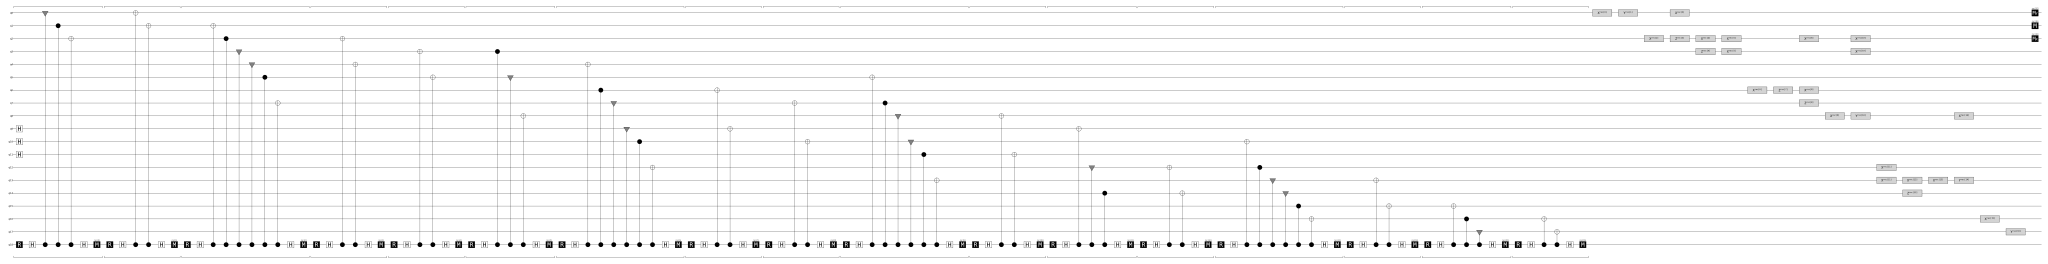

In [24]:
mdr.diagram('timeline-svg')

### Measuring X9 X10 X11- Noiseless

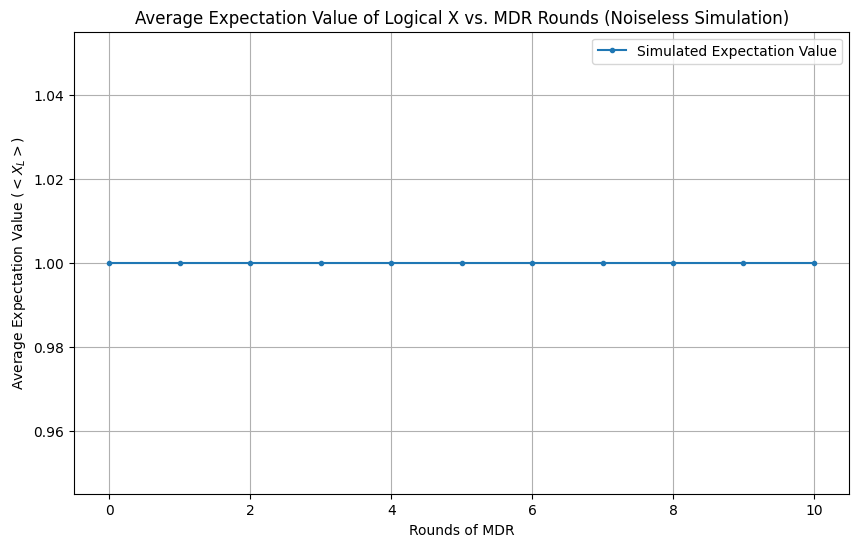

In [25]:
import matplotlib.pyplot as plt
import numpy as np  

psi= stim.Circuit()
psi.append_operation("H", list(range(9, 12)))

stabilizers = [
    "Y0 Z1 X2", "X0 X1", "X1 Z2 Y3 Y4 Z5 X7",
    "X2 X4", "X3 X5", "Z3 Y5 X8",
    "X4 Z6 Y7 Y9 Z10 X12", "X6 X9", "X7 X10",
    "X5 Z7 Y8 Y10 Z11 X13", "X8 X11",
    "X9 Y12 Z14", "X12 X14",
    "X10 Z12 Y13 Y14 Z15 X16",
    "X13 X15", "X15 Z16 Y17", "X16 X17", "X9 X10 X11"
]
toggles = [
    "X0", "Y0", "X2", "X0 Z2", "X2 Z3", "X2 X3",
    "X6", "Z6", "X2 X6 Z7", "X8", "X2 X3 Y8",
    "X12 X13", "X13 Z14", "X13", "X8 Y13", "X16",
    "Y17", "X2 X3 Y8 Z11"
]

MDR = MDRCircuit(
  stabilizers=stabilizers,
  toggles=toggles,
  ancillas=1,
  p_spam = 0,
  p_x=0, p_y=0, p_z=0,
  g1_x=0, g1_y=0, g1_z=0,
  gate_noise_2q=[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
  psi_circuit=psi,
)

mdr_circuit = MDR.build(include_psi=True)

rounds = 10

avg_expectation_values = []
rounds_mdr = list(range(rounds + 1))

for x in range(rounds + 1):
  if x == 0:
    noiseless_mdr_circuit = MDR.psi() 

    noiseless_mdr_circuit.append_operation("MX",9)
    noiseless_mdr_circuit.append_operation("MX",10)
    noiseless_mdr_circuit.append_operation("MX",11)

    sanity_samples=noiseless_mdr_circuit.compile_sampler().sample(shots=1000, bit_packed=False)
    sanity_samples_logicalX_measurement = sanity_samples[:, -3:]  
    sanity_samples_logicalX_measurement_sums = np.sum(sanity_samples_logicalX_measurement, axis=1) % 2
    expectation_eigenvalues = 1-2 * sanity_samples_logicalX_measurement_sums
    avg_expectation = np.mean(expectation_eigenvalues)
    avg_expectation_values.append(avg_expectation)

  else:
    noiseless_mdr_circuit = mdr_circuit * x
    noiseless_mdr_circuit.append_operation("MX",9)
    noiseless_mdr_circuit.append_operation("MX",10)
    noiseless_mdr_circuit.append_operation("MX",11)

    sanity_samples=noiseless_mdr_circuit.compile_sampler().sample(shots=1000, bit_packed=False)
    sanity_samples_logicalX_measurement = sanity_samples[:, -3:]  
    sanity_samples_logicalX_measurement_sums = np.sum(sanity_samples_logicalX_measurement, axis=1) % 2
    expectation_eigenvalues = 1-2 * sanity_samples_logicalX_measurement_sums
    avg_expectation = np.mean(expectation_eigenvalues)
    avg_expectation_values.append(avg_expectation)


noiseless_mdr_circuit.diagram('timeline-svg')
plt.figure(figsize=(10, 6))
plt.plot(rounds_mdr, avg_expectation_values, marker='.', linestyle='-', label='Simulated Expectation Value')
plt.title('Average Expectation Value of Logical X vs. MDR Rounds (Noiseless Simulation)')
plt.xlabel('Rounds of MDR')
plt.ylabel('Average Expectation Value ($<X_L>$)')
plt.grid(True)
#plt.ylim(0.95, 1.05) # Zoom in on 1.0 for clarity
plt.legend()
plt.show()



### Measuring Y0 Z1 X2 Noiseless

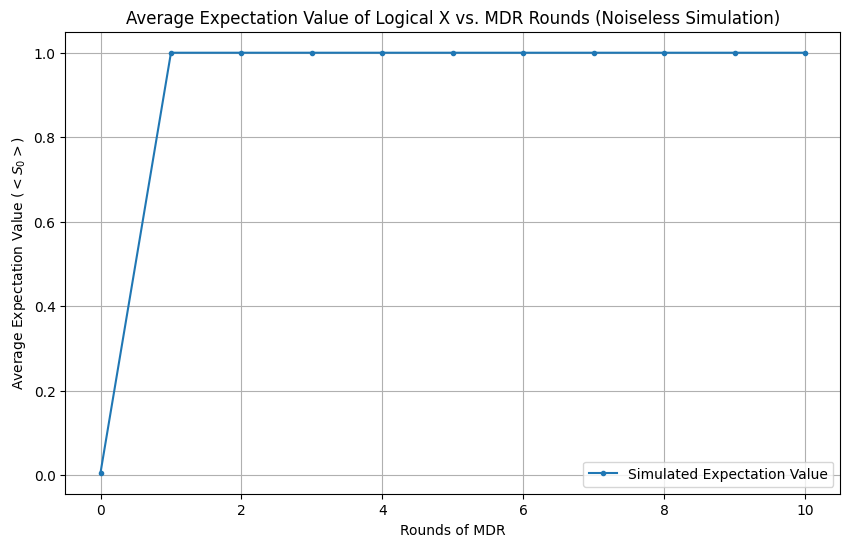

In [26]:
psi= stim.Circuit()
psi.append_operation("H", list(range(9, 12)))

MDR = MDRCircuit(
  stabilizers=stabilizers,
  toggles=toggles,
  ancillas=1,
  p_spam = 0,
  p_x=0, p_y=0, p_z=0,
  g1_x=0, g1_y=0, g1_z=0,
  gate_noise_2q=[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
  psi_circuit=psi,
)

mdr_circuit = MDR.build(include_psi=True)

rounds = 10

avg_expectation_values = []
rounds_mdr = list(range(rounds + 1))

for x in range(rounds + 1):
  if x == 0:
    noiseless_mdr_circuit = MDR.psi() 

    noiseless_mdr_circuit.append_operation("MY",0)
    noiseless_mdr_circuit.append_operation("MZ",1)
    noiseless_mdr_circuit.append_operation("MX",2)

    sanity_samples=noiseless_mdr_circuit.compile_sampler().sample(shots=1000, bit_packed=False)
    sanity_samples_stabilizer_measurement = sanity_samples[:, -3:]  
    sanity_samples_stabilizer_measurement_sums = np.sum(sanity_samples_stabilizer_measurement, axis=1) % 2
    expectation_eigenvalues = 1-2 * sanity_samples_stabilizer_measurement_sums
    avg_expectation = np.mean(expectation_eigenvalues)
    avg_expectation_values.append(avg_expectation)

  else:
    noiseless_mdr_circuit = mdr_circuit * x
    noiseless_mdr_circuit.append_operation("MY",0)
    noiseless_mdr_circuit.append_operation("MZ",1)
    noiseless_mdr_circuit.append_operation("MX",2)

    sanity_samples=noiseless_mdr_circuit.compile_sampler().sample(shots=1000, bit_packed=False)
    sanity_samples_stabilizer_measurement = sanity_samples[:, -3:]  
    sanity_samples_stabilizer_measurement_sums = np.sum(sanity_samples_stabilizer_measurement, axis=1) % 2
    expectation_eigenvalues = 1-2 * sanity_samples_stabilizer_measurement_sums
    avg_expectation = np.mean(expectation_eigenvalues)
    avg_expectation_values.append(avg_expectation)


noiseless_mdr_circuit.diagram('timeline-svg')
plt.figure(figsize=(10, 6))
plt.plot(rounds_mdr, avg_expectation_values, marker='.', linestyle='-', label='Simulated Expectation Value')
plt.title('Average Expectation Value of Logical X vs. MDR Rounds (Noiseless Simulation)')
plt.xlabel('Rounds of MDR')
plt.ylabel('Average Expectation Value ($<S_0>$)')
plt.grid(True)
#plt.ylim(0.95, 1.05) # Zoom in on 1.0 for clarity
plt.legend()
plt.show()





### Measuring X9 X10 X11 - Noisy

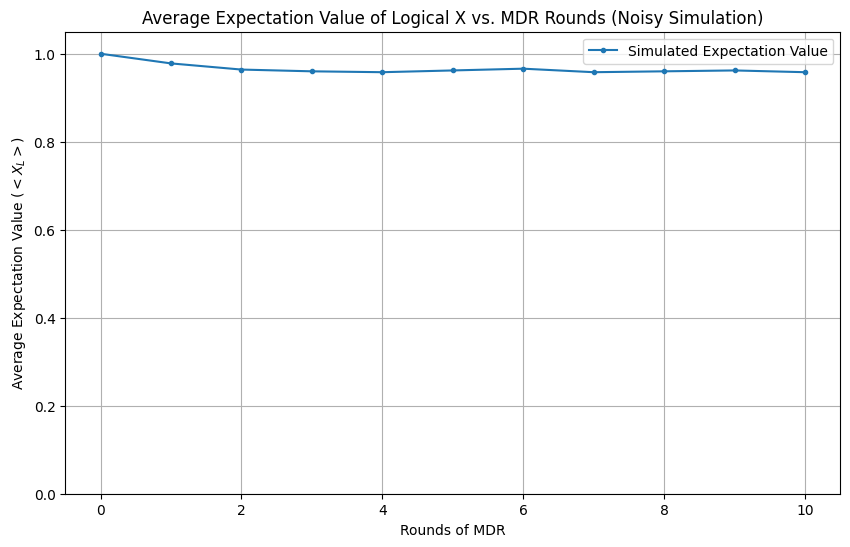

In [27]:
psi= stim.Circuit()
psi.append_operation("H", list(range(9, 12)))

MDR = MDRCircuit(
  stabilizers=stabilizers,
  toggles=toggles,  
  ancillas=1,
  p_spam = 1.339e-3,
  p_x=1e-4, p_y=1e-4, p_z=1e-4,
  g1_x=5e-5, g1_y=5e-5, g1_z=4e-4,
  gate_noise_2q=[5e-5,5e-5,4e-4,5e-5,0,0,0,5e-5,0,0,0,4e-4,0,0,0],
  psi_circuit=psi,
)


mdr_circuit = MDR.build(include_psi=True)

rounds = 10

avg_expectation_values = []
rounds_mdr = list(range(rounds + 1))

for x in range(rounds + 1):
  if x == 0:
    noisy_mdr_circuit = MDR.psi() 

    noisy_mdr_circuit.append_operation("MX",9)
    noisy_mdr_circuit.append_operation("MX",10)
    noisy_mdr_circuit.append_operation("MX",11)

    sanity_samples=noisy_mdr_circuit.compile_sampler().sample(shots=1000, bit_packed=False)
    sanity_samples_logicalX_measurement = sanity_samples[:, -3:]  
    sanity_samples_logicalX_measurement_sums = np.sum(sanity_samples_logicalX_measurement, axis=1) % 2
    expectation_eigenvalues = 1-2 * sanity_samples_logicalX_measurement_sums
    avg_expectation = np.mean(expectation_eigenvalues)
    avg_expectation_values.append(avg_expectation)

  else:
    noisy_mdr_circuit = mdr_circuit * x
    noisy_mdr_circuit.append_operation("MX",9)
    noisy_mdr_circuit.append_operation("MX",10)
    noisy_mdr_circuit.append_operation("MX",11)

    sanity_samples=noisy_mdr_circuit.compile_sampler().sample(shots=1000, bit_packed=False)
    sanity_samples_logicalX_measurement = sanity_samples[:, -3:]  
    sanity_samples_logicalX_measurement_sums = np.sum(sanity_samples_logicalX_measurement, axis=1) % 2
    expectation_eigenvalues = 1-2 * sanity_samples_logicalX_measurement_sums
    avg_expectation = np.mean(expectation_eigenvalues)
    avg_expectation_values.append(avg_expectation)


noisy_mdr_circuit.diagram('timeline-svg')
plt.figure(figsize=(10, 6))
plt.plot(rounds_mdr, avg_expectation_values, marker='.', linestyle='-', label='Simulated Expectation Value')
plt.title('Average Expectation Value of Logical X vs. MDR Rounds (Noisy Simulation)')
plt.xlabel('Rounds of MDR')
plt.ylabel('Average Expectation Value ($<X_L>$)')
plt.grid(True)
plt.ylim(0.0, 1.05) # Zoom in on 1.0 for clarity
plt.legend()
plt.show()

### Measuring Y0 Z1 X2 - Noisy

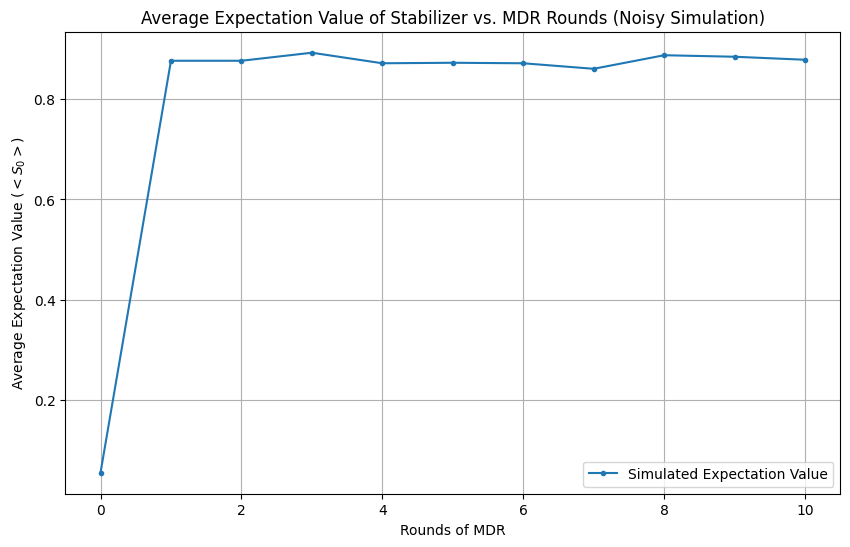

In [28]:
psi= stim.Circuit()
psi.append_operation("H", list(range(9, 12)))

MDR= MDRCircuit(
  stabilizers=stabilizers, 
  toggles=toggles,
  ancillas=1,
  p_spam = 1.339e-3,
  p_x=4e-4, p_y=4e-4, p_z=1e-4,
  g1_x=5e-5, g1_y=5e-5, g1_z=4e-4,
  gate_noise_2q=[5e-5,5e-5,4e-4,5e-5,0,0,0,5e-5,0,0,0,4e-4,0,0,0],
  psi_circuit=psi,
)

mdr_circuit = MDR.build(include_psi=True)

rounds = 10

avg_expectation_values = []
rounds_mdr = list(range(rounds + 1))

for x in range(rounds + 1):
  if x == 0:
    noisy_mdr_circuit = MDR.psi() 

    noisy_mdr_circuit.append_operation("MY",0)
    noisy_mdr_circuit.append_operation("MZ",1)
    noisy_mdr_circuit.append_operation("MX",2)

    sanity_samples=noisy_mdr_circuit.compile_sampler().sample(shots=1000, bit_packed=False)
    sanity_samples_stabilizer_measurement = sanity_samples[:, -3:]  
    sanity_samples_stabilizer_measurement_sums = np.sum(sanity_samples_stabilizer_measurement, axis=1) % 2
    expectation_eigenvalues = 1-2 * sanity_samples_stabilizer_measurement_sums
    avg_expectation = np.abs(np.mean(expectation_eigenvalues))
    avg_expectation_values.append(avg_expectation)

  else:
    noisy_mdr_circuit = mdr_circuit * x
    noisy_mdr_circuit.append_operation("MY",0)
    noisy_mdr_circuit.append_operation("MZ",1)
    noisy_mdr_circuit.append_operation("MX",2)

    sanity_samples=noisy_mdr_circuit.compile_sampler().sample(shots=2000, bit_packed=False)
    sanity_samples_stabilizer_measurement = sanity_samples[:, -3:]  
    sanity_samples_stabilizer_measurement_sums = np.sum(sanity_samples_stabilizer_measurement, axis=1) % 2
    expectation_eigenvalues = 1-2 * sanity_samples_stabilizer_measurement_sums
    avg_expectation = np.abs(np.mean(expectation_eigenvalues))
    avg_expectation_values.append(avg_expectation)


noisy_mdr_circuit.diagram('timeline-svg')
plt.figure(figsize=(10, 6))
plt.plot(rounds_mdr, avg_expectation_values, marker='.', linestyle='-', label='Simulated Expectation Value')
plt.title('Average Expectation Value of Stabilizer vs. MDR Rounds (Noisy Simulation)')
plt.xlabel('Rounds of MDR')
plt.ylabel('Average Expectation Value ($<S_0>$)')
plt.grid(True)
#plt.ylim(0.95, 1.05) # Zoom in on 1.0 for clarity
plt.legend()
plt.show()

## MDR Simulation

In [11]:
"""
mdr_simulation.py
────────────────────────────────────────────────────────────────────────
Encapsulates measurement-based decoding & recovery (MDR) utilities in the
MDRSimulation class, with precomputed violin-distribution overlays of
absolute mean-estimates and detailed uncertainty reporting.
"""

import stim                                 # Stim: quantum circuit simulator
import numpy as np                         # NumPy: numerical computing
import matplotlib.pyplot as plt            # Matplotlib: plotting library
from typing import Callable, List, Tuple, Dict, Mapping, Union, Optional

class MDRSimulation:
    """
    Tools for simulating Measurement-based Decoding & Recovery (MDR).

    This class precomputes, for each specified stabilizer and logical
    operator, the distribution of absolute mean-estimates obtained by
    repeating an N-shot experiment (`shots_per_measurement`) `num_replicates`
    times per MDR round (0…`total_mdr_rounds`), and caches both the full
    replicate lists (for violin plots) and summary statistics (mean ±
    sample-stddev). It also computes an overall average expectation per
    operator (mean of the per-round means).

    Once initialized, `plot_group()` and `results()` render or print the
    precomputed data instantly. For on-demand, single-run curves,
    `plot_expectation()` and `plot_many_expectations()` sample fresh circuits
    and can overlay violins of the replicate-mean distributions if desired.

    Attributes:
        prepare_circuit_function (Callable[[], stim.Circuit]):
            Factory returning a fresh stim.Circuit to prepare the initial state.
        mdr_circuit (stim.Circuit):
            stim.Circuit template implementing one round of MDR.
        stabilizer_pauli_strings (List[str]):
            Sparse Pauli-string specifications for stabilizer measurements.
        logical_pauli_strings (Dict[str, str]):
            Mapping from logical operator labels to sparse Pauli specs.
        shots_per_measurement (int):
            Number of Monte-Carlo samples per expectation estimate.
        total_mdr_rounds (int):
            Maximum number of MDR rounds to simulate (inclusive of round 0).
        num_replicates (int):
            Number of independent N-shot repeats per round for violin
            distributions.
        last_results_storage (Dict[str,Dict[str,Tuple[List[int],List[float]]]]):
            Backward-compatible single-run mean-value curves.
        _replicate_means_stabilizers (Dict[str,Dict[int,List[float]]]):
            Raw lists of absolute replicate-mean estimates per stabilizer &
            round.
        _replicate_means_logicals (Dict[str,Dict[int,List[float]]]):
            Raw lists of absolute replicate-mean estimates per logical & round.
        _stats_stabilizers (Dict[str,Dict[str,List[float]]]):
            Summary statistics for each stabilizer:
            `'rounds'`, `'centers'` (means), and `'stds'` (sample-stddevs).
        _stats_logicals (Dict[str,Dict[str,List[float]]]):
            Summary statistics for each logical operator.
        _avg_stabilizers (Dict[str, float]):
            Overall average expectation per stabilizer (mean of `'centers'`).
        _avg_logicals (Dict[str, float]):
            Overall average expectation per logical operator.

    Methods:
        spec_to_measurement_ops(pauli_spec: str) -> List[Tuple[str,int]]:
            Convert a sparse Pauli string (e.g. "X0 Z1") into a list of
            stim measurement operations [(gate, qubit_index), …].

        compute_parity_expectation(circuit, measurement_ops) -> float:
            Append the given measurement operations to `circuit`, sample
            `shots_per_measurement` bit-strings, compute the parity product
            of the measured bits, map to ±1 eigenvalues, and return the
            absolute mean |⟨O⟩|.

        calculate_replicated_means_vs_rounds(pauli_spec: str)
            -> Dict[int, List[float]]:
            For each MDR round r, build the circuit with r rounds, then run
            `num_replicates` independent N-shot experiments. Return a mapping
            {r → [|mean₁|, |mean₂|, …]} of all replicate absolute-mean values.

        calculate_expectation_vs_rounds(pauli_spec: str)
            -> (List[int], List[float]):
            For each MDR round r, build the circuit and perform a single
            N-shot experiment. Return two lists: the round indices and
            the corresponding |⟨O⟩| estimates.

        calculate_many_expectations(spec_map: Mapping[str,str])
            -> Dict[str, (List[int],List[float])]:
            Apply `calculate_expectation_vs_rounds` to each Pauli spec in
            `spec_map`, returning a dict label → (rounds, means).

        calculate_group_data() -> Dict[str,Dict[str,(List[int],List[float])]]:
            Return the precomputed single-run mean-value curves stored in
            `last_results_storage` (for backward compatibility).

        plot_data(data_map, title, x_label, y_label, **kwargs) -> None:
            Generic renderer for precomputed violin distributions:
              • Plots only markers (no connecting lines) for the summary means.
              • Overlays violins of the replicate-mean distributions, with
                mean & extrema lines, all colored to match each marker.
              • Optionally scatters every replicate point inside its violin.
              • Handles saving to disk if `save_path` is provided.

        plot_expectation(pauli_specification=None, save_path=None, **kw) -> None:
            Single-operator plotting: if no spec is given, plots all
            stabilizers; if a string is given, plots that one; if a list
            is given, plots each. Delegates to `plot_data` (optionally adding
            violins) but uses fresh single-run sampling, not the precomputed
            cache.

        plot_many_expectations(pauli_specs, save_path=None, **kw) -> None:
            Multi-operator plotting: takes either a list of Pauli strings or a
            mapping label→spec, performs fresh single-run sampling for each,
            then delegates to `plot_data`.

        plot_group(save_path_stabilizers=None, save_path_logicals=None, **kw)
            -> None:
            Render two figures—one for all stabilizers, one for all logicals—
            using the precomputed violin distributions and summary means.
            Saves each figure if a corresponding `save_path_*` is provided.

        results() -> None:
            Print tabular, precomputed statistics for each operator:
              Round | Mean | StdDev
            followed by the overall average expectation for that operator.
    """

    def __init__(
        self,
        mdr: MDRCircuit,
        stabilizer_pauli_strings: List[str],
        logical_pauli_strings: Dict[str, str],
        shots_per_measurement: int = 1000,
        total_mdr_rounds: int = 10,
        num_replicates: int = 30
    ) -> None:
        """
        Initialize MDRSimulation and precompute all distributions, stats, and
        averages.

        Args:
            mdr (MDRCircuit):
                MDRCircuit instance containing the circuit preparation
            stabilizer_pauli_strings (List[str]):
                List of sparse stabilizer Pauli specifications.
            logical_pauli_strings (Dict[str, str]):
                Dictionary mapping logical labels to Pauli specifications.
            shots_per_measurement (int, optional):
                Number of shots per expectation estimate. Default is 1000.
            total_mdr_rounds (int, optional):
                Number of MDR rounds (inclusive of 0). Default is 10.
            num_replicates (int, optional):
                Number of repeats per round for violin distributions. Default 30.

        Returns:
            None
        """
        # Store MDR Class
        self.mdr = mdr
        # Store the circuit preparation function
        self.prepare_circuit_function = mdr.psi
        # Store the MDR circuit template
        self.mdr_circuit = mdr.build(include_psi=False)
        # Store SPAM noise parameter
        self.p_spam = mdr.p_spam
        # Store the list of stabilizer Pauli strings
        self.stabilizer_pauli_strings = stabilizer_pauli_strings
        # Store the dictionary of logical Pauli strings
        self.logical_pauli_strings = logical_pauli_strings
        # Store the number of shots per measurement
        self.shots_per_measurement = shots_per_measurement
        # Store the total number of MDR rounds
        self.total_mdr_rounds = total_mdr_rounds
        # Store the number of replicates per round
        self.num_replicates = num_replicates

        # Precompute replicate-means for stabilizers
        self._replicate_means_stabilizers: \
            Dict[str, Dict[int, List[float]]] ={}
        for spec in self.stabilizer_pauli_strings:
            # For each stabilizer, compute replicate means vs rounds
            self._replicate_means_stabilizers[spec] = \
                self.calculate_replicated_means_vs_rounds(spec)

        # Precompute replicate-means for logicals
        self._replicate_means_logicals: Dict[str, Dict[int, List[float]]] = {}
        for label, spec in self.logical_pauli_strings.items():
            # For each logical, compute replicate means vs rounds
            self._replicate_means_logicals[label] = \
                self.calculate_replicated_means_vs_rounds(spec)

        # Summarize stats and compute overall averages for stabilizers
        self._stats_stabilizers: Dict[str, Dict[str, List[float]]] = {}
        self._avg_stabilizers: Dict[str, float] = {}
        for spec, dist_map in self._replicate_means_stabilizers.items():
            # Sort rounds for consistent plotting
            rounds = sorted(dist_map)
            # Compute mean for each round
            centers = [float(np.mean(dist_map[r])) for r in rounds]
            # Compute stddev for each round
            stds    = [float(np.std(dist_map[r], ddof=1)) for r in rounds]
            # Store stats for this stabilizer
            self._stats_stabilizers[spec] = {
                'rounds': rounds, 'centers': centers, 'stds': stds
            }
            # Store overall average for this stabilizer
            self._avg_stabilizers[spec] = float(np.mean(centers))

        # Summarize stats and compute overall averages for logicals
        self._stats_logicals: Dict[str, Dict[str, List[float]]] = {}
        self._avg_logicals: Dict[str, float] = {}
        for label, dist_map in self._replicate_means_logicals.items():
            # Sort rounds for consistent plotting
            rounds = sorted(dist_map)
            # Compute mean for each round
            centers = [float(np.mean(dist_map[r])) for r in rounds]
            # Compute stddev for each round
            stds    = [float(np.std(dist_map[r], ddof=1)) for r in rounds]
            # Store stats for this logical
            self._stats_logicals[label] = {
                'rounds': rounds, 'centers': centers, 'stds': stds
            }
            # Store overall average for this logical
            self._avg_logicals[label] = float(np.mean(centers))

        # Backward-compatible single-run curves
        self.last_results_storage = {
            'stabilizers': {
                spec: (
                    self._stats_stabilizers[spec]['rounds'],
                    self._stats_stabilizers[spec]['centers']
                )
                for spec in self.stabilizer_pauli_strings
            },
            'logicals': {
                label: (
                    self._stats_logicals[label]['rounds'],
                    self._stats_logicals[label]['centers']
                )
                for label in self.logical_pauli_strings
            }
        }

    @staticmethod
    def spec_to_measurement_ops(pauli_specification: str) -> List[Tuple[str, int]]:
        """
        Convert a sparse Pauli string (e.g. "X0 Z1") into Stim measurement ops.

        Args:
            pauli_specification (str): Sparse Pauli string, e.g., "X0 Z1".

        Returns:
            List[Tuple[str, int]]: List of tuples (gate, qubit index), e.g.,
            [("MX", 0), ("MZ", 1)].
        """
        ops: List[Tuple[str, int]] = []
        for term in pauli_specification.split():
            # Extract Pauli letter and qubit index
            p = term[0].upper()
            q = int(term[1:])
            # Map Pauli letter to Stim measurement gate
            gate_map = {'X': 'MX', 'Y': 'MY', 'Z': 'MZ'}
            if p not in gate_map:
                # Raise error if invalid Pauli letter
                raise ValueError(f"Invalid Pauli letter: {p}")
            # Append (gate, qubit) tuple to ops list
            ops.append((gate_map[p], q))
        return ops

    def compute_parity_expectation(
        self,
        circuit: stim.Circuit,
        measurement_ops: List[Tuple[str, int]]
    ) -> float:
        """
        Append measurement_ops to the circuit, sample, and compute |⟨O⟩|.

        Args:
            circuit (stim.Circuit): Circuit to which measurement ops are added.
            measurement_ops (List[Tuple[str, int]]): List of (gate, qubit) to
            measure.

        Returns:
            float: Absolute mean of the ±1 parity outcomes.
        """
        for gate, qubit in measurement_ops:
            #add SPAM noise if applicable
            if self.p_spam > 0:
                circuit += \
                    stim.Circuit(f"PAULI_CHANNEL_1({self.p_spam},0,0) {qubit}")
            # Append each measurement operation to the circuit
            circuit.append_operation(gate, qubit)
        #display(SVG(str(circuit.diagram('timeline-svg'))))

        # Compile the circuit into a sampler
        sampler = circuit.compile_sampler()
        # Sample bit-strings from the circuit
        samples = sampler.sample(shots=self.shots_per_measurement,
                                 bit_packed=False)
        # Select columns corresponding to the measured qubits
        cols = np.arange(-len(measurement_ops), 0)
        # Compute parity for each shot
        parity = np.sum(samples[:, cols], axis=1) % 2
        # Map parity to ±1 eigenvalues
        eigen = 1 - 2 * parity
        # Return the absolute mean of eigenvalues
        return abs(np.mean(eigen))

    def calculate_replicated_means_vs_rounds(
        self,
        pauli_specification: str
    ) -> Dict[int, List[float]]:
        """
        For each round r, repeat the N-shot experiment `num_replicates` times
        and collect the absolute mean eigenvalue of each replicate.

        Args:
            pauli_specification (str): Sparse Pauli string to measure.

        Returns:
            Dict[int, List[float]]: Mapping from round index to list of replicate
            means.
        """
        # Convert Pauli string to measurement operations
        measurement_ops  = self.spec_to_measurement_ops(pauli_specification)
        # Initialize dictionary to store replicate means per round
        dist_map: Dict[int, List[float]] = {}
        for r in range(self.total_mdr_rounds + 1):
            # Prepare the base circuit for this round
            base = self.prepare_circuit_function()
            if r > 0:
                # Add r rounds of MDR circuit if r > 0
                base += self.mdr_circuit * r
            replicate_means: List[float] = []

            for _ in range(self.num_replicates):
                # Copy the base circuit for each replicate
                circ = base.copy()
                absolute_eigen = \
                    self.compute_parity_expectation(circ, measurement_ops)
                # Append absolute mean to replicate_means
                replicate_means.append(absolute_eigen)
            # Store replicate means for this round
            dist_map[r] = replicate_means
        return dist_map

    def calculate_expectation_vs_rounds(
        self,
        pauli_specification: str
    ) -> Tuple[List[int], List[float]]:
        """
        Single-run N-shot estimate of |⟨O⟩| vs round (no replicates).

        Args:
            pauli_specification (str): Sparse Pauli string to measure.

        Returns:
            Tuple[List[int], List[float]]: (List of rounds, List of mean values
            per round)
        """
        # Convert Pauli string to measurement operations
        ops = self.spec_to_measurement_ops(pauli_specification)
        # Initialize lists to store rounds and means
        rounds, means = [], []
        for r in range(self.total_mdr_rounds + 1):
            # Prepare the circuit for this round
            circ = self.prepare_circuit_function()
            if r > 0:
                # Add r rounds of MDR circuit if r > 0
                circ += self.mdr_circuit * r
            # Compute the parity expectation
            m = self.compute_parity_expectation(circ, ops)
            # Append round index and mean value
            rounds.append(r)
            means.append(m)
        return rounds, means

    def calculate_many_expectations(
        self,
        spec_map: Mapping[str, str]
    ) -> Dict[str, Tuple[List[int], List[float]]]:
        """
        Compute single-run curves for multiple Pauli specs.

        Args:
            spec_map (Mapping[str, str]): Mapping from label to Pauli spec.

        Returns:
            Dict[str, Tuple[List[int], List[float]]]: Mapping label → (rounds,
            means).
        """
        # Initialize output dictionary
        out: Dict[str, Tuple[List[int], List[float]]] = {}
        for label, spec in spec_map.items():
            # Compute expectation vs rounds for each Pauli spec
            out[label] = self.calculate_expectation_vs_rounds(spec)
        return out

    def calculate_group_data(self) -> Dict[str, Dict[str, Tuple[List[int],
        List[float]]]]:
        """
        Return precomputed single-run mean-value data (backward-compat).

        Returns:
            Dict[str, Dict[str, Tuple[List[int], List[float]]]]:
                Dictionary with keys 'stabilizers' and 'logicals', each mapping
                to a dictionary of label → (rounds, means).
        """
        # Return the last results storage dictionary
        return self.last_results_storage


    def plot_data(
        self,
        data_map: Dict[str, Tuple[List[int], List[float]]],
        title: str,
        x_label: str,
        y_label: str,
        *,
        legend_location: str = 'upper left',
        bbox_to_anchor: Tuple[float, float] = (1.02, 1),
        save_path: str = None,
        show_violin: bool = True,
        violin_kwargs: Dict = None,
        **legend_kwargs
    ) -> None:
        """
        Generic plotting of expectation-vs-rounds curves with unique Tab10
        colors and block-wise marker changes every 10 curves.

        This function visualizes the evolution of expectation values (e.g.,
        |⟨O⟩|) across MDR rounds for multiple operators. Each operator is
        assigned a distinct color from the Tab10 palette, and markers are
        cycled every 10 curves for clarity. If precomputed replicate
        distributions are available, violin plots are overlaid to show the
        spread of replicate means, with mean and extrema lines colored to
        match the corresponding marker. Individual replicate points can also
        be scattered within each violin for additional detail. The function
        supports saving the resulting figure to disk and customizing legend
        placement and violin plot appearance.

        Args:
            data_map (Dict[str, Tuple[List[int], List[float]]]):
            Mapping from operator label to (round indices, mean values).
            title (str): Title for the plot.
            x_label (str): Label for the x-axis.
            y_label (str): Label for the y-axis.
            legend_location (str, optional): Location of the legend. Default is
            'upper left'.
            bbox_to_anchor (Tuple[float, float], optional): Anchor point for
            the legend. Default is (1.02, 1).
            save_path (str, optional): If provided, saves the figure to this
            path.
            show_violin (bool, optional): Whether to overlay violin plots for
            replicate distributions. Default is True.
            violin_kwargs (Dict, optional): Additional keyword arguments for
            the violin plot.
            **legend_kwargs: Additional keyword arguments for the legend.

        Returns:
            None
        """
        fig, ax = plt.subplots(figsize=(10, 6))

        # Tab10 has 10 distinct colours
        colours = plt.rcParams['axes.prop_cycle'].by_key()['color'][::2]
        # extra markers for blocks beyond the first 10
        extra_markers = ['s','^','D','v','p','*','h','+','x','1']
        block_size = len(colours)  # 10

        for idx, label in enumerate(data_map):
            # pick the Tab10 colour cyclically
            colour = colours[idx % block_size]

            # pick marker by block:
            #   curves 0–9    → 'o'
            #   curves 10–19  → extra_markers[0]
            #   curves 20–29  → extra_markers[1], etc.
            if idx < block_size:
                marker = 'o'
            else:
                block = (idx // block_size) - 1
                marker = extra_markers[block % len(extra_markers)]

            # detect whether we have precomputed stats+distributions
            if hasattr(self, '_stats_stabilizers') and label in self._stats_stabilizers:
                dist_map = self._replicate_means_stabilizers[label]
                stats    = self._stats_stabilizers[label]
                rounds   = stats['rounds']
                centers  = stats['centers']
                dists    = [dist_map[r] for r in rounds]
            elif hasattr(self, '_stats_logicals') and label in self._stats_logicals:
                dist_map = self._replicate_means_logicals[label]
                stats    = self._stats_logicals[label]
                rounds   = stats['rounds']
                centers  = stats['centers']
                dists    = [dist_map[r] for r in rounds]
            else:
                # fresh single-run data: just (rounds, centers)
                rounds, centers = data_map[label]
                dists = None

            # plot the mean-points
            ax.plot(
                rounds,
                centers,
                marker=marker,
                linestyle='None',
                color=colour,
                label=label
            )

            # optionally overlay violins & replicate scatter
            if show_violin and dists is not None:
                vp = ax.violinplot(
                    dists,
                    positions=rounds,
                    showmeans=True,
                    showextrema=True,
                    showmedians=False,
                    **(violin_kwargs or {})
                )
                # colour the violin bodies
                for body in vp['bodies']:
                    body.set_facecolor(colour)
                    body.set_edgecolor(colour)
                    body.set_alpha(0.3)
                # colour the mean/extrema lines
                for key in ('cmeans','cmaxes','cmins','cbars'):
                    lines = vp[key]
                    if isinstance(lines, list):
                        for ln in lines:
                            ln.set_color(colour)
                            ln.set_linewidth(1.5)
                    else:
                        lines.set_color(colour)
                        lines.set_linewidth(2 if key == 'cmeans' else 1.5)
                # scatter all replicates
                for r, vals in zip(rounds, dists):
                    ax.scatter([r]*len(vals), vals,
                               color=colour, alpha=0.05, s=4)

        # finalize
        ax.set_title(title, fontsize=18)
        ax.set_xlabel(x_label, fontsize=16)
        ax.set_ylabel(y_label, fontsize=16)
        ax.legend(loc=legend_location,
                  bbox_to_anchor=bbox_to_anchor,
                  fontsize='small',
                  **legend_kwargs)
        ax.grid(True)
        fig.tight_layout()

        if save_path:
            fig.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

        
    def plot_expectation(
        self,
        pauli_specification: Union[str, List[str]] = None,
        save_path: str = None,
        **plot_kwargs
    ) -> None:
        """
        Bespoke single-operator plotting: computes a fresh single-run curve,
        then delegates to plot_data.

        Args:
            pauli_specification (Union[str, List[str]], optional):
                Pauli specification(s) to plot. If None, uses all stabilizers.
            save_path (str, optional): If provided, saves the figure to this path.
            **plot_kwargs: Additional keyword arguments for plot_data.

        Returns:
            None
        """
        if pauli_specification is None:
            # Use all stabilizers if no specification is given
            specs = self.stabilizer_pauli_strings
        elif isinstance(pauli_specification, str):
            # Wrap single string in a list
            specs = [pauli_specification]
        else:
            # Use the provided list of specifications
            specs = pauli_specification

        # Create a mapping from spec to itself for labeling
        spec_map = {s: s for s in specs}
        # Compute data for each specification
        data = self.calculate_many_expectations(spec_map)

        # Plot the data using plot_data
        self.plot_data(data,
                       title='|⟨O⟩| vs MDR rounds',
                       x_label='MDR rounds',
                       y_label='|⟨O⟩|',
                       save_path=save_path,
                       **plot_kwargs)

    def plot_many_expectations(
        self,
        pauli_specifications: Union[List[str], Mapping[str, str]],
        save_path: str = None,
        **plot_kwargs
    ) -> None:
        """
        Bespoke multi-operator plotting: computes fresh single-run curves,
        then delegates to plot_data.

        Args:
            pauli_specifications (Union[List[str], Mapping[str, str]]):
                List or mapping of Pauli specifications to plot.
            save_path (str, optional): If provided, saves the figure to this path.
            **plot_kwargs: Additional keyword arguments for plot_data.

        Returns:
            None
        """
        if isinstance(pauli_specifications, Mapping):
            # Use values from mapping if provided
            specs = list(pauli_specifications.values())
        else:
            # Use the provided list of specifications
            specs = pauli_specifications

        # Create a mapping from spec to itself for labeling
        spec_map = {s: s for s in specs}
        # Compute data for each specification
        data = self.calculate_many_expectations(spec_map)

        # Plot the data using plot_data
        self.plot_data(data,
                       title='|⟨O⟩| vs MDR rounds',
                       x_label='MDR rounds',
                       y_label='|⟨O⟩|',
                       save_path=save_path,
                       **plot_kwargs)

    def plot_group(
        self,
        save_path_stabilizers: str = None,
        save_path_logicals: str = None,
        **plot_kwargs
    ) -> None:
        """
        Render precomputed grouped violins & markers (no lines) for all
        stabilizers and logicals. Saves figures if paths are provided.

        Args:
            save_path_stabilizers (str, optional): Path to save stabilizer plot.
            save_path_logicals (str, optional): Path to save logicals plot.
            **plot_kwargs: Additional keyword arguments for plot_data.

        Returns:
            None
        """
        # Plot all stabilizers using precomputed data
        self.plot_data(self.last_results_storage['stabilizers'],
                       title='|⟨S⟩| vs MDR rounds (stabilizers)',
                       x_label='MDR rounds',
                       y_label='|⟨S⟩|',
                       save_path=save_path_stabilizers,
                       **plot_kwargs)
        # Plot all logicals using precomputed data
        self.plot_data(self.last_results_storage['logicals'],
                       title='|⟨L⟩| vs MDR rounds (logicals)',
                       x_label='MDR rounds',
                       y_label='|⟨L⟩|',
                       save_path=save_path_logicals,
                       **plot_kwargs)

    @staticmethod
    def plot_multi_fidelity(
        sims: Dict[str, 'MDRSimulation'],
        category: str,
        operators: Optional[Union[str, List[str]]] = None,
        *,
        show_violin: bool = True,
        show_replicates: bool = False,
        figsize: Tuple[int,int] = (16, 8),
        save_path: Optional[str] = None
    ) -> None:
        """
        Compare ⟨|O|⟩ vs MDR round across multiple MDRSimulation instances.
        Plots only isolated markers with ±1σ error‐bars, plus optional
        violin + replicate overlays.  Supports 'stabilizer', 'logical', or 'both'.

        Args:
            sims:            Mapping label → MDRSimulation (one column per).
            category:        'stabilizer', 'logical', or 'both'.
            operators:       None (all), a single str, or a list of str.
            show_violin:     If True, overlay violin plots.
            show_replicates: If True, scatter individual replicate points.
            figsize:         Figure size (width, height) in inches.
            save_path:       If provided, save figure (dpi=300).

        Raises:
            ValueError: If `sims` is empty, or `category` invalid,
                        or any `operators` not found.
        """
        import matplotlib.pyplot as plt
        import numpy as np
        import math

        if not sims:
            raise ValueError("No simulations provided")

        # determine rows
        if category == 'both':
            cats = ['stabilizer', 'logical']
        elif category in ('stabilizer', 'logical'):
            cats = [category]
        else:
            raise ValueError("category must be 'stabilizer', 'logical' or 'both'")

        # collect which ops go in each row
        ops_dict: Dict[str, List[str]] = {}
        for cat in cats:
            first = next(iter(sims.values()))
            stats_attr = '_stats_stabilizers' if cat=='stabilizer' else '_stats_logicals'
            all_ops = list(getattr(first, stats_attr).keys())

            # select subset
            if operators is None:
                ops = all_ops
            elif isinstance(operators, str):
                ops = [operators]
            else:
                ops = operators[:]
            missing = set(ops) - set(all_ops)
            if missing:
                raise ValueError(f"Unknown operators for {cat}: {missing}")
            ops_dict[cat] = ops

        # build one global style map so no repeats across rows
        colours = plt.rcParams['axes.prop_cycle'].by_key()['color']
        markers = ['o','s','^','v','<','>','8','p','P','*','h','H',
                   '+','x','X','D','d','|','_','.']
        global_ops = sum((ops_dict[cat] for cat in cats), [])
        style_map: Dict[str, Tuple[str,str]] = {}
        for i, op in enumerate(global_ops):
            c = colours[i % len(colours)]
            m = markers[(i // len(colours)) % len(markers)]
            style_map[op] = (c, m)

        # set up figure
        nrows = len(cats)
        ncols = len(sims)
        fig, axes = plt.subplots(
            nrows, ncols,
            figsize=figsize,
            squeeze=False,
            sharex='col'
        )

        # collect legend handles
        legend_entries: Dict[str, plt.Line2D] = {}

        # plot each cell
        for row, cat in enumerate(cats):
            stats_attr = '_stats_stabilizers' if cat=='stabilizer' else '_stats_logicals'
            dist_attr  = '_replicate_means_stabilizers' if cat=='stabilizer' else '_replicate_means_logicals'
            ylabel     = '|⟨S⟩|' if cat=='stabilizer' else '|⟨L⟩|'
            ops = ops_dict[cat]

            for col, (label, sim) in enumerate(sims.items()):
                ax = axes[row][col]
                if row == 0:
                    ax.set_title(label, fontsize=18)
                ax.grid(True)

                stats_map = getattr(sim, stats_attr)
                dist_map  = getattr(sim, dist_attr)

                for op in ops:
                    rounds  = stats_map[op]['rounds']
                    centers = stats_map[op]['centers']
                    stds    = stats_map[op]['stds']
                    c, m    = style_map[op]

                    eb = ax.errorbar(
                        rounds, centers,
                        yerr=stds,
                        fmt=m,             # marker only
                        color=c,
                        capsize=3,
                        linestyle='None',
                        label=op,
                        zorder=3
                    )
                    line = eb.lines[0]  # matplotlib>=3.7

                    # record for shared legend
                    if op not in legend_entries:
                        legend_entries[op] = line

                    if show_violin:
                        data = [dist_map[op][r] for r in rounds]
                        vp = ax.violinplot(
                            data,
                            positions=rounds,
                            widths=0.6,
                            showmeans=False,
                            showextrema=False
                        )
                        for body in vp['bodies']:
                            body.set_facecolor(c)
                            body.set_edgecolor(c)
                            body.set_alpha(0.2)

                    if show_replicates:
                        for r in rounds:
                            ax.scatter(
                                [r]*len(dist_map[op][r]),
                                dist_map[op][r],
                                color=c,
                                alpha=0.05,
                                s=4,
                                zorder=2
                            )

                if col == 0:
                    ax.set_ylabel(ylabel, fontsize=16)
                if row == nrows - 1:
                    ax.set_xlabel("MDR rounds", fontsize=16)

        # single legend beside the grid
        handles = list(legend_entries.values())
        labels  = list(legend_entries.keys())
        fig.legend(
            handles, labels,
            loc='center left',
            bbox_to_anchor=(0.93, 0.5),
            fontsize=16,
        )

        # make room for legend
        fig.tight_layout(rect=[0, 0, 0.935, 1.0])

        if save_path:
            fig.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()


    
    def results(self) -> None:
        """
        Print precomputed tabular statistics (round | mean | stddev)
        and overall average expectation for each operator.

        Args:
            None

        Returns:
            None
        """
        for category, (stats_map, avg_map) in (
            ('stabilizers', (self._stats_stabilizers, self._avg_stabilizers)),
            ('logicals',    (self._stats_logicals,    self._avg_logicals))
        ):
            # Print category header
            print(f"=== {category.upper()} ===")
            for label, stats in stats_map.items():
                # Print label header
                print(f"-- {label} --")
                print(f"{'Round':>5} | {'Mean':>7} | {'StdDev':>7}")
                print("-----+---------+--------")
                for r, m, s in zip(stats['rounds'], stats['centers'],
                                   stats['stds']):
                    # Print round, mean, and stddev for each round
                    print(f"{r:5d} | {m:7.4f} | {s:7.4f}")
                # Print overall average for this operator
                print(f"Avg across rounds: {avg_map[label]:.4f}\n")

    
    def tau_table(
        self,
        category: str,
        *,
        ignore_round0: bool = True,
        return_dict: bool = False,
        precision: int = 4,
        label: Optional[str] = None
    ):
        """
        Compute and display per-round across-operator dispersion τ_r and mean μ_r.

        Definitions (for the chosen category):
            For each round r let the set of replicate-mean fidelities across
            operators be { m_{k,r} }_{k=1}^K, where m_{k,r} is the plotted mean
            for operator k at round r (already stored in stats['centers']).

            μ_r  = (1/K) Σ_k m_{k,r}
            τ_r  = sqrt( Σ_k (m_{k,r} - μ_r)^2 / (K-1) )  (sample std across operators)

        We report:
            * Per-round μ_r and τ_r.
            * Average τ across rounds (excluding r=0 if requested).
            * Average μ across rounds (excluding r=0 if requested).
            * Both also including round 0 for reference.

        Args:
            category (str):
                'stabilizer' or 'logical'.
            ignore_round0 (bool, optional):
                Exclude round 0 from the averages (default True).
            return_dict (bool, optional):
                If True, return a dict of computed quantities.
            precision (int, optional):
                Number of decimal places in printed table.
            label (str, optional):
                Optional label (e.g. noise model name) for header.

        Returns:
            Optional[Dict[str, Any]]:
                {
                  'rounds': [...],
                  'tau': [...],
                  'mu': [...],
                  'avg_tau_excluding_round0': float,
                  'avg_tau_including_round0': float,
                  'avg_mu_excluding_round0': float,
                  'avg_mu_including_round0': float
                } if return_dict=True, else None.

        Raises:
            ValueError: If category invalid.
        """
        import numpy as np

        if category not in ('stabilizer', 'logical'):
            raise ValueError("category must be 'stabilizer' or 'logical'")

        stats_map = self._stats_stabilizers if category == 'stabilizer' else self._stats_logicals

        first_stats = next(iter(stats_map.values()))
        rounds = first_stats['rounds']

        tau_list = []
        mu_list = []
        for idx_r, r in enumerate(rounds):
            vals_r = [op_stats['centers'][idx_r] for op_stats in stats_map.values()]
            arr = np.asarray(vals_r, dtype=float)
            mu_r = float(arr.mean())
            mu_list.append(mu_r)
            tau_r = float(arr.std(ddof=1)) if arr.size > 1 else 0.0
            tau_list.append(tau_r)

        # Slicing for averages
        if ignore_round0 and rounds and rounds[0] == 0:
            tau_ex = tau_list[1:]
            mu_ex  = mu_list[1:]
        else:
            tau_ex = tau_list
            mu_ex  = mu_list

        avg_tau_ex = float(np.mean(tau_ex)) if tau_ex else 0.0
        avg_tau_in = float(np.mean(tau_list)) if tau_list else 0.0
        avg_mu_ex  = float(np.mean(mu_ex)) if mu_ex else 0.0
        avg_mu_in  = float(np.mean(mu_list)) if mu_list else 0.0

        hdr_label = label if label is not None else "Simulation"
        print(f"\n=== τ_r & μ_r ({category}s) for {hdr_label} ===")
        print(f"{'Round':>5} | {'μ_r':>8} | {'τ_r':>8}")
        print("------+----------+----------")
        fmt = f"{{:5d}} | {{:{8}.{precision}f}} | {{:{8}.{precision}f}}"
        for r, mu_r, tau_r in zip(rounds, mu_list, tau_list):
            print(fmt.format(r, mu_r, tau_r))
        excl_txt = " (excl. round 0)" if ignore_round0 else ""
        print("-" * 36)
        print(f"Average τ{excl_txt}: {avg_tau_ex:.{precision}f}")
        print(f"Average τ (incl. round 0): {avg_tau_in:.{precision}f}")
        print(f"Average μ{excl_txt}: {avg_mu_ex:.{precision}f}")
        print(f"Average μ (incl. round 0): {avg_mu_in:.{precision}f}\n")

        if return_dict:
            return {
                'rounds': rounds,
                'tau': tau_list,
                'mu': mu_list,
                'avg_tau_excluding_round0': avg_tau_ex,
                'avg_tau_including_round0': avg_tau_in,
                'avg_mu_excluding_round0': avg_mu_ex,
                'avg_mu_including_round0': avg_mu_in
            }

    @staticmethod
    def compare_tau(
        sims: Dict[str, 'MDRSimulation'],
        category: str,
        *,
        ignore_round0: bool = True,
        precision: int = 4,
        return_table: bool = False
    ):
        """
        Compare average across-operator dispersion τ and average mean μ
        among multiple simulations.

        For each simulation and the chosen category:
           * Compute τ_r and μ_r per round.
           * Report averages excluding (optionally) round 0 and including it.

        Args:
            sims (Dict[str, MDRSimulation]):
                Mapping simulation label → instance.
            category (str):
                'stabilizer' or 'logical'.
            ignore_round0 (bool, optional):
                Exclude round 0 from averages (default True).
            precision (int, optional):
                Printing precision.
            return_table (bool, optional):
                If True, return list of row dicts.

        Returns:
            Optional[List[Dict[str, float]]]:
                Each row has: simulation, avg_tau, avg_tau_including_round0,
                avg_mu, avg_mu_including_round0 (if return_table=True).

        Raises:
            ValueError: If sims empty or category invalid.
        """
        import numpy as np

        if not sims:
            raise ValueError("No simulations provided")
        if category not in ('stabilizer', 'logical'):
            raise ValueError("category must be 'stabilizer' or 'logical'")

        rows = []
        for label, sim in sims.items():
            stats_map = sim._stats_stabilizers if category == 'stabilizer' else sim._stats_logicals
            first_stats = next(iter(stats_map.values()))
            rounds = first_stats['rounds']

            # Build per-round operator arrays
            per_round_vals = []
            for idx_r, r in enumerate(rounds):
                arr = np.array([op_stats['centers'][idx_r] for op_stats in stats_map.values()], dtype=float)
                per_round_vals.append(arr)

            tau_list = [float(arr.std(ddof=1)) if arr.size > 1 else 0.0 for arr in per_round_vals]
            mu_list  = [float(arr.mean()) for arr in per_round_vals]

            if ignore_round0 and rounds and rounds[0] == 0:
                tau_ex = tau_list[1:]
                mu_ex  = mu_list[1:]
            else:
                tau_ex = tau_list
                mu_ex  = mu_list

            avg_tau_ex = float(np.mean(tau_ex)) if tau_ex else 0.0
            avg_tau_in = float(np.mean(tau_list)) if tau_list else 0.0
            avg_mu_ex  = float(np.mean(mu_ex)) if mu_ex else 0.0
            avg_mu_in  = float(np.mean(mu_list)) if mu_list else 0.0

            rows.append({
                'simulation': label,
                'avg_tau': avg_tau_ex,
                'avg_tau_including_round0': avg_tau_in,
                'avg_mu': avg_mu_ex,
                'avg_mu_including_round0': avg_mu_in
            })

        excl = " (excl. round 0)" if ignore_round0 else ""
        print(f"\n=== Average τ and μ{excl} comparison ({category}s) ===")
        print(f"{'Simulation':<30} | {'avg τ':>10} | {'avg τ (incl r0)':>16} | {'avg μ':>10} | {'avg μ (incl r0)':>16}")
        print("-" * 94)
        for row in rows:
            print(f"{row['simulation']:<30} | "
                  f"{row['avg_tau']:{10}.{precision}f} | "
                  f"{row['avg_tau_including_round0']:{16}.{precision}f} | "
                  f"{row['avg_mu']:{10}.{precision}f} | "
                  f"{row['avg_mu_including_round0']:{16}.{precision}f}")
        print()

        if return_table:
            return rows


### MDR without Logical X Projection - No Idling Noise

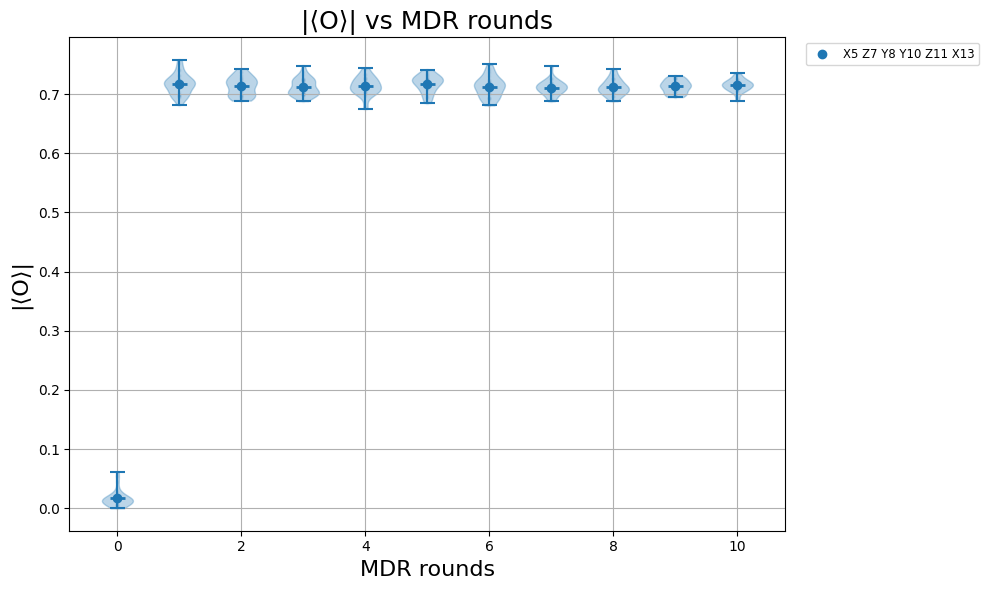

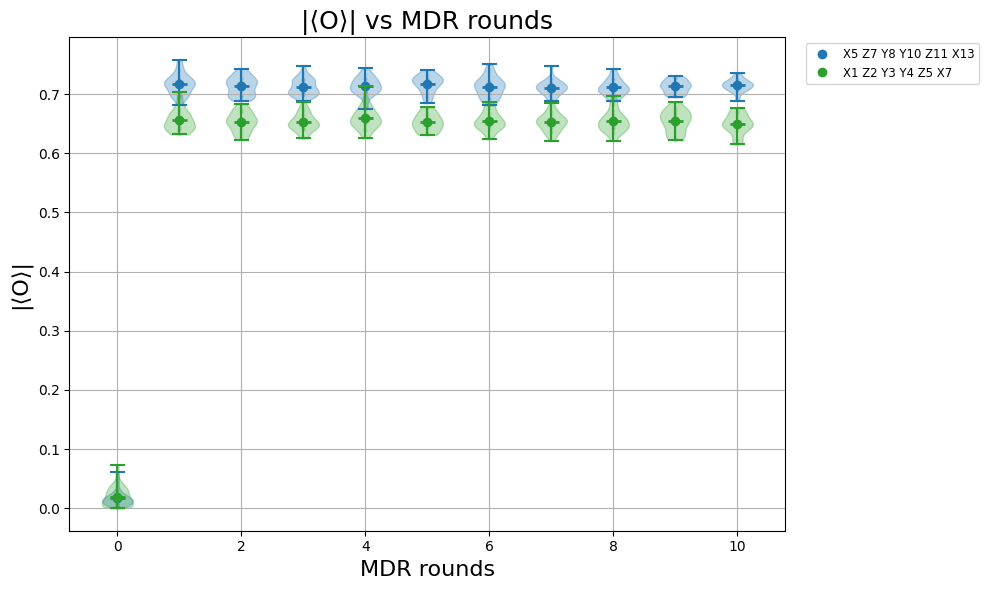

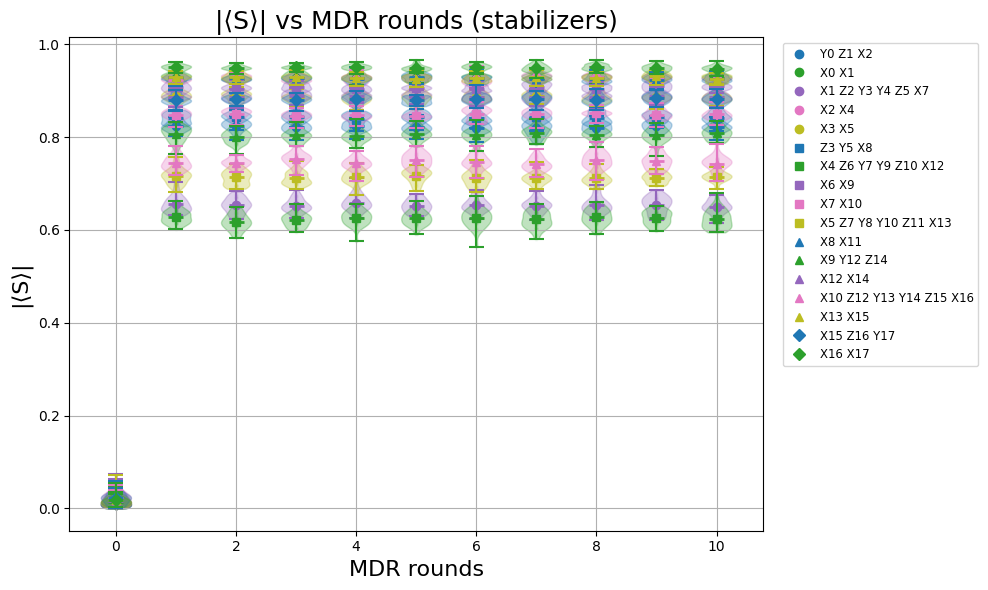

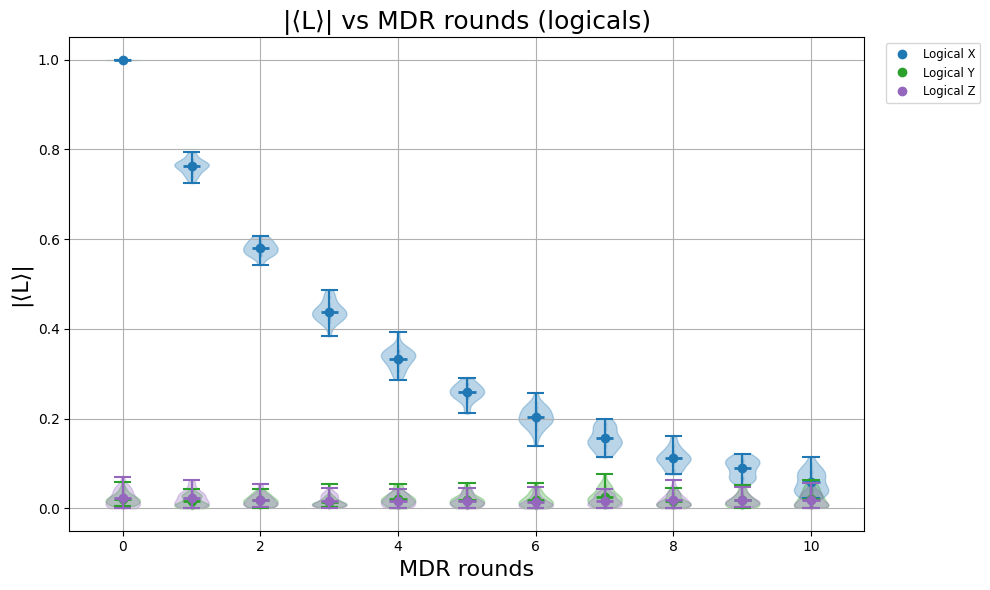

=== STABILIZERS ===
-- Y0 Z1 X2 --
Round |    Mean |  StdDev
-----+---------+--------
    0 |  0.0162 |  0.0138
    1 |  0.8237 |  0.0111
    2 |  0.8252 |  0.0120
    3 |  0.8217 |  0.0114
    4 |  0.8239 |  0.0101
    5 |  0.8223 |  0.0123
    6 |  0.8199 |  0.0125
    7 |  0.8191 |  0.0154
    8 |  0.8201 |  0.0120
    9 |  0.8240 |  0.0109
   10 |  0.8212 |  0.0124
Avg across rounds: 0.7489

-- X0 X1 --
Round |    Mean |  StdDev
-----+---------+--------
    0 |  0.0181 |  0.0143
    1 |  0.9281 |  0.0091
    2 |  0.9264 |  0.0081
    3 |  0.9285 |  0.0101
    4 |  0.9286 |  0.0078
    5 |  0.9286 |  0.0070
    6 |  0.9268 |  0.0083
    7 |  0.9287 |  0.0090
    8 |  0.9295 |  0.0071
    9 |  0.9297 |  0.0080
   10 |  0.9272 |  0.0070
Avg across rounds: 0.8455

-- X1 Z2 Y3 Y4 Z5 X7 --
Round |    Mean |  StdDev
-----+---------+--------
    0 |  0.0190 |  0.0167
    1 |  0.6558 |  0.0182
    2 |  0.6532 |  0.0163
    3 |  0.6522 |  0.0150
    4 |  0.6592 |  0.0186
    5 |  0.6524 |  0

In [30]:
# -------------------------------------------------------------
# make sure helpers (1)-(4) + the new (5) are in scope
# plus your psi() and MDR() definitions
# -------------------------------------------------------------

# -------------------------------------------------------------
# make sure helpers (1)-(4) + the new (5) are in scope
# plus your psi() and MDR() definitions
# -------------------------------------------------------------
stab = [
  "Y0 Z1 X2", "X0 X1", "X1 Z2 Y3 Y4 Z5 X7",
  "X2 X4", "X3 X5", "Z3 Y5 X8", "X4 Z6 Y7 Y9 Z10 X12",
  "X6 X9", "X7 X10", "X5 Z7 Y8 Y10 Z11 X13", "X8 X11",
  "X9 Y12 Z14", "X12 X14", "X10 Z12 Y13 Y14 Z15 X16",
  "X13 X15", "X15 Z16 Y17", "X16 X17"
]

toggles = [
  "X0", "Y0", "X2", "X0 Z2", "X2 Z3", "X2 X3", "X6", "Z6",
  "X2 X6 Z7", "X8", "X2 X3 Y8", "X12 X13", "X13 Z14", "X13",
  "X8 Y13", "X16", "Y17"
]

psi= stim.Circuit()
psi.append_operation("H", list(range(9, 12)))

MDR = MDRCircuit(
  stabilizers=stabilizers, toggles=toggles, ancillas=1,
  p_spam = 1.339e-3,
  p_x=0, p_y=0, p_z=0,
  g1_x=8e-5, g1_y=8e-5, g1_z=8e-5,
  gate_noise_2q=[1.4e-3,1.4e-3,1.4e-3,1.4e-3,1.4e-3,1.4e-3,1.4e-3,
                 1.4e-3,1.4e-3,1.4e-3,1.4e-3,1.4e-3,1.4e-3,1.4e-3,1.4e-3],
  psi_circuit=psi              
)

exp_value_stabilizers = [
  "Y0 Z1 X2", "X0 X1", "X1 Z2 Y3 Y4 Z5 X7",
  "X2 X4", "X3 X5", "Z3 Y5 X8", "X4 Z6 Y7 Y9 Z10 X12",
  "X6 X9", "X7 X10", "X5 Z7 Y8 Y10 Z11 X13", "X8 X11",
  "X9 Y12 Z14", "X12 X14", "X10 Z12 Y13 Y14 Z15 X16",
  "X13 X15", "X15 Z16 Y17", "X16 X17"
]

exp_value_logical_ops = {
  "Logical X": "X9 X10 X11",
  "Logical Y": "X4 Z7 Y10 X13",
  "Logical Z": "X4 Z7 X9 Z10 X13 X11",
}

sim = MDRSimulation(
  mdr=MDR,
  stabilizer_pauli_strings = exp_value_stabilizers,
  logical_pauli_strings = exp_value_logical_ops,
  shots_per_measurement = 2000,
  total_mdr_rounds = 10,
  num_replicates = 30
)

sim.plot_expectation("X5 Z7 Y8 Y10 Z11 X13")

sim.plot_many_expectations(
  ["X5 Z7 Y8 Y10 Z11 X13", "X1 Z2 Y3 Y4 Z5 X7"],
  save_path="many_violin.pdf"
)

sim.plot_group(
  save_path_stabilizers="stabs_no_logical_X_projection.pdf",
  save_path_logicals="logs_no_logical_X_projection.pdf",
)

sim.results()


### MDR with Logical X Projection - No Idling Noise


--- COORDINATION CHECK (d=3) ---
✅ All toggles coordinated successfully.
Preparing |+> state on Logical X qubits: [9, 10, 11]

Running Simulation (2000 shots, 10 rounds)...
Plotting expectation for stabilizer: X5 Z7 Y8 Y10 Z11 X13


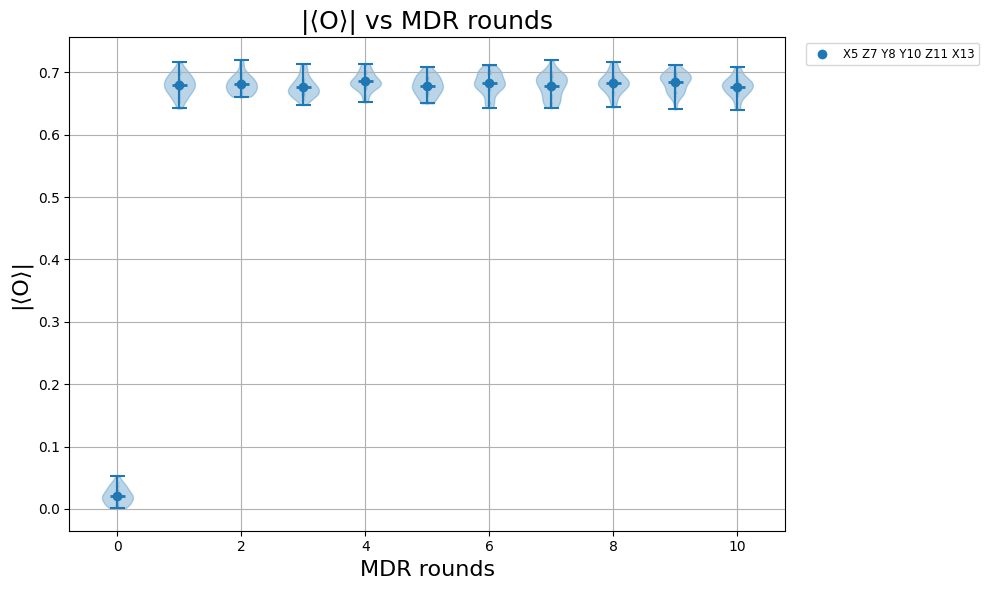

Generating Violin Plots...


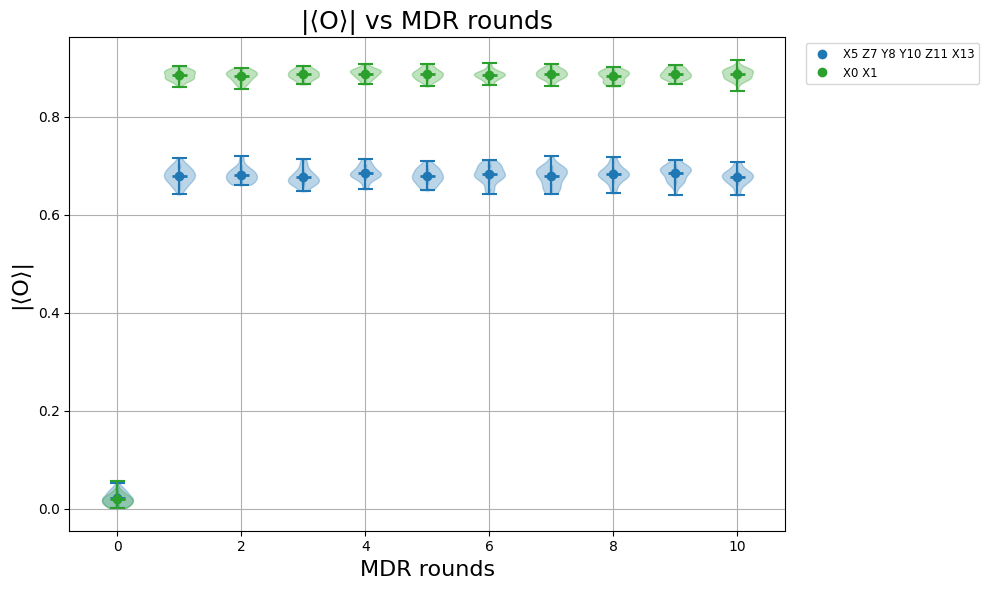

Generating Group Decay Plots...


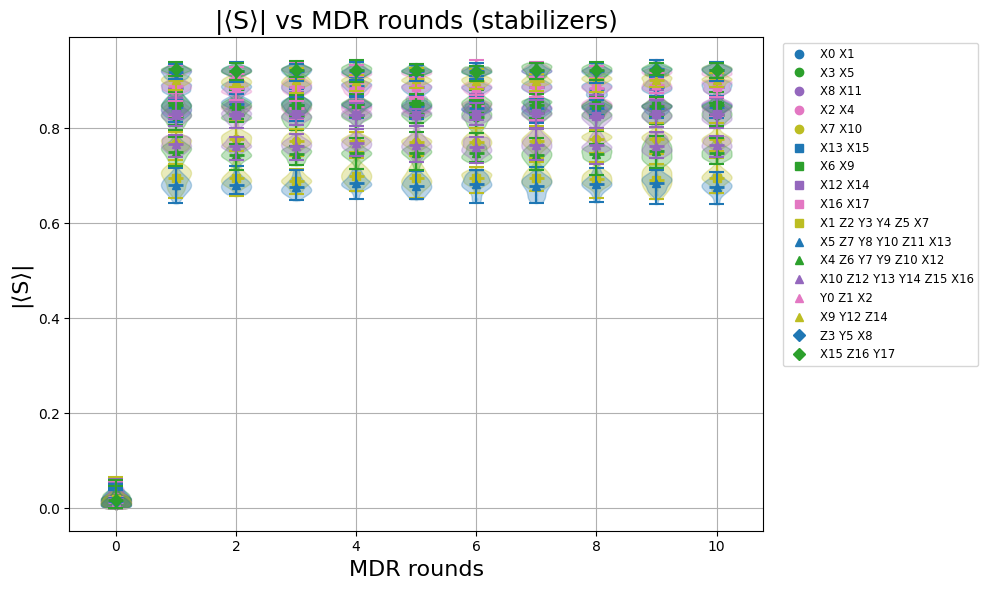

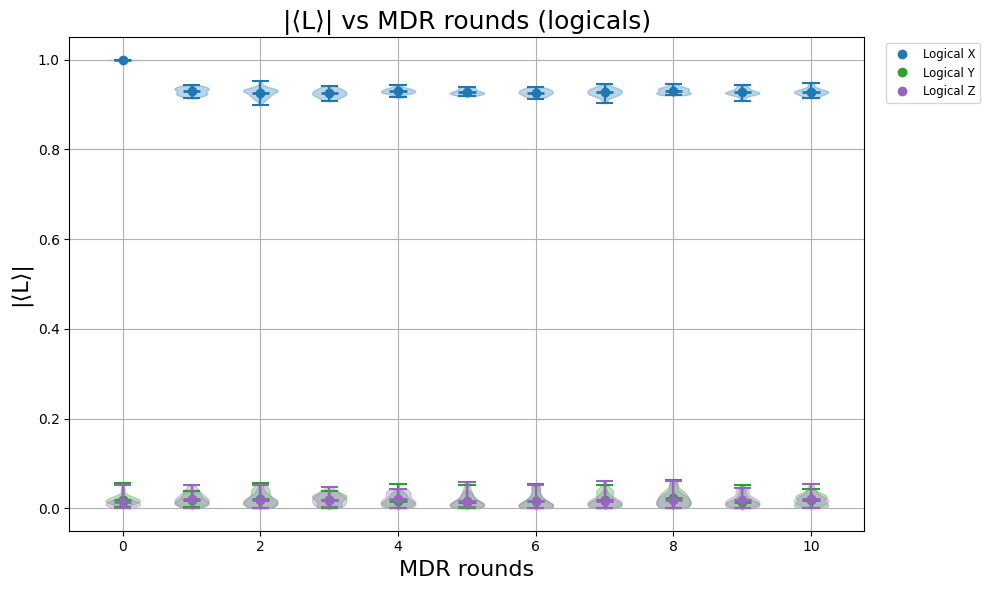


--- Final Results ---
=== STABILIZERS ===
-- X0 X1 --
Round |    Mean |  StdDev
-----+---------+--------
    0 |  0.0192 |  0.0123
    1 |  0.8847 |  0.0102
    2 |  0.8832 |  0.0112
    3 |  0.8865 |  0.0101
    4 |  0.8877 |  0.0100
    5 |  0.8862 |  0.0110
    6 |  0.8845 |  0.0100
    7 |  0.8877 |  0.0105
    8 |  0.8828 |  0.0110
    9 |  0.8872 |  0.0097
   10 |  0.8868 |  0.0120
Avg across rounds: 0.8070

-- X3 X5 --
Round |    Mean |  StdDev
-----+---------+--------
    0 |  0.0157 |  0.0118
    1 |  0.8237 |  0.0139
    2 |  0.8282 |  0.0099
    3 |  0.8248 |  0.0173
    4 |  0.8274 |  0.0117
    5 |  0.8297 |  0.0117
    6 |  0.8245 |  0.0166
    7 |  0.8324 |  0.0107
    8 |  0.8273 |  0.0135
    9 |  0.8292 |  0.0130
   10 |  0.8286 |  0.0125
Avg across rounds: 0.7538

-- X8 X11 --
Round |    Mean |  StdDev
-----+---------+--------
    0 |  0.0182 |  0.0129
    1 |  0.8488 |  0.0132
    2 |  0.8463 |  0.0083
    3 |  0.8493 |  0.0131
    4 |  0.8492 |  0.0107
    5 |  0.

In [188]:
import stim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. SETUP & VERIFICATION (d=3)
# ------------------------------------------------------------------
d = 3
n_qubits = 2 * d * d 

# A. Generate Physics
s_gen = XYZ2StabilizerGenerator(d)
l_gen = XYZ2LogicalGenerator(d)
stabs = s_gen.generate_stabilizers()
logs_dict = l_gen.generate_logicals()
log_x_str = logs_dict["Logical X"]

# B. Generate Toggles (Pass ALL logicals to find the conjugate pair)
all_logicals = list(logs_dict.values())
tg = RobustToggleGenerator(stabs, log_x_str, n_qubits)
stab_toggles, log_x_toggle = tg.generate_toggles()

# C. Create Master Lists for MDR
final_stabs   = stabs + [log_x_str]
final_toggles = stab_toggles + [log_x_toggle]

# D. Verification Helper
def verify_pair(s_str, t_str, n):
    def to_vec(op):
        x = np.zeros(n, dtype=int); z = np.zeros(n, dtype=int)
        for term in op.split():
            if not term: continue
            p, q = term[0], int(term[1:])
            if p in 'XY': x[q] = 1
            if p in 'ZY': z[q] = 1
        return x, z
    x1, z1 = to_vec(s_str); x2, z2 = to_vec(t_str)
    return (np.sum(x1 & z2) + np.sum(z1 & x2)) % 2

print(f"\n--- COORDINATION CHECK (d={d}) ---")
errors = 0
for i, (s, t) in enumerate(zip(final_stabs, final_toggles)):
    if verify_pair(s, t, n_qubits) != 1:
        print(f"❌ FAIL at index {i}: {s} vs {t}")
        errors += 1
if errors == 0:
    print("✅ All toggles coordinated successfully.")
else:
    raise ValueError("Stopping: Toggles are not coordinated.")

# ------------------------------------------------------------------
# 2. SIMULATION CONFIGURATION
# ------------------------------------------------------------------

# Prepare state |+> on Logical X qubits
lx_qubits = [int(q[1:]) for q in log_x_str.split()]
print(f"Preparing |+> state on Logical X qubits: {lx_qubits}")

psi_circuit = stim.Circuit()
psi_circuit.append_operation("H", lx_qubits)

# Define MDR Circuit (Unbiased Noise Model)
MDR = MDRCircuit(
    stabilizers=final_stabs, 
    toggles=final_toggles, 
    ancillas=1,
    p_spam=1.339e-3,
    # Single-qubit gates
    p_x=0, p_y=0, p_z=0, # Idle noise (set to 0 for this test)
    g1_x=8e-5, g1_y=8e-5, g1_z=8e-5,
    # Two-qubit gates (Assuming standard 15-param Pauli channel or Depolarizing)
    gate_noise_2q=[1.4e-3]*15,
    psi_circuit=psi_circuit             
)

# ------------------------------------------------------------------
# 3. RUN SIMULATION
# ------------------------------------------------------------------
print("\nRunning Simulation (2000 shots, 10 rounds)...")

sim_unbiased_noise = MDRSimulation(
    mdr=MDR,
    stabilizer_pauli_strings=stabs,        # Only measure stabilizers
    logical_pauli_strings=logs_dict,       # Measure logicals for tracking
    shots_per_measurement=2000,
    total_mdr_rounds=10,
    num_replicates=30
)

# ------------------------------------------------------------------
# 4. GENERATE PLOTS
# ------------------------------------------------------------------

# Plot 1: Expectation value of a specific stabilizer
# (We pick one from the bulk if possible, e.g., index 10)
target_stab = stabs[10] 
print(f"Plotting expectation for stabilizer: {target_stab}")
sim_unbiased_noise.plot_expectation(
    target_stab, 
    save_path="d3_expectation_single.pdf"
)

# Plot 2: Violin Plots for distribution of multiple stabilizers
print("Generating Violin Plots...")
# Pick two distinct stabilizers to compare
target_stabs_list = [stabs[10], stabs[0]] 
sim_unbiased_noise.plot_many_expectations(
    target_stabs_list,
    save_path="d3_violin_plot.pdf"
)

# Plot 3: Group Decay (Stabilizers vs Logicals)
print("Generating Group Decay Plots...")
sim_unbiased_noise.plot_group(
    save_path_stabilizers="d3_group_stabilizers.pdf",
    save_path_logicals="d3_group_logicals.pdf",
)

# Print Final Results Summary
print("\n--- Final Results ---")
# Calling the .results() method if it prints a summary
sim_unbiased_noise.results()

# Optional: Visualize Circuit
# display_circuit = sim_unbiased_noise.mdr_circuit.copy()
# display_circuit.diagram('timeline-svg')

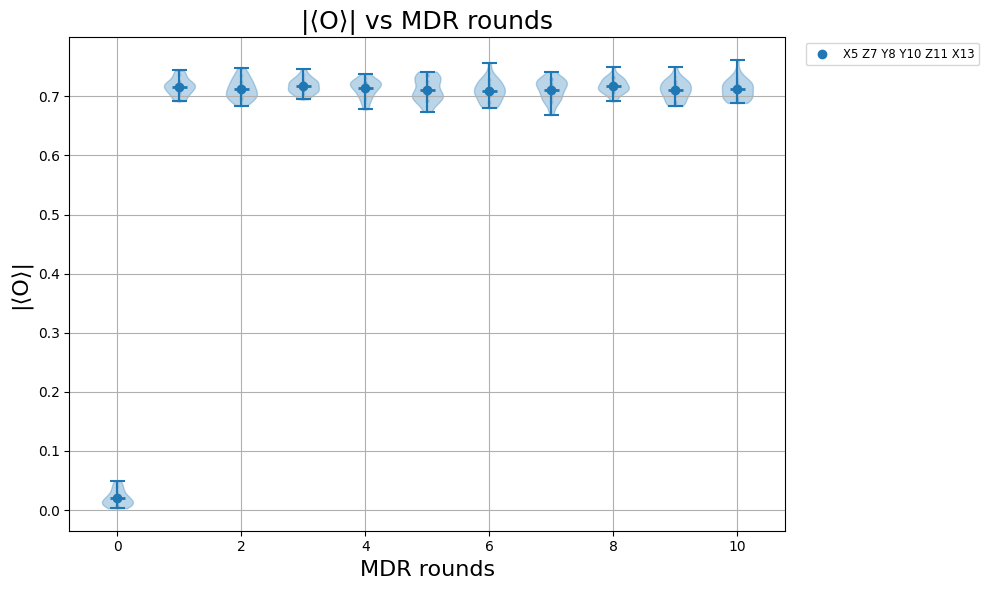

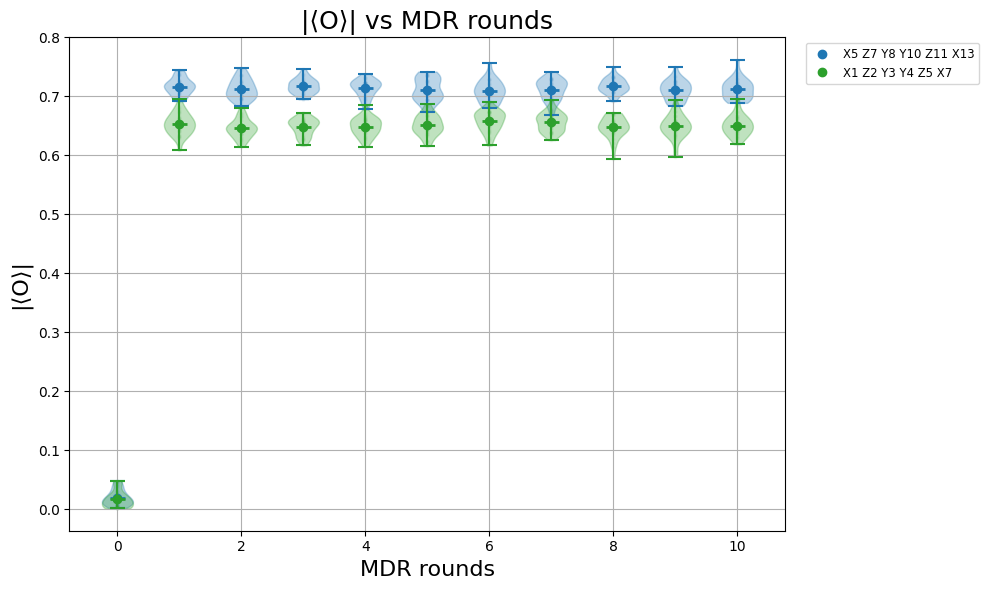

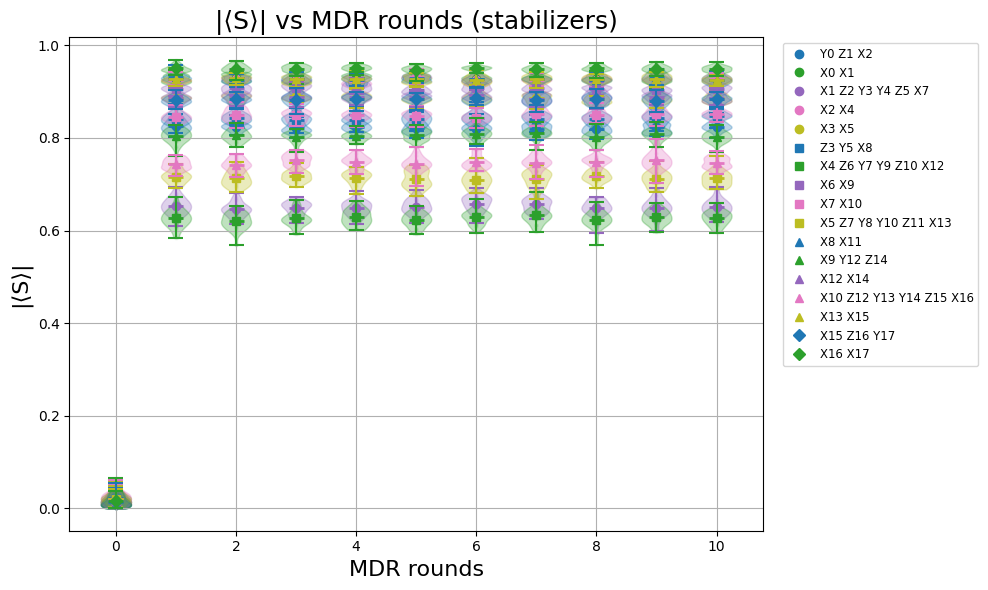

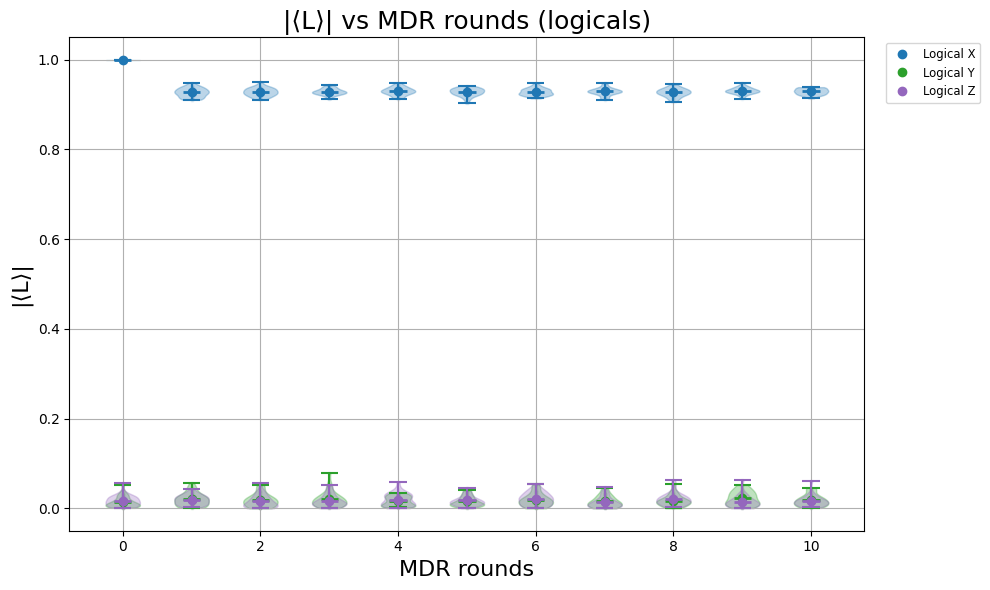

=== STABILIZERS ===
-- Y0 Z1 X2 --
Round |    Mean |  StdDev
-----+---------+--------
    0 |  0.0156 |  0.0111
    1 |  0.8251 |  0.0137
    2 |  0.8244 |  0.0101
    3 |  0.8218 |  0.0111
    4 |  0.8236 |  0.0117
    5 |  0.8217 |  0.0124
    6 |  0.8193 |  0.0149
    7 |  0.8199 |  0.0125
    8 |  0.8202 |  0.0114
    9 |  0.8227 |  0.0132
   10 |  0.8248 |  0.0108
Avg across rounds: 0.7490

-- X0 X1 --
Round |    Mean |  StdDev
-----+---------+--------
    0 |  0.0149 |  0.0131
    1 |  0.9282 |  0.0092
    2 |  0.9306 |  0.0083
    3 |  0.9279 |  0.0086
    4 |  0.9290 |  0.0092
    5 |  0.9267 |  0.0089
    6 |  0.9267 |  0.0083
    7 |  0.9281 |  0.0073
    8 |  0.9269 |  0.0085
    9 |  0.9269 |  0.0093
   10 |  0.9261 |  0.0103
Avg across rounds: 0.8447

-- X1 Z2 Y3 Y4 Z5 X7 --
Round |    Mean |  StdDev
-----+---------+--------
    0 |  0.0176 |  0.0147
    1 |  0.6534 |  0.0182
    2 |  0.6458 |  0.0154
    3 |  0.6488 |  0.0146
    4 |  0.6487 |  0.0156
    5 |  0.6517 |  0

In [189]:
# -------------------------------------------------------------
# make sure helpers (1)-(4) + the new (5) are in scope
# plus your psi() and MDR() definitions
# -------------------------------------------------------------
stabilizers_and_logical_X = [
  "Y0 Z1 X2", "X0 X1", "X1 Z2 Y3 Y4 Z5 X7",
  "X2 X4", "X3 X5", "Z3 Y5 X8", "X4 Z6 Y7 Y9 Z10 X12",
  "X6 X9", "X7 X10", "X5 Z7 Y8 Y10 Z11 X13", "X8 X11",
  "X9 Y12 Z14", "X12 X14", "X10 Z12 Y13 Y14 Z15 X16",
  "X13 X15", "X15 Z16 Y17", "X16 X17", "X9 X10 X11"
]

toggles = [
    "X0", "Y0", "X2", "X0 Z2", "X2 Z3", "X2 X3",
    "X6", "Z6", "X2 X6 Z7", "X8", "X2 X3 Y8",
    "X12 X13", "X13 Z14", "X13", "X8 Y13",
    "X16", "Y17", "X2 X3 Y8 Z11"
]


psi_circuit= stim.Circuit()
psi_circuit.append_operation("H", list(range(9, 12)))

MDR = MDRCircuit(
  stabilizers=stabilizers_and_logical_X, toggles=toggles, ancillas=1,
  p_spam = 1.339e-3,
  p_x=0, p_y=0, p_z=0,
  g1_x=8e-5, g1_y=8e-5, g1_z=8e-5,
  gate_noise_2q=[1.4e-3,1.4e-3,1.4e-3,1.4e-3,1.4e-3,1.4e-3,1.4e-3,
                 1.4e-3,1.4e-3,1.4e-3,1.4e-3,1.4e-3,1.4e-3,1.4e-3,1.4e-3],
  psi_circuit=psi             
)

exp_value_stabilizers = [
  "Y0 Z1 X2", "X0 X1", "X1 Z2 Y3 Y4 Z5 X7",
  "X2 X4", "X3 X5", "Z3 Y5 X8", "X4 Z6 Y7 Y9 Z10 X12",
  "X6 X9", "X7 X10", "X5 Z7 Y8 Y10 Z11 X13", "X8 X11",
  "X9 Y12 Z14", "X12 X14", "X10 Z12 Y13 Y14 Z15 X16",
  "X13 X15", "X15 Z16 Y17", "X16 X17"
]

exp_value_logical_ops = {
  "Logical X": "X9 X10 X11",
  "Logical Y": "X4 Z7 Y10 X13",
  "Logical Z": "X4 Z7 X9 Z10 X13 X11",
}


sim_unbiased_noise = MDRSimulation(
  mdr=MDR,
  stabilizer_pauli_strings = exp_value_stabilizers,
  logical_pauli_strings = exp_value_logical_ops,
  shots_per_measurement = 2000,
  total_mdr_rounds = 10,
  num_replicates = 30
)

sim_unbiased_noise.plot_expectation("X5 Z7 Y8 Y10 Z11 X13")

sim_unbiased_noise.plot_many_expectations(
  ["X5 Z7 Y8 Y10 Z11 X13", "X1 Z2 Y3 Y4 Z5 X7"],
  save_path="many_violin.pdf"
)

sim_unbiased_noise.plot_group(
  save_path_stabilizers="stabs.pdf",
  save_path_logicals="logs.pdf",
)

sim_unbiased_noise.results()

display_circuit = sim_unbiased_noise.mdr_circuit.copy()

display_circuit.diagram('timeline-svg')

### MDR with Single qubit and 2 qubit gate Z Type Noise

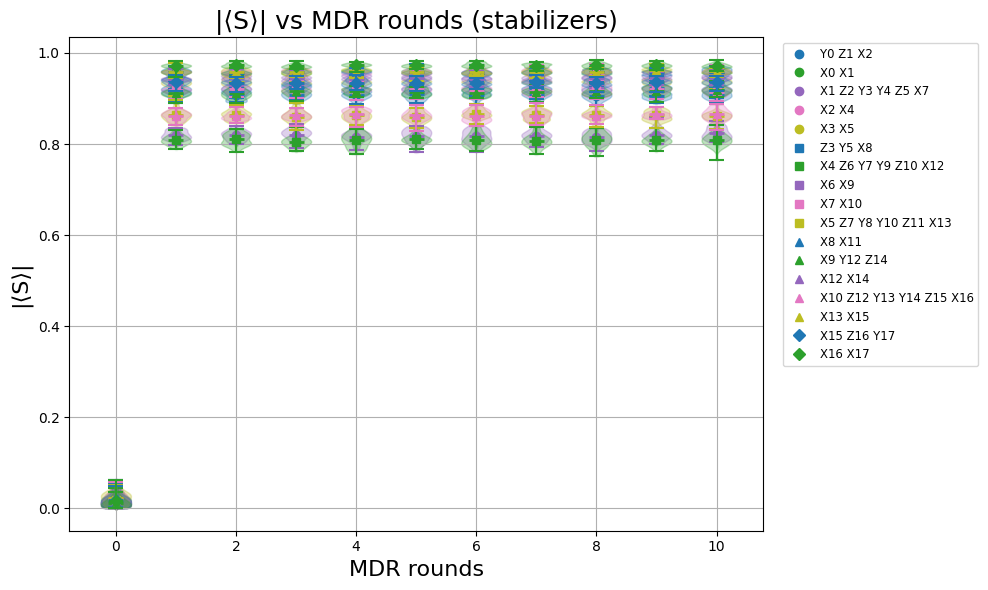

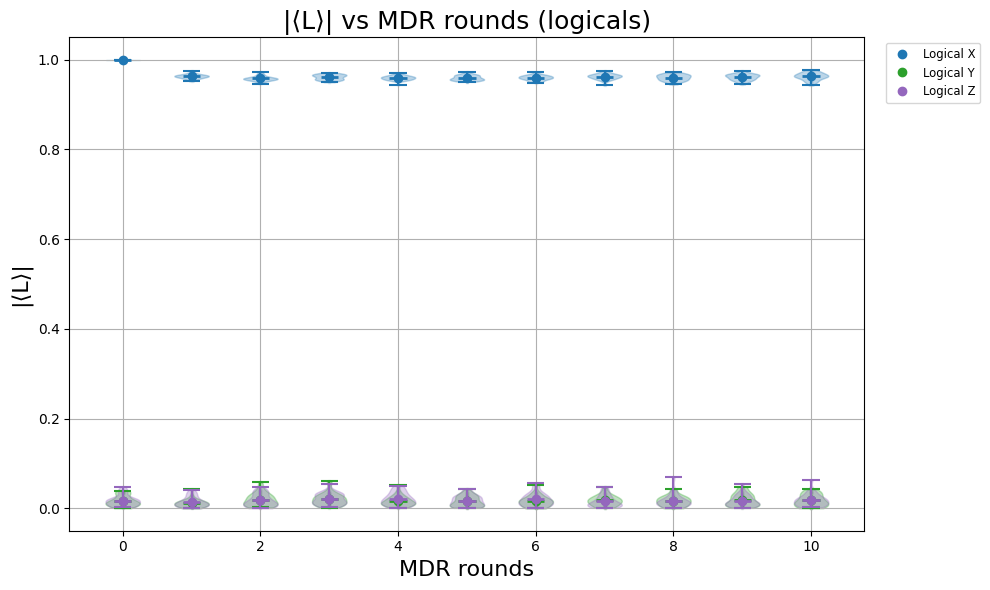

=== STABILIZERS ===
-- Y0 Z1 X2 --
Round |    Mean |  StdDev
-----+---------+--------
    0 |  0.0178 |  0.0132
    1 |  0.9095 |  0.0087
    2 |  0.9077 |  0.0106
    3 |  0.9079 |  0.0098
    4 |  0.9081 |  0.0098
    5 |  0.9087 |  0.0109
    6 |  0.9086 |  0.0081
    7 |  0.9077 |  0.0091
    8 |  0.9051 |  0.0101
    9 |  0.9061 |  0.0081
   10 |  0.9070 |  0.0078
Avg across rounds: 0.8268

-- X0 X1 --
Round |    Mean |  StdDev
-----+---------+--------
    0 |  0.0192 |  0.0146
    1 |  0.9580 |  0.0052
    2 |  0.9587 |  0.0061
    3 |  0.9578 |  0.0061
    4 |  0.9594 |  0.0057
    5 |  0.9586 |  0.0075
    6 |  0.9565 |  0.0072
    7 |  0.9575 |  0.0063
    8 |  0.9580 |  0.0064
    9 |  0.9579 |  0.0053
   10 |  0.9582 |  0.0049
Avg across rounds: 0.8727

-- X1 Z2 Y3 Y4 Z5 X7 --
Round |    Mean |  StdDev
-----+---------+--------
    0 |  0.0179 |  0.0145
    1 |  0.8201 |  0.0100
    2 |  0.8195 |  0.0110
    3 |  0.8202 |  0.0133
    4 |  0.8153 |  0.0115
    5 |  0.8180 |  0

In [32]:
# -------------------------------------------------------------
# make sure helpers (1)-(4) + the new (5) are in scope
# plus your psi() and MDR() definitions
# -------------------------------------------------------------
stabilizers_and_logical_X = [
  "Y0 Z1 X2", "X0 X1", "X1 Z2 Y3 Y4 Z5 X7",
  "X2 X4", "X3 X5", "Z3 Y5 X8", "X4 Z6 Y7 Y9 Z10 X12",
  "X6 X9", "X7 X10", "X5 Z7 Y8 Y10 Z11 X13", "X8 X11",
  "X9 Y12 Z14", "X12 X14", "X10 Z12 Y13 Y14 Z15 X16",
  "X13 X15", "X15 Z16 Y17", "X16 X17", "X9 X10 X11"
]

toggles = [
    "X0", "Y0", "X2", "X0 Z2", "X2 Z3", "X2 X3",
    "X6", "Z6", "X2 X6 Z7", "X8", "X2 X3 Y8",
    "X12 X13", "X13 Z14", "X13", "X8 Y13",
    "X16", "Y17", "X2 X3 Y8 Z11"
]

psi_circuit= stim.Circuit()
psi_circuit.append_operation("H", list(range(9, 12)))

MDR = MDRCircuit(
  stabilizers=stabilizers_and_logical_X, toggles=toggles, ancillas=1,
  p_spam = 1.339e-3,
  p_x=0, p_y=0, p_z=0,
  g1_x=0, g1_y=0, g1_z=8e-5,
  gate_noise_2q=[0,0,1.4e-3,0,0,0,1.4e-3,0,0,0,
                 1.4e-3,1.4e-3,1.4e-3,1.4e-3,1.4e-3],
  psi_circuit=psi             
)

exp_value_stabilizers = [
  "Y0 Z1 X2", "X0 X1", "X1 Z2 Y3 Y4 Z5 X7",
  "X2 X4", "X3 X5", "Z3 Y5 X8", "X4 Z6 Y7 Y9 Z10 X12",
  "X6 X9", "X7 X10", "X5 Z7 Y8 Y10 Z11 X13", "X8 X11",
  "X9 Y12 Z14", "X12 X14", "X10 Z12 Y13 Y14 Z15 X16",
  "X13 X15", "X15 Z16 Y17", "X16 X17"
]

exp_value_logical_ops = {
  "Logical X": "X9 X10 X11",
  "Logical Y": "X4 Z7 Y10 X13",
  "Logical Z": "X4 Z7 X9 Z10 X13 X11",
}


sim_z_noise = MDRSimulation(
  mdr=MDR,
  stabilizer_pauli_strings = exp_value_stabilizers,
  logical_pauli_strings = exp_value_logical_ops,
  shots_per_measurement = 2000,
  total_mdr_rounds = 10,
  num_replicates = 30
)

sim_z_noise.plot_group(
  save_path_stabilizers="stabs_z_noise.pdf",
  save_path_logicals="logs_z_noise.pdf",
)

sim_z_noise.results()

display_circuit = sim_z_noise.mdr_circuit.copy()

display_circuit.diagram('timeline-svg')

### MDR with Pure Z Noise

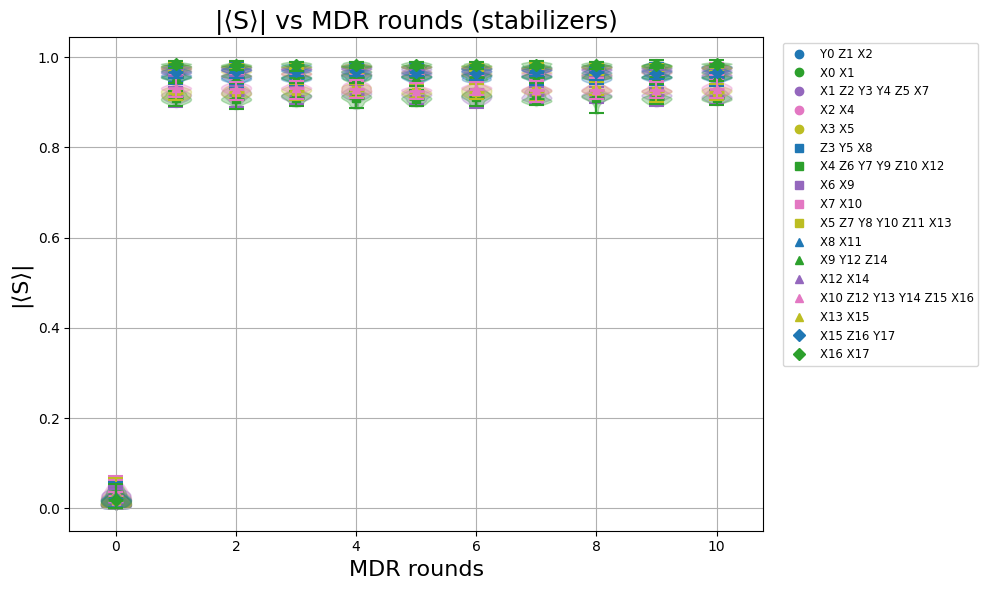

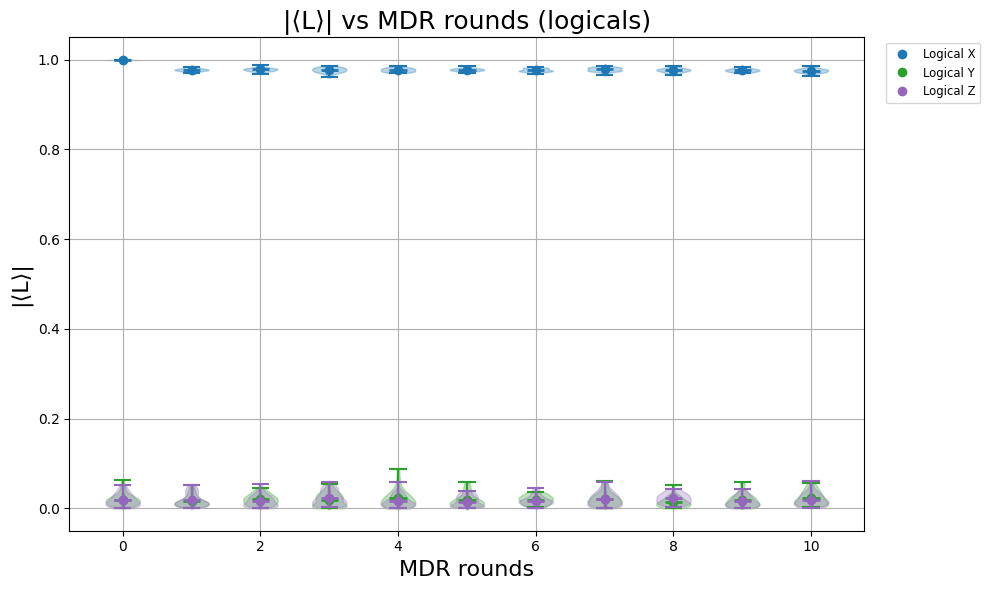

=== STABILIZERS ===
-- Y0 Z1 X2 --
Round |    Mean |  StdDev
-----+---------+--------
    0 |  0.0163 |  0.0129
    1 |  0.9557 |  0.0054
    2 |  0.9545 |  0.0091
    3 |  0.9535 |  0.0070
    4 |  0.9554 |  0.0058
    5 |  0.9558 |  0.0068
    6 |  0.9556 |  0.0070
    7 |  0.9557 |  0.0069
    8 |  0.9541 |  0.0077
    9 |  0.9556 |  0.0061
   10 |  0.9561 |  0.0071
Avg across rounds: 0.8698

-- X0 X1 --
Round |    Mean |  StdDev
-----+---------+--------
    0 |  0.0178 |  0.0129
    1 |  0.9786 |  0.0045
    2 |  0.9777 |  0.0056
    3 |  0.9773 |  0.0046
    4 |  0.9786 |  0.0044
    5 |  0.9775 |  0.0046
    6 |  0.9755 |  0.0044
    7 |  0.9762 |  0.0050
    8 |  0.9779 |  0.0049
    9 |  0.9789 |  0.0055
   10 |  0.9779 |  0.0036
Avg across rounds: 0.8904

-- X1 Z2 Y3 Y4 Z5 X7 --
Round |    Mean |  StdDev
-----+---------+--------
    0 |  0.0148 |  0.0132
    1 |  0.9141 |  0.0097
    2 |  0.9163 |  0.0115
    3 |  0.9140 |  0.0087
    4 |  0.9176 |  0.0110
    5 |  0.9132 |  0

In [33]:
# -------------------------------------------------------------
# make sure helpers (1)-(4) + the new (5) are in scope
# plus your psi() and MDR() definitions
# -------------------------------------------------------------
stabilizers_and_logical_X = [
  "Y0 Z1 X2", "X0 X1", "X1 Z2 Y3 Y4 Z5 X7",
  "X2 X4", "X3 X5", "Z3 Y5 X8", "X4 Z6 Y7 Y9 Z10 X12",
  "X6 X9", "X7 X10", "X5 Z7 Y8 Y10 Z11 X13", "X8 X11",
  "X9 Y12 Z14", "X12 X14", "X10 Z12 Y13 Y14 Z15 X16",
  "X13 X15", "X15 Z16 Y17", "X16 X17", "X9 X10 X11"
]

toggles = [
    "X0", "Y0", "X2", "X0 Z2", "X2 Z3", "X2 X3",
    "X6", "Z6", "X2 X6 Z7", "X8", "X2 X3 Y8",
    "X12 X13", "X13 Z14", "X13", "X8 Y13",
    "X16", "Y17", "X2 X3 Y8 Z11"
]

psi_circuit= stim.Circuit()
psi_circuit.append_operation("H", list(range(9, 12)))

MDR = MDRCircuit(
  stabilizers=stabilizers_and_logical_X, toggles=toggles, ancillas=1,
  p_spam = 1.339e-3,
  p_x=0, p_y=0, p_z=0,
  g1_x=0, g1_y=0, g1_z=8e-5,
  gate_noise_2q=[0,0,1.4e-3,
                 0,0,0,0,
                 0,0,0,0,
                 1.4e-3,0,0,1.4e-3],
  psi_circuit=psi             
)

exp_value_stabilizers = [
  "Y0 Z1 X2", "X0 X1", "X1 Z2 Y3 Y4 Z5 X7",
  "X2 X4", "X3 X5", "Z3 Y5 X8", "X4 Z6 Y7 Y9 Z10 X12",
  "X6 X9", "X7 X10", "X5 Z7 Y8 Y10 Z11 X13", "X8 X11",
  "X9 Y12 Z14", "X12 X14", "X10 Z12 Y13 Y14 Z15 X16",
  "X13 X15", "X15 Z16 Y17", "X16 X17"
]

exp_value_logical_ops = {
  "Logical X": "X9 X10 X11",
  "Logical Y": "X4 Z7 Y10 X13",
  "Logical Z": "X4 Z7 X9 Z10 X13 X11",
}


sim_pure_z_noise = MDRSimulation(
  mdr=MDR,
  stabilizer_pauli_strings = exp_value_stabilizers,
  logical_pauli_strings = exp_value_logical_ops,
  shots_per_measurement = 2000,
  total_mdr_rounds = 10,
  num_replicates = 30
)

sim_pure_z_noise.plot_group(
  save_path_stabilizers="stabs_pure_z_noise.pdf",
  save_path_logicals="logs_pure_z_noise.pdf",
)

sim_pure_z_noise.results()

display_circuit = sim_pure_z_noise.mdr_circuit.copy()

display_circuit.diagram('timeline-svg')

In [34]:
sim_pure_z_noise.tau_table(
    category='stabilizer', label='pure Z noise',)


=== τ_r & μ_r (stabilizers) for pure Z noise ===
Round |      μ_r |      τ_r
------+----------+----------
    0 |   0.0188 |   0.0034
    1 |   0.9574 |   0.0240
    2 |   0.9571 |   0.0237
    3 |   0.9573 |   0.0235
    4 |   0.9582 |   0.0232
    5 |   0.9569 |   0.0244
    6 |   0.9572 |   0.0234
    7 |   0.9568 |   0.0235
    8 |   0.9572 |   0.0236
    9 |   0.9575 |   0.0242
   10 |   0.9575 |   0.0239
------------------------------------
Average τ (excl. round 0): 0.0237
Average τ (incl. round 0): 0.0219
Average μ (excl. round 0): 0.9573
Average μ (incl. round 0): 0.8720



### MDR with Single qubit and 2 qubit gate X Type Noise

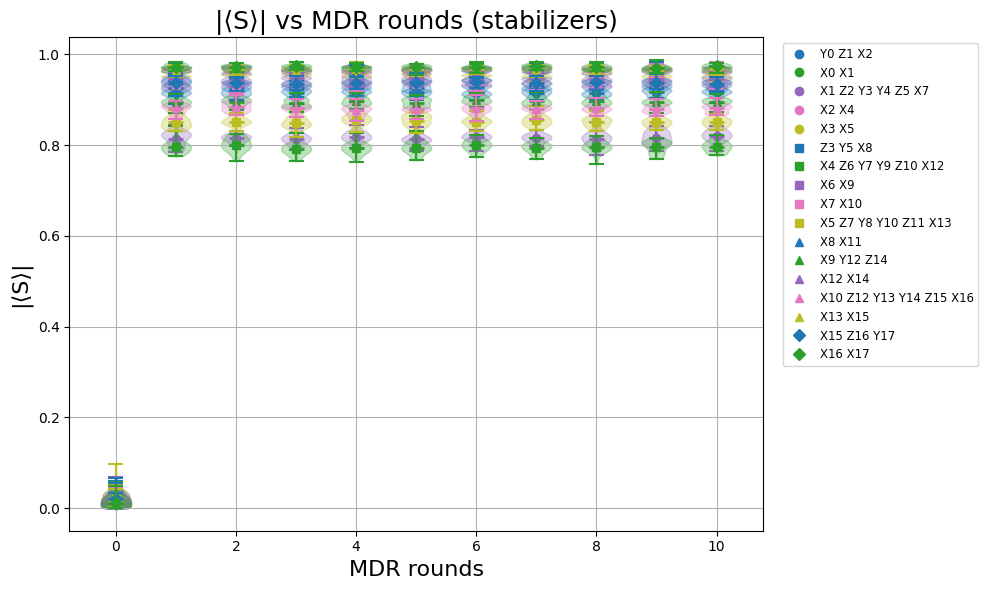

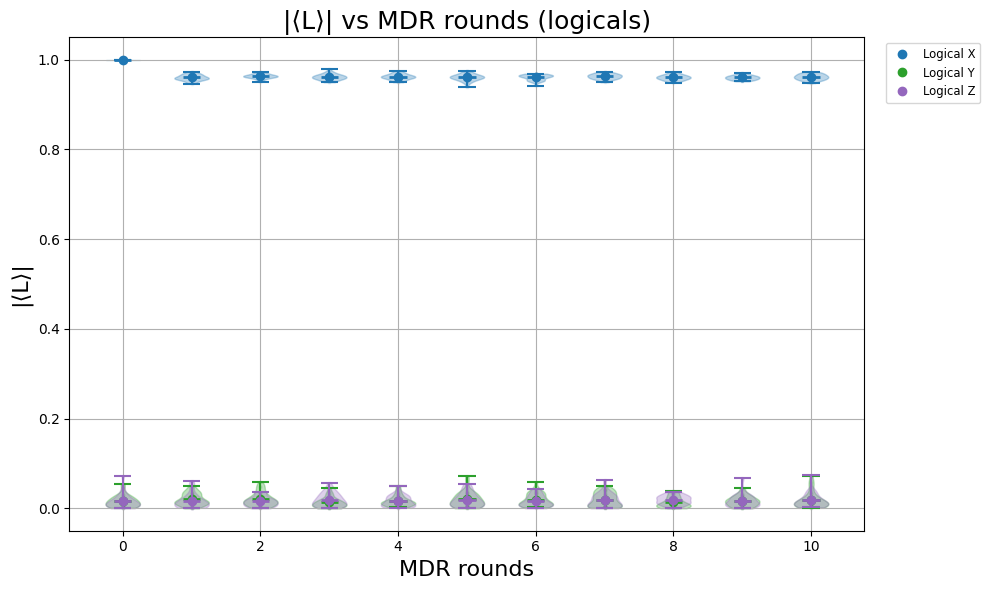

=== STABILIZERS ===
-- Y0 Z1 X2 --
Round |    Mean |  StdDev
-----+---------+--------
    0 |  0.0186 |  0.0155
    1 |  0.9142 |  0.0089
    2 |  0.9181 |  0.0103
    3 |  0.9157 |  0.0097
    4 |  0.9171 |  0.0096
    5 |  0.9162 |  0.0082
    6 |  0.9142 |  0.0087
    7 |  0.9151 |  0.0087
    8 |  0.9147 |  0.0079
    9 |  0.9178 |  0.0090
   10 |  0.9160 |  0.0094
Avg across rounds: 0.8343

-- X0 X1 --
Round |    Mean |  StdDev
-----+---------+--------
    0 |  0.0204 |  0.0164
    1 |  0.9696 |  0.0046
    2 |  0.9672 |  0.0057
    3 |  0.9670 |  0.0057
    4 |  0.9700 |  0.0059
    5 |  0.9661 |  0.0066
    6 |  0.9682 |  0.0057
    7 |  0.9678 |  0.0066
    8 |  0.9670 |  0.0054
    9 |  0.9658 |  0.0047
   10 |  0.9657 |  0.0050
Avg across rounds: 0.8813

-- X1 Z2 Y3 Y4 Z5 X7 --
Round |    Mean |  StdDev
-----+---------+--------
    0 |  0.0179 |  0.0125
    1 |  0.8137 |  0.0168
    2 |  0.8161 |  0.0081
    3 |  0.8136 |  0.0121
    4 |  0.8183 |  0.0118
    5 |  0.8135 |  0

In [35]:
# -------------------------------------------------------------
# make sure helpers (1)-(4) + the new (5) are in scope
# plus your psi() and MDR() definitions
# -------------------------------------------------------------
stabilizers_and_logical_X = [
  "Y0 Z1 X2", "X0 X1", "X1 Z2 Y3 Y4 Z5 X7",
  "X2 X4", "X3 X5", "Z3 Y5 X8", "X4 Z6 Y7 Y9 Z10 X12",
  "X6 X9", "X7 X10", "X5 Z7 Y8 Y10 Z11 X13", "X8 X11",
  "X9 Y12 Z14", "X12 X14", "X10 Z12 Y13 Y14 Z15 X16",
  "X13 X15", "X15 Z16 Y17", "X16 X17", "X9 X10 X11"
]

toggles = [
    "X0", "Y0", "X2", "X0 Z2", "X2 Z3", "X2 X3",
    "X6", "Z6", "X2 X6 Z7", "X8", "X2 X3 Y8",
    "X12 X13", "X13 Z14", "X13", "X8 Y13",
    "X16", "Y17", "X2 X3 Y8 Z11"
]

psi_circuit= stim.Circuit()
psi_circuit.append_operation("H", list(range(9, 12)))

MDR = MDRCircuit(
  stabilizers=stabilizers_and_logical_X, toggles=toggles, ancillas=1,
  p_spam = 1.339e-3,
  p_x=0, p_y=0, p_z=0,
  g1_x=8e-5, g1_y=0, g1_z=0,
  gate_noise_2q=[1.4e-3,0,0,
                 1.4e-3,1.4e-3,1.4e-3,1.4e-3,
                 0,1.4e-3,0,0,
                 0,1.4e-3,0,0],
  psi_circuit=psi             
)

exp_value_stabilizers = [
  "Y0 Z1 X2", "X0 X1", "X1 Z2 Y3 Y4 Z5 X7",
  "X2 X4", "X3 X5", "Z3 Y5 X8", "X4 Z6 Y7 Y9 Z10 X12",
  "X6 X9", "X7 X10", "X5 Z7 Y8 Y10 Z11 X13", "X8 X11",
  "X9 Y12 Z14", "X12 X14", "X10 Z12 Y13 Y14 Z15 X16",
  "X13 X15", "X15 Z16 Y17", "X16 X17"
]

exp_value_logical_ops = {
  "Logical X": "X9 X10 X11",
  "Logical Y": "X4 Z7 Y10 X13",
  "Logical Z": "X4 Z7 X9 Z10 X13 X11",
}


sim = MDRSimulation(
  mdr=MDR,
  stabilizer_pauli_strings = exp_value_stabilizers,
  logical_pauli_strings = exp_value_logical_ops,
  shots_per_measurement = 2000,
  total_mdr_rounds = 10,
  num_replicates = 30
)

sim.plot_group(
  save_path_stabilizers="stabs_x_noise.pdf",
  save_path_logicals="logs_x_noise.pdf",
)

sim.results()

display_circuit = sim.mdr_circuit.copy()

display_circuit.diagram('timeline-svg')

### MDR with Pure X Noise

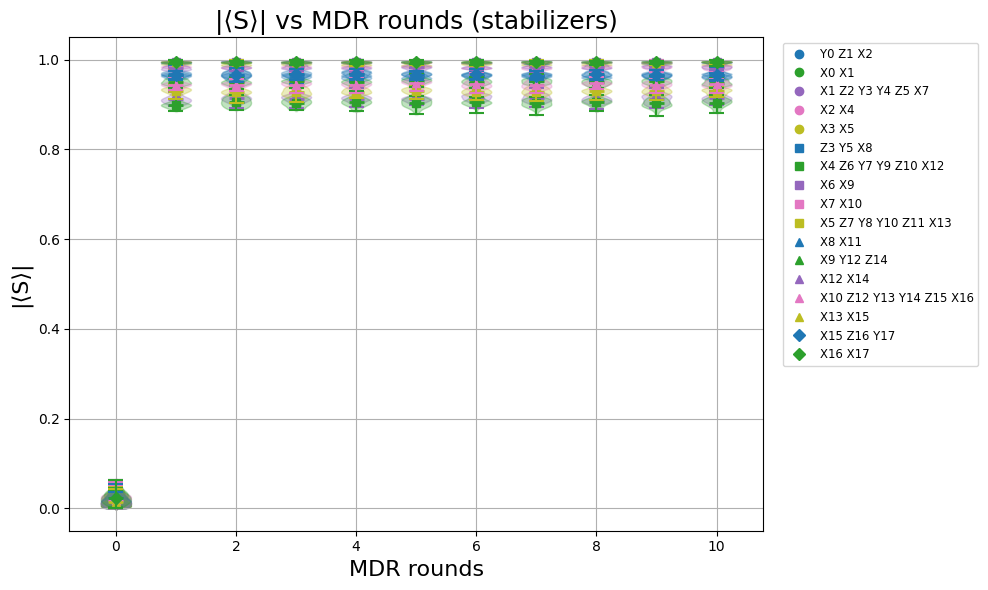

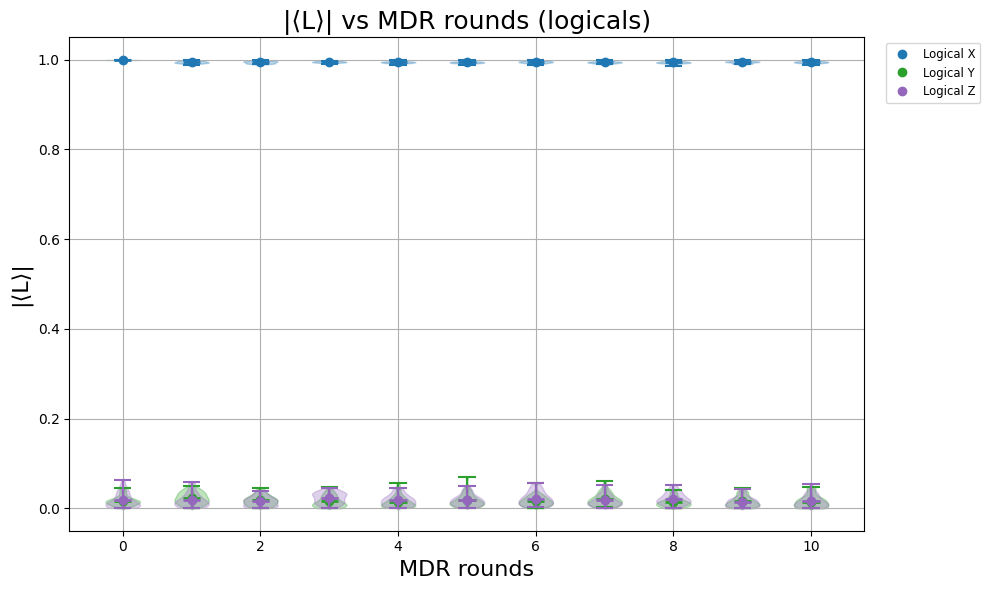

=== STABILIZERS ===
-- Y0 Z1 X2 --
Round |    Mean |  StdDev
-----+---------+--------
    0 |  0.0203 |  0.0160
    1 |  0.9630 |  0.0045
    2 |  0.9610 |  0.0076
    3 |  0.9603 |  0.0063
    4 |  0.9611 |  0.0062
    5 |  0.9613 |  0.0052
    6 |  0.9635 |  0.0067
    7 |  0.9638 |  0.0060
    8 |  0.9606 |  0.0051
    9 |  0.9629 |  0.0058
   10 |  0.9615 |  0.0045
Avg across rounds: 0.8763

-- X0 X1 --
Round |    Mean |  StdDev
-----+---------+--------
    0 |  0.0168 |  0.0128
    1 |  0.9941 |  0.0021
    2 |  0.9945 |  0.0021
    3 |  0.9941 |  0.0025
    4 |  0.9940 |  0.0029
    5 |  0.9947 |  0.0024
    6 |  0.9945 |  0.0024
    7 |  0.9940 |  0.0025
    8 |  0.9940 |  0.0020
    9 |  0.9945 |  0.0026
   10 |  0.9939 |  0.0028
Avg across rounds: 0.9054

-- X1 Z2 Y3 Y4 Z5 X7 --
Round |    Mean |  StdDev
-----+---------+--------
    0 |  0.0196 |  0.0133
    1 |  0.9117 |  0.0085
    2 |  0.9144 |  0.0098
    3 |  0.9126 |  0.0089
    4 |  0.9132 |  0.0089
    5 |  0.9135 |  0

In [36]:
# -------------------------------------------------------------
# make sure helpers (1)-(4) + the new (5) are in scope
# plus your psi() and MDR() definitions
# -------------------------------------------------------------
stabilizers_and_logical_X = [
  "Y0 Z1 X2", "X0 X1", "X1 Z2 Y3 Y4 Z5 X7",
  "X2 X4", "X3 X5", "Z3 Y5 X8", "X4 Z6 Y7 Y9 Z10 X12",
  "X6 X9", "X7 X10", "X5 Z7 Y8 Y10 Z11 X13", "X8 X11",
  "X9 Y12 Z14", "X12 X14", "X10 Z12 Y13 Y14 Z15 X16",
  "X13 X15", "X15 Z16 Y17", "X16 X17", "X9 X10 X11"
]

toggles = [
    "X0", "Y0", "X2", "X0 Z2", "X2 Z3", "X2 X3",
    "X6", "Z6", "X2 X6 Z7", "X8", "X2 X3 Y8",
    "X12 X13", "X13 Z14", "X13", "X8 Y13",
    "X16", "Y17", "X2 X3 Y8 Z11"
]

psi_circuit= stim.Circuit()
psi_circuit.append_operation("H", list(range(9, 12)))

MDR = MDRCircuit(
  stabilizers=stabilizers_and_logical_X, toggles=toggles, ancillas=1,
  p_spam = 1.339e-3,
  p_x=0, p_y=0, p_z=0,
  g1_x=8e-5, g1_y=0, g1_z=0,
  gate_noise_2q=[1.4e-3,0,0,
                 1.4e-3,1.4e-3,0,0,
                 0,0,0,0,
                 0,0,0,0],
  psi_circuit=psi             
)

exp_value_stabilizers = [
  "Y0 Z1 X2", "X0 X1", "X1 Z2 Y3 Y4 Z5 X7",
  "X2 X4", "X3 X5", "Z3 Y5 X8", "X4 Z6 Y7 Y9 Z10 X12",
  "X6 X9", "X7 X10", "X5 Z7 Y8 Y10 Z11 X13", "X8 X11",
  "X9 Y12 Z14", "X12 X14", "X10 Z12 Y13 Y14 Z15 X16",
  "X13 X15", "X15 Z16 Y17", "X16 X17"
]

exp_value_logical_ops = {
  "Logical X": "X9 X10 X11",
  "Logical Y": "X4 Z7 Y10 X13",
  "Logical Z": "X4 Z7 X9 Z10 X13 X11",
}


sim = MDRSimulation(
  mdr=MDR,
  stabilizer_pauli_strings = exp_value_stabilizers,
  logical_pauli_strings = exp_value_logical_ops,
  shots_per_measurement = 2000,
  total_mdr_rounds = 10,
  num_replicates = 30
)

sim.plot_group(
  save_path_stabilizers="stabs_pure_x_noise.pdf",
  save_path_logicals="logs_pure_x_noise.pdf",
)

sim.results()

display_circuit = sim.mdr_circuit.copy()

display_circuit.diagram('timeline-svg')

### MDR with Single qubit and 2 qubit gate Y Type Noise

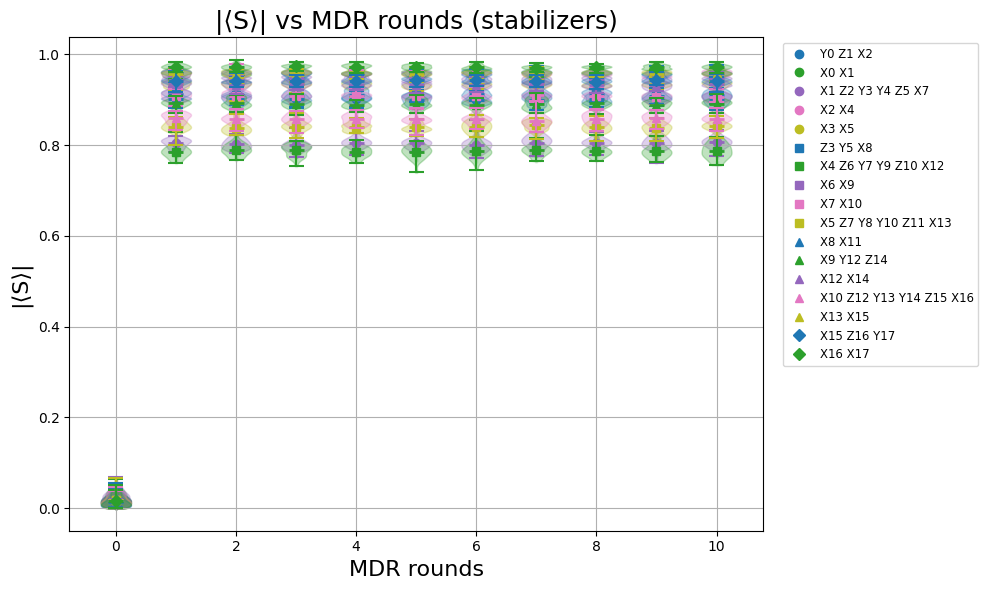

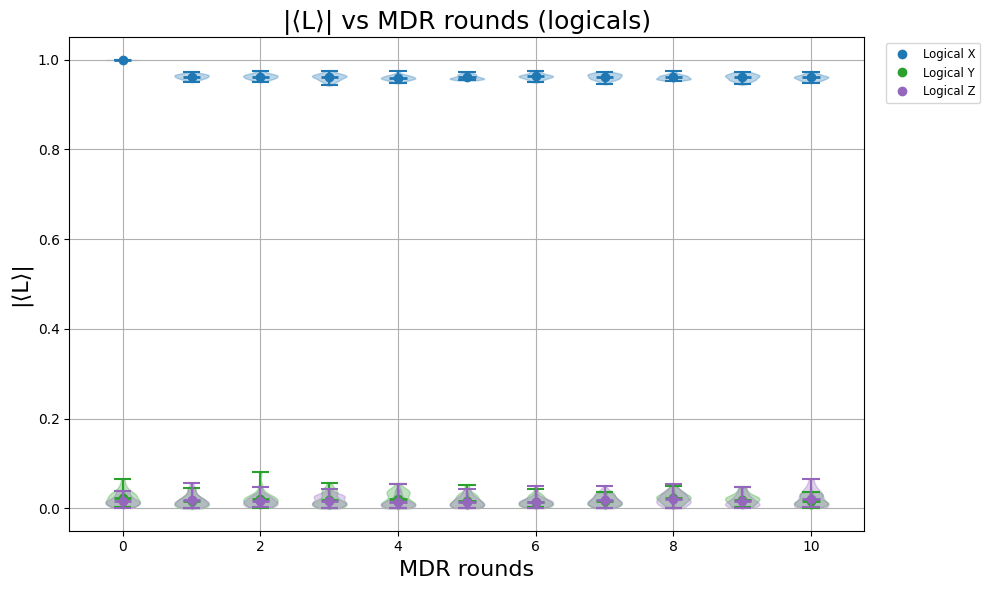

=== STABILIZERS ===
-- Y0 Z1 X2 --
Round |    Mean |  StdDev
-----+---------+--------
    0 |  0.0171 |  0.0111
    1 |  0.9025 |  0.0086
    2 |  0.9006 |  0.0102
    3 |  0.9021 |  0.0091
    4 |  0.9025 |  0.0093
    5 |  0.9003 |  0.0115
    6 |  0.8994 |  0.0090
    7 |  0.9004 |  0.0112
    8 |  0.9005 |  0.0099
    9 |  0.9031 |  0.0097
   10 |  0.9005 |  0.0116
Avg across rounds: 0.8208

-- X0 X1 --
Round |    Mean |  StdDev
-----+---------+--------
    0 |  0.0169 |  0.0146
    1 |  0.9583 |  0.0079
    2 |  0.9562 |  0.0069
    3 |  0.9582 |  0.0064
    4 |  0.9589 |  0.0059
    5 |  0.9583 |  0.0060
    6 |  0.9586 |  0.0065
    7 |  0.9595 |  0.0047
    8 |  0.9568 |  0.0065
    9 |  0.9582 |  0.0063
   10 |  0.9578 |  0.0073
Avg across rounds: 0.8725

-- X1 Z2 Y3 Y4 Z5 X7 --
Round |    Mean |  StdDev
-----+---------+--------
    0 |  0.0170 |  0.0137
    1 |  0.8043 |  0.0104
    2 |  0.8026 |  0.0107
    3 |  0.8011 |  0.0131
    4 |  0.8038 |  0.0113
    5 |  0.8043 |  0

In [37]:
# -------------------------------------------------------------
# make sure helpers (1)-(4) + the new (5) are in scope
# plus your psi() and MDR() definitions
# -------------------------------------------------------------
stabilizers_and_logical_X = [
  "Y0 Z1 X2", "X0 X1", "X1 Z2 Y3 Y4 Z5 X7",
  "X2 X4", "X3 X5", "Z3 Y5 X8", "X4 Z6 Y7 Y9 Z10 X12",
  "X6 X9", "X7 X10", "X5 Z7 Y8 Y10 Z11 X13", "X8 X11",
  "X9 Y12 Z14", "X12 X14", "X10 Z12 Y13 Y14 Z15 X16",
  "X13 X15", "X15 Z16 Y17", "X16 X17", "X9 X10 X11"
]

toggles = [
    "X0", "Y0", "X2", "X0 Z2", "X2 Z3", "X2 X3",
    "X6", "Z6", "X2 X6 Z7", "X8", "X2 X3 Y8",
    "X12 X13", "X13 Z14", "X13", "X8 Y13",
    "X16", "Y17", "X2 X3 Y8 Z11"
]

psi_circuit= stim.Circuit()
psi_circuit.append_operation("H", list(range(9, 12)))

MDR = MDRCircuit(
  stabilizers=stabilizers_and_logical_X, toggles=toggles, ancillas=1,
  p_spam = 1.339e-3,
  p_x=0, p_y=0, p_z=0,
  g1_x=0, g1_y=8e-5, g1_z=0,
  gate_noise_2q=[0,1.4e-3,0,
                 0,0,1.4e-3,0,
                 1.4e-3,1.4e-3,1.4e-3,1.4e-3,
                 0,0,1.4e-3,0],
  psi_circuit=psi             
)

exp_value_stabilizers = [
  "Y0 Z1 X2", "X0 X1", "X1 Z2 Y3 Y4 Z5 X7",
  "X2 X4", "X3 X5", "Z3 Y5 X8", "X4 Z6 Y7 Y9 Z10 X12",
  "X6 X9", "X7 X10", "X5 Z7 Y8 Y10 Z11 X13", "X8 X11",
  "X9 Y12 Z14", "X12 X14", "X10 Z12 Y13 Y14 Z15 X16",
  "X13 X15", "X15 Z16 Y17", "X16 X17"
]

exp_value_logical_ops = {
  "Logical X": "X9 X10 X11",
  "Logical Y": "X4 Z7 Y10 X13",
  "Logical Z": "X4 Z7 X9 Z10 X13 X11",
}


sim = MDRSimulation(
  mdr=MDR,
  stabilizer_pauli_strings = exp_value_stabilizers,
  logical_pauli_strings = exp_value_logical_ops,
  shots_per_measurement = 2000,
  total_mdr_rounds = 10,
  num_replicates = 30
)

sim.plot_group(
  save_path_stabilizers="stabs_y_noise.pdf",
  save_path_logicals="logs_y_noise.pdf",
)

sim.results()

display_circuit = sim.mdr_circuit.copy()

display_circuit.diagram('timeline-svg')

### MDR with Pure Y Noise

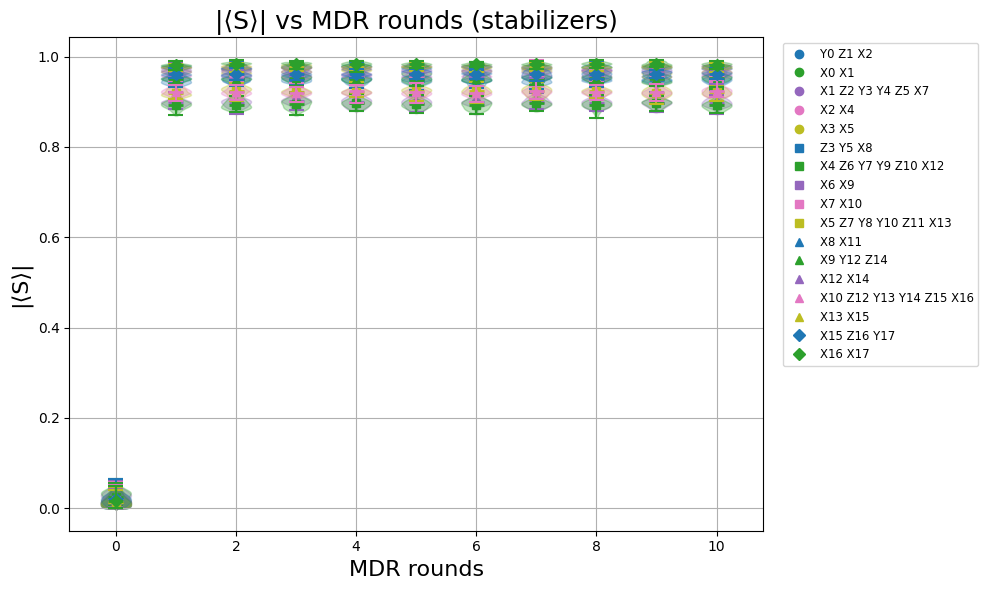

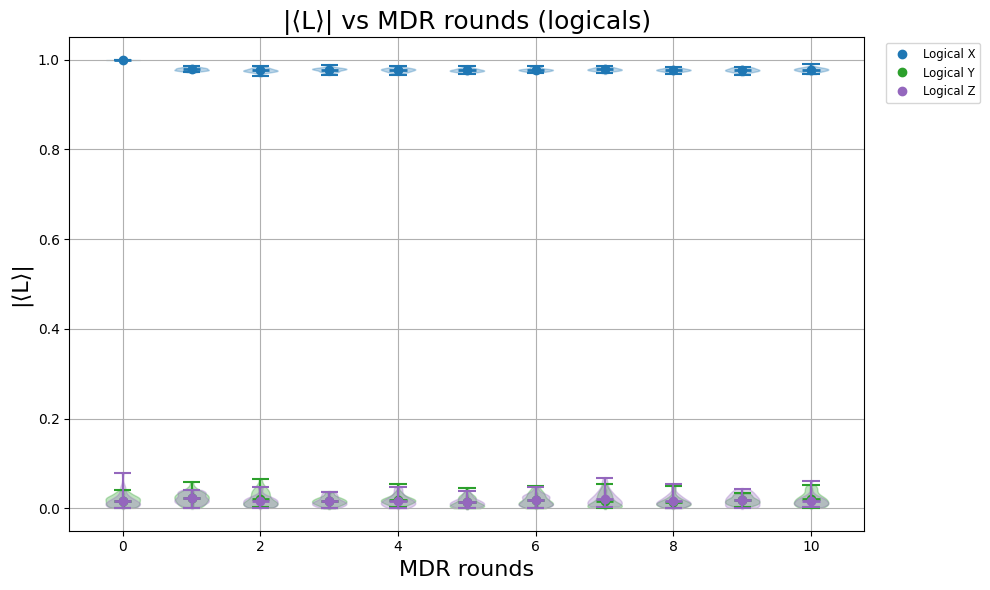

=== STABILIZERS ===
-- Y0 Z1 X2 --
Round |    Mean |  StdDev
-----+---------+--------
    0 |  0.0206 |  0.0169
    1 |  0.9465 |  0.0073
    2 |  0.9483 |  0.0071
    3 |  0.9491 |  0.0059
    4 |  0.9481 |  0.0083
    5 |  0.9459 |  0.0076
    6 |  0.9453 |  0.0068
    7 |  0.9454 |  0.0072
    8 |  0.9462 |  0.0064
    9 |  0.9471 |  0.0085
   10 |  0.9474 |  0.0086
Avg across rounds: 0.8627

-- X0 X1 --
Round |    Mean |  StdDev
-----+---------+--------
    0 |  0.0178 |  0.0165
    1 |  0.9771 |  0.0045
    2 |  0.9756 |  0.0053
    3 |  0.9770 |  0.0054
    4 |  0.9769 |  0.0049
    5 |  0.9780 |  0.0047
    6 |  0.9769 |  0.0040
    7 |  0.9747 |  0.0046
    8 |  0.9770 |  0.0036
    9 |  0.9773 |  0.0045
   10 |  0.9778 |  0.0038
Avg across rounds: 0.8896

-- X1 Z2 Y3 Y4 Z5 X7 --
Round |    Mean |  StdDev
-----+---------+--------
    0 |  0.0202 |  0.0140
    1 |  0.8989 |  0.0088
    2 |  0.8983 |  0.0106
    3 |  0.9016 |  0.0099
    4 |  0.8994 |  0.0114
    5 |  0.8963 |  0

In [38]:
# -------------------------------------------------------------
# make sure helpers (1)-(4) + the new (5) are in scope
# plus your psi() and MDR() definitions
# -------------------------------------------------------------
stabilizers_and_logical_X = [
  "Y0 Z1 X2", "X0 X1", "X1 Z2 Y3 Y4 Z5 X7",
  "X2 X4", "X3 X5", "Z3 Y5 X8", "X4 Z6 Y7 Y9 Z10 X12",
  "X6 X9", "X7 X10", "X5 Z7 Y8 Y10 Z11 X13", "X8 X11",
  "X9 Y12 Z14", "X12 X14", "X10 Z12 Y13 Y14 Z15 X16",
  "X13 X15", "X15 Z16 Y17", "X16 X17", "X9 X10 X11"
]

toggles = [
    "X0", "Y0", "X2", "X0 Z2", "X2 Z3", "X2 X3",
    "X6", "Z6", "X2 X6 Z7", "X8", "X2 X3 Y8",
    "X12 X13", "X13 Z14", "X13", "X8 Y13",
    "X16", "Y17", "X2 X3 Y8 Z11"
]

psi_circuit= stim.Circuit()
psi_circuit.append_operation("H", list(range(9, 12)))

MDR = MDRCircuit(
  stabilizers=stabilizers_and_logical_X, toggles=toggles, ancillas=1,
  p_spam = 1.339e-3,
  p_x=0, p_y=0, p_z=0,
  g1_x=0, g1_y=8e-5, g1_z=0,
  gate_noise_2q=[0,1.4e-3,0,
                 0,0,0,0,
                 1.4e-3,0,0,1.4e-3,
                 0,0,0,0],
  psi_circuit=psi             
)

exp_value_stabilizers = [
  "Y0 Z1 X2", "X0 X1", "X1 Z2 Y3 Y4 Z5 X7",
  "X2 X4", "X3 X5", "Z3 Y5 X8", "X4 Z6 Y7 Y9 Z10 X12",
  "X6 X9", "X7 X10", "X5 Z7 Y8 Y10 Z11 X13", "X8 X11",
  "X9 Y12 Z14", "X12 X14", "X10 Z12 Y13 Y14 Z15 X16",
  "X13 X15", "X15 Z16 Y17", "X16 X17"
]

exp_value_logical_ops = {
  "Logical X": "X9 X10 X11",
  "Logical Y": "X4 Z7 Y10 X13",
  "Logical Z": "X4 Z7 X9 Z10 X13 X11",
}


sim = MDRSimulation(
  mdr=MDR,
  stabilizer_pauli_strings = exp_value_stabilizers,
  logical_pauli_strings = exp_value_logical_ops,
  shots_per_measurement = 2000,
  total_mdr_rounds = 10,
  num_replicates = 30
)

sim.plot_group(
  save_path_stabilizers="stabs_pure_y_noise.pdf",
  save_path_logicals="logs_pure_y_noise.pdf",
)

sim.results()

display_circuit = sim.mdr_circuit.copy()

display_circuit.diagram('timeline-svg')

## Comparing Unbiased, Z Type and Pure Z Noise

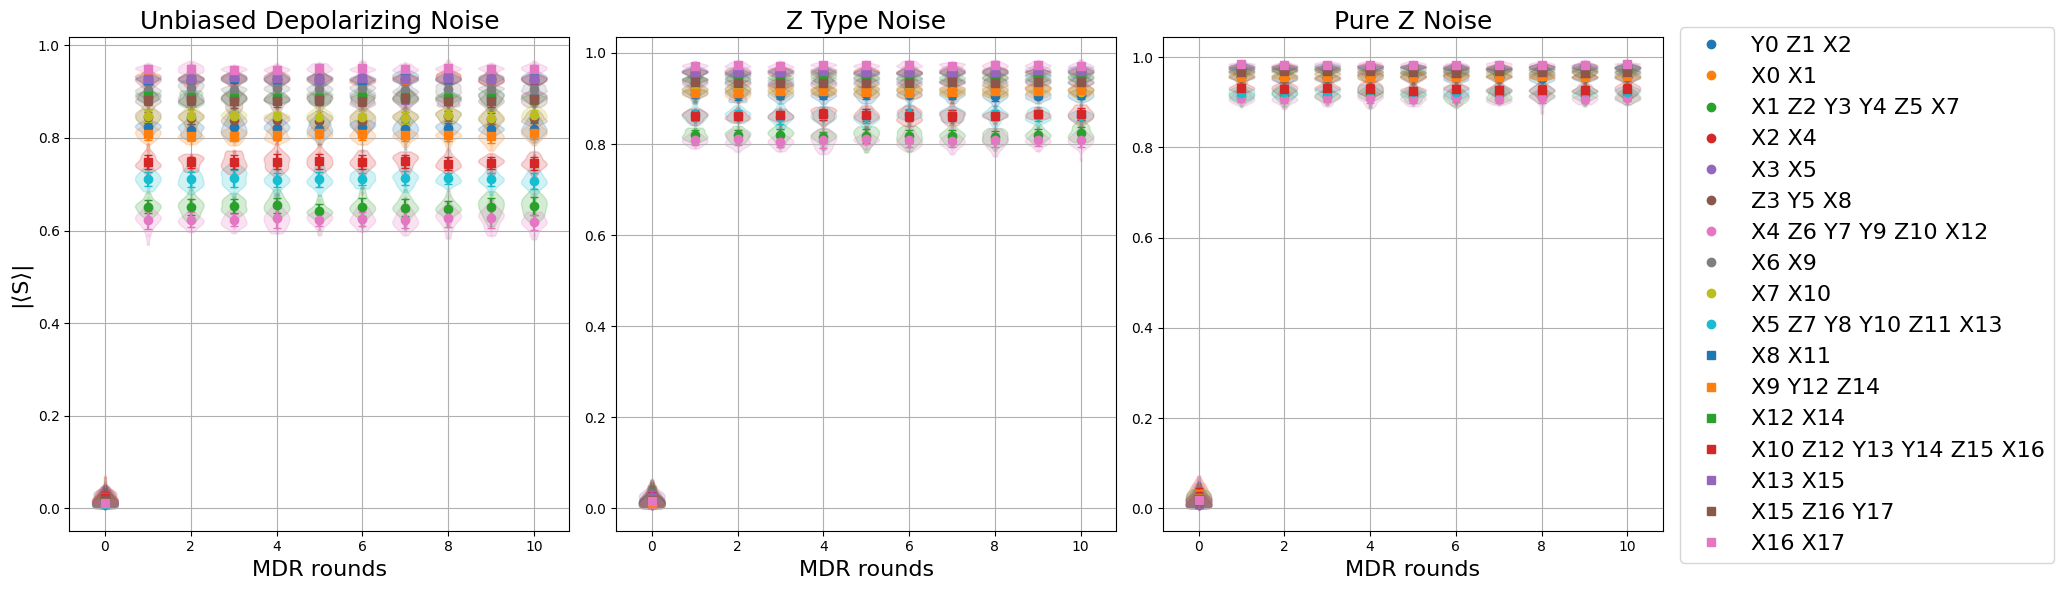

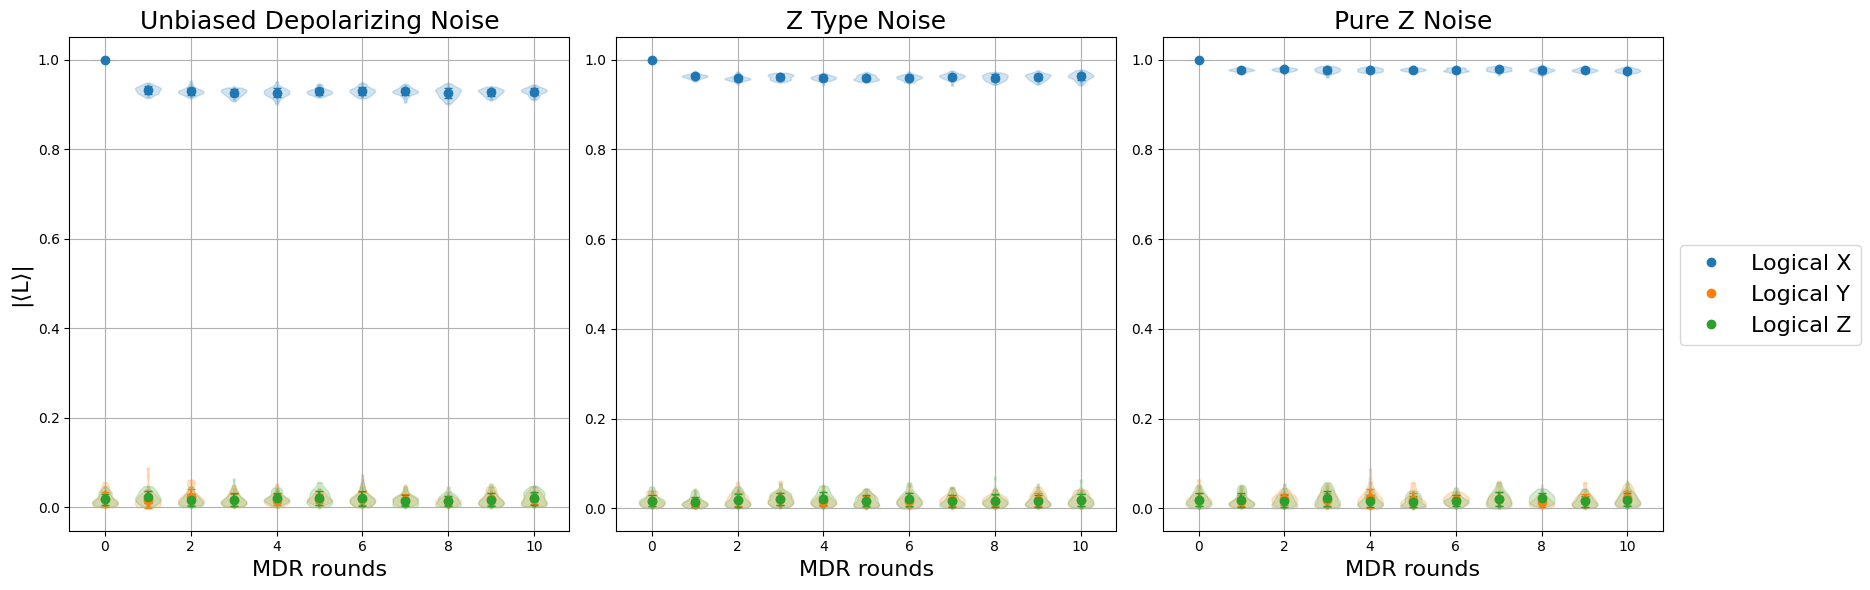

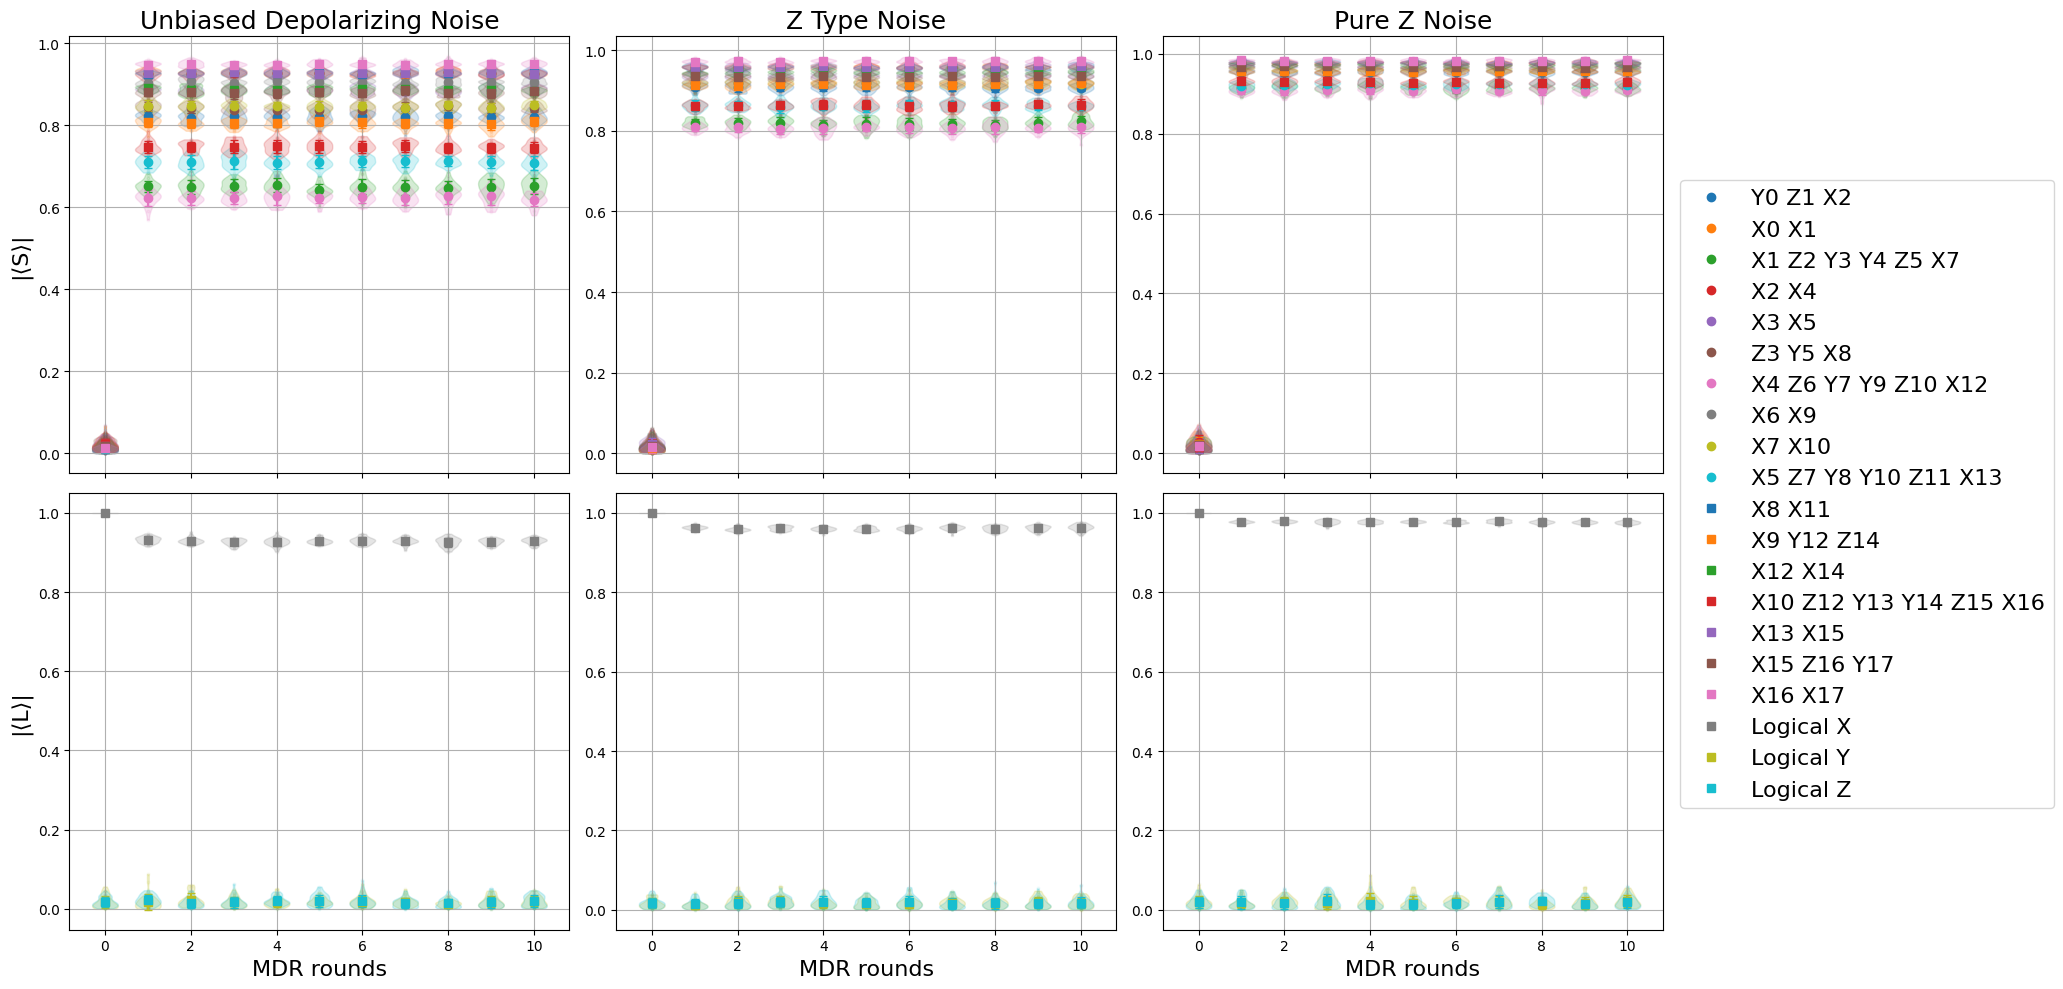

In [39]:
MDRSimulation.plot_multi_fidelity(
    {
      'Unbiased Depolarizing Noise': sim_unbiased_noise,
      'Z Type Noise': sim_z_noise,
      'Pure Z Noise': sim_pure_z_noise,
    },
    category='stabilizer',
    operators=None,         # ← defaults to every stabilizer
    show_violin=True,
    show_replicates=True,
    figsize=(18, 6), 
    save_path='H2_specs_unbiased_z_pure_z_noise_stabilizers_compare.pdf'
)

MDRSimulation.plot_multi_fidelity(
    {
      'Unbiased Depolarizing Noise': sim_unbiased_noise,
      'Z Type Noise': sim_z_noise,
      'Pure Z Noise': sim_pure_z_noise,
    },
    category='logical',
    operators=None,         # ← defaults to every stabilizer
    show_violin=True,
    show_replicates=True,
    figsize=(18, 6), 
    save_path='H2_specs_unbiased_z_pure_z_noise_logicals_compare.pdf'
)

MDRSimulation.plot_multi_fidelity(
    {
      'Unbiased Depolarizing Noise': sim_unbiased_noise,
      'Z Type Noise': sim_z_noise,
      'Pure Z Noise': sim_pure_z_noise,
    },
    category='both',
    show_violin=True,
    show_replicates=True,
    figsize=(18,10),
    save_path='H2_specs_unbiased_z_pure_z_noise_stabilizers_&_logicals_compare.pdf'
)


In [40]:
MDRSimulation.compare_tau(
    {
      'Unbiased Depolarizing Noise': sim_unbiased_noise,
      'Z Type Noise': sim_z_noise,
      'Pure Z Noise': sim_pure_z_noise,
    },
    category='stabilizer'
)


=== Average τ and μ (excl. round 0) comparison (stabilizers) ===
Simulation                     |      avg τ |  avg τ (incl r0) |      avg μ |  avg μ (incl r0)
----------------------------------------------------------------------------------------------
Unbiased Depolarizing Noise    |     0.1008 |           0.0918 |     0.8394 |           0.7647
Z Type Noise                   |     0.0498 |           0.0454 |     0.9164 |           0.8347
Pure Z Noise                   |     0.0237 |           0.0219 |     0.9573 |           0.8720



## Standard Deviation of Expectation Value vs Shots for 1 Round of MDR

In [41]:
import stim
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple, Mapping, Union
import pandas as pd  

# from your_module import MDRCircuit   # adjust to point at your MDRCircuit

class ShotNoiseStdAnalyzer:
    """
    Analyze how Monte Carlo shot-noise (sample stddev of |⟨O⟩| estimates)
    depends on the number of shots, for all stabilizers and logicals
    defined in an MDRCircuit.

    On initialization, this class:
      • Takes an MDRCircuit instance (with .psi(), .build(), .p_spam).
      • Takes lists of stabilizer Pauli strings and logical spec dict.
      • Picks a single MDR round (`mdr_round`), a list of shot_counts,
        and a number of replicates per shot count.
      • Builds the base circuit (|+> prep + N MDR rounds).
      • Immediately runs all replicates and computes sample-stddevs.

    Attributes:
        mdr_circuit:
            MDRCircuit instance providing .psi(), .build(), and .p_spam.
        stabilizer_pauli_strings:
            List[str] of sparse Pauli specs for stabilizers.
        logical_pauli_strings:
            Dict[str,str] mapping logical labels → Pauli specs.
        mdr_round: int
            Which MDR round to insert measurements at.
        shot_counts:
            List[int] of shot counts to sweep.
        num_replicates:
            int, number of independent repeats per shot count.
        stddevs_stabilizers:
            Dict[spec → List[float]]: sample stddevs vs shots.
        stddevs_logicals:
            Dict[label → List[float]]: sample stddevs vs shots.
        _replicates_stabilizers:
            Dict[spec → List[List[float]]]: per-replicate means vs shots.
        _replicates_logicals:
            Dict[label → List[List[float]]]: per-replicate means vs shots.

    Methods:
        plot_stddevs_vs_shots(group='stabilizers', save_path=None):
            Plot stddev vs shot_counts curves (log-x).
        plot_histogram(spec, group, shots, bins=20, save_path=None):
            Histogram of replicate-means for one operator.
        plot_stddev_histogram_vs_shots(group, bins=20, save_path=None):
            Histogram of stddevs across selected operators at each shot count.
        display_std_table(group='stabilizers'):
            Print a table of sample-stddev vs shot_counts.
    """

    def __init__(
        self,
        mdr_circuit: "MDRCircuit",
        stabilizer_pauli_strings: List[str],
        logical_pauli_strings: Dict[str, str],
        mdr_round: int = 0,
        shot_counts: List[int] = [10, 100, 1000, 10000],
        num_replicates: int = 100
    ) -> None:
        """
        Initialize the analyzer and precompute all std-devs.

        Args:
            mdr_circuit: MDRCircuit instance providing circuit methods.
            stabilizer_pauli_strings: List of stabilizer Pauli specs.
            logical_pauli_strings: Dict[label → spec] for logicals.
            mdr_round: MDR round index to measure.
            shot_counts: List of shot counts to sweep.
            num_replicates: Number of repeats per shot count.

        This constructor builds the base circuit (prep + MDR rounds),
        then immediately computes all replicate means and sample stddevs
        for each operator and shot count.
        """
        self.mdr_circuit = mdr_circuit
        self.stabilizer_pauli_strings = stabilizer_pauli_strings
        self.logical_pauli_strings = logical_pauli_strings
        self.mdr_round = mdr_round
        self.shot_counts = shot_counts
        self.num_replicates = num_replicates

        # Results placeholders for stddevs and replicate means
        self.stddevs_stabilizers: Dict[str, List[float]] = {}
        self.stddevs_logicals:   Dict[str, List[float]] = {}
        self._replicates_stabilizers: Dict[str, List[List[float]]] = {}
        self._replicates_logicals:   Dict[str, List[List[float]]] = {}

        # Build the base circuit: |+> prep + MDR rounds
        prep = self.mdr_circuit.psi() if hasattr(self.mdr_circuit, 'psi') \
            else stim.Circuit()
        body = self.mdr_circuit.build(include_psi=False) * mdr_round \
            if mdr_round > 0 else stim.Circuit()
        self._base_circuit = prep + body

        # Compute all stddevs and replicate means for all operators
        self._compute_all_stddevs()

    @staticmethod
    def _spec_to_measurement_ops(pauli_spec: str) -> List[Tuple[str, int]]:
        """
        Convert a sparse Pauli string (e.g. 'X1 Z3') into a list of
        measurement operations (e.g. [('MX', 1), ('MZ', 3)]).

        Args:
            pauli_spec: String specifying Pauli operators and qubits.

        Returns:
            List of (gate, qubit) tuples for measurement.
        """
        ops: List[Tuple[str, int]] = []
        for term in pauli_spec.split():
            p, q = term[0].upper(), int(term[1:])
            gate_map = {'X': 'MX', 'Y': 'MY', 'Z': 'MZ'}
            if p not in gate_map:
                raise ValueError(f"Invalid Pauli term: {term}")
            ops.append((gate_map[p], q))
        return ops

    def _compute_all_stddevs(self) -> None:
        """
        For each operator (stabilizer or logical), and for each shot
        count, run `num_replicates` independent experiments, compute
        the mean |⟨O⟩| for each, and store the sample stddev across
        replicates.

        Results are stored in:
            self.stddevs_stabilizers, self.stddevs_logicals
            self._replicates_stabilizers, self._replicates_logicals
        """
        p_spam = getattr(self.mdr_circuit, 'p_spam', 0.0)

        def run_spec(spec: str):
            # Convert Pauli spec to measurement operations
            ops = self._spec_to_measurement_ops(spec)
            stds, reps = [], []
            for shots in self.shot_counts:
                means: List[float] = []
                for _ in range(self.num_replicates):
                    # Copy base circuit and append measurement ops
                    circ = self._base_circuit.copy()
                    for gate, q in ops:
                        # Optionally add PAULI_CHANNEL_1 for SPAM error
                        if p_spam:
                            circ += stim.Circuit(
                                f"PAULI_CHANNEL_1({p_spam},0,0) {q}"
                            )
                        circ.append_operation(gate, q)
                    # Sample measurement outcomes
                    samp = circ.compile_sampler().sample(
                        shots=shots, bit_packed=False
                    )
                    # Extract columns for measured qubits
                    cols = np.arange(-len(ops), 0)
                    parity = np.sum(samp[:, cols], axis=1) % 2
                    eigen = 1 - 2 * parity  # Map bits to ±1 eigenvalues
                    means.append(abs(float(np.mean(eigen))))
                reps.append(means)
                # Compute sample stddev across replicates
                stds.append(float(np.std(means, ddof=1)))
            return stds, reps

        # Run for all stabilizer specs
        for spec in self.stabilizer_pauli_strings:
            s, r = run_spec(spec)
            self.stddevs_stabilizers[spec] = s
            self._replicates_stabilizers[spec] = r
        # Run for all logical specs
        for label, spec in self.logical_pauli_strings.items():
            s, r = run_spec(spec)
            self.stddevs_logicals[label] = s
            self._replicates_logicals[label] = r

    def plot_stddevs_vs_shots(self, group='stabilizers', save_path=None) -> None:
        """
        Plot sample stddev of |⟨O⟩| versus shot count for each operator.

        Args:
            group: 'stabilizers' or 'logicals'. Selects which operators
                to plot.
            save_path: Optional path to save the figure as an image.

        The x-axis is log-scaled (shot count), and each curve
        corresponds to one operator.
        """
        if group == 'stabilizers':
            data, title = self.stddevs_stabilizers, \
                f"Stabilizers, round={self.mdr_round}"
        elif group == 'logicals':
            data, title = self.stddevs_logicals, \
                f"Logicals, round={self.mdr_round}"
        else:
            raise ValueError("group must be 'stabilizers' or 'logicals'")
        fig, ax = plt.subplots(figsize=(10, 5))
        cols = plt.rcParams['axes.prop_cycle'].by_key()['color']
        markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h', '+', 'x']
        for i, (lbl, stds) in enumerate(data.items()):
            c = cols[i % len(cols)]
            m = markers[(i // len(cols)) % len(markers)]
            ax.plot(
                self.shot_counts, stds, color=c, marker=m, linestyle='None',
                label=lbl
            )
        ax.set_xscale('log')
        ax.set_title(f"StdDev vs Shots ({title})")
        ax.set_xlabel('Shots')
        ax.set_ylabel('Sample stddev')
        ax.grid(True, which='both', ls='--', alpha=0.5)
        ax.legend(
            loc='upper left', bbox_to_anchor=(1.02, 1), fontsize='small'
        )
        fig.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def plot_histogram(
        self,
        spec: str,
        group: str = 'stabilizers',
        shots: int = None,
        bins: int = 20,
        save_path: str = None
    ) -> None:
        """
        Plot a histogram of replicate means for a single operator
        at a specified shot count.

        Args:
            spec: Operator spec (Pauli string or logical label).
            group: 'stabilizers' or 'logicals'.
            shots: Number of shots to select (must be in shot_counts).
            bins: Number of bins in the histogram.
            save_path: Optional path to save the figure.

        This visualizes the distribution of |⟨O⟩| means across
        independent replicates for a single operator.
        """
        store = (self._replicates_stabilizers if group == 'stabilizers'
                 else self._replicates_logicals if group == 'logicals'
                 else None)
        if store is None:
            raise ValueError("group must be 'stabilizers' or 'logicals'")
        if shots not in self.shot_counts:
            raise ValueError(f"shots must be one of {self.shot_counts}")
        if spec not in store:
            raise KeyError(f"{spec} not in group '{group}'")
        idx = self.shot_counts.index(shots)
        data = store[spec][idx]
        cols = plt.rcParams['axes.prop_cycle'].by_key()['color']
        colour = cols[list(store.keys()).index(spec) % len(cols)]
        plt.figure(figsize=(7, 5))
        plt.hist(
            data, bins=bins, color=colour, alpha=0.7, edgecolor='black'
        )
        plt.title(f"Histogram of {spec} @ {shots} shots")
        plt.xlabel('|⟨O⟩| means')
        plt.ylabel('Count')
        plt.grid(True, ls='--', alpha=0.5)
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def plot_stddev_histogram_vs_shots(
        self,
        group: str = 'stabilizers',
        bins: int = 20,
        save_path: str = None
    ) -> None:
        """
        Draw a histogram of sample stddevs across all operators for
        each shot count, laid out side by side.

        Args:
            group: 'stabilizers' or 'logicals'.
            bins: Number of bins in each histogram.
            save_path: Optional path to save the figure.

        This allows comparison of the spread of sample stddevs
        across operators as a function of shot count.
        """
        # Select the appropriate stddev map and title
        if group == 'stabilizers':
            std_map = self.stddevs_stabilizers
            title_group = "Stabilizers"
        elif group == 'logicals':
            std_map = self.stddevs_logicals
            title_group = "Logicals"
        else:
            raise ValueError("group must be 'stabilizers' or 'logicals'")

        n = len(self.shot_counts)
        fig, axes = plt.subplots(
            1, n,
            figsize=(4 * n, 4),
            sharey=True,
            constrained_layout=True
        )

        colours = plt.rcParams['axes.prop_cycle'].by_key()['color']

        for ax, shots, c in zip(axes, self.shot_counts, colours):
            # Collect stddevs for this shot count across all operators
            idx = self.shot_counts.index(shots)
            vals = [stds[idx] for stds in std_map.values()]

            ax.hist(
                vals,
                bins=bins,
                color=c,
                edgecolor='black',
                alpha=0.7
            )
            ax.set_title(f"{shots} shots")
            ax.set_xlabel("stddev of |⟨O⟩|")
            ax.grid(True, ls='--', alpha=0.4)

        axes[0].set_ylabel("Number of operators")
        fig.suptitle(
            f"StdDev Distributions vs Shots ({title_group}), "
            f"round={self.mdr_round}", y=1.02
        )

        if save_path:
            fig.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def display_std_table(self, group: str = 'stabilizers') -> None:
        """
        Print a table of sample stddevs for all operators and shot counts.

        Args:
            group: 'stabilizers' or 'logicals'.

        The table rows are operators (Pauli specs or logical labels),
        columns are shot counts, and entries are formatted to four
        decimal places.
        """

        if group == 'stabilizers':
            std_map = self.stddevs_stabilizers
        elif group == 'logicals':
            std_map = self.stddevs_logicals
        else:
            raise ValueError("group must be 'stabilizers' or 'logicals'")

        # Build a DataFrame: rows = operators, columns = shot_counts
        df = pd.DataFrame(
            {op: std_map[op] for op in std_map},
            index=self.shot_counts
        ).T

        df.index.name = 'Operator'
        df.columns.name = 'Shots'

        # Print as a markdown table with 4-decimal formatting
        print(df.to_markdown(floatfmt=".4f"))


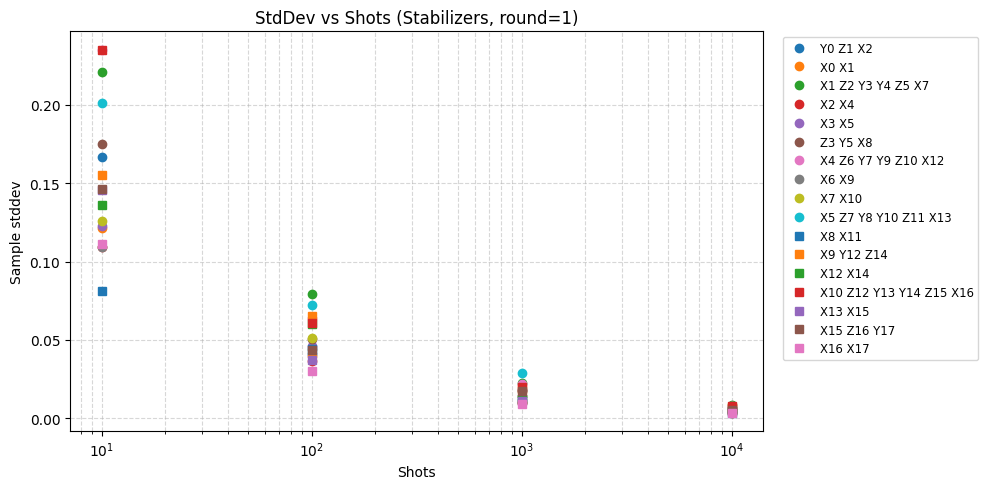

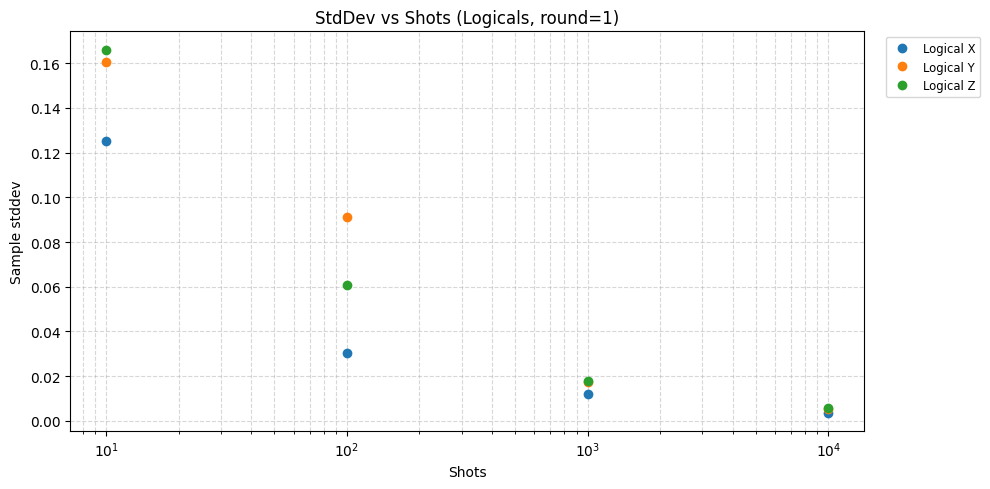

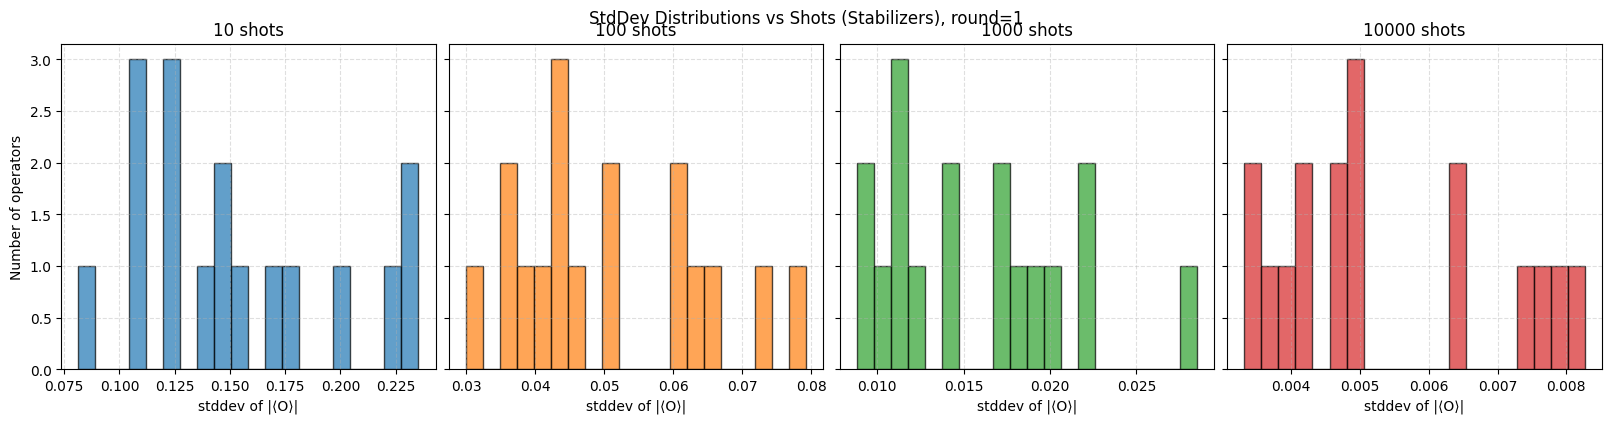

| Operator                |     10 |    100 |   1000 |   10000 |
|:------------------------|-------:|-------:|-------:|--------:|
| Y0 Z1 X2                | 0.1668 | 0.0410 | 0.0183 |  0.0046 |
| X0 X1                   | 0.1213 | 0.0395 | 0.0105 |  0.0040 |
| X1 Z2 Y3 Y4 Z5 X7       | 0.2212 | 0.0792 | 0.0224 |  0.0083 |
| X2 X4                   | 0.1093 | 0.0362 | 0.0096 |  0.0033 |
| X3 X5                   | 0.1230 | 0.0461 | 0.0116 |  0.0049 |
| Z3 Y5 X8                | 0.1749 | 0.0504 | 0.0173 |  0.0064 |
| X4 Z6 Y7 Y9 Z10 X12     | 0.2349 | 0.0640 | 0.0220 |  0.0080 |
| X6 X9                   | 0.1093 | 0.0444 | 0.0144 |  0.0042 |
| X7 X10                  | 0.1258 | 0.0515 | 0.0141 |  0.0050 |
| X5 Z7 Y8 Y10 Z11 X13    | 0.2013 | 0.0725 | 0.0285 |  0.0063 |
| X8 X11                  | 0.0814 | 0.0444 | 0.0119 |  0.0036 |
| X9 Y12 Z14              | 0.1552 | 0.0652 | 0.0187 |  0.0074 |
| X12 X14                 | 0.1363 | 0.0604 | 0.0114 |  0.0046 |
| X10 Z12 Y13 Y14 Z15 X16

In [42]:
# -------------------------------------------------------------
# make sure helpers (1)-(4) + the new (5) are in scope
# plus your psi() and MDR() definitions
# -------------------------------------------------------------
stabilizers_and_logical_X = [
  "Y0 Z1 X2", "X0 X1", "X1 Z2 Y3 Y4 Z5 X7",
  "X2 X4", "X3 X5", "Z3 Y5 X8", "X4 Z6 Y7 Y9 Z10 X12",
  "X6 X9", "X7 X10", "X5 Z7 Y8 Y10 Z11 X13", "X8 X11",
  "X9 Y12 Z14", "X12 X14", "X10 Z12 Y13 Y14 Z15 X16",
  "X13 X15", "X15 Z16 Y17", "X16 X17", "X9 X10 X11"
]

toggles = [
    "X0", "Y0", "X2", "X0 Z2", "X2 Z3", "X2 X3",
    "X6", "Z6", "X2 X6 Z7", "X8", "X2 X3 Y8",
    "X12 X13", "X13 Z14", "X13", "X8 Y13",
    "X16", "Y17", "X2 X3 Y8 Z11"
]

psi= stim.Circuit()
psi.append_operation("H", list(range(9, 12)))

MDR = MDRCircuit(
  stabilizers=stabilizers_and_logical_X, toggles=toggles, ancillas=1,
  p_spam = 1.339e-3,
  p_x=0, p_y=0, p_z=0,
  g1_x=8e-5, g1_y=8e-5, g1_z=8e-5,
  gate_noise_2q=[1.4e-3,1.4e-3,1.4e-3,1.4e-3,1.4e-3,1.4e-3,1.4e-3,
                 1.4e-3,1.4e-3,1.4e-3,1.4e-3,1.4e-3,1.4e-3,1.4e-3,1.4e-3],
  psi_circuit=psi             
)

exp_value_stabilizers = [
  "Y0 Z1 X2", "X0 X1", "X1 Z2 Y3 Y4 Z5 X7",
  "X2 X4", "X3 X5", "Z3 Y5 X8", "X4 Z6 Y7 Y9 Z10 X12",
  "X6 X9", "X7 X10", "X5 Z7 Y8 Y10 Z11 X13", "X8 X11",
  "X9 Y12 Z14", "X12 X14", "X10 Z12 Y13 Y14 Z15 X16",
  "X13 X15", "X15 Z16 Y17", "X16 X17"
]

exp_value_logical_ops = {
  "Logical X": "X9 X10 X11",
  "Logical Y": "X4 Z7 Y10 X13",
  "Logical Z": "X4 Z7 X9 Z10 X13 X11",
}

analyzer = ShotNoiseStdAnalyzer(
    mdr_circuit=MDR,
    stabilizer_pauli_strings=exp_value_stabilizers,
    logical_pauli_strings=exp_value_logical_ops,
    mdr_round=1,
    shot_counts=[10,100,1000,10000],
    num_replicates=30
)

analyzer.plot_stddevs_vs_shots('stabilizers', save_path='stabilizers_std.pdf')
analyzer.plot_stddevs_vs_shots('logicals', save_path='logical_std.pdf')

# Assume `analyzer` is your ShotNoiseStdAnalyzer already instantiated:
analyzer.plot_stddev_histogram_vs_shots('stabilizers', bins=20)


analyzer.display_std_table('stabilizers')
print("\n") 
analyzer.display_std_table('logicals')



## MDR Noise Paramter Sweep Class

In [12]:
"""
mdr_noise_sweep.py
────────────────────────────────────────────────────────────────────────────
Class for managing parameter sweeps, executing MDR simulations, and 
handling data persistence/visualisation.
"""

import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from matplotlib.transforms import Bbox
import math
import pandas as pd
import os
from typing import List, Dict, Tuple, Any, Union, Optional

class MdrNoiseSweep:
    """
    Sweep noise parameters and record average observables and error rates.
    Supports saving simulation results to CSV and reloading them for plotting.

    Attributes
    ----------
    two_qubit_index : Dict[str, int]
        Maps two-qubit noise keys (e.g. 'ZZ') to indices into the 15-entry
        gate_noise_2q list used by the MDR circuit engine.
    single_params : set[str]
        Valid single-qubit noise parameter names (e.g. 'g1_z', 'p_x').
    sync : bool
        True if using a single shared list of values for all parameters (simultaneous sweep).
    param_names : list[str]
        Names of noise parameters being varied in this sweep.
    param_values_list : list[float]
        Shared list of noise values when sync=True.
    param_values_map : Dict[str, list[float]]
        Per-parameter lists of noise values when sync=False (asynchronous sweep).
    param_combos : list[tuple[float,...]]
        Cartesian-product of parameter values to sweep.
    results : Dict[tuple, Dict[int, Dict[str, float]]]
        Mean ⟨|O|⟩ values for each combo, round, and operator.
        Structure: results[param_combo][round_index][operator_label] = mean_val
    results_std : Dict[tuple, Dict[int, Dict[str, float]]]
        Sample standard deviations of ⟨|O|⟩ for each combo, round, and operator.

    Methods
    -------
    __init__(...)
        Configure sweep settings, build parameter combinations, and run (or load).
    _perform_sweep()
        Internal: run MDRSimulation per combo, applying 1q/2q splitting logic.
    save_results(filename)
        Export flattened simulation results to a CSV file.
    load_results(filename)
        Import results from a CSV file and reconstruct class state for plotting.
    plot_expectations_vs_param(...)
        Plot mean ⟨|O|⟩ vs noise parameter p.
    plot_error_rates_vs_param(...)
        Plot error rate = 1 - ⟨|O|⟩ vs noise p.
    plot_multi(...)
        Static: overlay or grid of multiple sweeps of ⟨|O|⟩ vs p.
    plot_error_multi(...)
        Static: overlay or grid of multiple sweeps of error rates with bars.
    table_round_delta(...)
        Print table comparing fidelity differences between rounds.
    """

    two_qubit_index: Dict[str, int] = {
        'IX':0, 'IY':1, 'IZ':2, 'XI':3, 'XX':4, 'XY':5, 'XZ':6,
        'YI':7, 'YX':8, 'YY':9, 'YZ':10, 'ZI':11, 'ZX':12, 'ZY':13, 'ZZ':14
    }
    single_params = {'p_x','p_y','p_z','g1_x','g1_y','g1_z'}

    # ─────────────────────────────────────────────────────────────────────
    # construction & io
    # ─────────────────────────────────────────────────────────────────────
    def __init__(
        self,
        # Simulation Arguments (Optional if loading)
        code_stabilizers: Optional[List[str]] = None,
        toggles: Optional[List[str]] = None,
        measure_stabilizers: Optional[List[str]] = None,
        logical_operators: Optional[Dict[str, str]] = None,
        ancillas: int = 1,
        psi_circuit: Any = None,
        p_spam: float = 0.0,
        param_names: Union[str, List[str]] = [],
        param_values: Union[List[float], Dict[str, List[float]]] = [],
        round_list: List[int] = [1],
        shots: int = 1000,
        num_replicates: int = 30,
        split_2q: bool = True,
        # IO Arguments
        save_data_filename: Optional[str] = None,
        load_data_filename: Optional[str] = None
    ) -> None:
        """
        Configure and execute the full noise-parameter sweep.

        Can operate in two modes:
        1. **Simulation Mode**: Runs the sweep and optionally saves data.
        2. **Load Mode**: Loads existing data from a CSV for plotting (skips execution).

        Args
        ----
        code_stabilizers : List[str]
            Pauli strings defining the code stabilizers.
        toggles : List[str]
            Pauli strings for recovery toggles.
        measure_stabilizers : List[str]
            Pauli strings to measure each round.
        logical_operators : Dict[str, str]
            Mapping from logical operator labels to Pauli strings.
        ancillas : int
            Number of ancilla qubits.
        psi_circuit : Any
            stim.Circuit preparing the initial state.
        p_spam : float
            SPAM error probability.
        param_names : str or List[str]
            Name(s) of noise parameters to sweep.
        param_values : List[float] or Dict[str, List[float]]
            Shared list (sync) or per-parameter lists (async) of values.
        round_list : List[int]
            MDR round indices to record.
        shots : int, optional
            Shots per Monte Carlo measurement. Default is 1000.
        num_replicates : int, optional
            Independent repeats per combo. Default is 30.
        split_2q : bool, default True
            If True, divides the input probability `p` evenly among all 
            active parameters of the same type (1-qubit or 2-qubit). 
            This prevents probabilities summing > 1 in Stim.
        save_data_filename : Optional[str]
            If provided, saves the simulation results to this CSV path after running.
        load_data_filename : Optional[str]
            If provided, SKIPS simulation and loads data from this CSV. 
            Useful for plotting previously run jobs.
        """
        # MODE 1: LOAD EXISTING DATA
        if load_data_filename:
            self.load_results(load_data_filename)
            return

        # MODE 2: RUN NEW SIMULATION
        self.code_stabilizers    = code_stabilizers
        self.toggles             = toggles
        self.measure_stabilizers = measure_stabilizers
        self.logical_operators   = logical_operators
        self.ancillas            = ancillas
        self.psi_circuit         = psi_circuit
        self.p_spam              = p_spam
        self.round_list          = round_list
        self.shots               = shots
        self.num_replicates      = num_replicates
        self.split_2q            = split_2q

        if isinstance(param_names, str):
            self.param_names = [param_names]
        else:
            self.param_names = param_names

        # Handle Sync vs Async parameter sweeps
        if isinstance(param_values, list):
            self.sync              = True
            self.param_values_list = param_values[:]
            self.param_values_map  = {k: param_values[:] for k in self.param_names}
        else:
            self.sync              = False
            self.param_values_map  = param_values
            missing = set(self.param_names) - set(param_values)
            if missing:
                raise ValueError(f"Missing param_values for keys: {missing}")

        # Generate all parameter combinations to simulate
        if self.sync:
            self.param_combos = [tuple([p]*len(self.param_names)) for p in self.param_values_list]
        else:
            lists = [self.param_values_map[k] for k in self.param_names]
            self.param_combos = list(product(*lists))

        # Execute Simulation
        self.results, self.results_std = self._perform_sweep()

        # Optional: Save Data
        if save_data_filename:
            self.save_results(save_data_filename)


    def _perform_sweep(
        self
    ) -> Tuple[
        Dict[Tuple[float,...], Dict[int, Dict[str, float]]],
        Dict[Tuple[float,...], Dict[int, Dict[str, float]]]
    ]:
        """
        Internal: run MDRSimulation for each combo and gather both means and stddevs.
        
        Implements the Probability Splitting Logic:
        - 1-qubit params get the full value `p` (or p/N if N params active).
        - 2-qubit params get `p / num_2q_params` if split_2q is True.
        
        Updates:
        - Includes strict safety check to ensure probabilities sum <= 1.0.
        - Uses a 0.999 safety factor if sum approaches 1 to counteract 
          string formatting rounding up in Stim (e.g. {:.6g}).

        Returns
        -------
        all_means : Dict[tuple, Dict[int, Dict[str, float]]]
            combo → round → {label: mean ⟨|O|⟩}
        all_stds : Dict[tuple, Dict[int, Dict[str, float]]]
            combo → round → {label: sample stddev}
        """
        all_means: Dict[Tuple[float,...], Dict[int, Dict[str,float]]] = {}
        all_stds:  Dict[Tuple[float,...], Dict[int, Dict[str,float]]] = {}

        # 1. Count Active Parameters by Type for Splitting Logic
        one_q_params_in_sweep = [n for n in self.param_names if n in self.single_params]
        two_q_params_in_sweep = [n for n in self.param_names if n not in self.single_params]
        
        num_1q = len(one_q_params_in_sweep)
        num_2q = len(two_q_params_in_sweep)

        for combo in self.param_combos:
            kwargs = {
                'stabilizers':   self.code_stabilizers,
                'toggles':       self.toggles,
                'ancillas':      self.ancillas,
                'p_spam':        self.p_spam,
                'p_x':0.0, 'p_y':0.0, 'p_z':0.0,
                'g1_x':0.0,'g1_y':0.0,'g1_z':0.0,
                'gate_noise_2q':[0.0]*15,
                'psi_circuit':   self.psi_circuit
            }
            
            for name, val in zip(self.param_names, combo):
                if name in self.single_params:
                    # FIX: Split 1Q noise if multiple components exist (e.g. Unbiased X/Y/Z)
                    # This prevents p_x=0.5, p_y=0.5, p_z=0.5 -> Sum=1.5 (Error)
                    if self.split_2q and num_1q > 0:
                        kwargs[name] = val / num_1q
                    else:
                        kwargs[name] = val
                else:
                    # Case B: 2-qubit parameter. Apply split value based on number of active 2Q params.
                    idx = self.two_qubit_index[name]
                    if self.split_2q and num_2q > 0:
                        kwargs['gate_noise_2q'][idx] = val / num_2q
                    else:
                        kwargs['gate_noise_2q'][idx] = val

            # --- STRICT SAFETY NORMALIZATION ---
            # Explicitly force sum <= 1.0 to handle floating point drift 
            # and Stim's string conversion rounding (e.g. 0.0666667 * 15 > 1).
            # We use a safety factor of 0.999 (0.1% margin) to effectively "round down"
            # the parameters enough to satisfy Stim's strict checks.
            
            # 1. Normalize 2-Qubit Noise Vector
            sum_2q = sum(kwargs['gate_noise_2q'])
            if sum_2q > 1.0 - 1e-9: # Check if close to or exceeding 1
                # Scale down by factor + margin
                scale_factor = (1.0 / sum_2q) * 0.999
                kwargs['gate_noise_2q'] = [p * scale_factor for p in kwargs['gate_noise_2q']]

            # 2. Normalize 1-Qubit Noise Vector
            sum_1q = kwargs['g1_x'] + kwargs['g1_y'] + kwargs['g1_z']
            if sum_1q > 1.0 - 1e-9:
                scale_factor = (1.0 / sum_1q) * 0.999
                kwargs['g1_x'] *= scale_factor
                kwargs['g1_y'] *= scale_factor
                kwargs['g1_z'] *= scale_factor

            mdr_inst = MDRCircuit(**kwargs)
            sim = MDRSimulation(
                mdr=mdr_inst,
                stabilizer_pauli_strings=self.measure_stabilizers,
                logical_pauli_strings   =self.logical_operators,
                shots_per_measurement   =self.shots,
                total_mdr_rounds        =max(self.round_list),
                num_replicates          =self.num_replicates
            )

            mean_dict = {r: {} for r in self.round_list}
            std_dict  = {r: {} for r in self.round_list}

            # Collect Stabilizer Stats
            for label in self.measure_stabilizers:
                stats = sim._stats_stabilizers[label]
                for r, ctr, sd in zip(stats['rounds'], stats['centers'], stats['stds']):
                    if r in mean_dict:
                        mean_dict[r][label] = ctr
                        std_dict [r][label] = sd

            # Collect Logical Stats
            for label in self.logical_operators:
                stats = sim._stats_logicals[label]
                for r, ctr, sd in zip(stats['rounds'], stats['centers'], stats['stds']):
                    if r in mean_dict:
                        mean_dict[r][label] = ctr
                        std_dict [r][label] = sd

            all_means[combo] = mean_dict
            all_stds [combo] = std_dict

        return all_means, all_stds

    # ─────────────────────────────────────────────────────────────────────
    # IO Methods
    # ─────────────────────────────────────────────────────────────────────
    def save_results(self, filename: str) -> None:
        """
        Flatten the results dictionary and save to CSV.
        
        The CSV structure will be:
        [param_1, param_2, ..., round, operator, mean, std]

        Args
        ----
        filename : str
            Path to save the CSV file.
        """
        rows = []
        for combo, round_dict in self.results.items():
            for r, ops_dict in round_dict.items():
                for label, mean_val in ops_dict.items():
                    std_val = self.results_std[combo][r][label]
                    
                    row = {}
                    # Add parameter columns (dynamic based on sweep config)
                    for pname, pval in zip(self.param_names, combo):
                        row[pname] = pval
                    
                    row["round"] = r
                    row["operator"] = label
                    row["mean"] = mean_val
                    row["std"] = std_val
                    rows.append(row)
        
        df = pd.DataFrame(rows)
        # Reorder columns to put params first for readability
        cols = self.param_names + ["round", "operator", "mean", "std"]
        df = df[cols]
        
        # Check if dir exists, if not create? (Optional, but good practice)
        dirpath = "simulation_results"
        os.makedirs(dirpath, exist_ok=True)
        filepath = os.path.join(dirpath, filename)
        df.to_csv(filepath, index=False)
        print(f"Data saved to: {os.path.abspath(filepath)}")


    def load_results(self, filename: str) -> None:
        """
        Load results from CSV and reconstruct attributes needed for plotting.
        
        This allows a new MdrNoiseSweep object to behave as if it had run
        the simulation, enabling the usage of plotting methods.

        Args
        ----
        filename : str
            Path to the CSV file to load.
        """
        filepath = f"simulation_results/{filename}"
        if not os.path.exists(filepath):
            raise FileNotFoundError(f"File not found: {filepath}")
            
        df = pd.read_csv(filepath)
        
        # 1. Infer Param Names (columns that are not result metadata)
        reserved = {"round", "operator", "mean", "std"}
        self.param_names = [c for c in df.columns if c not in reserved]
        
        # 2. Reconstruct Results Dictionaries
        self.results = {}
        self.results_std = {}
        
        # Group by parameters to rebuild the 'combo' structure
        # df[self.param_names] gives a dataframe of just params.
        unique_combos_df = df[self.param_names].drop_duplicates()
        
        self.param_combos = []
        self.param_values_list = [] # Approximation for sync plotting
        
        # We need to rebuild: self.results[combo][round][label] = mean
        for _, row_combo in unique_combos_df.iterrows():
            # Convert series to tuple
            combo = tuple(row_combo.tolist())
            self.param_combos.append(combo)
            self.param_values_list.append(combo[0]) # Assuming sync for plot_multi x-axis
            
            # Filter main df for this combo
            mask = (df[self.param_names] == row_combo).all(axis=1)
            subset = df[mask]
            
            self.results[combo] = {}
            self.results_std[combo] = {}
            
            for _, r_row in subset.iterrows():
                rr = int(r_row["round"])
                lbl = r_row["operator"]
                mn = r_row["mean"]
                sd = r_row["std"]
                
                if rr not in self.results[combo]:
                    self.results[combo][rr] = {}
                    self.results_std[combo][rr] = {}
                
                self.results[combo][rr][lbl] = mn
                self.results_std[combo][rr][lbl] = sd

        # 3. Infer Other Attributes for Plotting Lists
        unique_ops = df["operator"].unique()
        self.measure_stabilizers = sorted([op for op in unique_ops if op.startswith("S_")])
        
        # Reconstruct logicals as a dict (values are placeholders, keys needed for plotting)
        log_ops = sorted([op for op in unique_ops if op.startswith("Logical")])
        self.logical_operators = {op: "Unknown_Pauli" for op in log_ops}
        
        # 4. Set Sync/Async (heuristic)
        # For plotting, if we have >1 param name but they change together in the file, 
        # we treat it as sync.
        self.sync = True 
        self.param_values_map = {p: unique_combos_df[p].tolist() for p in self.param_names}
        
        print(f"Loaded {len(self.param_combos)} parameter combinations from {filepath}")

    # ─────────────────────────────────────────────────────────────────────
    # visualization
    # ─────────────────────────────────────────────────────────────────────
    def plot_expectations_vs_param(
        self,
        category: str,
        rounds: List[int],
        subset: Optional[List[str]] = None,
        overlay: bool = False,
        cols: int = 2,
        figsize: Tuple[int,int] = (12,8),
        save_path: Optional[str] = None,
        log_x: bool = False
    ) -> None:
        """
        Plot the average observable ⟨|O|⟩ versus noise parameter p.

        Args
        ----
        category : {'stabilizer', 'logical'}
            Which operators to plot.
        rounds : List[int]
            MDR round indices to include.
        subset : Optional[List[str]]
            If provided, restrict to these operator labels.
        overlay : bool
            If True, overlay all rounds on a single axis.
        cols : int
            Number of columns for grid when overlay=False.
        figsize : Tuple[int,int]
            Figure size in inches.
        save_path : Optional[str]
            Path to save the figure (dpi=300).
        log_x : bool
            If True, set x-axis to logarithmic scale.

        Raises
        ------
        ValueError
            If category invalid or subset contains unknown labels.

        Returns
        -------
        None
        """
        if category == 'stabilizer':
            labels = list(self.measure_stabilizers)
        elif category == 'logical':
            labels = list(self.logical_operators.keys())
        else:
            raise ValueError("category must be 'stabilizer' or 'logical'")

        if subset:
            missing = set(subset) - set(labels)
            if missing:
                raise ValueError(f"Unknown labels: {missing}")
            labels = subset

        p_vals = (self.param_values_list if self.sync
                  else self.param_values_map[self.param_names[0]])
        combos = [(p,)*len(self.param_names) for p in p_vals]
        series = [(lbl, r) for lbl in labels for r in rounds]

        colours = plt.rcParams['axes.prop_cycle'].by_key()['color']
        markers = ['o','s','^','v','<','>','8','p','P','*','h','H',
                   '+','x','X','D','d','|','_','.']
        ncol, nmark = len(colours), len(markers)

        if overlay:
            fig, ax = plt.subplots(figsize=figsize)
            axes = [ax]
        else:
            rows = math.ceil(len(rounds)/cols)
            fig, grid = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
            axes = grid.flatten()

        for i, (ax_idx, ax) in enumerate(zip(range(len(axes)), axes)):
            if not overlay and ax_idx < len(rounds):
                rr = rounds[ax_idx]
                ax.set_title(f"Round {rr}")
            ax.grid(True)

            for idx, (lbl, r) in enumerate(series):
                if overlay or r == rounds[ax_idx]:
                    col = colours[idx % ncol]
                    mark = markers[(idx//ncol) % nmark]
                    ys = [self.results[c][r][lbl] for c in combos]
                    ax.scatter(p_vals, ys, color=col, marker=mark, s=40,
                               label=f"{lbl} (r={r})")

            if log_x:
                ax.set_xscale('log')
            ax.set_xlabel('p')
            ax.set_ylabel('⟨|O|⟩')
            ax.legend(loc='center left', bbox_to_anchor=(1,0.5), fontsize='small')

        if save_path:
            fig.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.tight_layout()
        plt.show()


    def plot_error_rates_vs_param(
        self,
        category: str,
        rounds: List[int],
        subset: Optional[List[str]] = None,
        overlay: bool = False,
        cols: int = 2,
        figsize: Tuple[int,int] = (12,8),
        save_path: Optional[str] = None,
        log_x: bool = False
    ) -> None:
        """
        Plot error rate = 1 − ⟨|O|⟩ versus noise parameter p.

        Args
        ----
        category : {'stabilizer', 'logical'}
            Which operators to plot.
        rounds : List[int]
            MDR round indices to include.
        subset : Optional[List[str]]
            If provided, restrict to these operator labels.
        overlay : bool
            If True, overlay all rounds on a single axis.
        cols : int
            Number of columns for grid when overlay=False.
        figsize : Tuple[int,int]
            Figure size in inches.
        save_path : Optional[str]
            Path to save the figure (dpi=300).
        log_x : bool
            If True, set x-axis to logarithmic scale.

        Raises
        ------
        ValueError
            If category invalid or subset contains unknown labels.

        Returns
        -------
        None
        """
        if category == 'stabilizer':
            labels = list(self.measure_stabilizers)
        elif category == 'logical':
            labels = list(self.logical_operators.keys())
        else:
            raise ValueError("category must be 'stabilizer' or 'logical'")

        if subset:
            missing = set(subset) - set(labels)
            if missing:
                raise ValueError(f"Unknown labels: {missing}")
            labels = subset

        p_vals = (self.param_values_list if self.sync
                  else self.param_values_map[self.param_names[0]])
        combos = [(p,)*len(self.param_names) for p in p_vals]
        series = [(lbl, r) for lbl in labels for r in rounds]

        colours = plt.rcParams['axes.prop_cycle'].by_key()['color']
        markers = ['o','s','^','v','<','>','8','p','P','*','h','H',
                   '+','x','X','D','d','|','_','.']
        ncol, nmark = len(colours), len(markers)

        if overlay:
            fig, ax = plt.subplots(figsize=figsize)
            axes = [ax]
        else:
            rows = math.ceil(len(rounds)/cols)
            fig, grid = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
            axes = grid.flatten()

        for i, (ax_idx, ax) in enumerate(zip(range(len(axes)), axes)):
            if not overlay and ax_idx < len(rounds):
                rr = rounds[ax_idx]
                ax.set_title(f"Round {rr}")
            ax.grid(True)

            for idx, (lbl, r) in enumerate(series):
                if overlay or r == rounds[ax_idx]:
                    col = colours[idx % ncol]
                    mark = markers[(idx//ncol) % nmark]
                    errs = [1 - self.results[c][r][lbl] for c in combos]
                    ax.scatter(p_vals, errs, color=col, marker=mark, s=40,
                               label=f"{lbl} (r={r})")

            # dotted y=x reference
            ax.plot(p_vals, p_vals, linestyle=':', color='gray')

            if log_x:
                ax.set_xscale('log')
            ax.set_xlabel('p', fontsize=16)
            ax.set_ylabel('Error (1 - ⟨|O|⟩)', fontsize=16)
            ax.legend(loc='center left', bbox_to_anchor=(1,0.5), fontsize='small')

        if save_path:
            fig.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.tight_layout()
        plt.show()


    @staticmethod
    def plot_multi(
        sweeps: Dict[str, 'MdrNoiseSweep'],
        category: str,
        rounds: List[int],
        subset: Optional[List[str]] = None,
        overlay: bool = False,
        log_x: bool = False,
        fit: bool = False,
        figsize: Tuple[int,int] = (15,6),
        save_path: Optional[str] = None
    ) -> None:
        """
        Overlay ⟨|O|⟩ vs p for multiple sweeps or grid by round,
        with ±1σ errorbars and optional straight-line fits.

        Args:
            sweeps: Dict mapping legend → MdrNoiseSweep instance.
            category: 'stabilizer' or 'logical'.
            rounds: List of MDR rounds to plot.
            subset: If provided, restrict to these operator labels.
            overlay: If True, overlay all rounds on one axis.
            log_x: If True, set x-axis to logarithmic scale.
            fit: If True, overplot solid linear fits (excluding p=0).
            figsize: Figure size (width, height) in inches.
            save_path: If given, save figure (dpi=300) before showing.

        Raises:
            ValueError: If sweeps is empty or category/subset invalid.
        """
        import numpy as np
        import matplotlib.pyplot as plt
        from matplotlib.transforms import Bbox
        import math

        if not sweeps:
            raise ValueError("No sweeps provided")

        # Validate category & subset
        first = next(iter(sweeps.values()))
        if category == 'stabilizer':
            labels = list(first.measure_stabilizers)
        elif category == 'logical':
            labels = list(first.logical_operators.keys())
        else:
            raise ValueError("category must be 'stabilizer' or 'logical'")
        if subset:
            missing = set(subset) - set(labels)
            if missing:
                raise ValueError(f"Unknown labels: {missing}")
            labels = subset

        # Prepare colours and markers
        colours = plt.rcParams['axes.prop_cycle'].by_key()['color']
        markers = ['o','s','^','v','<','>','8','p','P','*','h','H',
                   '+','x','X','D','d','|','_','.']

        # Build style_map keys
        if overlay:
            style_keys = [(m, lbl, r)
                          for m in sweeps for lbl in labels for r in rounds]
        else:
            style_keys = [(m, lbl)
                          for m in sweeps for lbl in labels]
        style_map = {
            key: (
                colours[i % len(colours)],
                markers[(i // len(colours)) % len(markers)]
            )
            for i, key in enumerate(style_keys)
        }

        # Create figure and axes
        if overlay:
            fig, ax0 = plt.subplots(figsize=figsize)
            axes = [ax0]
        else:
            n = len(rounds)
            cols = min(3, n)
            rows = math.ceil(n/cols)
            fig, grid = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
            axes = grid.flatten()

        # Plot data
        for idx, ax in enumerate(axes if not overlay else [axes[0]]):
            if not overlay:
                rr = rounds[idx]
                ax.set_title(f"Round {rr}", fontsize=16)
            ax.grid(True)

            for model, sweep in sweeps.items():
                # Extract p-values & combos
                if sweep.sync:
                    p_vals = sweep.param_values_list
                    combos = [(p,)*len(sweep.param_names) for p in p_vals]
                else:
                    pn     = sweep.param_names[0]
                    p_vals = sweep.param_values_map[pn]
                    combos = [(p,) for p in p_vals]

                # Choose overlay vs grid logic
                if overlay:
                    for lbl in labels:
                        for rr in rounds:
                            means = np.array([sweep.results[c][rr][lbl]
                                              for c in combos])
                            stds  = np.array([sweep.results_std[c][rr][lbl]
                                              for c in combos])
                            col, mark = style_map[(model, lbl, rr)]
                            # Plot errorbars
                            ax.errorbar(
                                p_vals, means,
                                yerr=stds,
                                fmt=mark,
                                color=col,
                                capsize=4,
                                elinewidth=1.5,
                                markeredgewidth=1.5,
                                zorder=3,
                                label=f"{model}: {lbl} (r={rr})"
                            )
                            # Plot fit if requested
                            if fit:
                                mask = np.array(p_vals) > 0
                                if mask.sum() >= 2:
                                    x_fit = np.array(p_vals)[mask]
                                    y_fit = means[mask]
                                    try:
                                        A, B = np.polyfit(x_fit, y_fit, 1)
                                        x_line = np.linspace(
                                            x_fit.min(), x_fit.max(), 200)
                                        y_line = A * x_line + B
                                        ax.plot(
                                            x_line, y_line,
                                            '-', color=col, linewidth=1.5,
                                            zorder=4
                                        )
                                    except np.linalg.LinAlgError:
                                        pass
                else:
                    rr = rounds[idx]
                    for lbl in labels:
                        means = np.array([sweep.results[c][rr][lbl]
                                          for c in combos])
                        stds  = np.array([sweep.results_std[c][rr][lbl]
                                          for c in combos])
                        col, mark = style_map[(model, lbl)]
                        ax.errorbar(
                            p_vals, means,
                            yerr=stds,
                            fmt=mark,
                            color=col,
                            capsize=4,
                            elinewidth=1.5,
                            markeredgewidth=1.5,
                            zorder=3,
                            label=f"{model}: {lbl}"
                        )
                        if fit:
                            mask = np.array(p_vals) > 0
                            if mask.sum() >= 2:
                                x_fit = np.array(p_vals)[mask]
                                y_fit = means[mask]
                                try:
                                    A, B = np.polyfit(x_fit, y_fit, 1)
                                    x_line = np.linspace(
                                        x_fit.min(), x_fit.max(), 200)
                                    y_line = A * x_line + B
                                    ax.plot(
                                        x_line, y_line,
                                        '-', color=col, linewidth=1.5,
                                        zorder=4
                                    )
                                except np.linalg.LinAlgError:
                                    pass

            if log_x:
                ax.set_xscale('log')
            ax.set_xlabel('p', fontsize=16)
            ax.set_ylabel('⟨|O|⟩', fontsize=16)

        # Dynamic legend placement
        plt.tight_layout(rect=[0,0,0.75,1])
        fig.canvas.draw()
        renderer = fig.canvas.get_renderer()
        bboxes = [ax.get_tightbbox(renderer) for ax in axes]
        union_bbox = Bbox.union(bboxes)
        bb = union_bbox.transformed(fig.transFigure.inverted())
        pad = 0.01
        lx = bb.x1 + pad
        ly = bb.y0 + bb.height/2
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(
            handles, labels,
            loc='center left',
            bbox_to_anchor=(lx, ly),
            fontsize=16
        )

        # Save and show
        if save_path:
            fig.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()


    @staticmethod
    def plot_error_multi(
        sweeps: Dict[str, 'MdrNoiseSweep'],
        category: str,
        rounds: List[int],
        subset: Optional[List[str]] = None,
        overlay: bool = False,
        log_x: bool = False,
        figsize: Tuple[int,int] = (15,6),
        save_path: Optional[str] = None
    ) -> None:
        """
        Plot error rate = 1 − ⟨|O|⟩ for multiple sweeps,
        connecting means with solid lines and ±1σ error bars.

        Args
        ----
        sweeps : Dict[str, MdrNoiseSweep]
            Map legend→sweep instance (requires .results & .results_std).
        category : {'stabilizer','logical'}
            Which operators to plot.
        rounds : List[int]
            MDR round indices to include.
        subset : Optional[List[str]]
            If provided, restrict to these operator labels.
        overlay : bool
            If True, overlay all rounds on one axis.
        log_x : bool
            If True, set x-axis to logarithmic scale.
        figsize : Tuple[int,int]
            Figure size in inches.
        save_path : Optional[str]
            Path to save the figure (dpi=300).

        Raises
        ------
        ValueError
            If sweeps empty or category/subset invalid.

        Returns
        -------
        None
        """
        if not sweeps:
            raise ValueError("No sweeps provided")

        first = next(iter(sweeps.values()))
        if category == 'stabilizer':
            labels = list(first.measure_stabilizers)
        elif category == 'logical':
            labels = list(first.logical_operators.keys())
        else:
            raise ValueError("category must be 'stabilizer' or 'logical'")
        if subset:
            missing = set(subset) - set(labels)
            if missing:
                raise ValueError(f"Unknown labels: {missing}")
            labels = subset

        colours = plt.rcParams['axes.prop_cycle'].by_key()['color']
        markers = ['o','s','^','v','<','>','8','p','P','*','h','H',
                   '+','x','X','D','d','|','_','.']
        style_keys = [(m,op) for m in sweeps for op in labels]
        style_map  = {
            (m,op): (colours[i % len(colours)],
                     markers[(i // len(colours)) % len(markers)])
            for i,(m,op) in enumerate(style_keys)
        }

        if overlay:
            fig, ax0 = plt.subplots(figsize=figsize)
            axes = [ax0]
        else:
            n = len(rounds)
            cols = min(3, n)
            rows = math.ceil(n/cols)
            fig, grid = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
            axes = grid.flatten()

        for idx, ax in enumerate(axes if not overlay else [axes[0]]):
            if not overlay:
                r = rounds[idx]
                ax.set_title(f"Round {r}")
            ax.grid(True)

            for model, sweep in sweeps.items():
                if sweep.sync:
                    p_vals = np.array(sweep.param_values_list)
                    combos = [(p,)*len(sweep.param_names) for p in p_vals]
                else:
                    pn     = sweep.param_names[0]
                    p_vals = np.array(sweep.param_values_map[pn])
                    combos = [(p,) for p in p_vals]

                if overlay:
                    for op in labels:
                        for r in rounds:
                            means = np.array([sweep.results[c][r][op] for c in combos])
                            stds  = np.array([sweep.results_std[c][r][op] for c in combos])
                            col, mark = style_map[(model,op)]
                            ax.errorbar(
                                p_vals, 1-means,
                                yerr=stds,
                                fmt=f'-{mark}',
                                color=col,
                                capsize=4,
                                label=f"{model}: {op} (r={r})"
                            )
                else:
                    r = rounds[idx]
                    for op in labels:
                        means = np.array([sweep.results[c][r][op] for c in combos])
                        stds  = np.array([sweep.results_std[c][r][op] for c in combos])
                        col, mark = style_map[(model,op)]
                        ax.errorbar(
                            p_vals, 1-means,
                            yerr=stds,
                            fmt=f'-{mark}',
                            color=col,
                            capsize=4,
                            label=f"{model}: {op}"
                        )

            if log_x:
                ax.set_xscale('log')
            ax.set_xlabel('p', fontsize=16)
            ax.set_ylabel('Error rate (1 - |⟨O⟩|)', fontsize=16)

        plt.tight_layout(rect=[0,0,0.75,1])
        fig.canvas.draw()
        renderer = fig.canvas.get_renderer()
        bboxes = [ax.get_tightbbox(renderer) for ax in axes]
        union_bbox = Bbox.union(bboxes)
        bb = union_bbox.transformed(fig.transFigure.inverted())
        pad = 0.01
        lx = bb.x1 + pad
        ly = bb.y0 + bb.height/2

        handles, lbls = axes[0].get_legend_handles_labels()
        fig.legend(handles, lbls,
                   loc='center left',
                   bbox_to_anchor=(lx, ly),
                   fontsize='small')

        if save_path:
            fig.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def table_round_delta(
        self,
        rounds: Tuple[int, int],
        *,
        category: str = 'logical',
        subset: Optional[List[str]] = None,
        precision: int = 4,
        return_df: bool = False
    ):
        """
        Compare replicate‑mean fidelity between two MDR rounds (r2 − r1) and
        print a table of differences for every swept‑parameter point.

        Args
        ----
        rounds : Tuple[int, int]
            (r1, r2) MDR round indices to compare (both must be in
            ``self.round_list`` and must differ).
        category : {'stabilizer', 'logical'}, default 'logical'
            Which operator set to analyse.
        subset : list[str] | None, default None
            Restrict to these operator labels if provided.
        precision : int, default 4
            Number of decimal places when printing the table.
        return_df : bool, default False
            If True, also return the :class:`pandas.DataFrame`.

        Returns
        -------
        pandas.DataFrame | None
            A tidy table whose columns are
            * ``param``   – the swept noise parameter (or tuple of parameters)
            * ``Δ<label>`` – change μ(r₂) − μ(r₁) for each operator
            * ``Δavg``    – arithmetic mean of all Δ columns.
            Returned only when *return_df* is True.
        """
        r1, r2 = rounds
        if r1 == r2:
            raise ValueError("rounds must be two *different* indices")
        if r1 not in self.round_list or r2 not in self.round_list:
            raise ValueError("rounds must be in self.round_list")

        if category == 'stabilizer':
            labels = list(self.measure_stabilizers)
        elif category == 'logical':
            labels = list(self.logical_operators.keys())
        else:
            raise ValueError("category must be 'stabilizer' or 'logical'")

        if subset:
            missing = set(subset) - set(labels)
            if missing:
                raise ValueError(f"Unknown labels: {missing}")
            labels = subset

        rows = []
        for combo, res in self.results.items():
            row: Dict[str, Any] = {}
            # If the sweep is synchronous, combo is like (p,) – show single val
            row['param'] = combo[0] if self.sync else combo
            for lbl in labels:
                mu1 = res[r1][lbl]
                mu2 = res[r2][lbl]
                row[f'Δ{lbl}'] = mu2 - mu1
            row['Δavg'] = float(np.mean([row[f'Δ{lbl}'] for lbl in labels]))
            rows.append(row)

        df = pd.DataFrame(rows)
        pd.set_option('display.precision', precision)
        print(df.to_string(index=False))

        if return_df:
            return df

### Sweep through for Z type Noise

In [40]:
import numpy as np

# 1) Define your code stabilizers & toggles:
code_stabs = [
  "Y0 Z1 X2", "X0 X1", "X1 Z2 Y3 Y4 Z5 X7",
  "X2 X4", "X3 X5", "Z3 Y5 X8", "X4 Z6 Y7 Y9 Z10 X12",
  "X6 X9", "X7 X10", "X5 Z7 Y8 Y10 Z11 X13", "X8 X11",
  "X9 Y12 Z14", "X12 X14", "X10 Z12 Y13 Y14 Z15 X16",
  "X13 X15", "X15 Z16 Y17", "X16 X17", "X9 X10 X11"
]    # for building MDRCircuit
toggles = [
    "X0", "Y0", "X2", "X0 Z2", "X2 Z3", "X2 X3",
    "X6", "Z6", "X2 X6 Z7", "X8", "X2 X3 Y8",
    "X12 X13", "X13 Z14", "X13", "X8 Y13",
    "X16", "Y17", "X2 X3 Y8 Z11"
]


# 2) Operators to measure:
meas_stabs = [
  "Y0 Z1 X2", "X0 X1", "X1 Z2 Y3 Y4 Z5 X7",
  "X2 X4", "X3 X5", "Z3 Y5 X8", "X4 Z6 Y7 Y9 Z10 X12",
  "X6 X9", "X7 X10", "X5 Z7 Y8 Y10 Z11 X13", "X8 X11",
  "X9 Y12 Z14", "X12 X14", "X10 Z12 Y13 Y14 Z15 X16",
  "X13 X15", "X15 Z16 Y17", "X16 X17"
]
logical_ops= {
  "Logical X": "X9 X10 X11",
  "Logical Y": "X4 Z7 Y10 X13",
  "Logical Z": "X4 Z7 X9 Z10 X13 X11",
}

# 3) Fixed SPAM error:
p_spam = 1.339e-3

# 4) Build your |+> prep circuit if not already defined
psi_circuit = stim.Circuit()
psi_circuit.append_operation('H', [9,10,11])

# 5) MDR rounds and shots
rounds = [1,5,10]
shots  = 1000

# 64) Which keys to sweep, and the common range
param_names = ['g1_z','IZ','ZI','ZZ','ZX','ZY','XZ','YZ']
param_range = [0, 0.00001, 8e-5, 0.0001, 0.001, 1.4e-3, 0.0025, 0.01, 0.05, 0.1]

# 7) Instantiate the synchronous sweep
sweep_z_noise = MdrNoiseSweep(
    code_stabilizers    = code_stabs,
    toggles             = toggles,
    measure_stabilizers = meas_stabs,
    logical_operators   = logical_ops,
    ancillas            = 1,
    psi_circuit         = psi_circuit,
    p_spam              = p_spam,
    param_names         = param_names,   # list of all 8 keys
    param_values        = param_range,   # single list => sync mode
    round_list          = rounds,
    shots               = shots,
    num_replicates      = 30
)


# 9) To inspect one point:
combo = sweep_z_noise.param_combos[2]   # third tuple, e.g. (0.001,0.001,…)
val   = sweep_z_noise.results[combo][10]['Logical X']
print(f"|⟨Logical X⟩| = {val:.4f}")


|⟨Logical X⟩| = 0.9917


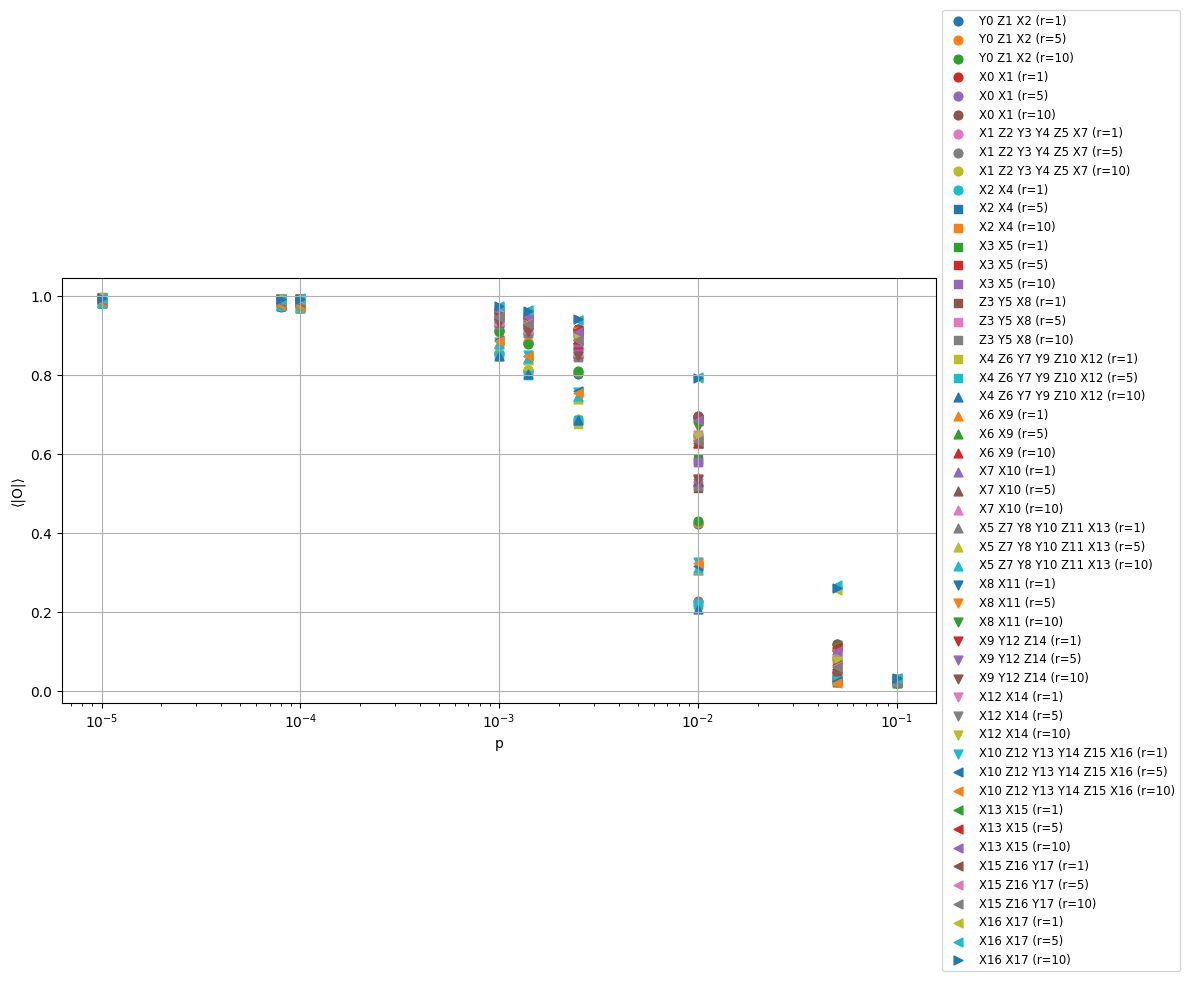

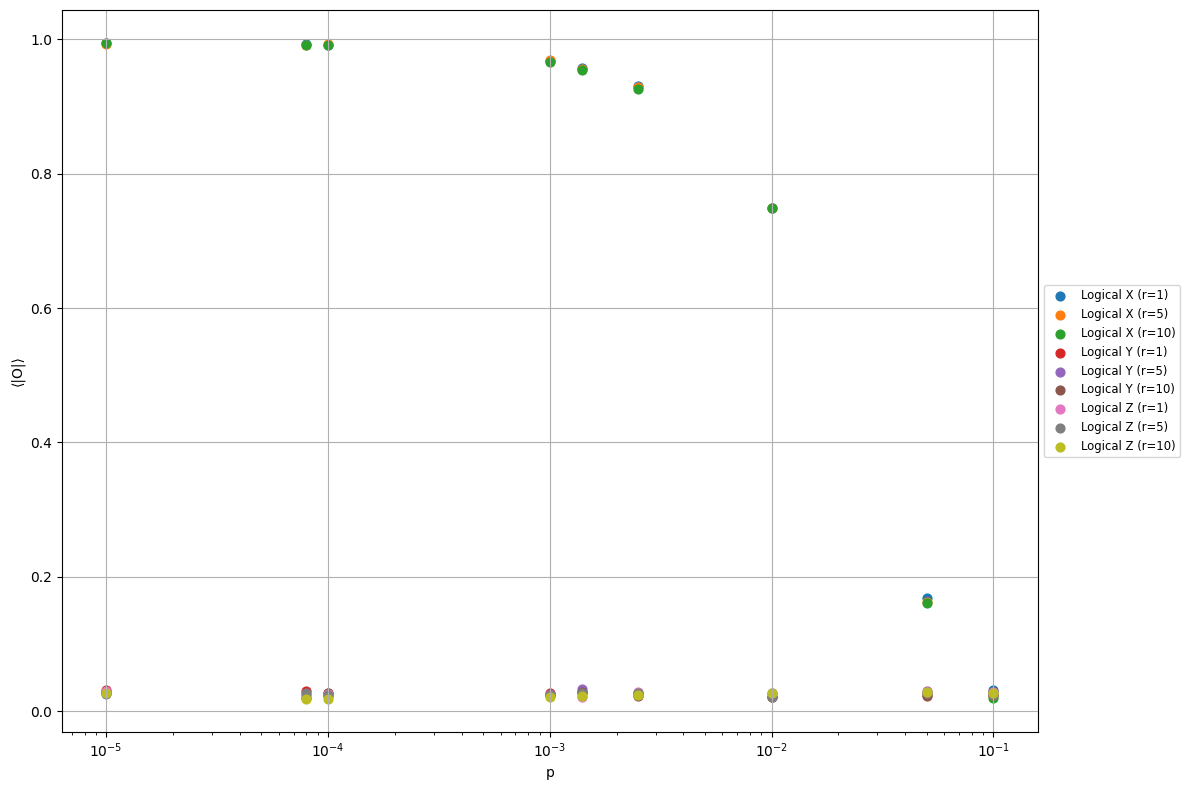

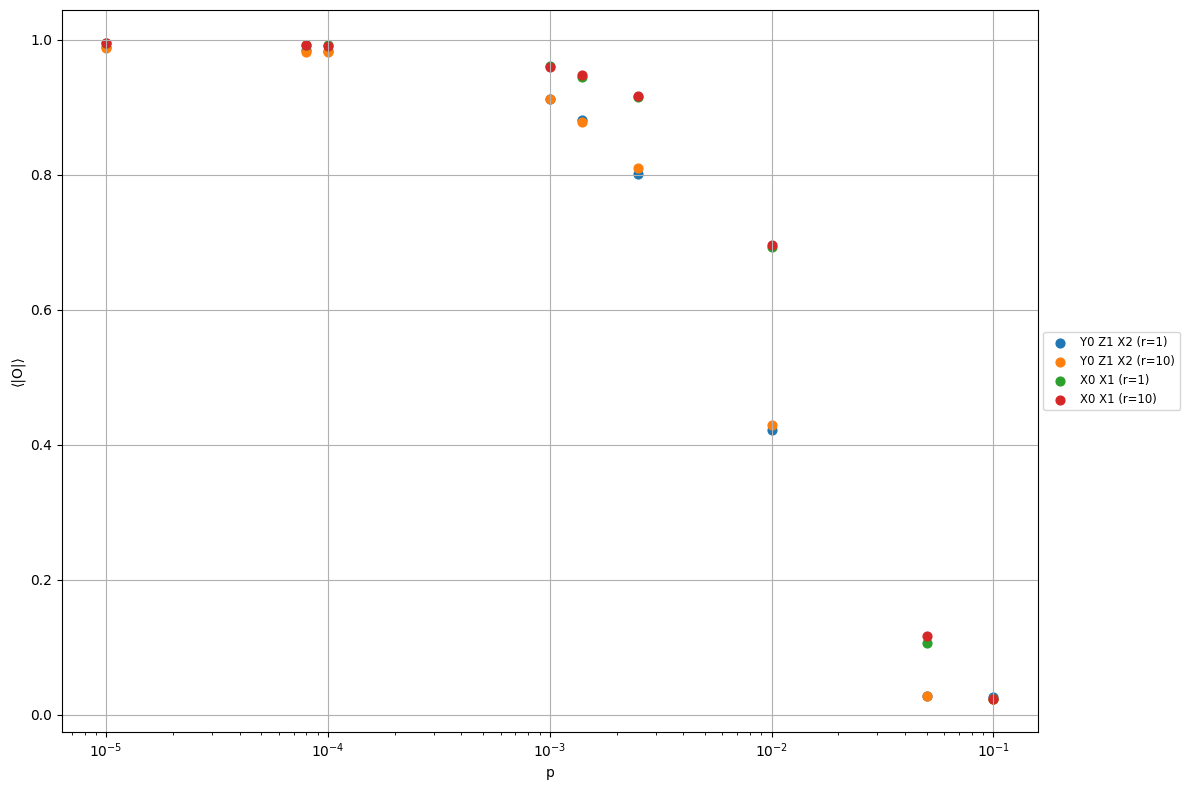

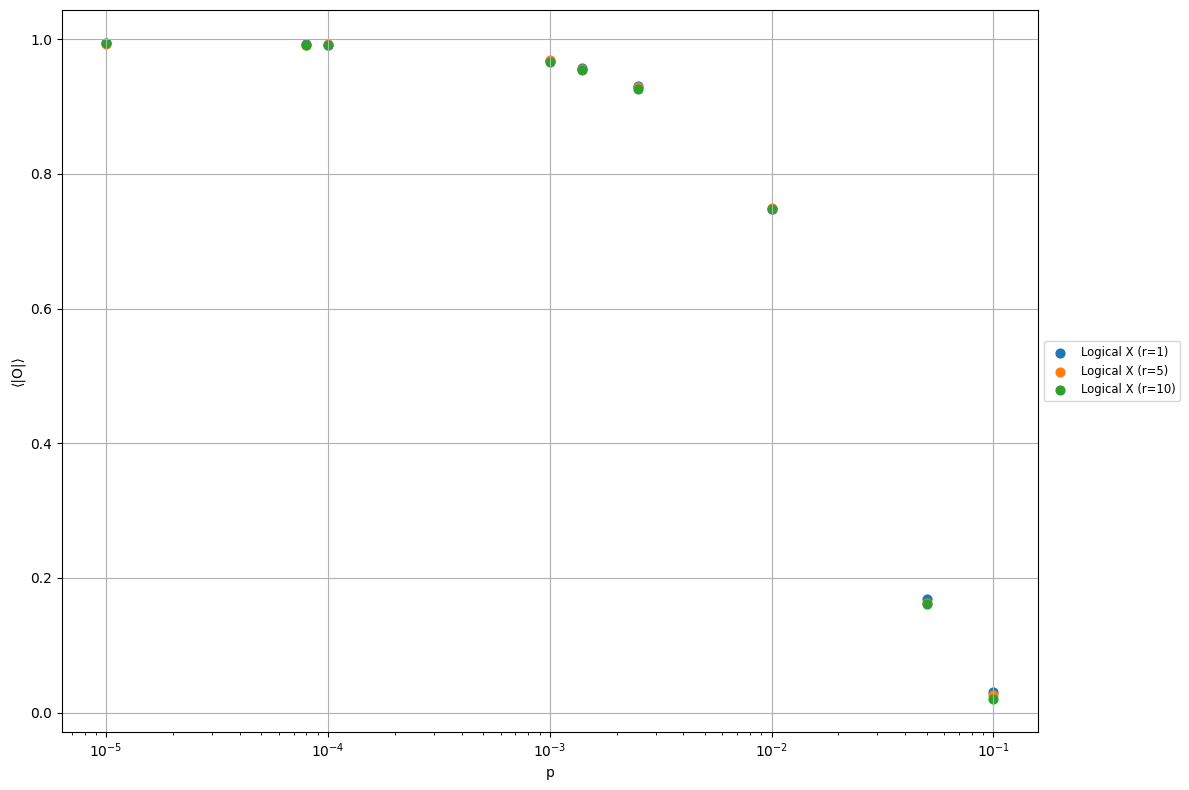

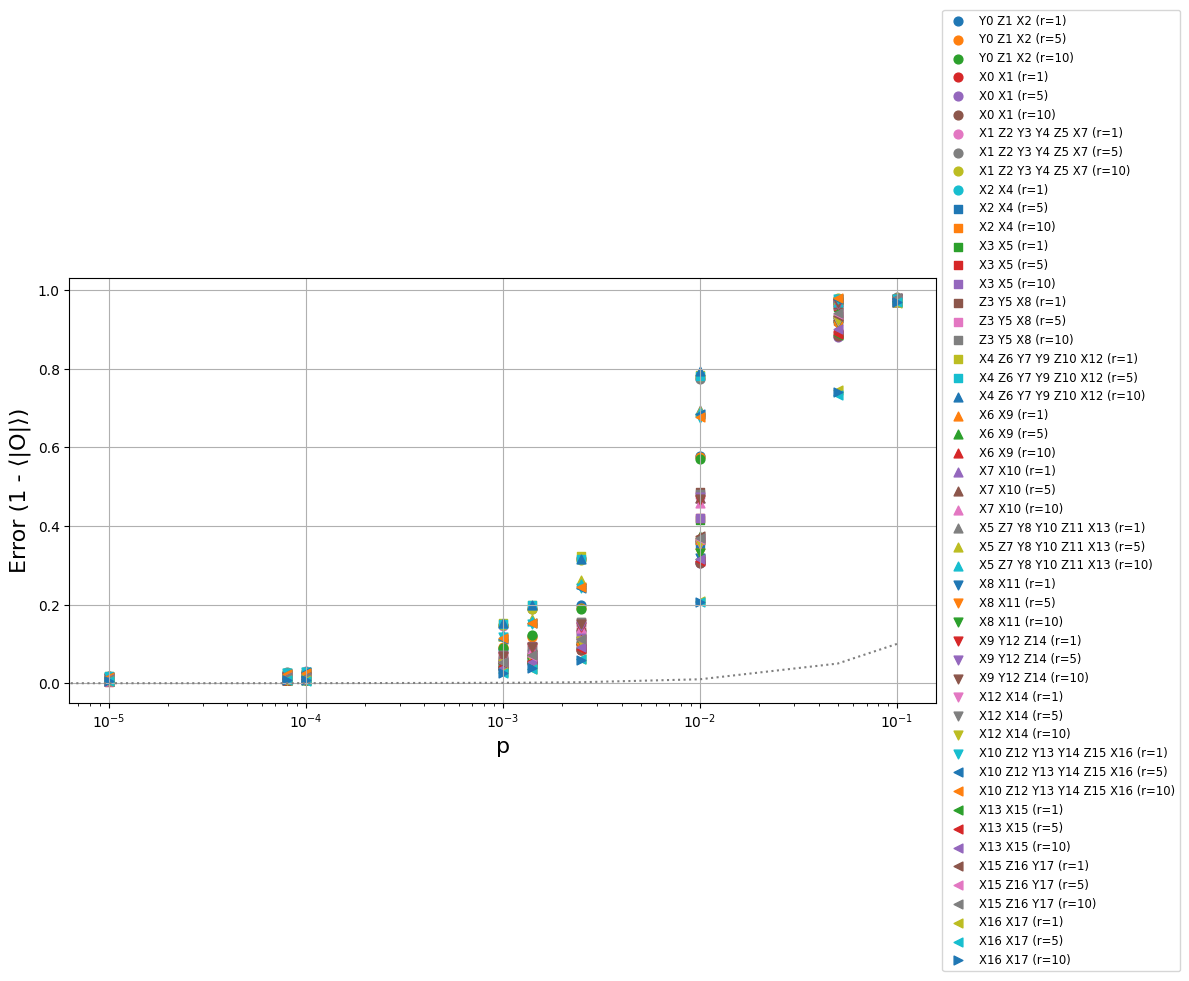

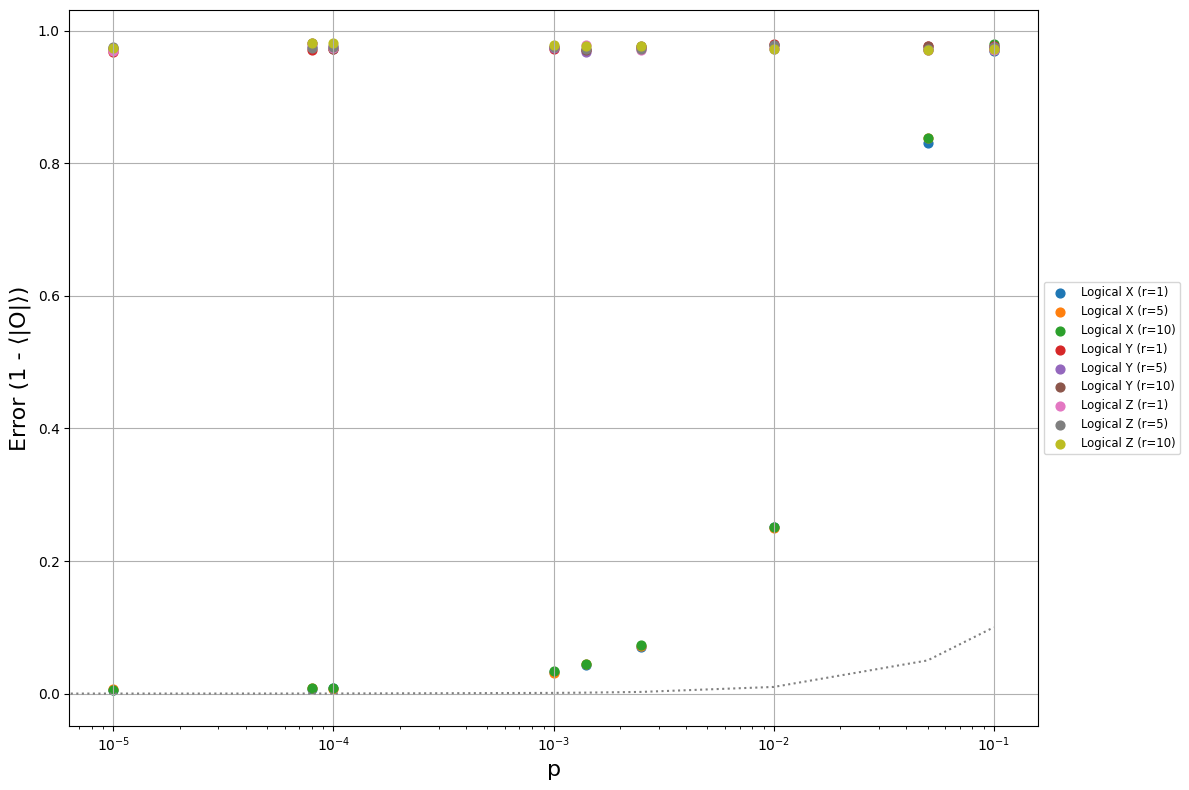

In [41]:
# 9) Overlay all stabilizers:
sweep_z_noise.plot_expectations_vs_param(
    category="stabilizer",
    rounds=rounds,
    overlay=True,
    save_path='d=3_stabilizers_overlay.pdf',
    log_x=True
)

# 10) Grid of logical plots:
sweep_z_noise.plot_expectations_vs_param(
    category="logical",
    rounds=rounds,
    overlay=True,
    cols=2,
    save_path='d=3_logicals_overlay.pdf',
    log_x=True
)

sweep_z_noise.plot_expectations_vs_param(
    category="stabilizer",
    rounds=[1,10],
    subset=["Y0 Z1 X2","X0 X1"],
    overlay=True,
    log_x=True
)

sweep_z_noise.plot_expectations_vs_param(
    category="logical",
    rounds=[1,5,10],
    subset=["Logical X"],
    overlay=True,
    cols=1,
    save_path='d=3_logical_X_overlay.pdf',
    log_x=True
)

sweep_z_noise.plot_error_rates_vs_param(
    category="stabilizer",
    rounds=[1,5,10],
    overlay=True,
    save_path='d=3_stabilizers_error_overlay.pdf',
    log_x=True
)

sweep_z_noise.plot_error_rates_vs_param(
    category="logical",
    rounds=[1,5,10],
    overlay=True,
    save_path='d=3_logicals_error_overlay.pdf',
    log_x=True
)

### Sweep through for Pure Z Noise

In [42]:
import numpy as np

# 1) Define your code stabilizers & toggles:
code_stabs = [
  "Y0 Z1 X2", "X0 X1", "X1 Z2 Y3 Y4 Z5 X7",
  "X2 X4", "X3 X5", "Z3 Y5 X8", "X4 Z6 Y7 Y9 Z10 X12",
  "X6 X9", "X7 X10", "X5 Z7 Y8 Y10 Z11 X13", "X8 X11",
  "X9 Y12 Z14", "X12 X14", "X10 Z12 Y13 Y14 Z15 X16",
  "X13 X15", "X15 Z16 Y17", "X16 X17", "X9 X10 X11"
]    # for building MDRCircuit
toggles = [
    "X0", "Y0", "X2", "X0 Z2", "X2 Z3", "X2 X3",
    "X6", "Z6", "X2 X6 Z7", "X8", "X2 X3 Y8",
    "X12 X13", "X13 Z14", "X13", "X8 Y13",
    "X16", "Y17", "X2 X3 Y8 Z11"
]


# 2) Operators to measure:
meas_stabs = [
  "Y0 Z1 X2", "X0 X1", "X1 Z2 Y3 Y4 Z5 X7",
  "X2 X4", "X3 X5", "Z3 Y5 X8", "X4 Z6 Y7 Y9 Z10 X12",
  "X6 X9", "X7 X10", "X5 Z7 Y8 Y10 Z11 X13", "X8 X11",
  "X9 Y12 Z14", "X12 X14", "X10 Z12 Y13 Y14 Z15 X16",
  "X13 X15", "X15 Z16 Y17", "X16 X17"
]
logical_ops= {
  "Logical X": "X9 X10 X11",
  "Logical Y": "X4 Z7 Y10 X13",
  "Logical Z": "X4 Z7 X9 Z10 X13 X11",
}

# 3) Fixed SPAM error:
p_spam = 1.339e-3

# 4) Build your |+> prep circuit if not already defined
psi_circuit = stim.Circuit()
psi_circuit.append_operation('H', [9,10,11])

# 5) MDR rounds and shots
rounds = [1,5,10]
shots  = 1000

# 64) Which keys to sweep, and the common range
param_names = ['g1_z','IZ','ZI','ZZ']
param_range = [0, 0.00001, 8e-5, 0.0001, 0.001, 1.4e-3, 0.0025, 0.01, 0.05, 0.1]

# 7) Instantiate the synchronous sweep
sweep_pure_z_noise = MdrNoiseSweep(
    code_stabilizers    = code_stabs,
    toggles             = toggles,
    measure_stabilizers = meas_stabs,
    logical_operators   = logical_ops,
    ancillas            = 1,
    psi_circuit         = psi_circuit,
    p_spam              = p_spam,
    param_names         = param_names,   # list of all 8 keys
    param_values        = param_range,   # single list => sync mode
    round_list          = rounds,
    shots               = shots,
    num_replicates      = 30
)


# 9) To inspect one point:
combo = sweep_pure_z_noise.param_combos[2]   # third tuple, e.g. (0.001,0.001,…)
val   = sweep_pure_z_noise.results[combo][10]['Logical X']
print(f"|⟨Logical X⟩| = {val:.4f}")


|⟨Logical X⟩| = 0.9929


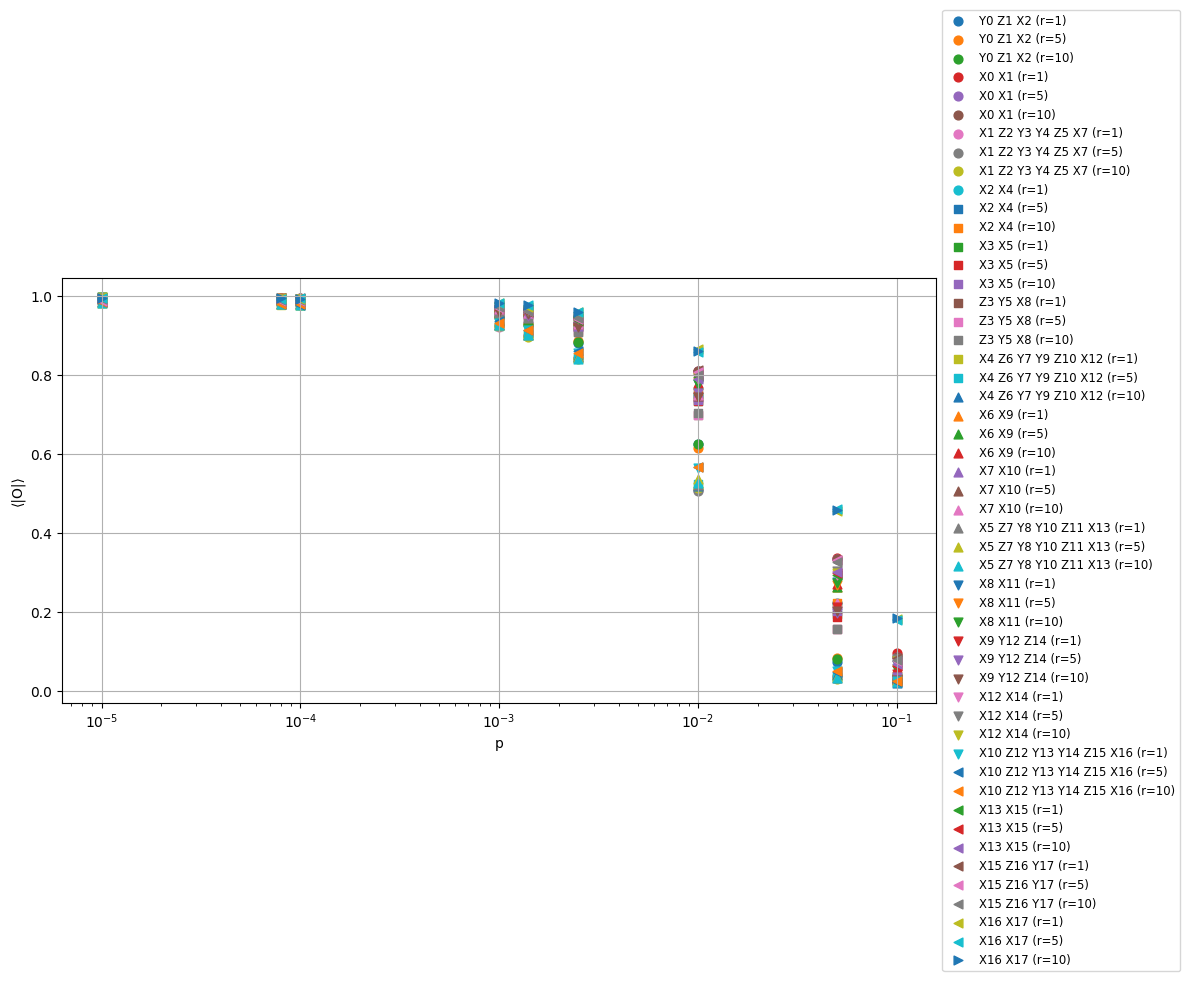

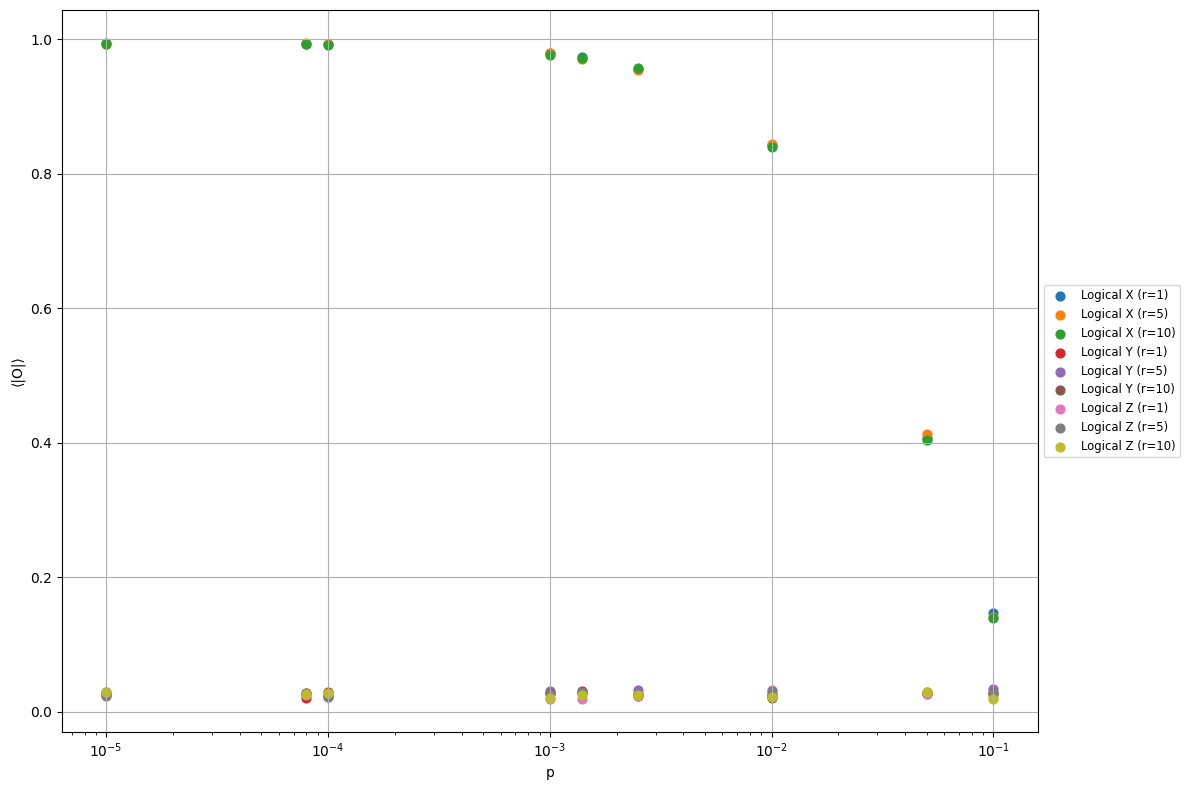

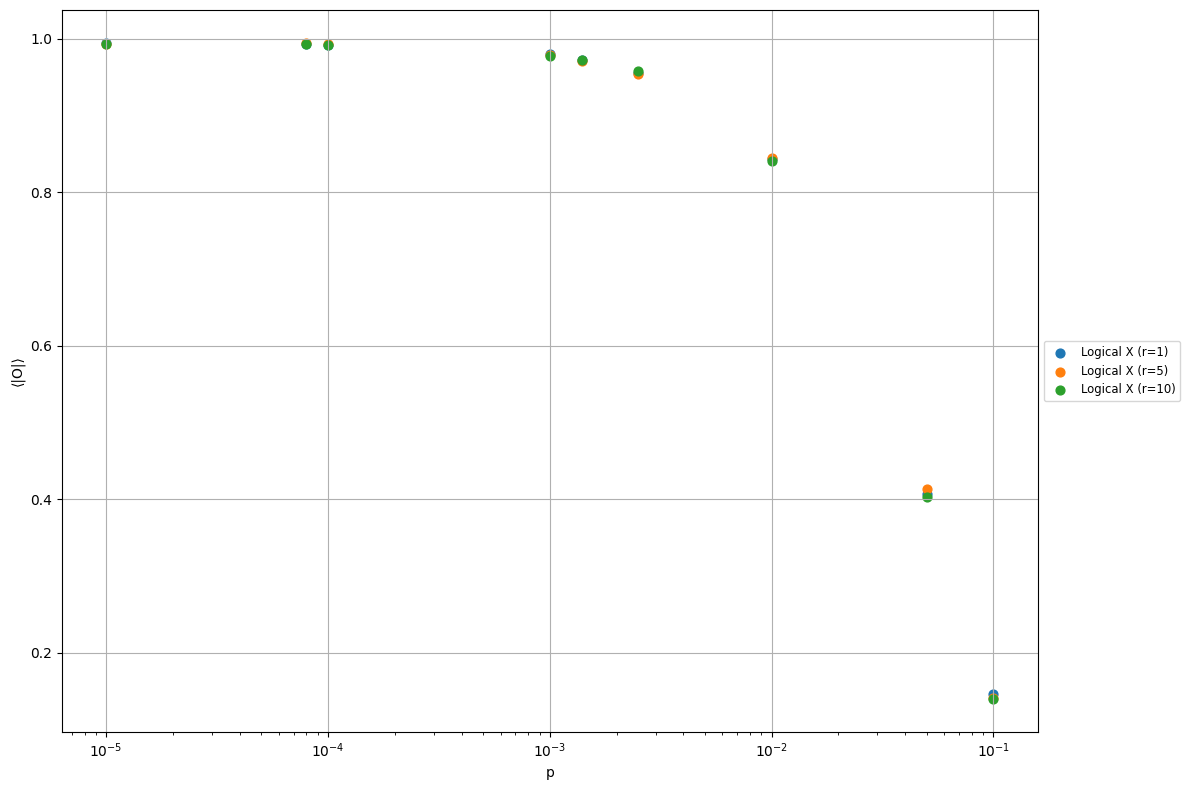

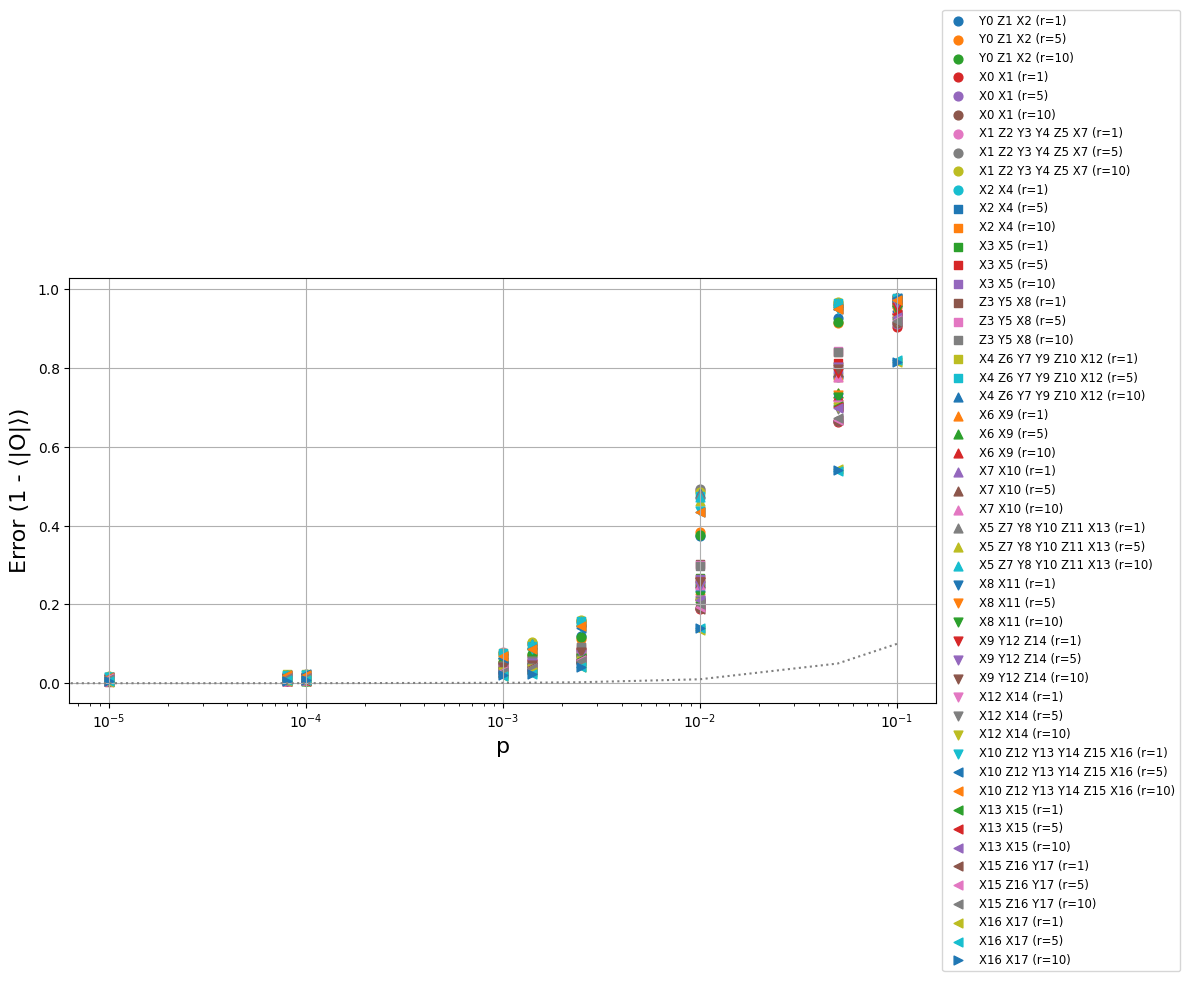

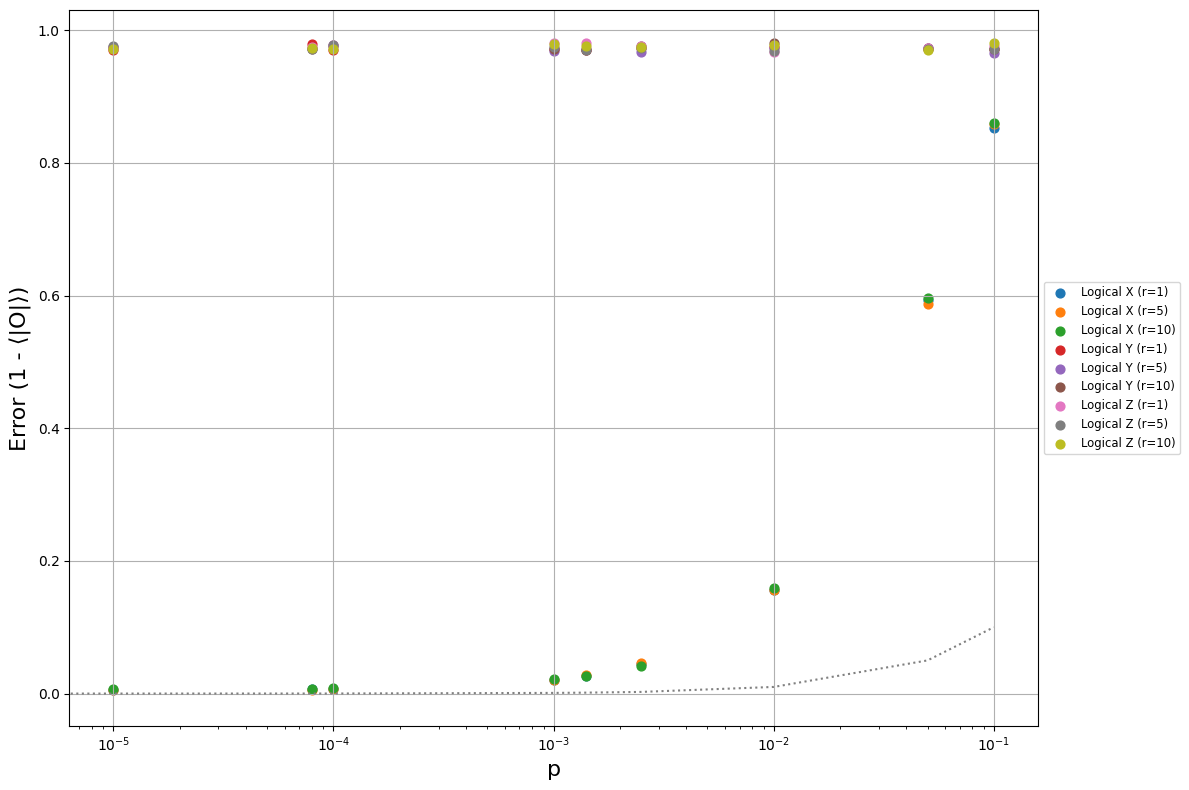

In [43]:
# 9) Overlay all stabilizers:
sweep_pure_z_noise.plot_expectations_vs_param(
    category="stabilizer",
    rounds=rounds,
    overlay=True,
    save_path='d=3_pure_z_noise_stabilizers_overlay.pdf',
    log_x=True
)

# 10) Grid of logical plots:
sweep_pure_z_noise.plot_expectations_vs_param(
    category="logical",
    rounds=rounds,
    overlay=True,
    cols=2,
    save_path='d=3_pure_z_noise_logicals_overlay.pdf',
    log_x=True
)

sweep_pure_z_noise.plot_expectations_vs_param(
    category="logical",
    rounds=[1,5,10],
    subset=["Logical X"],
    overlay=True,
    cols=1,
    save_path='d=3_pure_z_noise_logical_X_overlay.pdf',
    log_x=True
)

sweep_pure_z_noise.plot_error_rates_vs_param(
    category="stabilizer",
    rounds=[1,5,10],
    overlay=True,
    save_path='d=3_pure_z_noise_stabilizers_error_overlay.pdf',
    log_x=True
)

sweep_pure_z_noise.plot_error_rates_vs_param(
    category="logical",
    rounds=[1,5,10],
    overlay=True,
    save_path='d=3_pure_z_noise_logicals_error_overlay.pdf',
    log_x=True
)

### Unbiased Uniform Noise

In [44]:
import numpy as np

# 1) Define your code stabilizers & toggles:
code_stabs = [
  "Y0 Z1 X2", "X0 X1", "X1 Z2 Y3 Y4 Z5 X7",
  "X2 X4", "X3 X5", "Z3 Y5 X8", "X4 Z6 Y7 Y9 Z10 X12",
  "X6 X9", "X7 X10", "X5 Z7 Y8 Y10 Z11 X13", "X8 X11",
  "X9 Y12 Z14", "X12 X14", "X10 Z12 Y13 Y14 Z15 X16",
  "X13 X15", "X15 Z16 Y17", "X16 X17", "X9 X10 X11"
]    # for building MDRCircuit
toggles = [
    "X0", "Y0", "X2", "X0 Z2", "X2 Z3", "X2 X3",
    "X6", "Z6", "X2 X6 Z7", "X8", "X2 X3 Y8",
    "X12 X13", "X13 Z14", "X13", "X8 Y13",
    "X16", "Y17", "X2 X3 Y8 Z11"
]


# 2) Operators to measure:
meas_stabs = [
  "Y0 Z1 X2", "X0 X1", "X1 Z2 Y3 Y4 Z5 X7",
  "X2 X4", "X3 X5", "Z3 Y5 X8", "X4 Z6 Y7 Y9 Z10 X12",
  "X6 X9", "X7 X10", "X5 Z7 Y8 Y10 Z11 X13", "X8 X11",
  "X9 Y12 Z14", "X12 X14", "X10 Z12 Y13 Y14 Z15 X16",
  "X13 X15", "X15 Z16 Y17", "X16 X17"
]
logical_ops= {
  "Logical X": "X9 X10 X11",
  "Logical Y": "X4 Z7 Y10 X13",
  "Logical Z": "X4 Z7 X9 Z10 X13 X11",
}

# 3) Fixed SPAM error:
p_spam = 1.339e-3

# 4) Build your |+> prep circuit if not already defined
psi_circuit = stim.Circuit()
psi_circuit.append_operation('H', [9,10,11])

# 5) MDR rounds and shots
rounds = [1,5,10]
shots  = 1000

# 64) Which keys to sweep, and the common range
param_names = ['g1_x','g1_y','g1_z','IX', 'IY', 'IZ', 'XI', 'XX', 'XY', 'XZ',
        'YI', 'YX', 'YY', 'YZ', 'ZI', 'ZX', 'ZY','ZZ']
param_range = [0, 0.00001, 8e-5, 0.0001, 0.001, 1.4e-3, 0.0025, 0.01, 0.05, 0.06]

# 7) Instantiate the synchronous sweep
sweep_unbiased_noise = MdrNoiseSweep(
    code_stabilizers    = code_stabs,
    toggles             = toggles,
    measure_stabilizers = meas_stabs,
    logical_operators   = logical_ops,
    ancillas            = 1,
    psi_circuit         = psi_circuit,
    p_spam              = p_spam,
    param_names         = param_names,   # list of all 8 keys
    param_values        = param_range,   # single list => sync mode
    round_list          = rounds,
    shots               = shots,
    num_replicates      = 30
)


# 9) To inspect one point:
combo = sweep_unbiased_noise.param_combos[2]   # third tuple, e.g. (0.001,0.001,…)
val   = sweep_unbiased_noise.results[combo][10]['Logical X']
print(f"|⟨Logical X⟩| = {val:.4f}")


|⟨Logical X⟩| = 0.9881


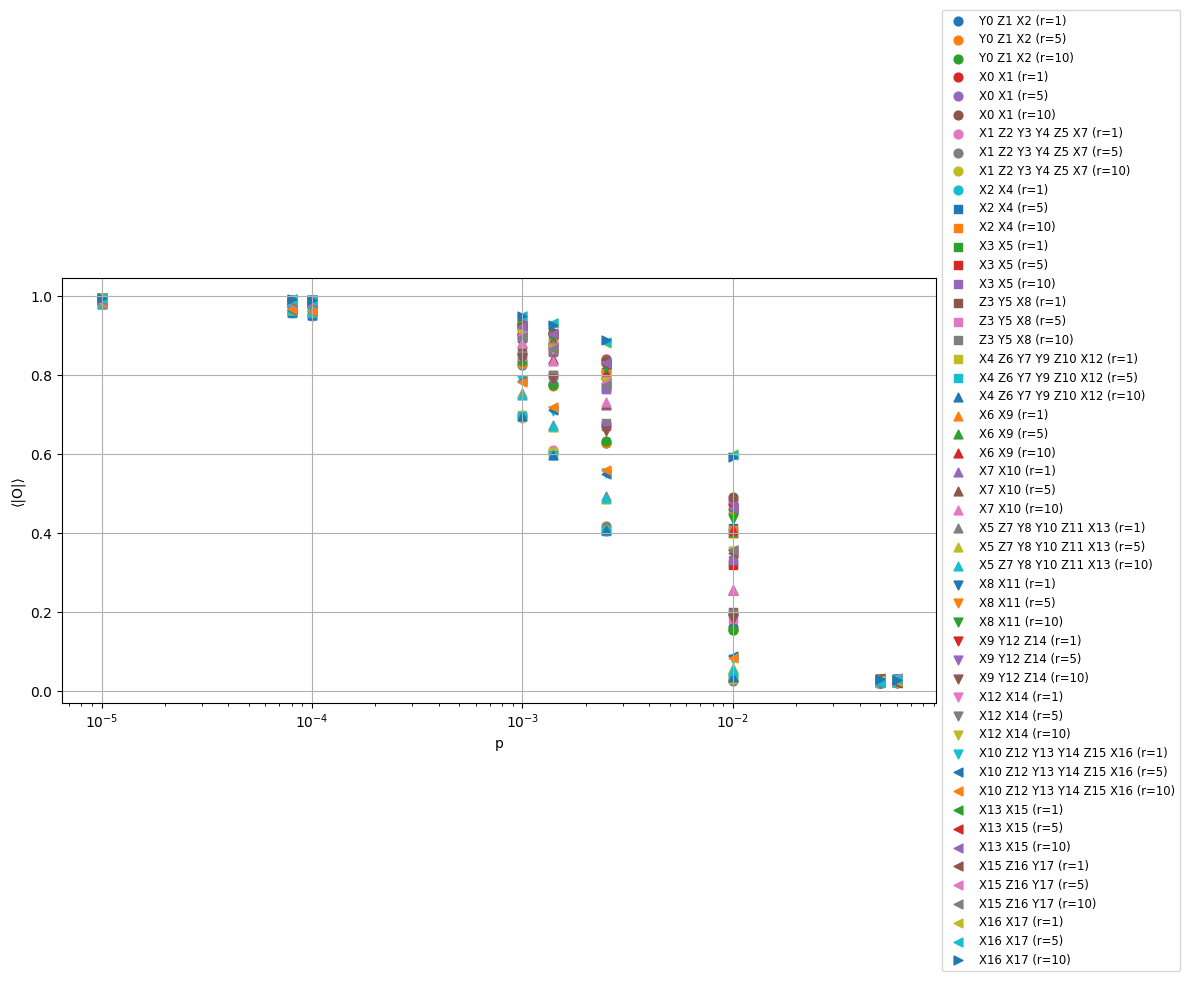

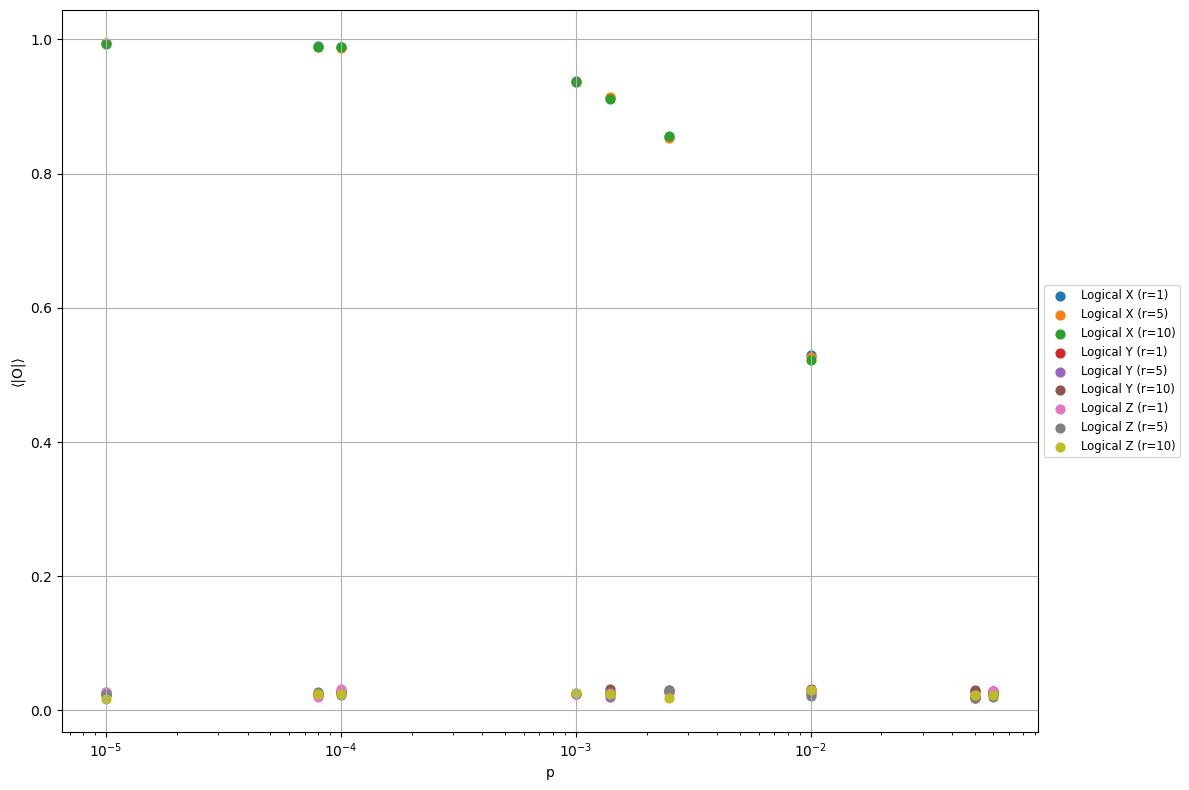

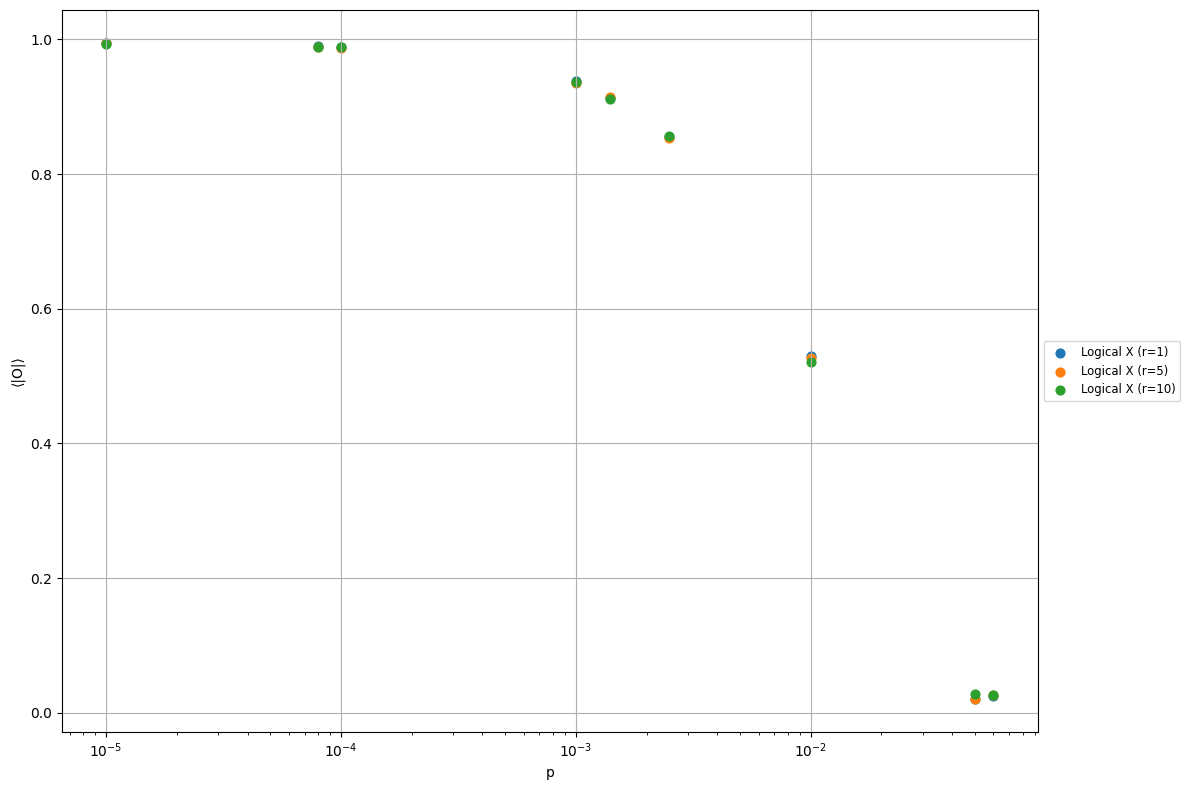

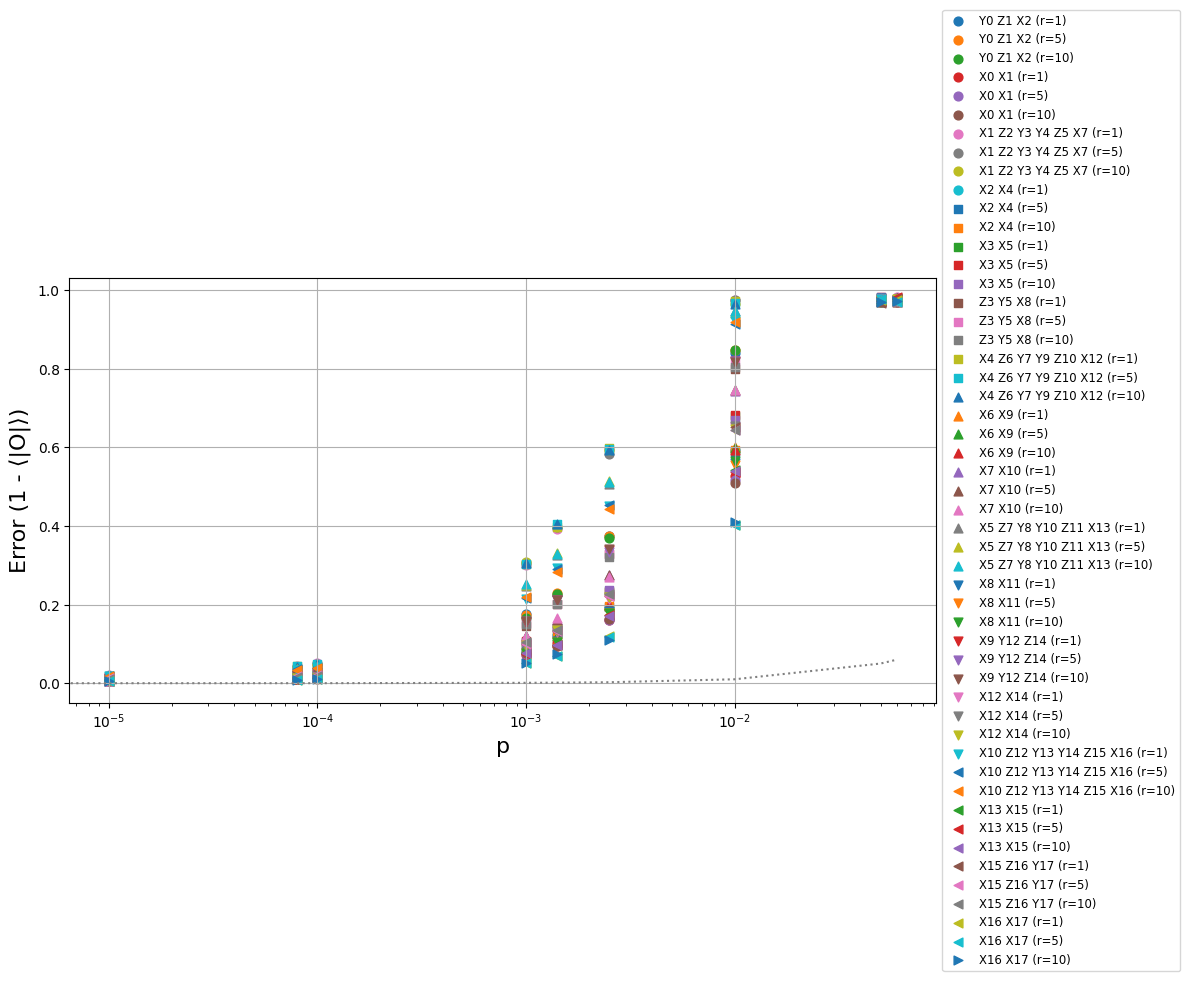

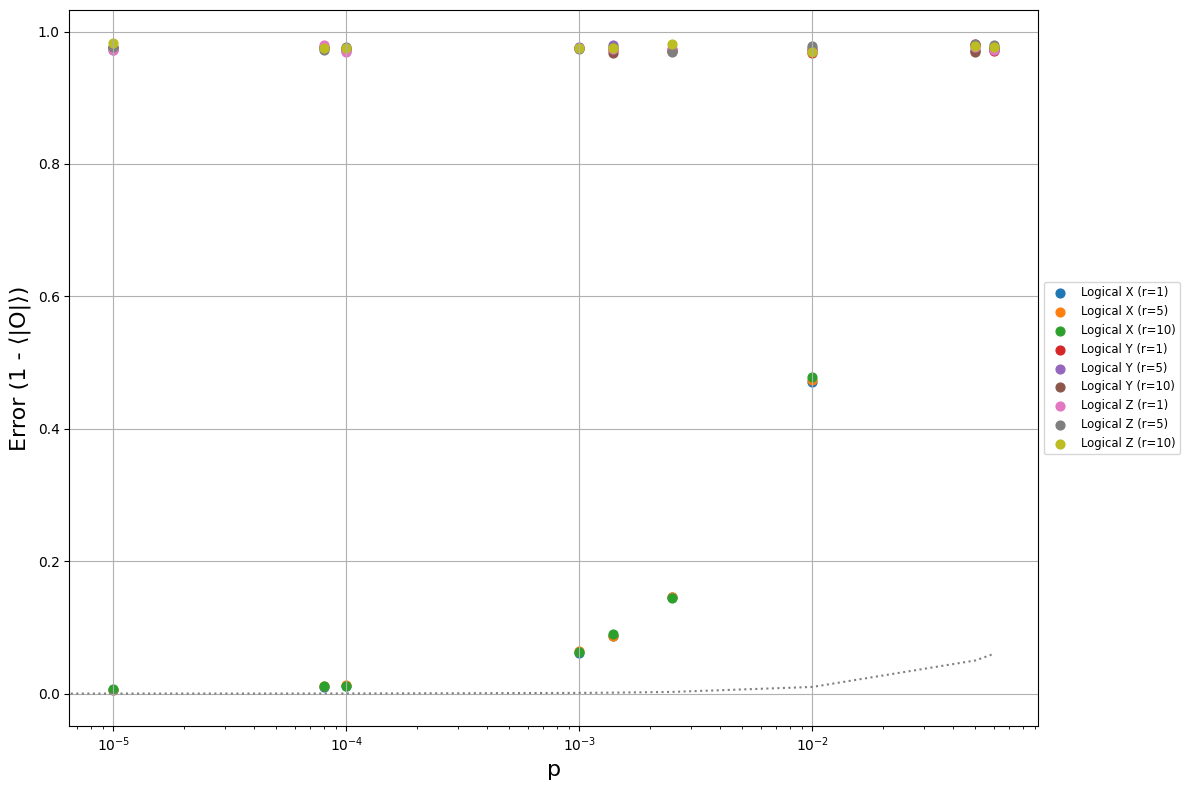

In [45]:
# 9) Overlay all stabilizers:
sweep_unbiased_noise.plot_expectations_vs_param(
    category="stabilizer",
    rounds=rounds,
    overlay=True,
    save_path='d=3_unbiased_noise_stabilizers_overlay.pdf',
    log_x=True
)

# 10) Grid of logical plots:
sweep_unbiased_noise.plot_expectations_vs_param(
    category="logical",
    rounds=rounds,
    overlay=True,
    cols=2,
    save_path='d=3_unbiased_noise_logicals_overlay.pdf',
    log_x=True
)

sweep_unbiased_noise.plot_expectations_vs_param(
    category="logical",
    rounds=[1,5,10],
    subset=["Logical X"],
    overlay=True,
    cols=1,
    save_path='d=3_unbiased_noise_logical_X_overlay.pdf',
    log_x=True
)

sweep_unbiased_noise.plot_error_rates_vs_param(
    category="stabilizer",
    rounds=[1,5,10],
    overlay=True,
    save_path='d=3_unbiased_noise_stabilizers_error_overlay.pdf',
    log_x=True
)

sweep_unbiased_noise.plot_error_rates_vs_param(
    category="logical",
    rounds=[1,5,10],
    overlay=True,
    save_path='d=3_unbiased_noise_logicals_error_overlay.pdf',
    log_x=True
)

### Comparing Z type noise and Pure Z noise

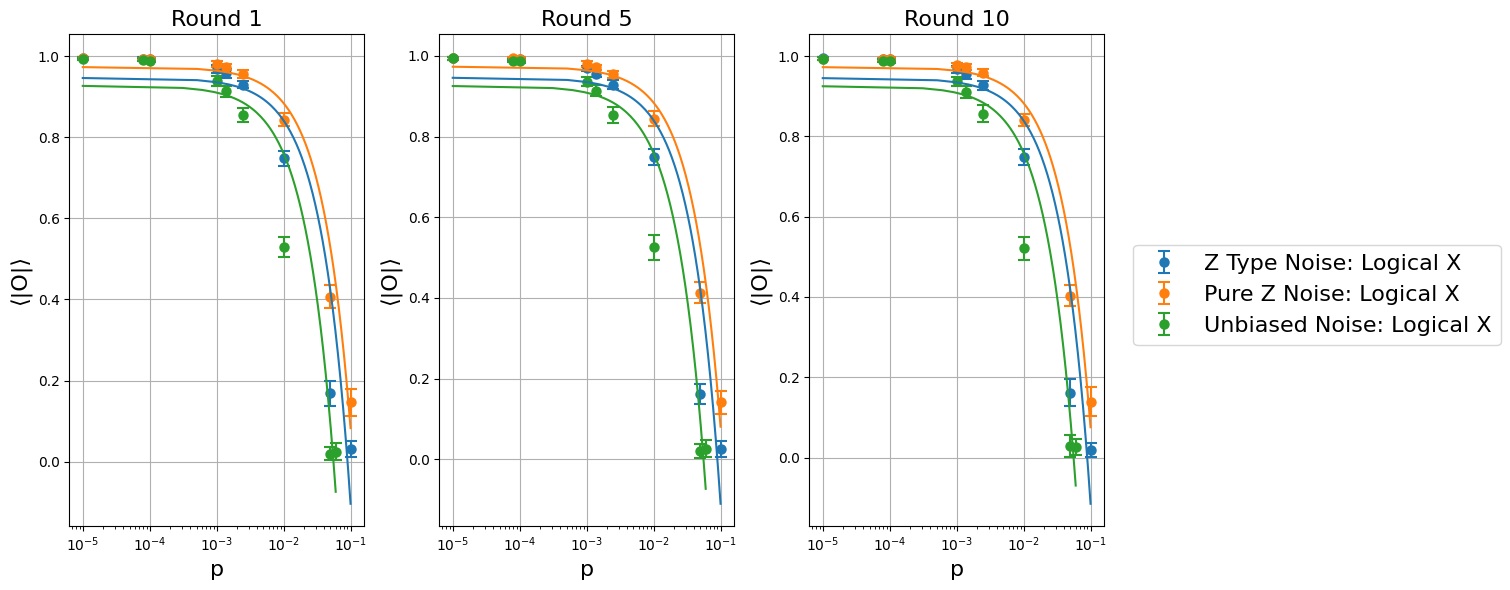

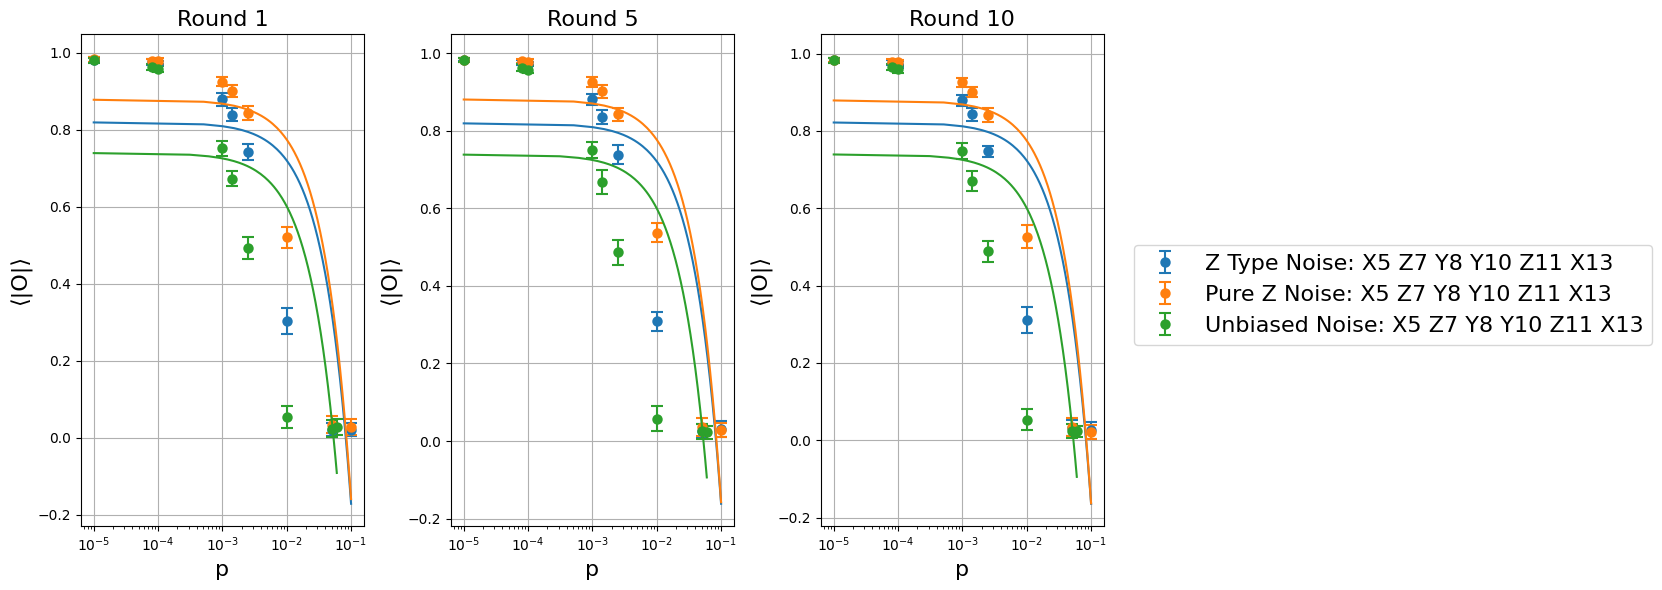

In [46]:
MdrNoiseSweep.plot_multi(
    {'Z Type Noise': sweep_z_noise, 
     'Pure Z Noise': sweep_pure_z_noise, 
     'Unbiased Noise': sweep_unbiased_noise},
    category='logical',
    rounds=[1,5,10],
    subset=['Logical X'],
    overlay=False,
    log_x=True,
    fit=True,
    save_path='d=3_comparing_noise_sweeps_logical_X.pdf'
)

MdrNoiseSweep.plot_multi(
    {'Z Type Noise': sweep_z_noise, 
     'Pure Z Noise': sweep_pure_z_noise, 
     'Unbiased Noise': sweep_unbiased_noise},
    category='stabilizer',
    rounds=[1,5,10],
    subset=["X5 Z7 Y8 Y10 Z11 X13"],
    overlay=False,
    log_x=True,
    fit=True,
    save_path='d=3_comparing_noise_sweeps_stabilizer_X5_Z7_Y8_Y10_Z11_X13.pdf'
)

In [57]:
sweep_z_noise.table_round_delta(
    (1, 5),               # rounds (r1, r2)
    category='logical',   # look at logical operators
    subset=['Logical X'],      # or ['X'] if that’s your label          # print to 4 dp
    return_df=True     # set True if you want the DataFrame back
)
sweep_z_noise.table_round_delta(
    (1, 10),               # rounds (r1, r2)
    category='logical',   # look at logical operators
    subset=['Logical X'],      # or ['X'] if that’s your label
          # print to 4 dp
    return_df=True     # set True if you want the DataFrame back
)

sweep_pure_z_noise.table_round_delta(
    (1, 5),               # rounds (r1, r2)
    category='logical',   # look at logical operators
    subset=['Logical X'],      # or ['X'] if that’s your label
    precision=4,          # print to 4 dp
    return_df=False       # set True if you want the DataFrame back
)

sweep_unbiased_noise.table_round_delta(
    (1, 5),               # rounds (r1, r2)
    category='logical',   # look at logical operators
    subset=['Logical X'],      # or ['X'] if that’s your label
    precision=4,          # print to 4 dp
    return_df=False       # set True if you want the DataFrame back
)

     param  ΔLogical X    Δavg
0.0000e+00     -0.0003 -0.0003
1.0000e-05     -0.0012 -0.0012
8.0000e-05     -0.0011 -0.0011
1.0000e-04      0.0009  0.0009
1.0000e-03      0.0009  0.0009
1.4000e-03     -0.0013 -0.0013
2.5000e-03     -0.0015 -0.0015
1.0000e-02      0.0013  0.0013
5.0000e-02     -0.0062 -0.0062
1.0000e-01     -0.0052 -0.0052
     param  ΔLogical X        Δavg
0.0000e+00 -6.0000e-04 -6.0000e-04
1.0000e-05 -8.0000e-04 -8.0000e-04
8.0000e-05 -8.0000e-04 -8.0000e-04
1.0000e-04 -1.1102e-16 -1.1102e-16
1.0000e-03 -1.4000e-03 -1.4000e-03
1.4000e-03 -2.4667e-03 -2.4667e-03
2.5000e-03 -3.4000e-03 -3.4000e-03
1.0000e-02  2.6667e-04  2.6667e-04
5.0000e-02 -6.8667e-03 -6.8667e-03
1.0000e-01 -1.1200e-02 -1.1200e-02
     param  ΔLogical X    Δavg
0.0000e+00     -0.0001 -0.0001
1.0000e-05     -0.0007 -0.0007
8.0000e-05      0.0014  0.0014
1.0000e-04      0.0002  0.0002
1.0000e-03     -0.0005 -0.0005
1.4000e-03     -0.0017 -0.0017
2.5000e-03     -0.0018 -0.0018
1.0000e-02      0.0009  0.

# Distance 2 XYZ^2 Hex Code

## Generating Stabilizers and Logical Operators

In [93]:
d2_stabilizers = ["X0 X1", "Y0 Z1 X2", "X1 Z2 Y3 Y4 Z5 X6", "X2 X4", "X3 X5", 
                  "X6 X7", "X5 Z6 Y7"]

logical_x = ['X4 X5']

MDR_d2_stabilizers = d2_stabilizers + logical_x

MDR_d2_toggle_generator = ToggleGenerator(
    d2_stabilizers, logical_x, num_qubits=8, max_weight=3)

MDR_d2_toggles = MDR_d2_toggle_generator.generate_toggles()
MDR_d2_toggles_combined = MDR_d2_toggles[0] + MDR_d2_toggles[1]


MDR_d2_toggles_combined 

['Y0', 'X0', 'X2', 'X0 Z2', 'Y3', 'Y7', 'X6', 'X0 Y2 Z4']

## MDR Simulation for $d=2$

### Z Type Noise

In [94]:
import numpy as np
import stim

d2_logical_ops= {
  "Logical X": "X4 X5",
  "Logical Y": "Z3 Y5 X6",
  "Logical Z": "Z3 X4 Z5 X6",
}

# 3) Fixed SPAM error:
p_spam = 1.339e-3

# 4) Build your |+> prep circuit if not already defined
psi_circuit = stim.Circuit()
psi_circuit.append_operation('H', [4,5])

# 5) MDR rounds and shots
rounds = [1,5,10]
shots  = 1000

# 64) Which keys to sweep, and the common range
param_names = ['g1_z','IZ','ZI','ZZ','ZX','ZY','XZ','YZ']
param_range = [0, 0.00001, 8e-5, 0.0001, 0.001, 1.4e-3, 0.0025, 0.01, 0.05, 0.1]

# 7) Instantiate the synchronous sweep
sweep_z_noise_d2 = MdrNoiseSweep(
    code_stabilizers    = MDR_d2_stabilizers,
    toggles             = MDR_d2_toggles_combined,
    measure_stabilizers = d2_stabilizers,
    logical_operators   = d2_logical_ops,
    ancillas            = 1,
    psi_circuit         = psi_circuit,
    p_spam              = p_spam,
    param_names         = param_names,   # list of all 8 keys
    param_values        = param_range,   # single list => sync mode
    round_list          = rounds,
    shots               = shots,
    num_replicates      = 30
)


# 9) To inspect one point:
combo = sweep_z_noise_d2.param_combos[2]   # third tuple, e.g. (0.001,0.001,…)
val   = sweep_z_noise_d2.results[combo][10]['Logical X']
print(f"|⟨Logical X⟩| = {val:.4f}")


|⟨Logical X⟩| = 0.9929


### Pure Z noise

In [95]:
import numpy as np
import stim

d2_logical_ops= {
  "Logical X": "X4 X5",
  "Logical Y": "Z3 Y5 X6",
  "Logical Z": "Z3 X4 Z5 X6",
}

# 3) Fixed SPAM error:
p_spam = 1.339e-3

# 4) Build your |+> prep circuit if not already defined
psi_circuit = stim.Circuit()
psi_circuit.append_operation('H', [4,5])

# 5) MDR rounds and shots
rounds = [1,5,10]
shots  = 1000

# 64) Which keys to sweep, and the common range
param_names = ['g1_z','IZ','ZI','ZZ']
param_range = [0, 0.00001, 8e-5, 0.0001, 0.001, 1.4e-3, 0.0025, 0.01, 0.05, 0.1]

# 7) Instantiate the synchronous sweep
sweep_pure_z_noise_d2 = MdrNoiseSweep(
    code_stabilizers    = MDR_d2_stabilizers,
    toggles             = MDR_d2_toggles_combined,
    measure_stabilizers = d2_stabilizers,
    logical_operators   = d2_logical_ops,
    ancillas            = 1,
    psi_circuit         = psi_circuit,
    p_spam              = p_spam,
    param_names         = param_names,   # list of all 8 keys
    param_values        = param_range,   # single list => sync mode
    round_list          = rounds,
    shots               = shots,
    num_replicates      = 30
)


# 9) To inspect one point:
combo = sweep_pure_z_noise_d2.param_combos[2]   # third tuple, e.g. (0.001,0.001,…)
val   = sweep_pure_z_noise_d2.results[combo][10]['Logical X']
print(f"|⟨Logical X⟩| = {val:.4f}")


|⟨Logical X⟩| = 0.9942


### Unbiased Noise

In [96]:
import numpy as np
import stim

d2_logical_ops= {
  "Logical X": "X4 X5",
  "Logical Y": "Z3 Y5 X6",
  "Logical Z": "Z3 X4 Z5 X6",
}

# 3) Fixed SPAM error:
p_spam = 1.339e-3

# 4) Build your |+> prep circuit if not already defined
psi_circuit = stim.Circuit()
psi_circuit.append_operation('H', [4,5])

# 5) MDR rounds and shots
rounds = [1,5,10]
shots  = 1000

# 64) Which keys to sweep, and the common range
param_names = ['g1_x','g1_y','g1_z','IX', 'IY', 'IZ', 'XI', 'XX', 'XY', 'XZ',
        'YI', 'YX', 'YY', 'YZ', 'ZI', 'ZX', 'ZY','ZZ']
param_range = [0, 0.00001, 8e-5, 0.0001, 0.001, 1.4e-3, 0.0025, 0.01, 0.05, 0.06]

# 7) Instantiate the synchronous sweep
sweep_unbiased_noise_d2 = MdrNoiseSweep(
    code_stabilizers    = MDR_d2_stabilizers,
    toggles             = MDR_d2_toggles_combined,
    measure_stabilizers = d2_stabilizers,
    logical_operators   = d2_logical_ops,
    ancillas            = 1,
    psi_circuit         = psi_circuit,
    p_spam              = p_spam,
    param_names         = param_names,   # list of all 8 keys
    param_values        = param_range,   # single list => sync mode
    round_list          = rounds,
    shots               = shots,
    num_replicates      = 30
)


# 9) To inspect one point:
combo = sweep_unbiased_noise_d2.param_combos[2]   # third tuple, e.g. (0.001,0.001,…)
val   = sweep_unbiased_noise_d2.results[combo][10]['Logical X']
print(f"|⟨Logical X⟩| = {val:.4f}")


|⟨Logical X⟩| = 0.9912


### Comparing Plots for d=2

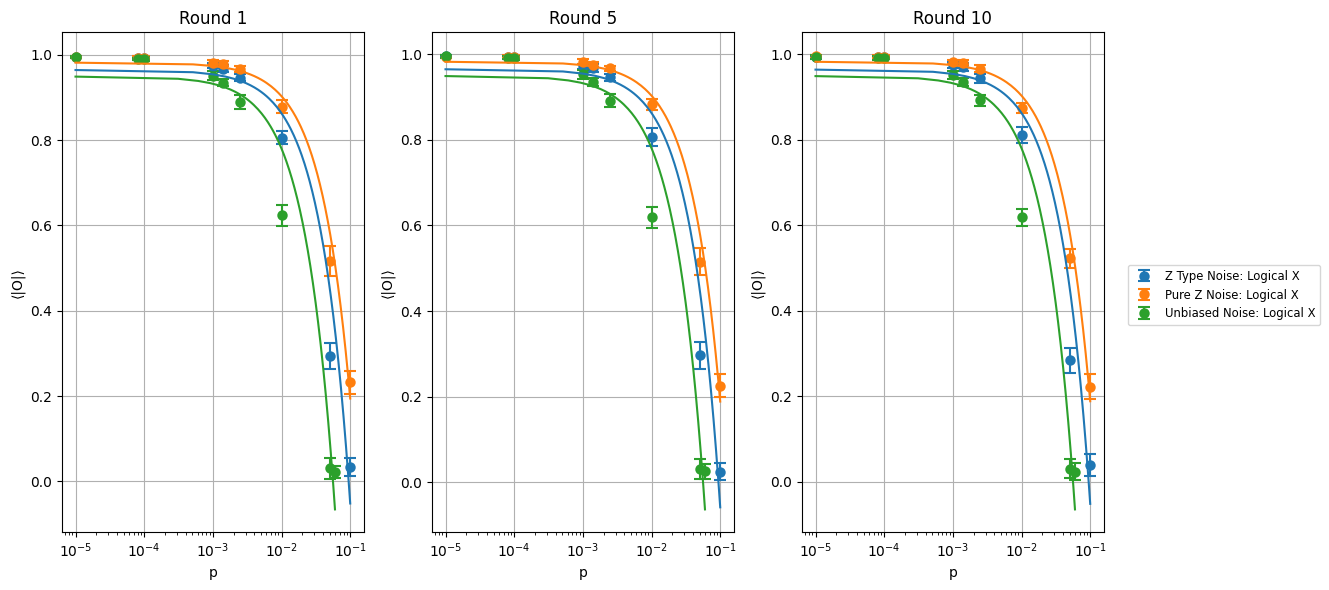

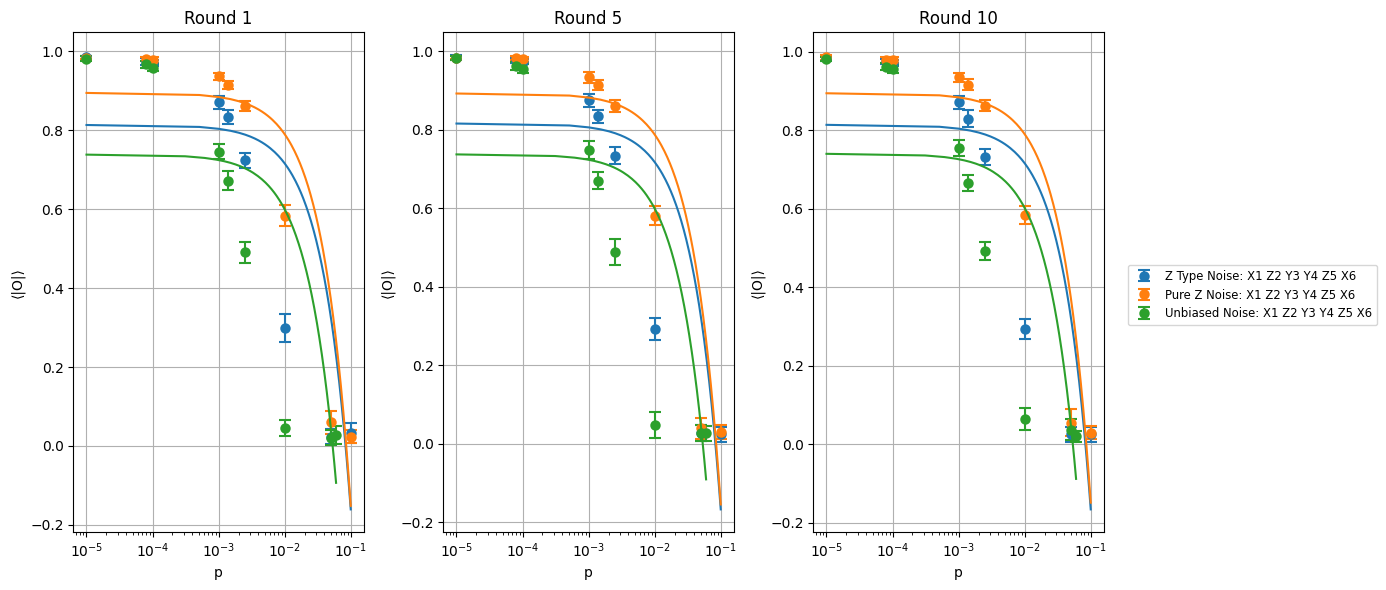

In [97]:
MdrNoiseSweep.plot_multi(
    {'Z Type Noise': sweep_z_noise_d2, 
     'Pure Z Noise': sweep_pure_z_noise_d2, 
     'Unbiased Noise': sweep_unbiased_noise_d2},
    category='logical',
    rounds=[1,5,10],
    subset=['Logical X'],
    overlay=False,
    log_x=True,
    fit=True,
    save_path='d=2_comparing_noise_sweeps_logical_X.pdf'
)

MdrNoiseSweep.plot_multi(
   {'Z Type Noise': sweep_z_noise_d2, 
     'Pure Z Noise': sweep_pure_z_noise_d2, 
     'Unbiased Noise': sweep_unbiased_noise_d2},
    category='stabilizer',
    rounds=[1,5,10],
    subset=["X1 Z2 Y3 Y4 Z5 X6"],
    overlay=False,
    log_x=True,
    fit=True,
    save_path='d=2_comparing_noise_sweeps_stabilizer_X1_Z2_Y3_Y4_Z5_X6.pdf'
)


# Comparing $d=2,3$ Plots

## Fidelities

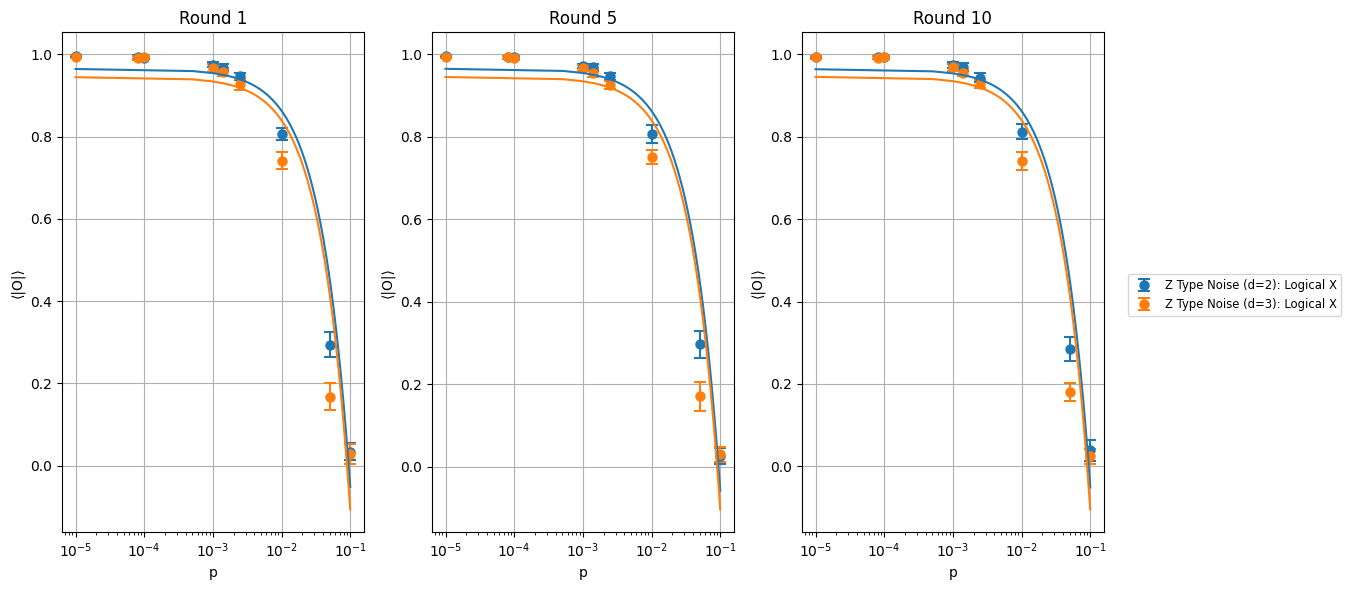

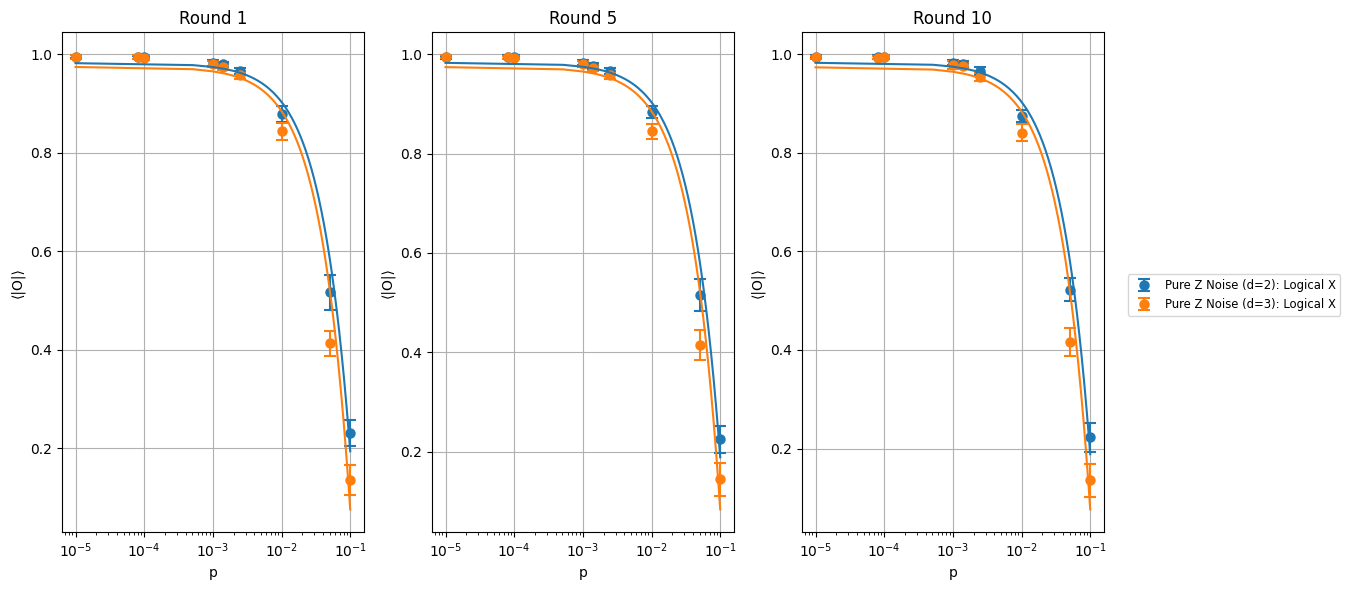

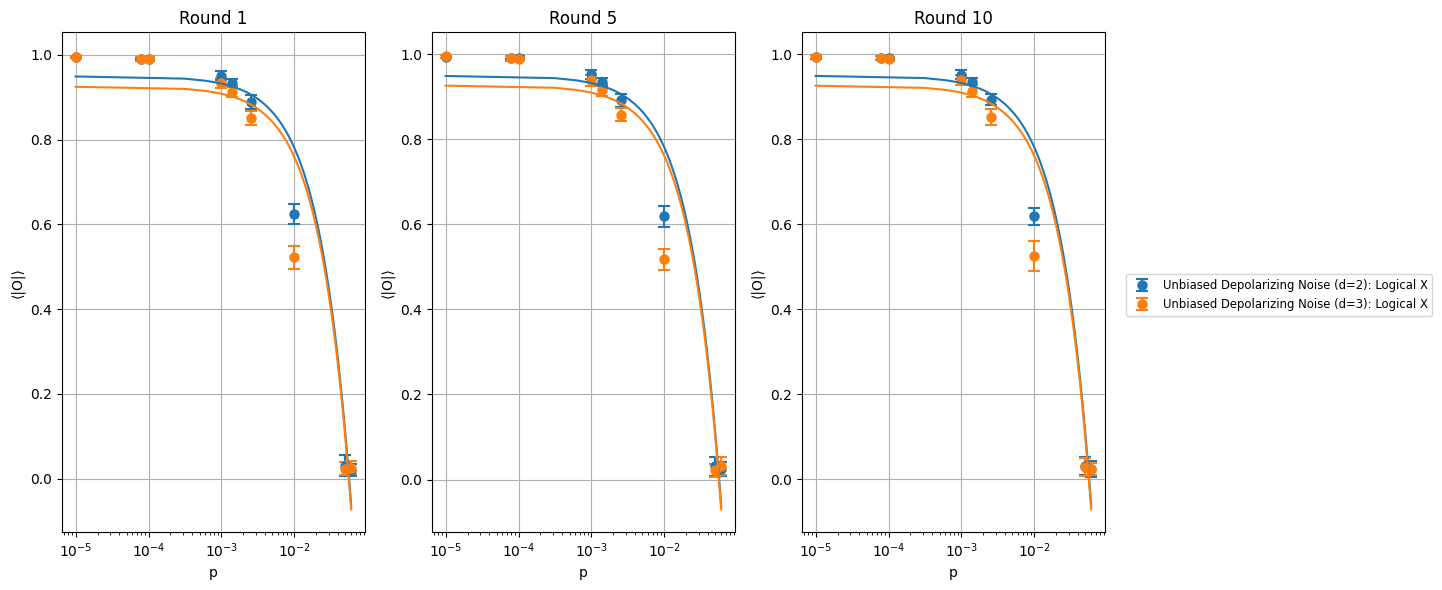

In [ ]:
MdrNoiseSweep.plot_multi(
   {'Z Type Noise (d=2)': sweep_z_noise_d2,
    'Z Type Noise (d=3)': sweep_z_noise,},
    category='logical',
    rounds=[1,5,10],
    subset=["Logical X"],
    overlay=False,
    log_x=True,
    fit=True,
    save_path='d=2,3_fidelity_z_noise_sweeps_logical_X.pdf'
)

MdrNoiseSweep.plot_multi(
   {'Pure Z Noise (d=2)': sweep_pure_z_noise_d2,
    'Pure Z Noise (d=3)': sweep_pure_z_noise},
    category='logical',
    rounds=[1,5,10],
    subset=["Logical X"],
    overlay=False,
    log_x=True,
    fit=True,
    save_path='d=2,3_fidelity_pure_z_noise_sweeps_logical_X.pdf'
)

MdrNoiseSweep.plot_multi(
   {'Unbiased Depolarizing Noise (d=2)': sweep_unbiased_noise_d2,
     'Unbiased Depolarizing Noise (d=3)': sweep_unbiased_noise},
    category='logical',
    rounds=[1,5,10],
    subset=["Logical X"],
    overlay=False,
    log_x=True,
    fit=True,
    save_path='d=2,3_fidelity_pure_z_noise_sweeps_logical_X.pdf'
)


## Error Rates

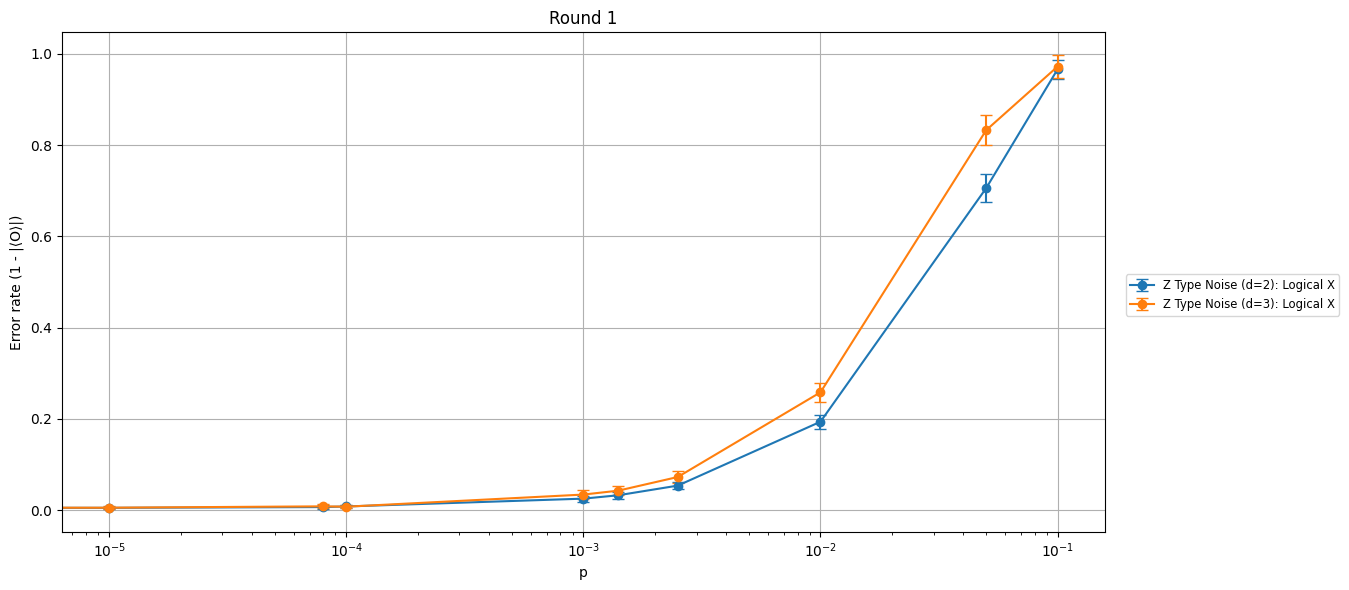

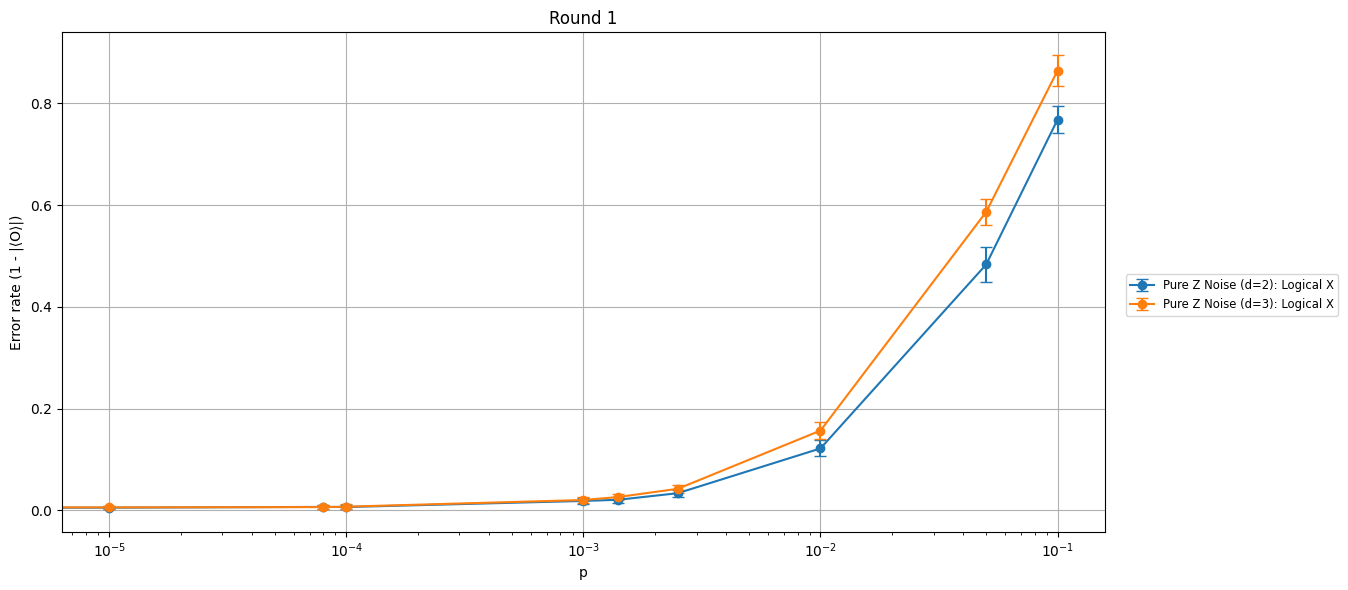

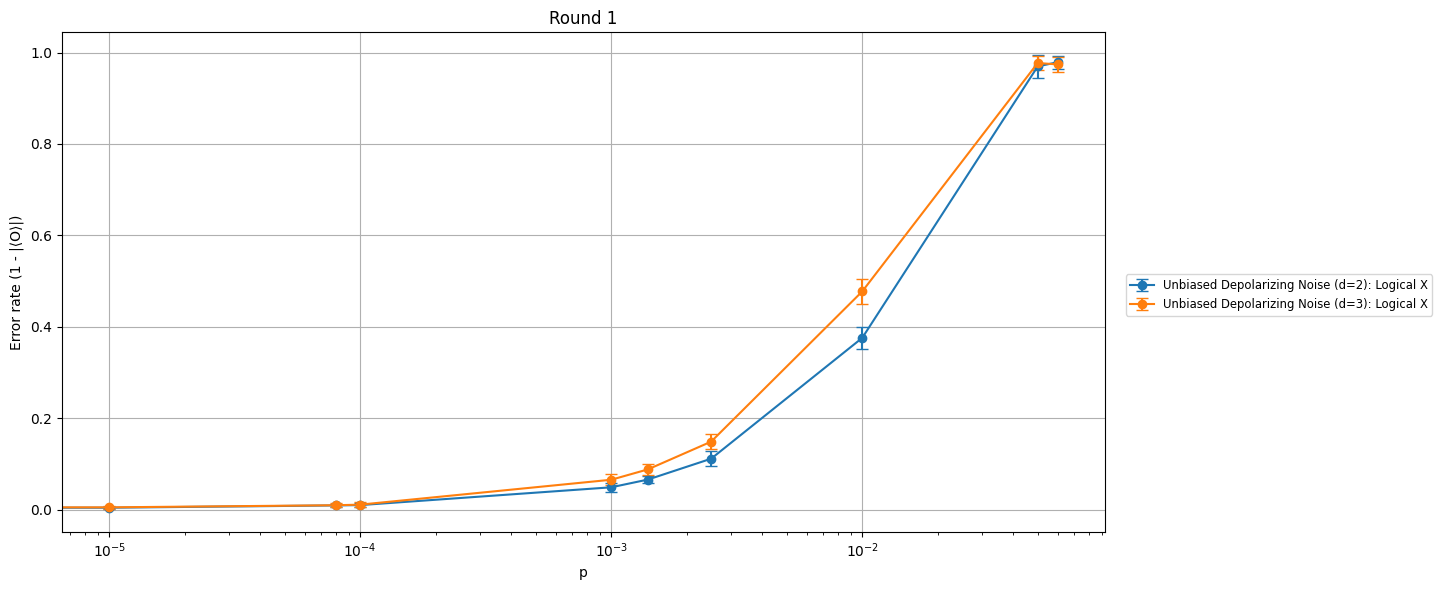

In [104]:
MdrNoiseSweep.plot_error_multi(
    {'Z Type Noise (d=2)': sweep_z_noise_d2,
    'Z Type Noise (d=3)': sweep_z_noise,},
    category='logical',
    rounds=[1],
    subset=["Logical X"],
    overlay=False,
    log_x=True,
    save_path='d=2,3_error_rates_z_noise_sweeps_logical_X.pdf'  
)

MdrNoiseSweep.plot_error_multi(
    {'Pure Z Noise (d=2)': sweep_pure_z_noise_d2,
    'Pure Z Noise (d=3)': sweep_pure_z_noise},
    category='logical',
    rounds=[1],
    subset=["Logical X"],
    overlay=False,
    log_x=True,
    save_path='d=2,3_error_rates_z_noise_sweeps_logical_X.pdf'  
)

MdrNoiseSweep.plot_error_multi(
    {'Unbiased Depolarizing Noise (d=2)': sweep_unbiased_noise_d2,
     'Unbiased Depolarizing Noise (d=3)': sweep_unbiased_noise},
    category='logical',
    rounds=[1],
    subset=["Logical X"],
    overlay=False,
    log_x=True,
    save_path='d=2,3_error_rates_z_noise_sweeps_logical_X.pdf'  
)

# $d=3,5,7,9,11$

In [13]:
import stim
import numpy as np

# 1. Setup Parameters
distances = [3, 5, 7, 9, 11]
shots = 3000
rounds = [1,5,10]

sweeps_z_type = {}
sweeps_pure_z = {}
sweeps_unbiased = {}

for d in distances:
    print(f"\n=== Setting up Distance d={d} ===")
    
    # -------------------------------------------------------------------------
    # A. Generate & Save Code Structure (Using MDRTable)
    # -------------------------------------------------------------------------
    # This automatically generates stabilizers, logicals, and toggles.
    # It also saves the table locally to 'mdr_table_d{d}.csv'.
    table_filename = f"mdr_table_d{d}.csv"
    print(f"   -> Generating and saving code table to {table_filename}...")
    
    mdr_table = MDRTable(distance=d, save_filename=table_filename)
    
    # Extract the specific lists/dicts needed for the simulation inputs
    stabs = mdr_table.get_stabilizers()
    logs_dict = mdr_table.get_logicals_dict()
    stab_toggles, log_x_toggle = mdr_table.get_toggles()
    
    # Setup Logical Dictionary for the sweep class
    logical_x_str = logs_dict["Logical X"]
    logical_ops = {
        "Logical X": logical_x_str,
        "Logical Y": logs_dict["Logical Y"],
        "Logical Z": logs_dict["Logical Z"]
    }
    
    # Prepare lists for the MDR noise sweep (Code Stabs + Logical X)
    combined_toggles = stab_toggles + [log_x_toggle]
    mdr_code_stabs = stabs + [logical_x_str]

    # -------------------------------------------------------------------------
    # B. Prepare State
    # -------------------------------------------------------------------------
    psi_circuit = stim.Circuit()
    lx_qubits = [int(term[1:]) for term in logical_x_str.split()]
    psi_circuit.append_operation('H', lx_qubits)

    # -------------------------------------------------------------------------
    # 3. Define Sweeps & Save Results
    # -------------------------------------------------------------------------
    
    # --- Sweep 1: Unbiased Noise ---
    print(f"   -> Simulating Unbiased Noise...")
    param_range_unbiased = [*np.logspace(-5, -1, 26), 0.2,0.5,1]
    param_names_u = ['g1_x','g1_y','g1_z','IX', 'IY', 'IZ', 'XI', 'XX', 'XY', 
                     'XZ','YI', 'YX', 'YY', 'YZ', 'ZI', 'ZX', 'ZY','ZZ']
    
    sweeps_unbiased[f'Unbiased Depolarizing Noise (d={d})'] = MdrNoiseSweep(
        code_stabilizers    = mdr_code_stabs,
        toggles             = combined_toggles,
        measure_stabilizers = stabs,
        logical_operators   = logical_ops,
        ancillas            = 1,
        psi_circuit         = psi_circuit,
        p_spam              = 1.339e-3,
        param_names         = param_names_u,
        param_values        = param_range_unbiased,
        round_list          = rounds,
        shots               = shots,
        num_replicates      = 30,
        # Save results to CSV
        save_data_filename  = f"results_unbiased_d{d}.csv"
    )

    # --- Sweep 2: Z Type Noise ---
    print(f"   -> Simulating Z Type Noise...")
    param_range_z = [*np.logspace(-5, -1, 26), 0.2,0.5,1]
    
    sweeps_z_type[f'Z Type Noise (d={d})'] = MdrNoiseSweep(
        code_stabilizers    = mdr_code_stabs,
        toggles             = combined_toggles,
        measure_stabilizers = stabs,
        logical_operators   = logical_ops,
        ancillas            = 1,
        psi_circuit         = psi_circuit,
        p_spam              = 1.339e-3,
        param_names         = ['g1_z','IZ','ZI','ZZ','ZX','ZY','XZ','YZ'],
        param_values        = param_range_z,
        round_list          = rounds,
        shots               = shots,
        num_replicates      = 30,
        # Save results to CSV
        save_data_filename  = f"results_z_type_d{d}.csv"
    )

    # --- Sweep 3: Pure Z Noise ---
    print(f"   -> Simulating Pure Z Noise...")
    sweeps_pure_z[f'Pure Z Noise (d={d})'] = MdrNoiseSweep(
        code_stabilizers    = mdr_code_stabs,
        toggles             = combined_toggles,
        measure_stabilizers = stabs,
        logical_operators   = logical_ops,
        ancillas            = 1,
        psi_circuit         = psi_circuit,
        p_spam              = 1.339e-3,
        param_names         = ['g1_z','IZ','ZI','ZZ'],
        param_values        = param_range_z,
        round_list          = rounds,
        shots               = shots,
        num_replicates      = 30,
        # Save results to CSV
        save_data_filename  = f"results_pure_z_d{d}.csv"
    )

print("\nDone! All simulations complete.")


=== Setting up Distance d=3 ===
   -> Generating and saving code table to mdr_table_d3.csv...
   -> Table already exists at: c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\ORNL\Summer 2025 Project\XYZ-2-MDR-Logical-State-Preparation\mdr_table_d3.csv
   -> Skipping write operation.
   -> Simulating Unbiased Noise...
Data saved to: c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\ORNL\Summer 2025 Project\XYZ-2-MDR-Logical-State-Preparation\simulation_results\results_unbiased_d3.csv
   -> Simulating Z Type Noise...
Data saved to: c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\ORNL\Summer 2025 Project\XYZ-2-MDR-Logical-State-Preparation\simulation_results\results_z_type_d3.csv
   -> Simulating Pure Z Noise...
Data saved to: c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\ORNL\Summer 2025 Project\XYZ-2-MDR-Logical-State-Preparation\simulation_results\results_pure_z_d3.csv

=== Setting u

Reloading data from CSVs...
Loaded 29 parameter combinations from simulation_results/results_z_type_d3.csv
Loaded 29 parameter combinations from simulation_results/results_pure_z_d3.csv
Loaded 29 parameter combinations from simulation_results/results_unbiased_d3.csv
Loaded 29 parameter combinations from simulation_results/results_z_type_d5.csv
Loaded 29 parameter combinations from simulation_results/results_pure_z_d5.csv
Loaded 29 parameter combinations from simulation_results/results_unbiased_d5.csv
Loaded 29 parameter combinations from simulation_results/results_z_type_d7.csv
Loaded 29 parameter combinations from simulation_results/results_pure_z_d7.csv
Loaded 29 parameter combinations from simulation_results/results_unbiased_d7.csv
Loaded 29 parameter combinations from simulation_results/results_z_type_d9.csv
Loaded 29 parameter combinations from simulation_results/results_pure_z_d9.csv
Loaded 29 parameter combinations from simulation_results/results_unbiased_d9.csv
Loaded 29 parame

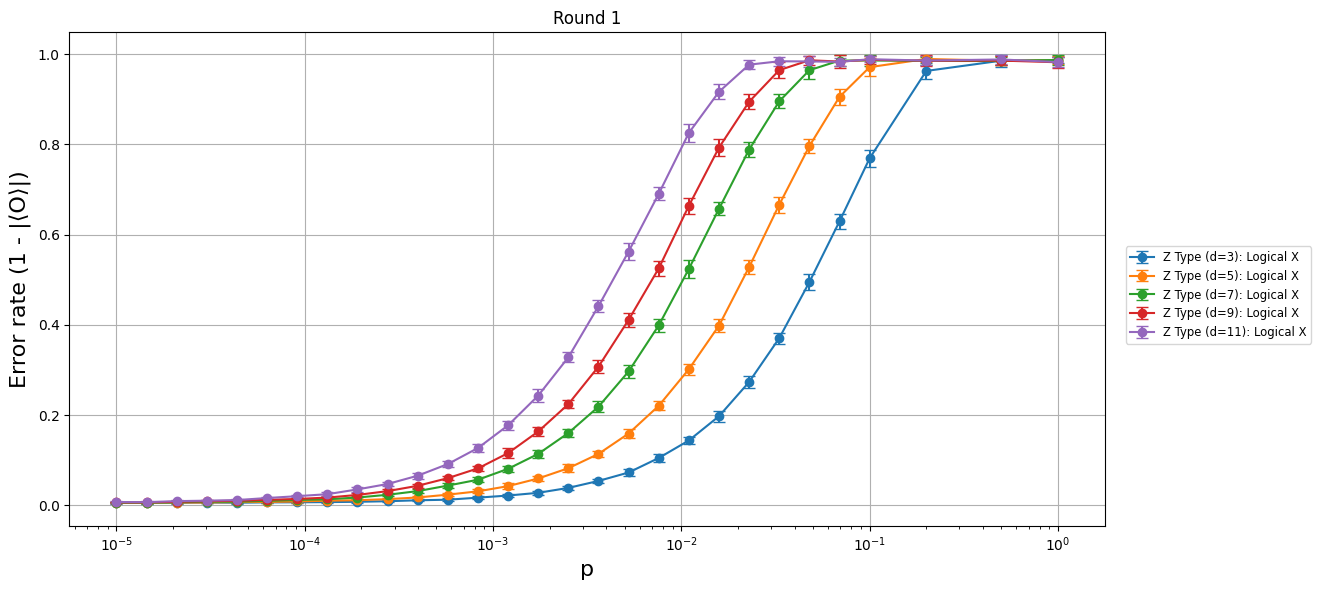

Saved threshold_z_type_noise.pdf


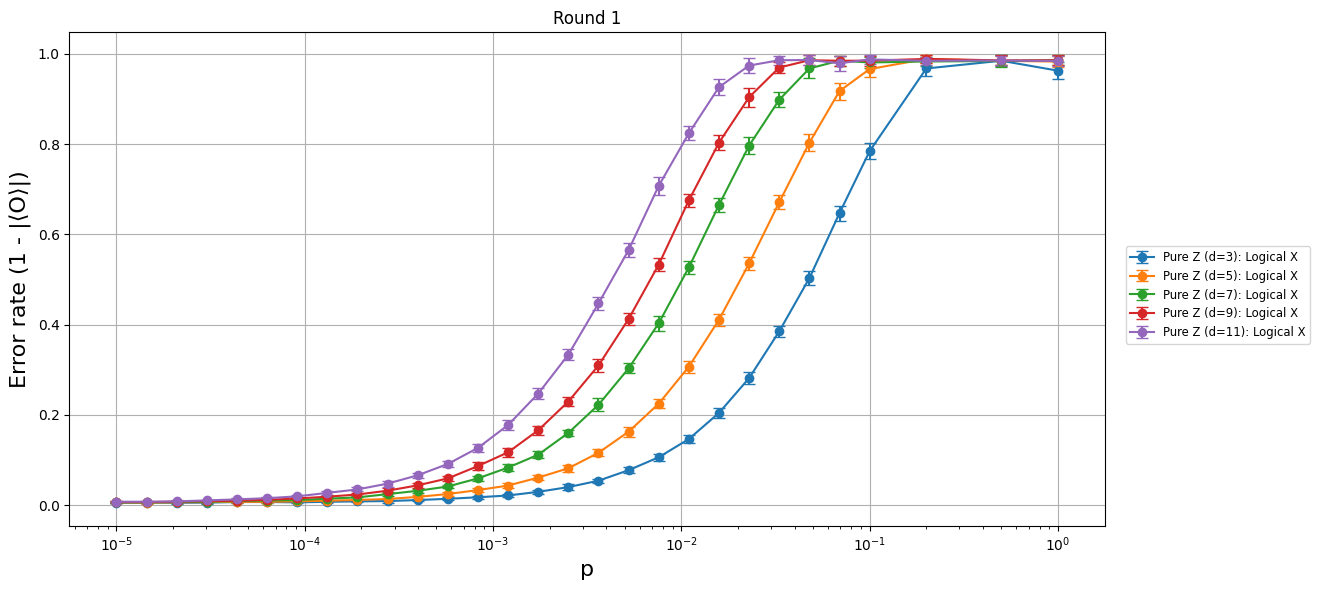

Saved threshold_pure_z_noise.pdf


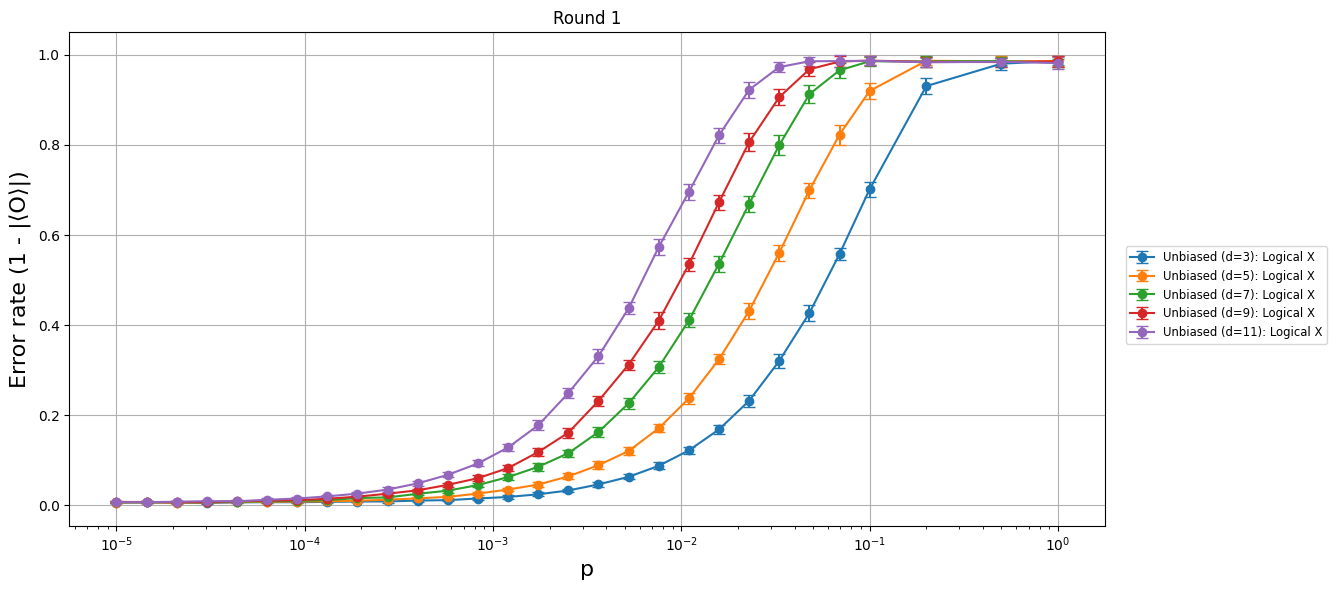

Saved threshold_unbiased_noise.pdf


In [14]:
# ==============================================================================
# 4. Reload Data & Plot Results
# ==============================================================================
# We reconstruct the MdrNoiseSweep objects from the saved CSVs.
# This proves the save worked and lets you plot in a fresh kernel.

sweeps_z_type_loaded = {}
sweeps_pure_z_loaded = {}
sweeps_unbiased_loaded = {}

print("Reloading data from CSVs...")
for d in distances:
    # 1. Z Type Noise
    try:
        sweeps_z_type_loaded[f'Z Type (d={d})'] = MdrNoiseSweep(
            load_data_filename=f"results_z_type_d{d}.csv"
        )
    except FileNotFoundError:
        print(f"Warning: Z Type data for d={d} not found.")

    # 2. Pure Z Noise
    try:
        sweeps_pure_z_loaded[f'Pure Z (d={d})'] = MdrNoiseSweep(
            load_data_filename=f"results_pure_z_d{d}.csv"
        )
    except FileNotFoundError:
        print(f"Warning: Pure Z data for d={d} not found.")

    # 3. Unbiased Noise
    try:
        sweeps_unbiased_loaded[f'Unbiased (d={d})'] = MdrNoiseSweep(
            load_data_filename=f"results_unbiased_d{d}.csv"
        )
    except FileNotFoundError:
        print(f"Warning: Unbiased data for d={d} not found.")

print("Data reload complete. Generating plots...")

# ==============================================================================
# 5. Generate Plots
# ==============================================================================

# 1. Plot Z Type Noise Threshold
MdrNoiseSweep.plot_error_multi(
    sweeps_z_type_loaded,
    category='logical',
    rounds=[1],
    subset=["Logical X"],
    overlay=False,
    log_x=True,
    save_path='threshold_z_type_noise.pdf'  
)
print("Saved threshold_z_type_noise.pdf")

# 2. Plot Pure Z Noise Threshold
MdrNoiseSweep.plot_error_multi(
    sweeps_pure_z_loaded,
    category='logical',
    rounds=[1],
    subset=["Logical X"],
    overlay=False,
    log_x=True,
    save_path='threshold_pure_z_noise.pdf'  
)
print("Saved threshold_pure_z_noise.pdf")

# 3. Plot Unbiased Noise Threshold
MdrNoiseSweep.plot_error_multi(
    sweeps_unbiased_loaded,
    category='logical',
    rounds=[1],
    subset=["Logical X"],
    overlay=False,
    log_x=True,
    save_path='threshold_unbiased_noise.pdf'  
)
print("Saved threshold_unbiased_noise.pdf")